<a href="https://colab.research.google.com/github/sahil-walunj/Formal_verification_of_Deep_Neural_Networks/blob/main/CNN_MILP_VGG16_MaxPooling_itr2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install gurobipy
!pip install tensorflow
!pip install numpy
!pip install matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, Flatten, Dense,MaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import matplotlib.pyplot as plt
import os
import time

In [3]:
# params = {
#     "WLSACCESSID":"4d102d43-af47-4767-8294-5c56341d0f8a",
#     "WLSSECRET":"dae74acb-a20b-4fec-92b6-9737c8626ca6",
#     "LICENSEID":2778199
# }
# env = gp.Env(params=params)

In [4]:
print("--- 1. Loading and Preprocessing MNIST Data ---")
(x_train, y_train), (x_test, y_test) = mnist.load_data()



# Normalize and add channel dimension (for CNN)
x_train = (x_train / 255.0).astype(np.float32)
x_test = (x_test / 255.0).astype(np.float32)


x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# Save original labels
y_test_orig = y_test

# Convert labels to one-hot encoding for training
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")

--- 1. Loading and Preprocessing MNIST Data ---
x_train shape: (60000, 28, 28, 1)
x_test shape: (10000, 28, 28, 1)


In [5]:
N_LAYERS = 2
print(f"Model will be built with N={N_LAYERS} convolutional layers.")

Model will be built with N=2 convolutional layers.


In [6]:
def model_archi_cnn(num_conv_layers):

    inp = Input(shape=(28, 28, 1), name="input")
    x = inp # Initialize x with the input

    # --- Loop to create N CNN Blocks ---
    for i in range(1, num_conv_layers + 1):
        filters = 4 * (2 ** (i-1))   # 4 → 8 → 16
        x = Conv2D(filters, (3, 3), padding='same', name=f"conv{i}_1")(x)
        x = Activation('relu')(x)

        x = Conv2D(filters, (3, 3), padding='same', name=f"conv{i}_2")(x)
        x = Activation('relu')(x)

        x = MaxPooling2D((2,2))(x)

    # Flatten the output of the last conv block
    x = Flatten(name="flatten")(x)

    outputs = Dense(10,activation='softmax',name="output_layer")(x)

    return Model(inputs=inp, outputs=outputs)


model_cnn = model_archi_cnn(num_conv_layers=N_LAYERS)


model_cnn.summary()



Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 28, 28, 1)]       0         
                                                                 
 conv1_1 (Conv2D)            (None, 28, 28, 4)         40        
                                                                 
 activation (Activation)     (None, 28, 28, 4)         0         
                                                                 
 conv1_2 (Conv2D)            (None, 28, 28, 4)         148       
                                                                 
 activation_1 (Activation)   (None, 28, 28, 4)         0         
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 4)         0         
 D)                                                              
                                                           

In [7]:
print("\n--- 2. Compiling CNN Model ---")

# Use a standard, safe learning rate
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model_cnn.compile(
    loss=tf.keras.losses.categorical_crossentropy,
    optimizer=optimizer,
    metrics=['accuracy']
)
print("\nModel compiled successfully.")


--- 2. Compiling CNN Model ---

Model compiled successfully.


In [8]:
print("\n--- 3. Training CNN Model ---")

history = model_cnn.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=10,
    validation_data=(x_test, y_test)
)

print("\nTraining complete.")


--- 3. Training CNN Model ---
Epoch 1/10


469/469 [==============================] - 4s 6ms/step - loss: 0.4225 - accuracy: 0.8710 - val_loss: 0.1451 - val_accuracy: 0.9531
Epoch 2/10
469/469 [==============================] - 2s 5ms/step - loss: 0.1230 - accuracy: 0.9619 - val_loss: 0.0871 - val_accuracy: 0.9737
Epoch 3/10
469/469 [==============================] - 2s 5ms/step - loss: 0.0908 - accuracy: 0.9722 - val_loss: 0.0817 - val_accuracy: 0.9751
Epoch 4/10
469/469 [==============================] - 2s 5ms/step - loss: 0.0753 - accuracy: 0.9768 - val_loss: 0.0636 - val_accuracy: 0.9794
Epoch 5/10
469/469 [==============================] - 2s 5ms/step - loss: 0.0648 - accuracy: 0.9792 - val_loss: 0.0517 - val_accuracy: 0.9836
Epoch 6/10
469/469 [==============================] - 2s 5ms/step - loss: 0.0572 - accuracy: 0.9815 - val_loss: 0.0598 - val_accuracy: 0.9790
Epoch 7/10
469/469 [==============================] - 3s 5ms/step - loss: 0.0540 - accuracy: 0.9831 - val_loss: 0.0

In [9]:
test_loss, test_acc = model_cnn.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

313/313 [==============================] - 1s 2ms/step - loss: 0.0420 - accuracy: 0.9859
Test Loss: 0.04200203716754913
Test Accuracy: 0.9858999848365784


In [10]:
print(f"\n--- 4. Saving CNN Weights for {N_LAYERS} Layers to cnn_net/ ---")
os.makedirs("cnn_net", exist_ok=True)


def get_layer(name):
    return model_cnn.get_layer(name)

# save weights for N layers
for i in range(1, N_LAYERS + 1):
    conv_1_name = f"conv{i}_1"
    conv_2_name = f"conv{i}_2"

    print(f"Saving weights for {conv_1_name} and {conv_2_name}...")
    # print(get_layer(conv_1_name).get_weights()[0])
    # print(get_layer(conv_2_name).get_weights()[1])

    # Save Conv{i}
    np.save(f"cnn_net/{conv_1_name}.weight", get_layer(conv_1_name).get_weights()[0]) # Kernel
    np.save(f"cnn_net/{conv_1_name}.bias",   get_layer(conv_1_name).get_weights()[1]) # Bias

    # Save BN{i}
    np.save(f"cnn_net/{conv_2_name}.weight",   get_layer(conv_2_name).get_weights()[0]) #Kernel
    np.save(f"cnn_net/{conv_2_name}.bias",     get_layer(conv_2_name).get_weights()[1]) #bias


# Save Output Layer
np.save("cnn_net/output_layer.weight", get_layer("output_layer").get_weights()[0])
np.save("cnn_net/output_layer.bias",   get_layer("output_layer").get_weights()[1])
print(get_layer("output_layer").get_weights()[0].shape)
print(get_layer("output_layer").get_weights()[1].shape)

print("All weights saved.")


--- 4. Saving CNN Weights for 2 Layers to cnn_net/ ---
Saving weights for conv1_1 and conv1_2...
Saving weights for conv2_1 and conv2_2...
(392, 10)
(10,)
All weights saved.


In [11]:
# print("\n--- 5. Setting up Gurobi Environment and Helpers ---")

# env.setParam('OutputFlag', 0)   # avoids unnecessary outputs
def load_weight_cnn(name):
    return np.load(os.path.join("cnn_net", name + ".npy"))

In [12]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt


os.makedirs("cnn_failures", exist_ok=True)

# --- Clear old failure images first ---
print("--- 7a. Clearing old failure images ---")
for f in os.listdir("cnn_failures"):
    os.remove(os.path.join("cnn_failures", f))
print("Old files cleared.")

def generate_cutout_images_cnn(model_cnn, x_test, y_test_orig, num_to_find=10):
# def generate_cutout_images_cnn(model_cnn, x_test, y_test_orig):

    print(f"\n--- 7b. Generating up to {num_to_find} Cutout Failure Images ---")
    # print(f"\n--- 7b. Generating up to Cutout Failure Images ---")

    # cutout properties
    grid_size = 4
    x_centre, y_centre = 14, 14 # Center of 28x28
    grid_bound = grid_size // 2
    start_x, start_y = x_centre - grid_bound, y_centre - grid_bound
    end_x, end_y = start_x + grid_size, start_y + grid_size

    images_found = 0

    # Get predictions for the whole test set at once
    predictions_orig = model_cnn.predict(x_test, verbose=0)
    predicted_labels_orig = np.argmax(predictions_orig, axis=1)

    for i in range(len(x_test)):
        original_image = x_test[i]
        true_label = y_test_orig[i]

        # Step 1: Check if the original image is classified CORRECTLY ---
        if predicted_labels_orig[i] == true_label:

            # Step 2: Create the cutout image ---
            cutout_image = np.copy(original_image)
            cutout_image[start_x:end_x, start_y:end_y, 0] = 0.0 # Apply cutout

            # Step 3: Check if the cutout image is classified INCORRECTLY ---
            image_for_pred = np.expand_dims(cutout_image, axis=0)
            pred_cutout = model_cnn.predict(image_for_pred, verbose=0)
            pred_label_cutout = np.argmax(pred_cutout)

            if pred_label_cutout != true_label:
                print(f"Found a failure image at index {i}! (True: {true_label}, Failed Pred: {pred_label_cutout})")

                # --- Step 4: Save the cutout image and its label ---
                save_path_img = os.path.join("cnn_failures", f"failed_image_{i}.npy")
                save_path_lbl = os.path.join("cnn_failures", f"failed_label_{i}.npy")

                np.save(save_path_img, cutout_image) # Save the 28x28x1 cutout image
                np.save(save_path_lbl, np.array(true_label)) # Save the true label

                images_found += 1

                # --- Plot for visual confirmation (optional, can be commented out) ---
                # plt.figure(figsize=(8, 4))
                # plt.subplot(1, 2, 1)
                # plt.imshow(original_image.squeeze(), cmap='gray')
                # plt.title(f"Original (Pred: {predicted_labels_orig[i]})")
                # plt.axis('off')
                # plt.subplot(1, 2, 2)
                # plt.imshow(cutout_image.squeeze(), cmap='gray')
                # plt.title(f"Cutout (Pred: {pred_label_cutout})")
                # plt.axis('off')
                # plt.show()
                # --- End optional plot ---

            if images_found >= num_to_find:
                print(f"\nReached target of {num_to_find} images.")
                break

    if images_found == 0:
        print("\nNo failure images found with this cutout.")
    else:
        print(f"\nSaved {images_found} failure image(s) to 'cnn_failures/' directory.")

# --- Run the function to find n failure images ---
generate_cutout_images_cnn(model_cnn, x_test, y_test_orig, num_to_find=100)
# generate_cutout_images_cnn(model_cnn, x_test, y_test_orig)

--- 7a. Clearing old failure images ---
Old files cleared.

--- 7b. Generating up to 100 Cutout Failure Images ---
Found a failure image at index 2! (True: 1, Failed Pred: 5)
Found a failure image at index 14! (True: 1, Failed Pred: 5)
Found a failure image at index 18! (True: 3, Failed Pred: 8)
Found a failure image at index 20! (True: 9, Failed Pred: 7)
Found a failure image at index 39! (True: 1, Failed Pred: 5)
Found a failure image at index 73! (True: 9, Failed Pred: 7)
Found a failure image at index 89! (True: 1, Failed Pred: 2)
Found a failure image at index 94! (True: 1, Failed Pred: 2)
Found a failure image at index 107! (True: 1, Failed Pred: 5)
Found a failure image at index 135! (True: 1, Failed Pred: 3)
Found a failure image at index 137! (True: 1, Failed Pred: 2)
Found a failure image at index 179! (True: 8, Failed Pred: 2)
Found a failure image at index 190! (True: 1, Failed Pred: 2)
Found a failure image at index 196! (True: 1, Failed Pred: 5)
Found a failure image at i

In [13]:

print("\n 6. Defining Optimized Gurobi Encoding Function")
print("    Bound propagation + stable ReLU elimination + tight ReLU Big-M")

def conv_bounds_numpy(W, b, lower, upper, stride=1, padding=1):
    """
    Interval bound propagation for a padded 2-D convolution.

    For each output neuron:
        z = b + sum(w*x)

    If w >= 0:
        contribution bounds = [w*l, w*u]
    else:
        contribution bounds = [w*u, w*l]

    These are valid lower/upper bounds for the pre-ReLU value.
    """
    h, w, cin = lower.shape
    kh, kw, cin_w, cout = W.shape

    assert cin == cin_w

    padded_l = np.zeros((h + 2*padding, w + 2*padding, cin), dtype=np.float64)
    padded_u = np.zeros((h + 2*padding, w + 2*padding, cin), dtype=np.float64)

    padded_l[padding:padding+h, padding:padding+w, :] = lower
    padded_u[padding:padding+h, padding:padding+w, :] = upper

    hout = (h + 2*padding - kh) // stride + 1
    wout = (w + 2*padding - kw) // stride + 1

    out_l = np.empty((hout, wout, cout), dtype=np.float64)
    out_u = np.empty((hout, wout, cout), dtype=np.float64)

    for r in range(hout):
        rr = r * stride
        for c in range(wout):
            cc = c * stride
            xl = padded_l[rr:rr+kh, cc:cc+kw, :]
            xu = padded_u[rr:rr+kh, cc:cc+kw, :]

            for k in range(cout):
                wk = W[:, :, :, k]

                pos = np.maximum(wk, 0.0)
                neg = np.minimum(wk, 0.0)

                out_l[r, c, k] = (
                    b[k]
                    + np.sum(pos * xl)
                    + np.sum(neg * xu)
                )
                out_u[r, c, k] = (
                    b[k]
                    + np.sum(pos * xu)
                    + np.sum(neg * xl)
                )

    return out_l, out_u


def add_bounded_relu(m, z, y, L, U, name, stats):
    """
    Exact ReLU encoding using propagated bounds.

    Stable neurons:
      U <= 0  -> y = 0, no binary
      L >= 0  -> y = z, no binary

    Ambiguous neurons:
      L < 0 < U -> one binary + tight Big-M constraints.
    """
    eps = 1e-9

    if U <= eps:
        # Always inactive: ReLU(z) = 0
        m.addConstr(y == 0.0, name=f"{name}_stable_zero")
        stats["always_zero"] += 1
        return

    if L >= -eps:
        # Always active: ReLU(z) = z
        m.addConstr(y == z, name=f"{name}_stable_active")
        stats["always_active"] += 1
        return

    # Only ambiguous ReLUs need a binary activation variable.
    a = m.addVar(vtype=GRB.BINARY, name=f"{name}_binary")

    # y >= z
    m.addConstr(y >= z, name=f"{name}_lower_z")

    # y >= 0
    m.addConstr(y >= 0.0, name=f"{name}_lower_zero")

    # y <= z - L(1-a)
    m.addConstr(y <= z - L * (1 - a), name=f"{name}_upper_active")

    # y <= U*a
    m.addConstr(y <= U * a, name=f"{name}_upper_inactive")

    stats["ambiguous"] += 1


def model_encoding(x_image, true_label, num_conv_layers, tauType):
    """
    Optimized MILP reconstruction.

    Main optimization over the previous implementation:
      1. Propagate numerical lower/upper bounds through every convolution.
      2. Use those bounds to identify stable ReLUs.
      3. Eliminate the binary variable for every stable ReLU.
      4. Use the propagated L/U as tight Big-M values for ambiguous ReLUs.
      5. Propagate post-ReLU bounds into the next layer.
      6. Use bounded variables throughout the network.

    The encoded neural network remains exact for the trained CNN because
    stable ReLUs are eliminated only when their propagated bounds prove
    their activation state.
    """

    x_image = np.asarray(x_image, dtype=np.float64)
    true_label = int(true_label)

    # ------------------------------------------------------------
    # Load trained parameters
    # ------------------------------------------------------------
    conv_params = []

    for i in range(1, num_conv_layers + 1):
        w_conv_1 = load_weight_cnn(f"conv{i}_1.weight")
        b_conv_1 = load_weight_cnn(f"conv{i}_1.bias")
        w_conv_2 = load_weight_cnn(f"conv{i}_2.weight")
        b_conv_2 = load_weight_cnn(f"conv{i}_2.bias")

        conv_params.append(
            ((w_conv_1, b_conv_1), (w_conv_2, b_conv_2))
        )

    w_out = load_weight_cnn("output_layer.weight")
    b_out = load_weight_cnn("output_layer.bias")

    # ------------------------------------------------------------
    # Gurobi model
    # ------------------------------------------------------------
    m = gp.Model(f"CNN_Corrective_Encoding_ReLU_Bounded_N{num_conv_layers}")

    m.setParam("OutputFlag", 0)
    m.setParam("MIPFocus", 1)
    m.setParam("TimeLimit", 600)

    # ------------------------------------------------------------
    # Input / tau
    # ------------------------------------------------------------
    grid_size = 4
    x_centre, y_centre = 14, 14
    grid_bound = grid_size // 2
    start_x = x_centre - grid_bound
    start_y = y_centre - grid_bound

    if tauType == 0:
        tau = m.addMVar(
            (grid_size, grid_size),
            vtype=GRB.BINARY,
            name="tau"
        )
    else:
        tau = m.addMVar(
            (grid_size, grid_size),
            lb=0.0,
            ub=1.0,
            vtype=GRB.CONTINUOUS,
            name="tau"
        )

    x_perturbed = m.addMVar(
        (28, 28, 1),
        lb=0.0,
        ub=1.0,
        name="x_perturbed"
    )

    # ------------------------------------------------------------
    # Tightest valid input interval under the existing formulation
    #
    # Outside tau:
    #     x_perturbed = x_image
    #
    # Inside tau:
    #     x_perturbed = x_image + tau
    #     0 <= x_perturbed <= 1
    #
    # Hence inside the patch:
    #     lower = x_image
    #     upper = 1
    #
    # For binary tau, values with x_image > 0 are additionally forced
    # toward zero by x_perturbed <= 1, but [x_image,1] is still valid.
    # ------------------------------------------------------------
    input_lower = np.clip(x_image.copy(), 0.0, 1.0)
    input_upper = np.ones((28, 28, 1), dtype=np.float64)

    for r in range(28):
        for c in range(28):
            inside = (
                start_x <= r < start_x + grid_size
                and
                start_y <= c < start_y + grid_size
            )

            if not inside:
                value = float(x_image[r, c, 0])
                input_lower[r, c, 0] = value
                input_upper[r, c, 0] = value

                m.addConstr(
                    x_perturbed[r, c, 0] == value,
                    name=f"fix_input_{r}_{c}"
                )

    for i in range(grid_size):
        for j in range(grid_size):
            m.addConstr(
                x_perturbed[
                    start_x + i,
                    start_y + j,
                    0
                ]
                ==
                float(x_image[start_x + i, start_y + j, 0])
                + tau[i, j],
                name=f"tau_patch_{i}_{j}"
            )

    # ------------------------------------------------------------
    # Bound statistics
    # ------------------------------------------------------------
    stats = {
        "total_relu": 0,
        "always_zero": 0,
        "always_active": 0,
        "ambiguous": 0,
        "relu_binaries": 0,
    }

    current_vars = x_perturbed
    current_lower = input_lower
    current_upper = input_upper

    # ------------------------------------------------------------
    # Helper: encode one padded convolution + ReLU
    # ------------------------------------------------------------
    def encode_conv_relu(
        W, b, current_vars, current_lower, current_upper, layer_tag
    ):
        h, w, cin = current_vars.shape
        kh, kw, cin_w, cout = W.shape

        assert kh == 3 and kw == 3
        assert cin == cin_w

        # ---- Bound propagation BEFORE creating the MILP ReLU ----
        pre_L, pre_U = conv_bounds_numpy(
            W,
            b,
            current_lower,
            current_upper,
            stride=1,
            padding=1
        )

        relu_L = np.maximum(pre_L, 0.0)
        relu_U = np.maximum(pre_U, 0.0)

        # ---- Bounded variables ----
        conv_out = m.addMVar(
            (h, w, cout),
            lb=pre_L,
            ub=pre_U,
            name=f"{layer_tag}_pre_relu"
        )

        act_out = m.addMVar(
            (h, w, cout),
            lb=relu_L,
            ub=relu_U,
            name=f"{layer_tag}_relu_out"
        )

        # ---- Padding ----
        padded = m.addMVar(
            (h + 2, w + 2, cin),
            lb=-GRB.INFINITY,
            ub=GRB.INFINITY,
            name=f"{layer_tag}_padded"
        )

        m.addConstr(
            padded[1:-1, 1:-1, :] == current_vars,
            name=f"{layer_tag}_copy_center"
        )
        m.addConstr(
            padded[0, :, :] == 0,
            name=f"{layer_tag}_pad_top"
        )
        m.addConstr(
            padded[-1, :, :] == 0,
            name=f"{layer_tag}_pad_bottom"
        )
        m.addConstr(
            padded[:, 0, :] == 0,
            name=f"{layer_tag}_pad_left"
        )
        m.addConstr(
            padded[:, -1, :] == 0,
            name=f"{layer_tag}_pad_right"
        )

        # ---- Convolution + optimized ReLU ----
        for r in range(h):
            for c in range(w):
                for k in range(cout):

                    conv_expr = gp.LinExpr(float(b[k]))

                    for ci in range(cin):
                        for di in range(3):
                            for dj in range(3):
                                weight = float(W[di, dj, ci, k])

                                # Zero coefficients do not need a term.
                                if abs(weight) > 1e-12:
                                    conv_expr += (
                                        weight
                                        * padded[r + di, c + dj, ci]
                                    )

                    m.addConstr(
                        conv_out[r, c, k] == conv_expr,
                        name=f"{layer_tag}_conv_{r}_{c}_{k}"
                    )

                    L = float(pre_L[r, c, k])
                    U = float(pre_U[r, c, k])

                    stats["total_relu"] += 1

                    add_bounded_relu(
                        m,
                        conv_out[r, c, k],
                        act_out[r, c, k],
                        L,
                        U,
                        name=f"{layer_tag}_relu_{r}_{c}_{k}",
                        stats=stats
                    )

        stats["relu_binaries"] = stats["ambiguous"]

        return act_out, relu_L, relu_U

    # ------------------------------------------------------------
    # Encode all convolutional blocks
    # ------------------------------------------------------------
    for block in range(num_conv_layers):

        W1, b1 = conv_params[block][0]

        current_vars, current_lower, current_upper = encode_conv_relu(
            W1,
            b1,
            current_vars,
            current_lower,
            current_upper,
            layer_tag=f"conv{block+1}_1"
        )

        W2, b2 = conv_params[block][1]

        current_vars, current_lower, current_upper = encode_conv_relu(
            W2,
            b2,
            current_vars,
            current_lower,
            current_upper,
            layer_tag=f"conv{block+1}_2"
        )

        # --------------------------------------------------------
        # Max-pooling
        # --------------------------------------------------------
        h, w, ch = current_vars.shape

        pooled_h = h // 2
        pooled_w = w // 2

        pool_lower = np.empty((pooled_h, pooled_w, ch))
        pool_upper = np.empty((pooled_h, pooled_w, ch))

        pool_out = m.addMVar(
            (pooled_h, pooled_w, ch),
            lb=0.0,
            ub=GRB.INFINITY,
            name=f"pool_{block+1}_out"
        )

        for r in range(pooled_h):
            for c in range(pooled_w):
                for k in range(ch):

                    idx = [
                        (2*r,     2*c),
                        (2*r,     2*c + 1),
                        (2*r + 1, 2*c),
                        (2*r + 1, 2*c + 1),
                    ]

                    pool_inputs = [
                        current_vars[rr, cc, k]
                        for rr, cc in idx
                    ]

                    # Exact bounds for max of nonnegative ReLU outputs.
                    lower_vals = [
                        current_lower[rr, cc, k]
                        for rr, cc in idx
                    ]
                    upper_vals = [
                        current_upper[rr, cc, k]
                        for rr, cc in idx
                    ]

                    pool_lower[r, c, k] = max(lower_vals)
                    pool_upper[r, c, k] = max(upper_vals)

                    # Give Gurobi the propagated pool bounds.
                    pool_out[r, c, k].LB = pool_lower[r, c, k]
                    pool_out[r, c, k].UB = pool_upper[r, c, k]

                    m.addGenConstrMax(
                        pool_out[r, c, k],
                        pool_inputs,
                        constant=0.0,
                        name=f"maxpool_{block+1}_{r}_{c}_{k}"
                    )

        current_vars = pool_out
        current_lower = pool_lower
        current_upper = pool_upper

    # ------------------------------------------------------------
    # Flatten
    # ------------------------------------------------------------
    h, w, ch = current_vars.shape
    flat_dim = h * w * ch

    flattened_vars = m.addMVar(
        flat_dim,
        lb=current_lower.reshape(-1),
        ub=current_upper.reshape(-1),
        name="flattened"
    )

    for r in range(h):
        for c in range(w):
            for k in range(ch):
                idx = r * (w * ch) + c * ch + k
                m.addConstr(
                    flattened_vars[idx] == current_vars[r, c, k],
                    name=f"flatten_{idx}"
                )

    # ------------------------------------------------------------
    # Dense / logits
    # ------------------------------------------------------------
    flat_dim_weights = w_out.shape[0]
    num_classes = w_out.shape[1]

    assert flat_dim == flat_dim_weights, (
        f"Flatten dimension mismatch: model={flat_dim}, "
        f"weights={flat_dim_weights}"
    )

    # Propagate dense output bounds as well.
    dense_L = np.empty(num_classes)
    dense_U = np.empty(num_classes)

    flat_L = current_lower.reshape(-1)
    flat_U = current_upper.reshape(-1)

    for j in range(num_classes):
        ww = w_out[:, j]
        dense_L[j] = (
            b_out[j]
            + np.sum(np.maximum(ww, 0.0) * flat_L)
            + np.sum(np.minimum(ww, 0.0) * flat_U)
        )
        dense_U[j] = (
            b_out[j]
            + np.sum(np.maximum(ww, 0.0) * flat_U)
            + np.sum(np.minimum(ww, 0.0) * flat_L)
        )

    logits = m.addMVar(
        num_classes,
        lb=dense_L,
        ub=dense_U,
        name="logits"
    )

    for j in range(num_classes):
        expr = gp.LinExpr(float(b_out[j]))

        for i in range(flat_dim):
            weight = float(w_out[i, j])
            if abs(weight) > 1e-12:
                expr += weight * flattened_vars[i]

        m.addConstr(
            logits[j] == expr,
            name=f"logit_{j}"
        )

    # ------------------------------------------------------------
    # Classification constraint
    # ------------------------------------------------------------
    robust_margin = 0.2

    for j in range(num_classes):
        if j != true_label:
            m.addConstr(
                logits[true_label] >= logits[j] + robust_margin,
                name=f"force_correct_{j}"
            )

    # Feasibility problem.
    m.setObjective(0.0, GRB.MINIMIZE)

    # ------------------------------------------------------------
    # Research statistics
    # ------------------------------------------------------------
    eliminated = (
        stats["always_zero"]
        + stats["always_active"]
    )

    total = stats["total_relu"]

    print("\n" + "=" * 70)
    print("BOUND-PROPAGATED ReLU SUMMARY")
    print("=" * 70)
    print(f"Total ReLU neurons       : {total}")
    print(f"Always inactive (L/U)    : {stats['always_zero']}")
    print(f"Always active (L/U)      : {stats['always_active']}")
    print(f"Ambiguous ReLUs          : {stats['ambiguous']}")
    print(f"ReLU binary variables    : {stats['relu_binaries']}")
    print(f"Binaries eliminated      : {eliminated}")

    if total > 0:
        print(
            f"Binary reduction        : "
            f"{100.0 * eliminated / total:.2f}%"
        )

    print("=" * 70)

    # ------------------------------------------------------------
    # Solve
    # ------------------------------------------------------------
    print("Starting optimized Gurobi optimization...")

    import time
    t0 = time.perf_counter()

    m.optimize()

    elapsed = time.perf_counter() - t0

    print(f"Solve time: {elapsed:.4f} s")
    print(f"Gurobi status: {m.status}")

    if m.status == GRB.OPTIMAL:
        if m.SolCount > 0:
            return (tau.X, true_label)

    elif m.status == GRB.TIME_LIMIT:
        if m.SolCount > 0:
            print("Time limit reached, but a feasible solution was found.")
            return (tau.X, true_label)
        print("Time limit reached before a feasible solution was found.")

    elif m.status == GRB.INFEASIBLE:
        print("Model is INFEASIBLE. No corrective perturbation found.")

    else:
        print(f"Gurobi exited with status: {m.status}")

    return (None, None)



 6. Defining Optimized Gurobi Encoding Function
    Bound propagation + stable ReLU elimination + tight ReLU Big-M


## 7. What changed in the optimized MILP

The original formulation used Gurobi's generic `GenConstrMax` for every ReLU. The optimized formulation first propagates numerical lower/upper bounds through each convolution. A ReLU with `U <= 0` is fixed to zero, while one with `L >= 0` is fixed to the identity; only `L < 0 < U` receives a binary activation variable and tight Big-M constants. The same propagated bounds are passed to the next layer and to max-pooling. This follows the bound-based formulation described in the accompanying MILP report. fileciteturn1file1


In [14]:
# # Optional: run one optimized case manually before processing the full folder.
# # This is useful for checking the reported ReLU binary reduction.

# # Example:
# image_index, failed_image_path, true_label = failed_images_to_test[0]
# failed_image = np.load(failed_image_path)
# tau_values, pred = model_encoding(
#     failed_image, true_label,
#     num_conv_layers=N_LAYERS,
#     tauType=0
# )
# print('Returned:', tau_values is not None, pred)



 8. Running Full Verification Test on Multiple Images for binarised TAU
Found 100 failed images. Processing all of them...

--- TEST 1/100: Image Index 1000 ---
Running Gurobi to find corrective 'tau' patch for target 9...
Set parameter Username
Set parameter LicenseID to value 2794202
Academic license - for non-commercial use only - expires 2027-03-18

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1244
Always active (L/U)      : 7426
Ambiguous ReLUs          : 738
ReLU binary variables    : 738
Binaries eliminated      : 8670
Binary reduction        : 92.16%
Starting optimized Gurobi optimization...
Solve time: 1.4833 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1000 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


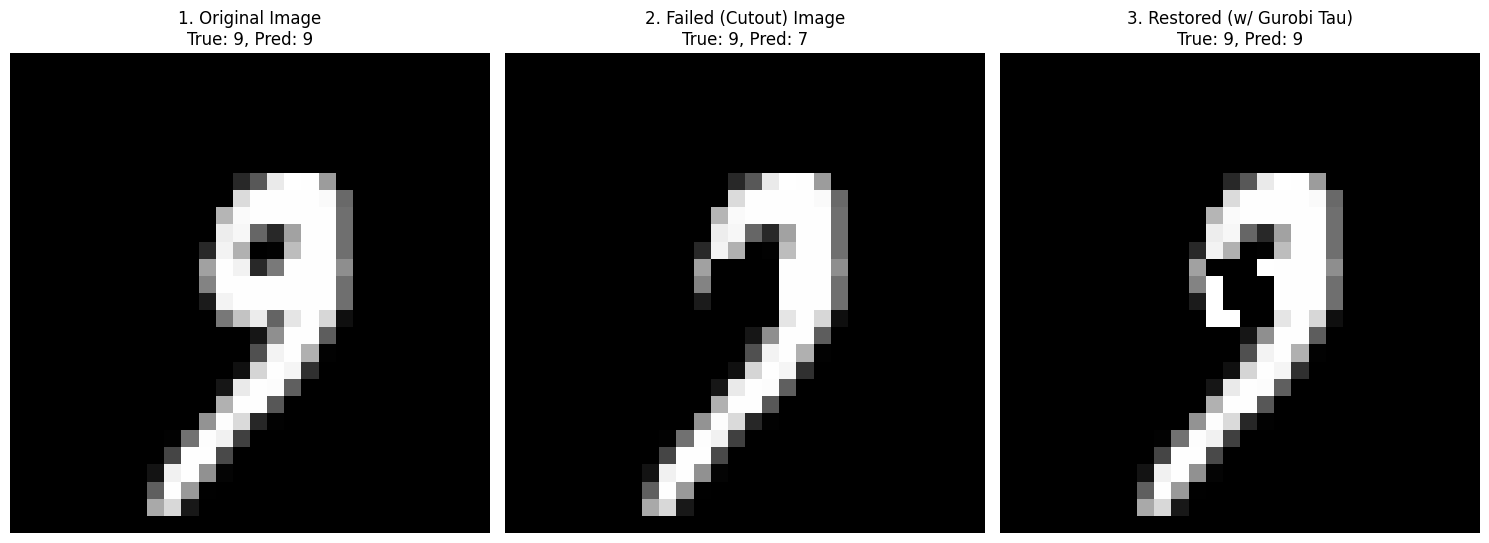


--- TEST 2/100: Image Index 1008 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1202
Always active (L/U)      : 7386
Ambiguous ReLUs          : 820
ReLU binary variables    : 820
Binaries eliminated      : 8588
Binary reduction        : 91.28%
Starting optimized Gurobi optimization...
Solve time: 0.6406 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1008 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


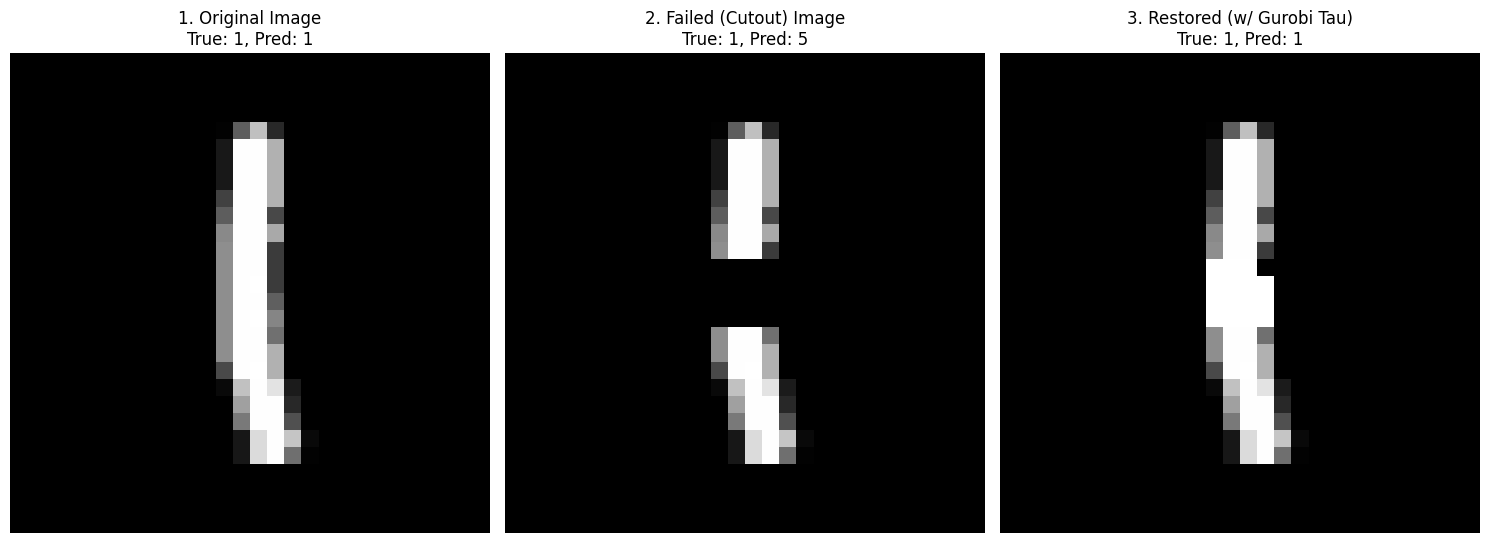


--- TEST 3/100: Image Index 1011 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1221
Always active (L/U)      : 7395
Ambiguous ReLUs          : 792
ReLU binary variables    : 792
Binaries eliminated      : 8616
Binary reduction        : 91.58%
Starting optimized Gurobi optimization...
Solve time: 0.5951 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1011 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


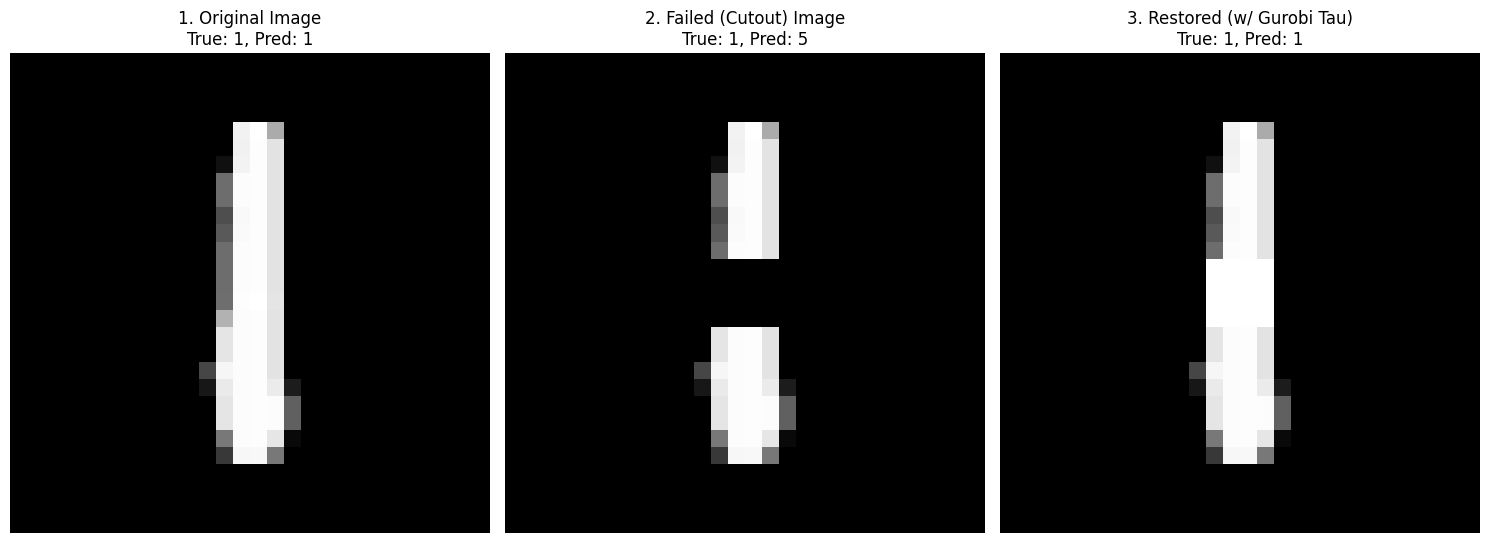


--- TEST 4/100: Image Index 1037 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1177
Always active (L/U)      : 7385
Ambiguous ReLUs          : 846
ReLU binary variables    : 846
Binaries eliminated      : 8562
Binary reduction        : 91.01%
Starting optimized Gurobi optimization...
Solve time: 0.6241 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1037 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


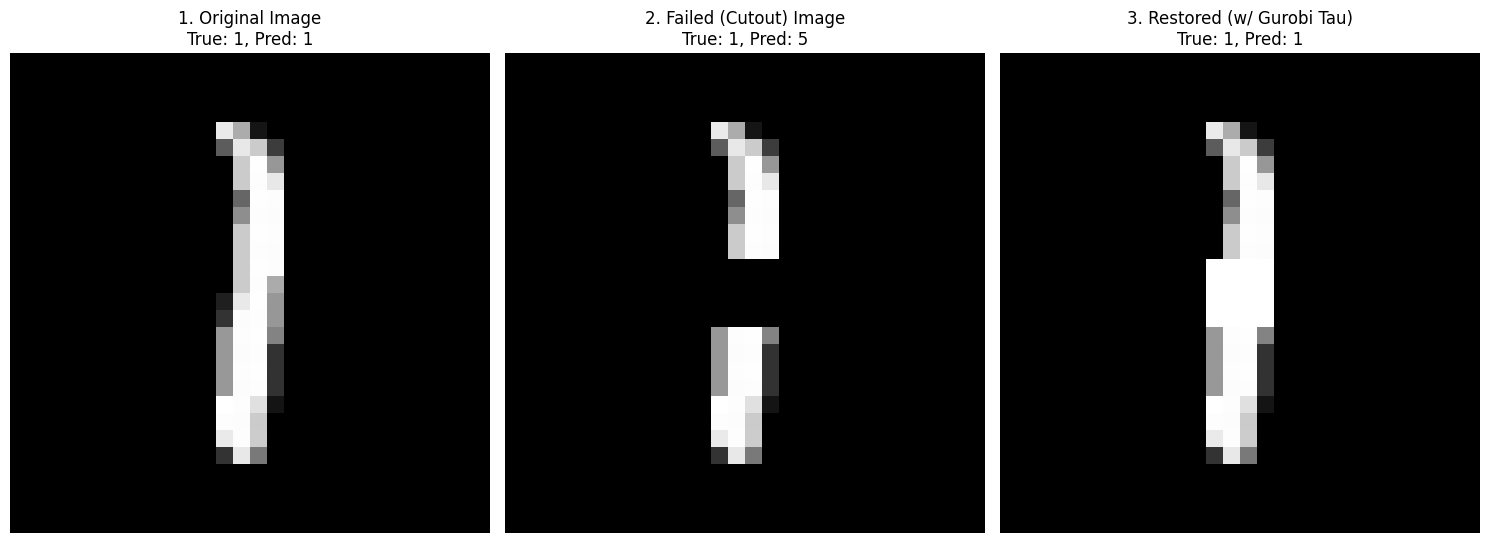


--- TEST 5/100: Image Index 1045 ---
Running Gurobi to find corrective 'tau' patch for target 9...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1260
Always active (L/U)      : 7457
Ambiguous ReLUs          : 691
ReLU binary variables    : 691
Binaries eliminated      : 8717
Binary reduction        : 92.66%
Starting optimized Gurobi optimization...
Solve time: 145.8106 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1045 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


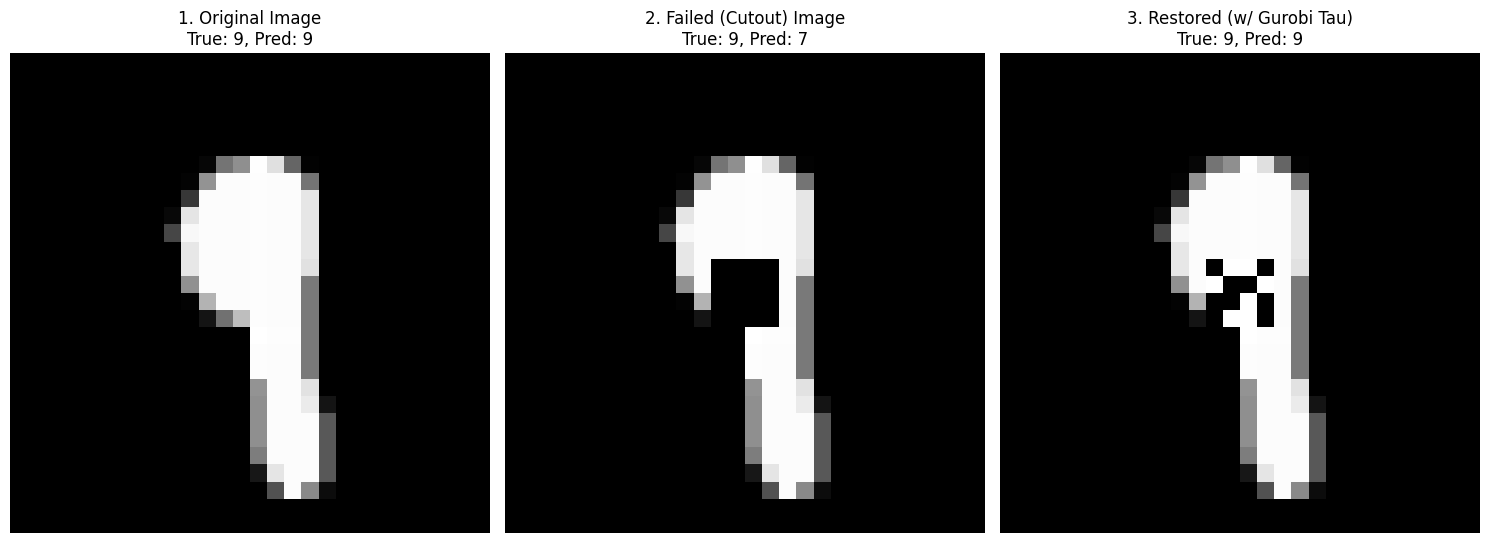


--- TEST 6/100: Image Index 107 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1220
Always active (L/U)      : 7328
Ambiguous ReLUs          : 860
ReLU binary variables    : 860
Binaries eliminated      : 8548
Binary reduction        : 90.86%
Starting optimized Gurobi optimization...
Solve time: 8.5056 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 107 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


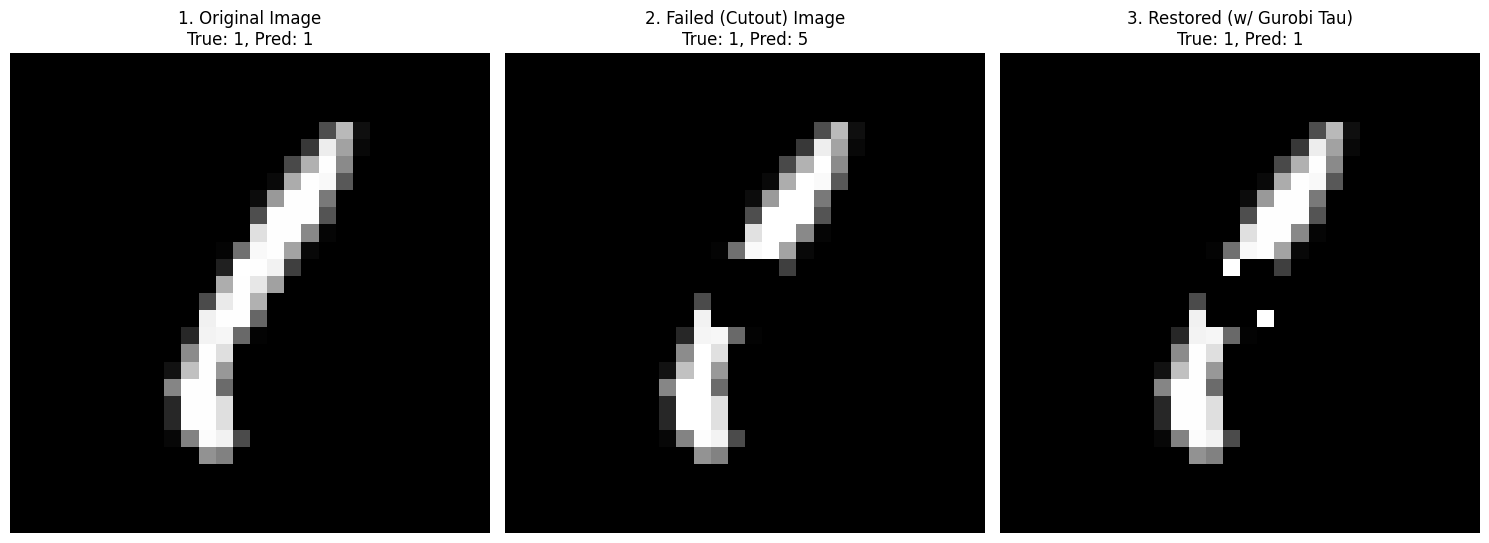


--- TEST 7/100: Image Index 1093 ---
Running Gurobi to find corrective 'tau' patch for target 8...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1440
Always active (L/U)      : 7318
Ambiguous ReLUs          : 650
ReLU binary variables    : 650
Binaries eliminated      : 8758
Binary reduction        : 93.09%
Starting optimized Gurobi optimization...
Solve time: 1.9656 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1093 - True Label: 8
  Prediction (Original): 8 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 8 (Correct)
----------------------------------------


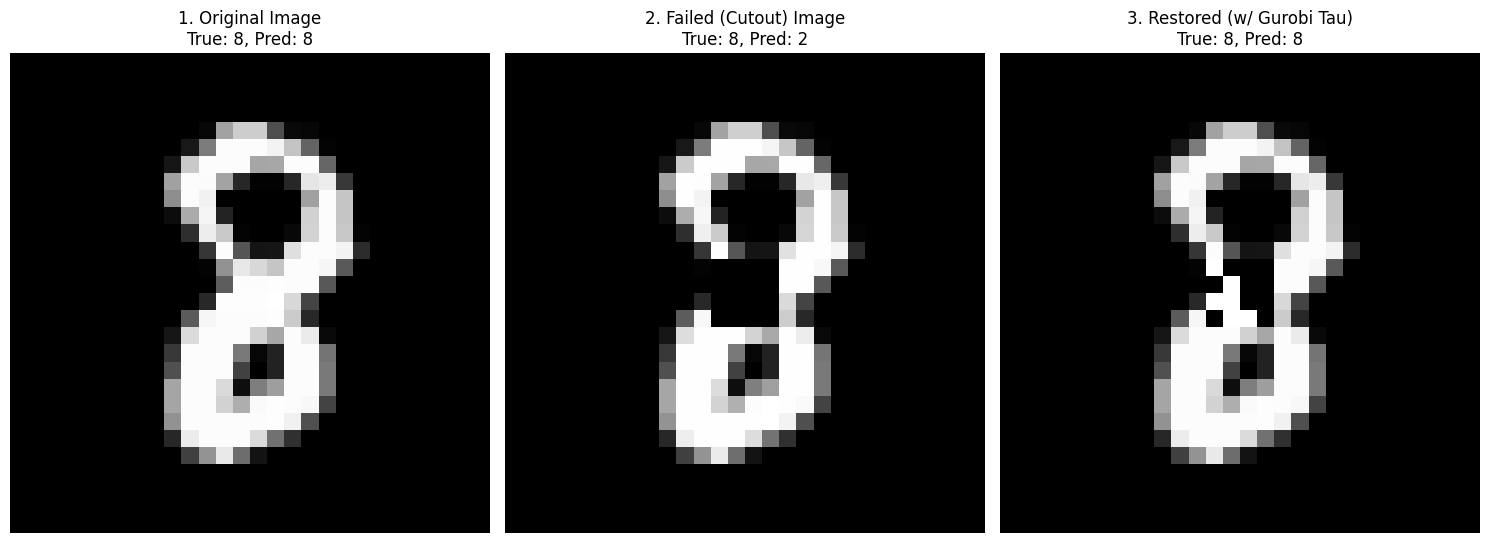


--- TEST 8/100: Image Index 1097 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1136
Always active (L/U)      : 7370
Ambiguous ReLUs          : 902
ReLU binary variables    : 902
Binaries eliminated      : 8506
Binary reduction        : 90.41%
Starting optimized Gurobi optimization...
Solve time: 0.7368 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1097 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


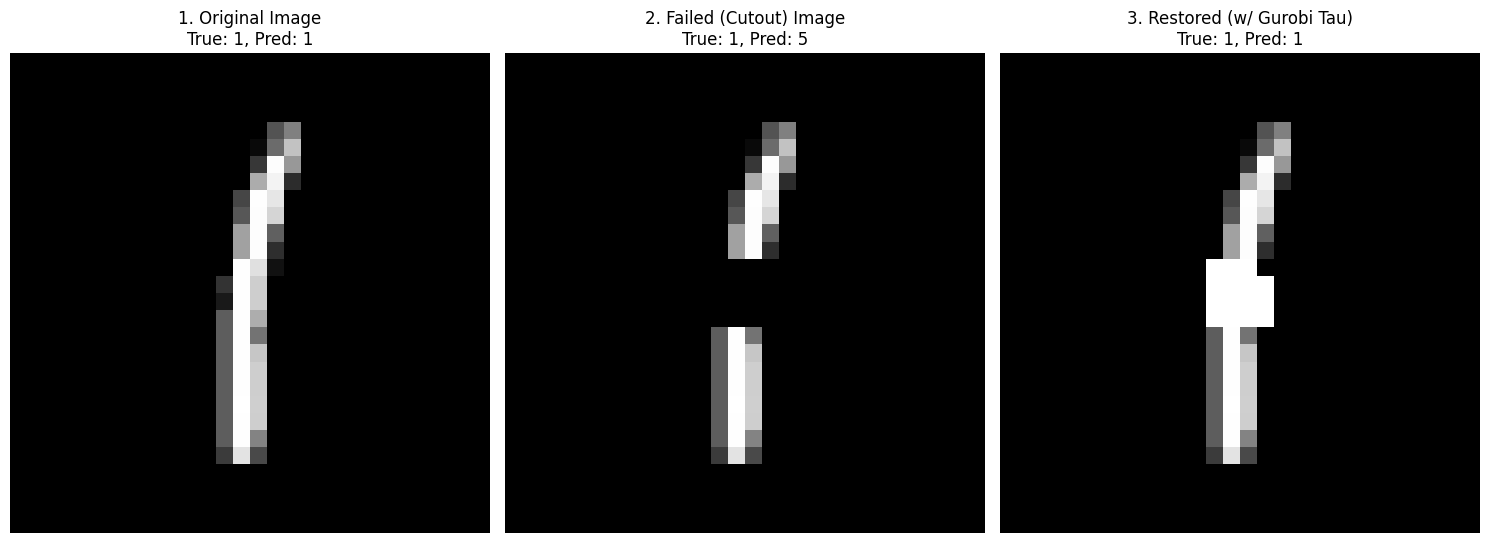


--- TEST 9/100: Image Index 1114 ---
Running Gurobi to find corrective 'tau' patch for target 3...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1456
Always active (L/U)      : 7337
Ambiguous ReLUs          : 615
ReLU binary variables    : 615
Binaries eliminated      : 8793
Binary reduction        : 93.46%
Starting optimized Gurobi optimization...
Solve time: 0.5430 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1114 - True Label: 3
  Prediction (Original): 3 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 3 (Correct)
----------------------------------------


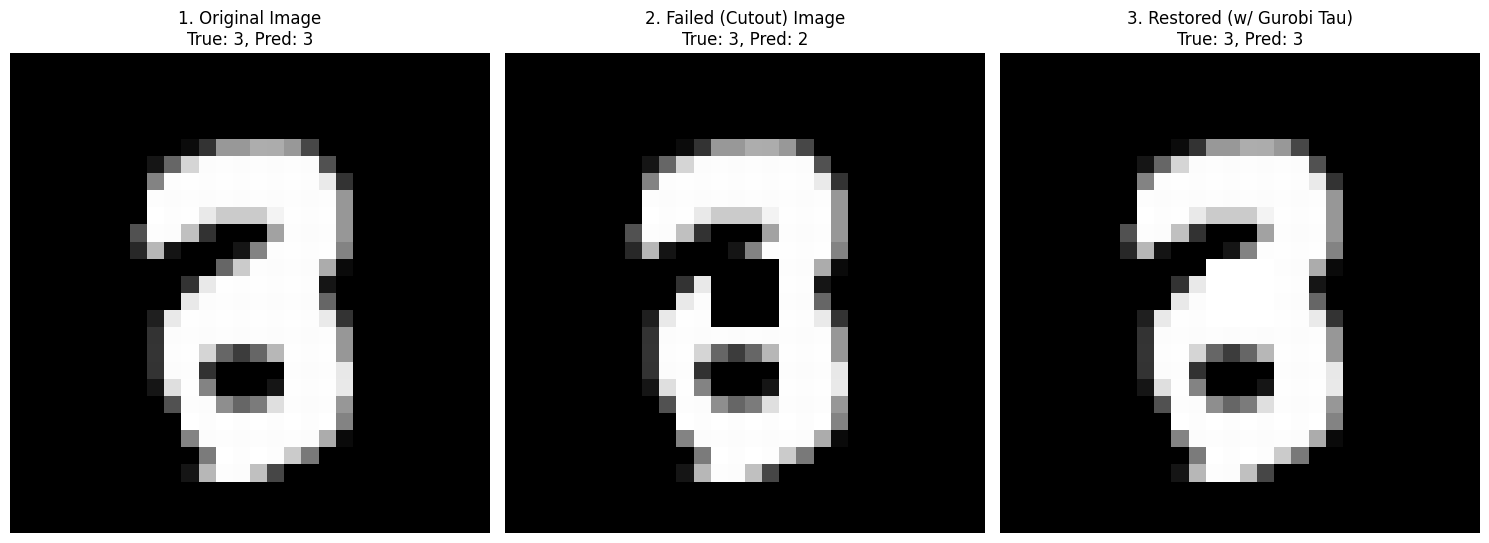


--- TEST 10/100: Image Index 1118 ---
Running Gurobi to find corrective 'tau' patch for target 8...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1532
Always active (L/U)      : 7212
Ambiguous ReLUs          : 664
ReLU binary variables    : 664
Binaries eliminated      : 8744
Binary reduction        : 92.94%
Starting optimized Gurobi optimization...
Solve time: 0.5926 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1118 - True Label: 8
  Prediction (Original): 8 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 8 (Correct)
----------------------------------------


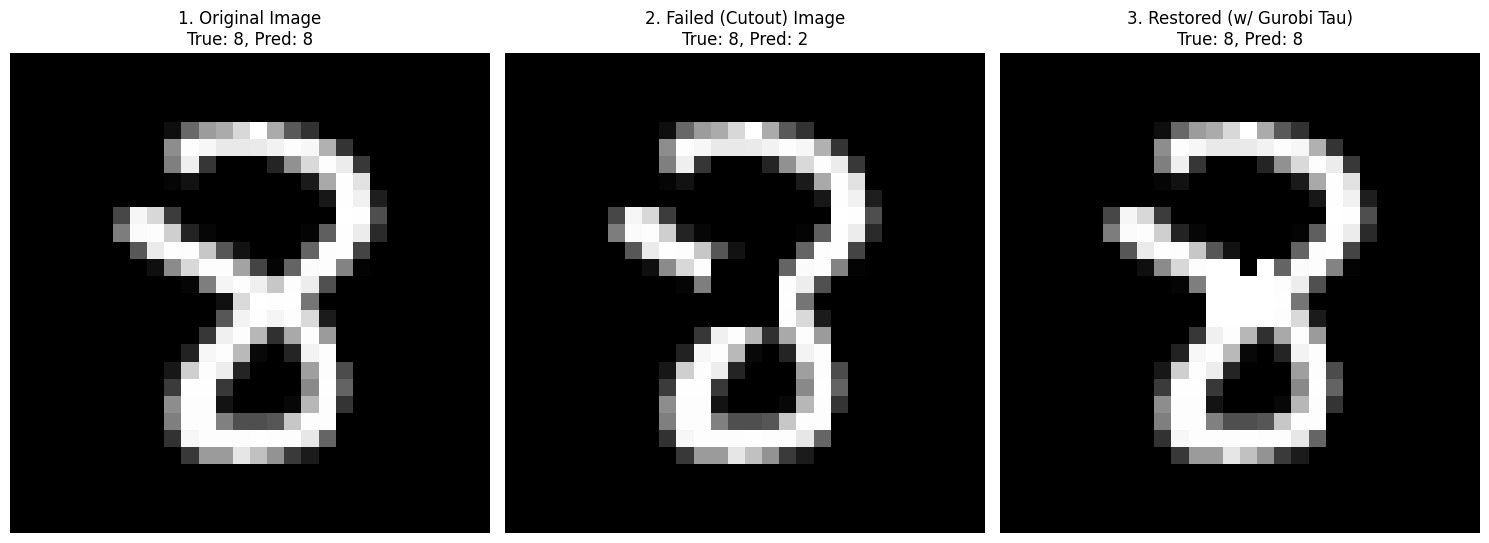


--- TEST 11/100: Image Index 1129 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1237
Always active (L/U)      : 7402
Ambiguous ReLUs          : 769
ReLU binary variables    : 769
Binaries eliminated      : 8639
Binary reduction        : 91.83%
Starting optimized Gurobi optimization...
Solve time: 67.2218 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1129 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


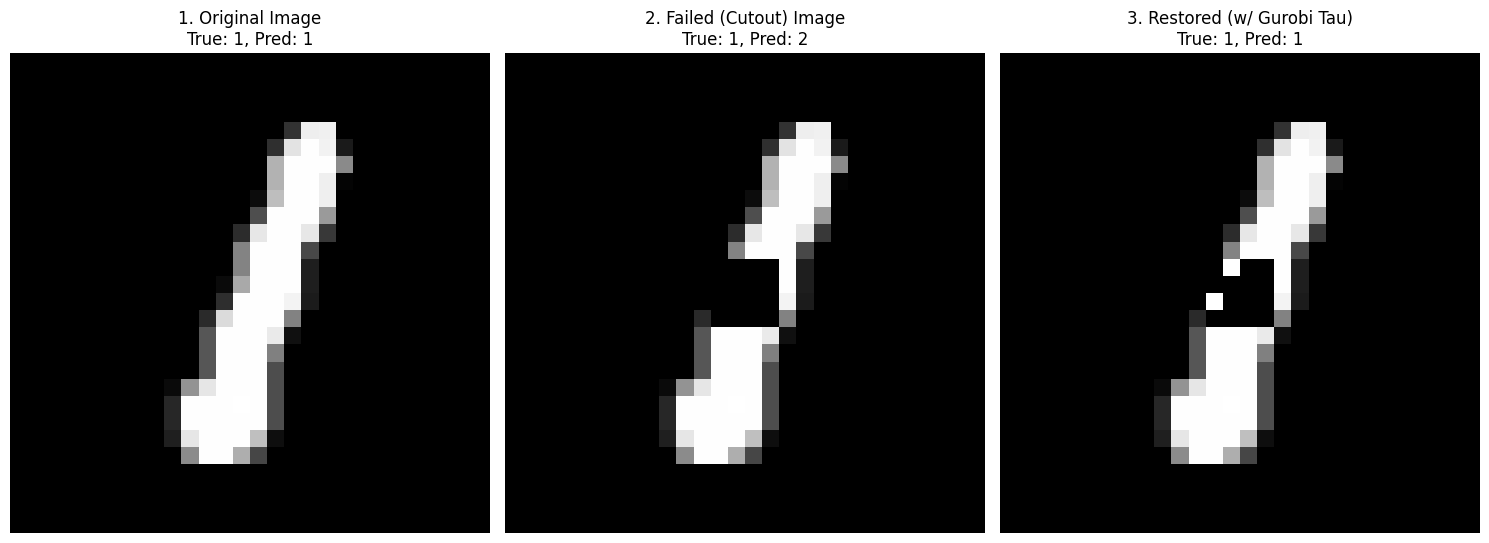


--- TEST 12/100: Image Index 1136 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1206
Always active (L/U)      : 7377
Ambiguous ReLUs          : 825
ReLU binary variables    : 825
Binaries eliminated      : 8583
Binary reduction        : 91.23%
Starting optimized Gurobi optimization...
Solve time: 0.5852 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1136 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


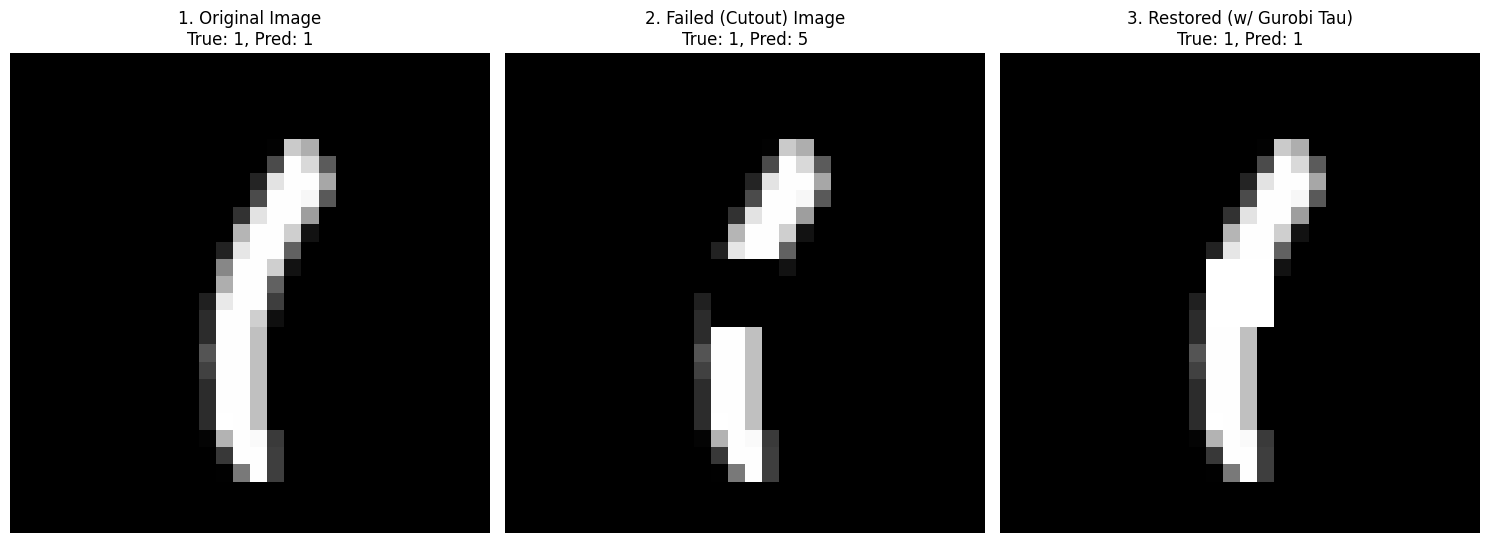


--- TEST 13/100: Image Index 1139 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1228
Always active (L/U)      : 7435
Ambiguous ReLUs          : 745
ReLU binary variables    : 745
Binaries eliminated      : 8663
Binary reduction        : 92.08%
Starting optimized Gurobi optimization...
Solve time: 0.6684 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1139 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


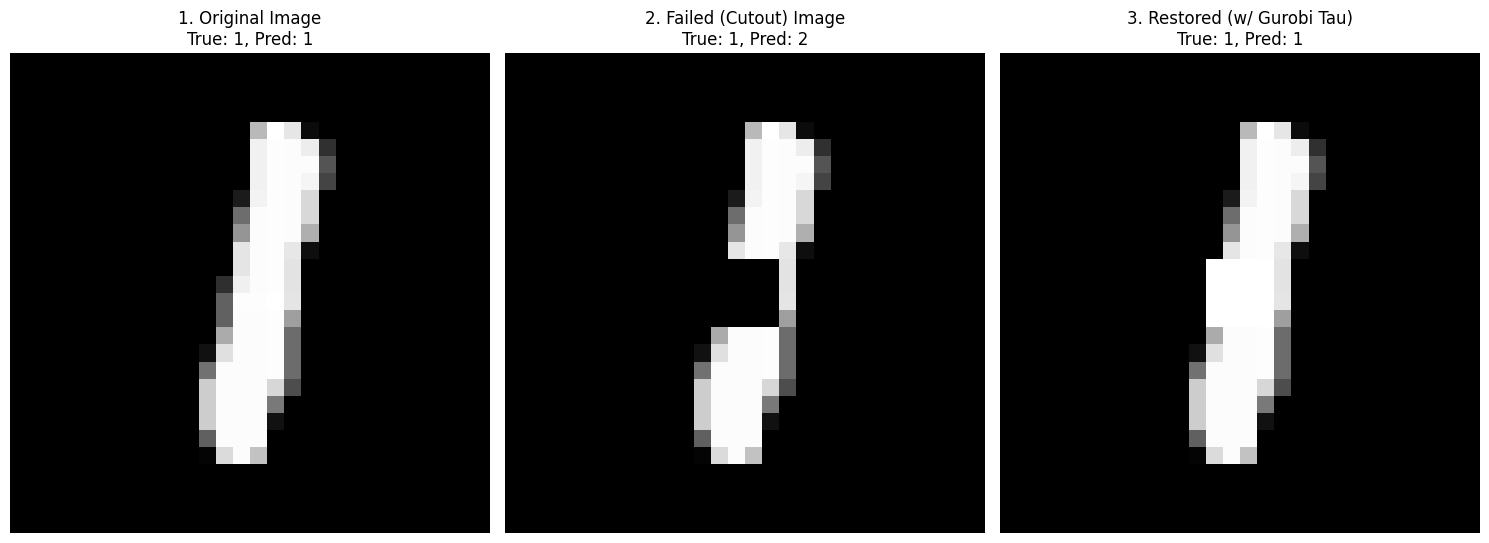


--- TEST 14/100: Image Index 1179 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1165
Always active (L/U)      : 7377
Ambiguous ReLUs          : 866
ReLU binary variables    : 866
Binaries eliminated      : 8542
Binary reduction        : 90.80%
Starting optimized Gurobi optimization...
Solve time: 3.2395 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1179 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


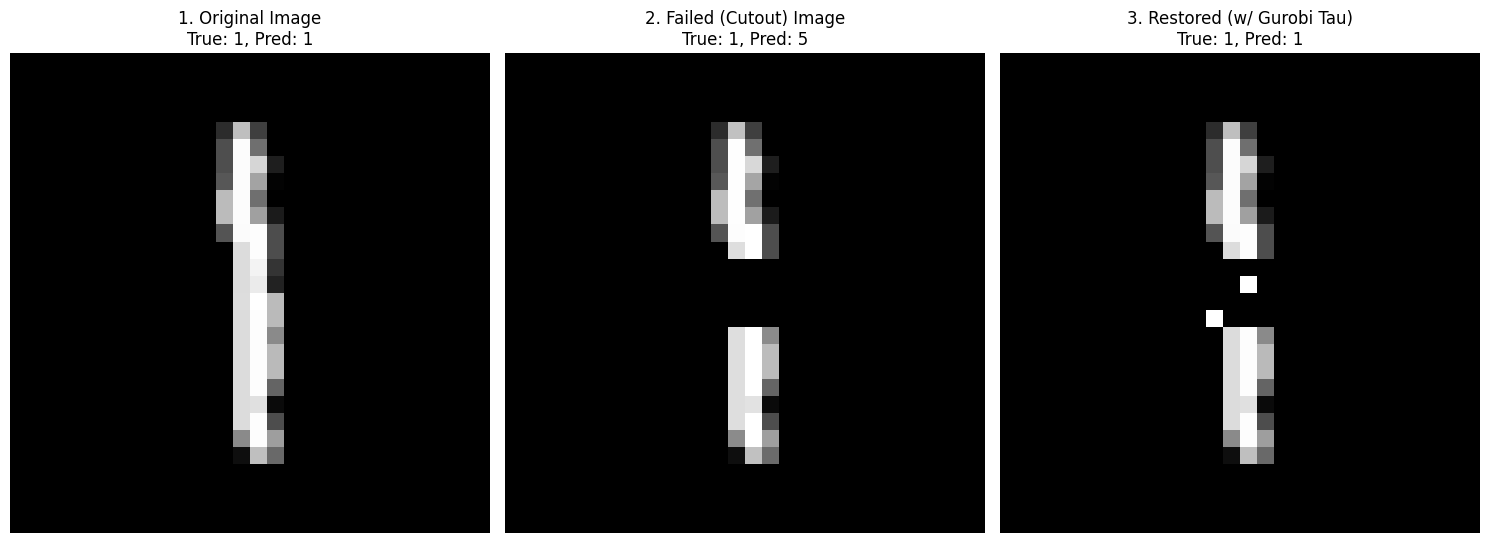


--- TEST 15/100: Image Index 1180 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1239
Always active (L/U)      : 7394
Ambiguous ReLUs          : 775
ReLU binary variables    : 775
Binaries eliminated      : 8633
Binary reduction        : 91.76%
Starting optimized Gurobi optimization...
Solve time: 0.6121 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1180 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


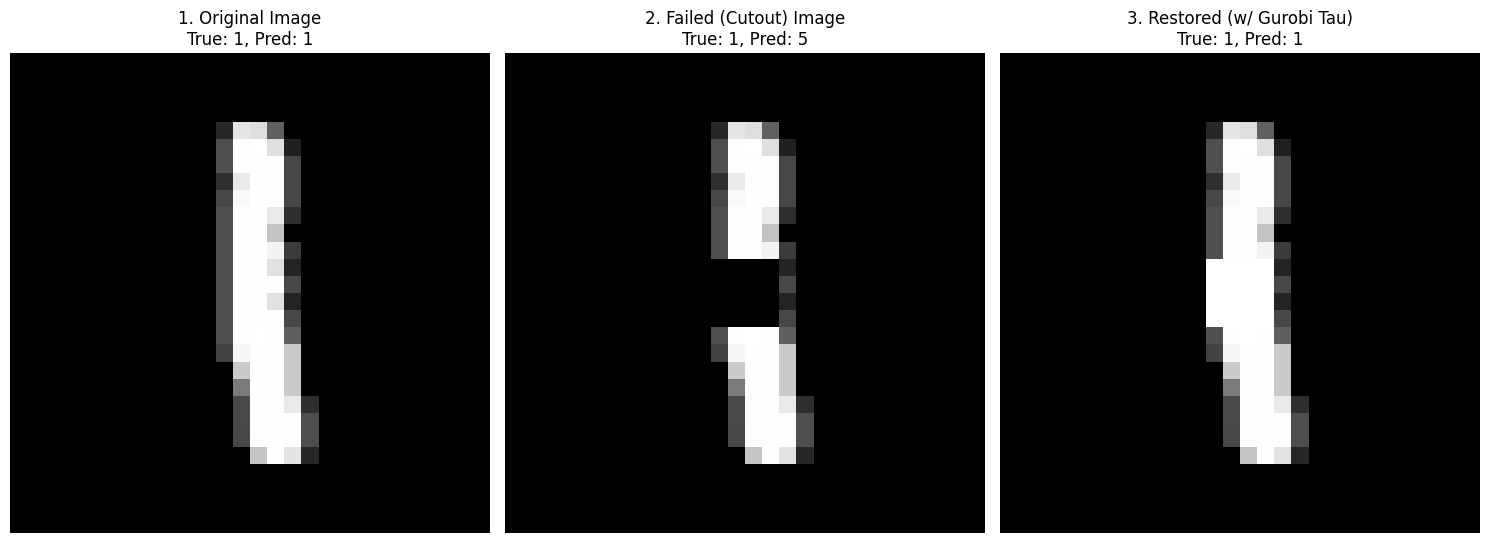


--- TEST 16/100: Image Index 1192 ---
Running Gurobi to find corrective 'tau' patch for target 9...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1291
Always active (L/U)      : 7319
Ambiguous ReLUs          : 798
ReLU binary variables    : 798
Binaries eliminated      : 8610
Binary reduction        : 91.52%
Starting optimized Gurobi optimization...
Solve time: 1.7792 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1192 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


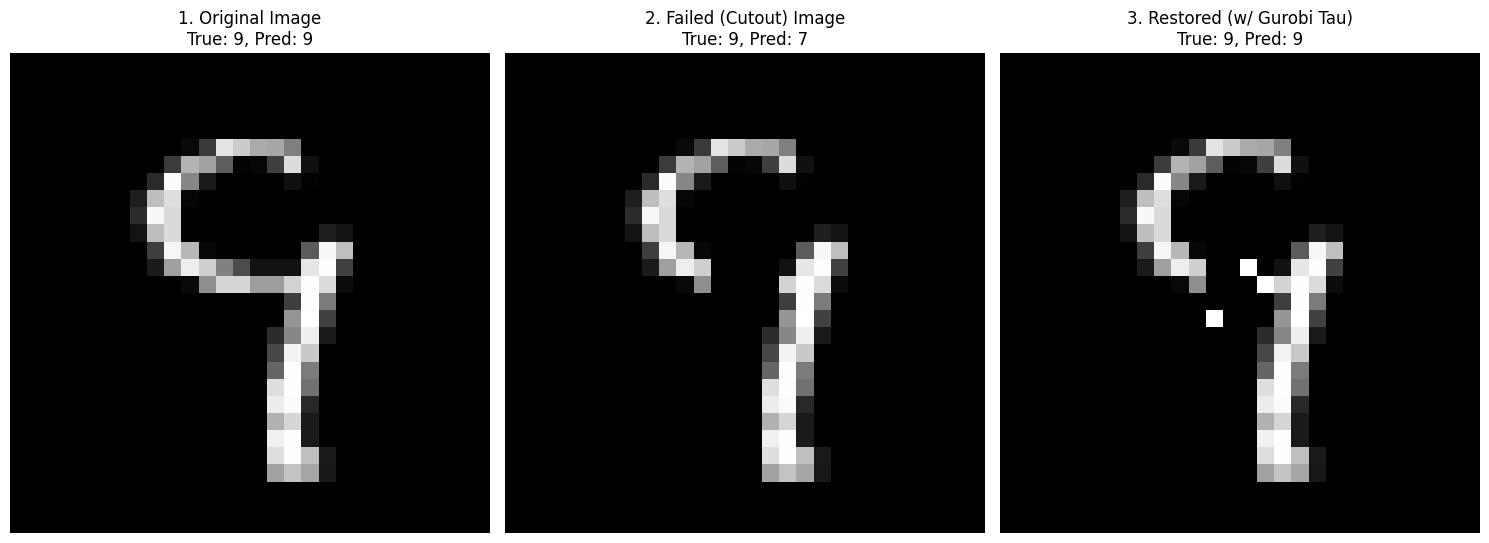


--- TEST 17/100: Image Index 1201 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1189
Always active (L/U)      : 7444
Ambiguous ReLUs          : 775
ReLU binary variables    : 775
Binaries eliminated      : 8633
Binary reduction        : 91.76%
Starting optimized Gurobi optimization...
Solve time: 0.6801 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1201 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


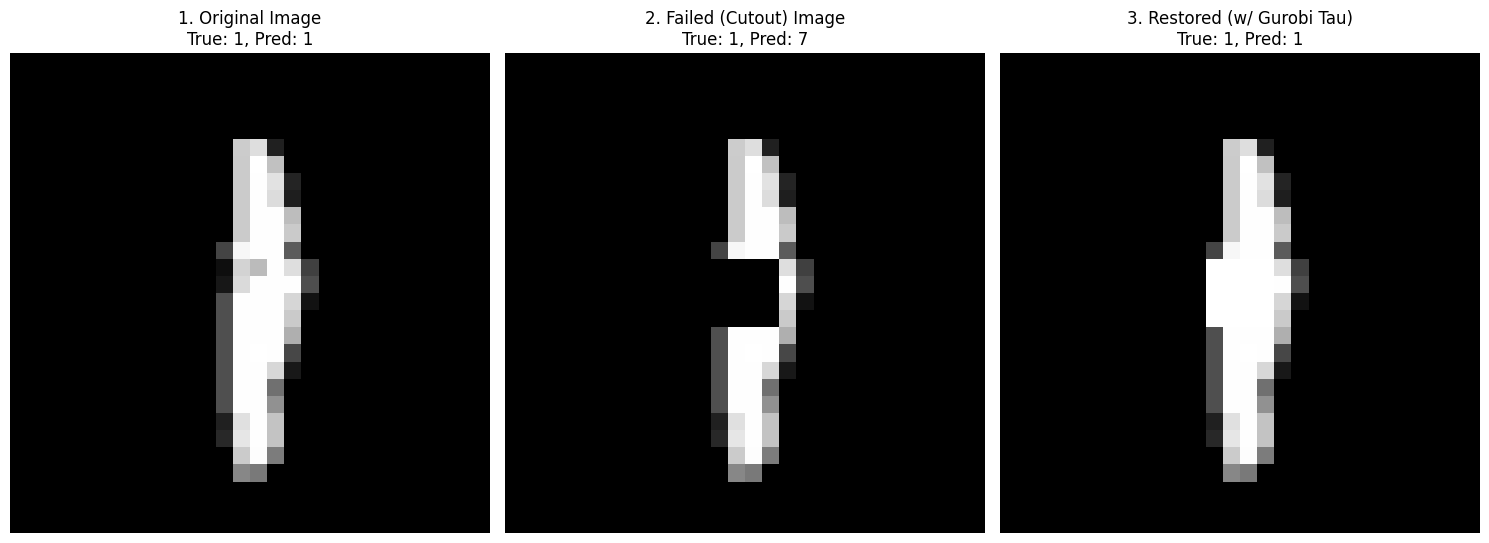


--- TEST 18/100: Image Index 1214 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1228
Always active (L/U)      : 7424
Ambiguous ReLUs          : 756
ReLU binary variables    : 756
Binaries eliminated      : 8652
Binary reduction        : 91.96%
Starting optimized Gurobi optimization...
Solve time: 65.5702 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1214 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


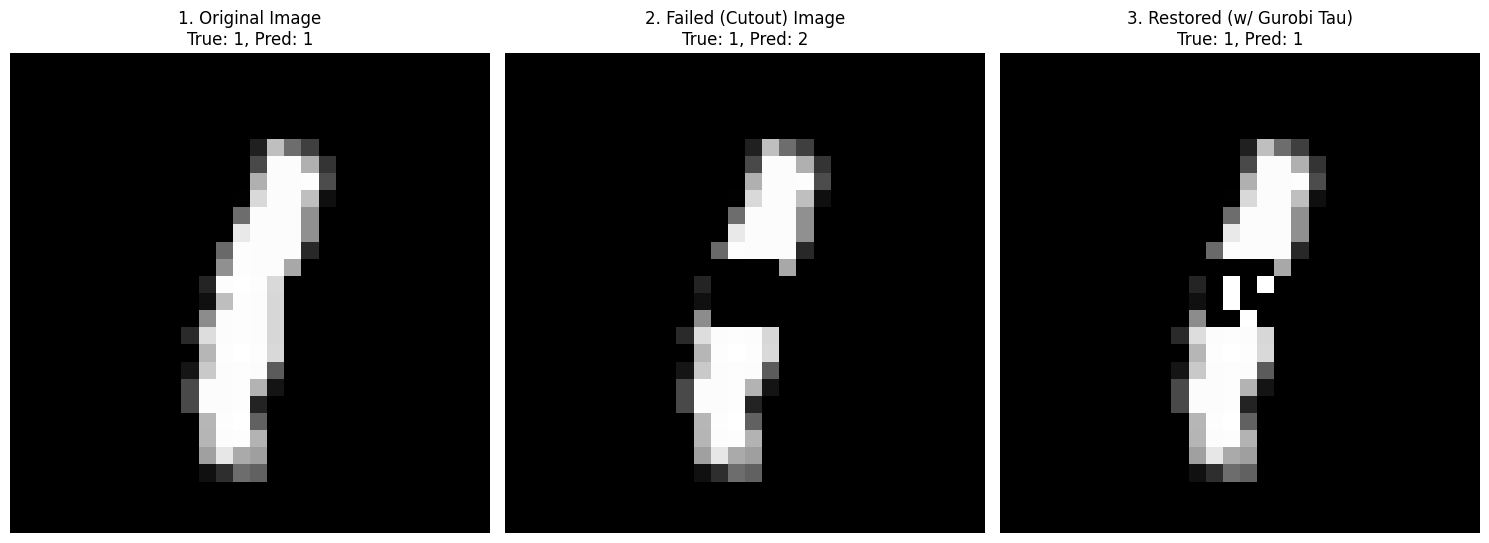


--- TEST 19/100: Image Index 1240 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1219
Always active (L/U)      : 7474
Ambiguous ReLUs          : 715
ReLU binary variables    : 715
Binaries eliminated      : 8693
Binary reduction        : 92.40%
Starting optimized Gurobi optimization...
Solve time: 0.6392 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1240 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   9 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


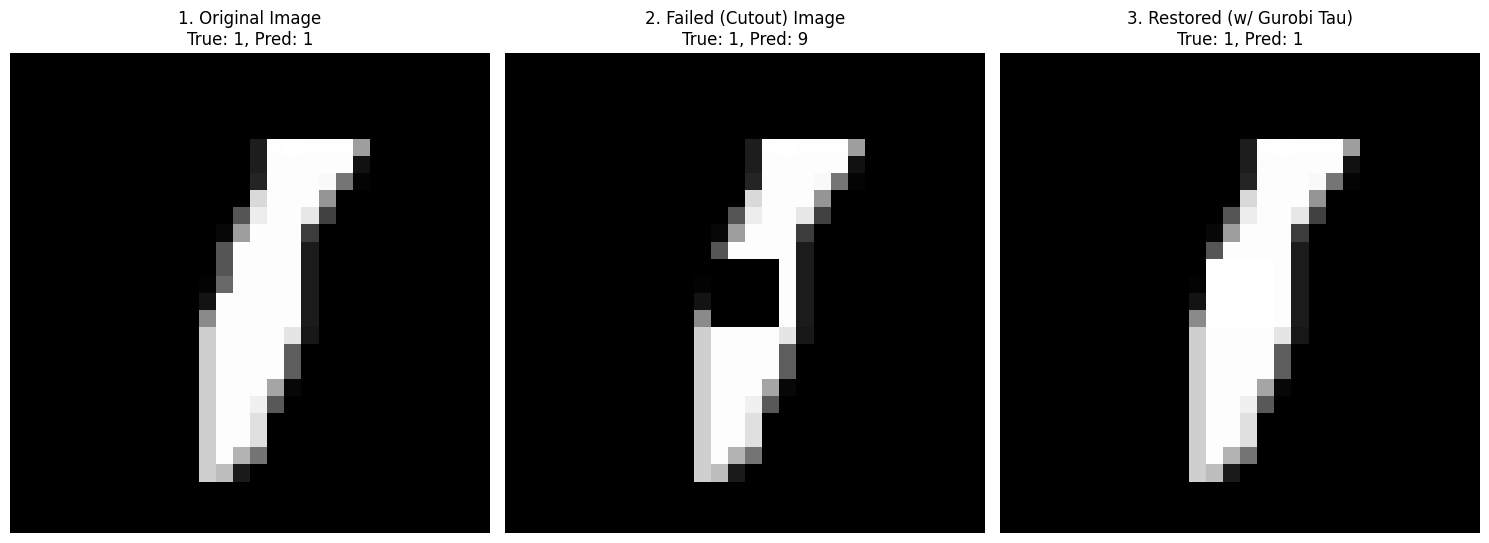


--- TEST 20/100: Image Index 1257 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1167
Always active (L/U)      : 7329
Ambiguous ReLUs          : 912
ReLU binary variables    : 912
Binaries eliminated      : 8496
Binary reduction        : 90.31%
Starting optimized Gurobi optimization...
Solve time: 30.1503 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1257 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


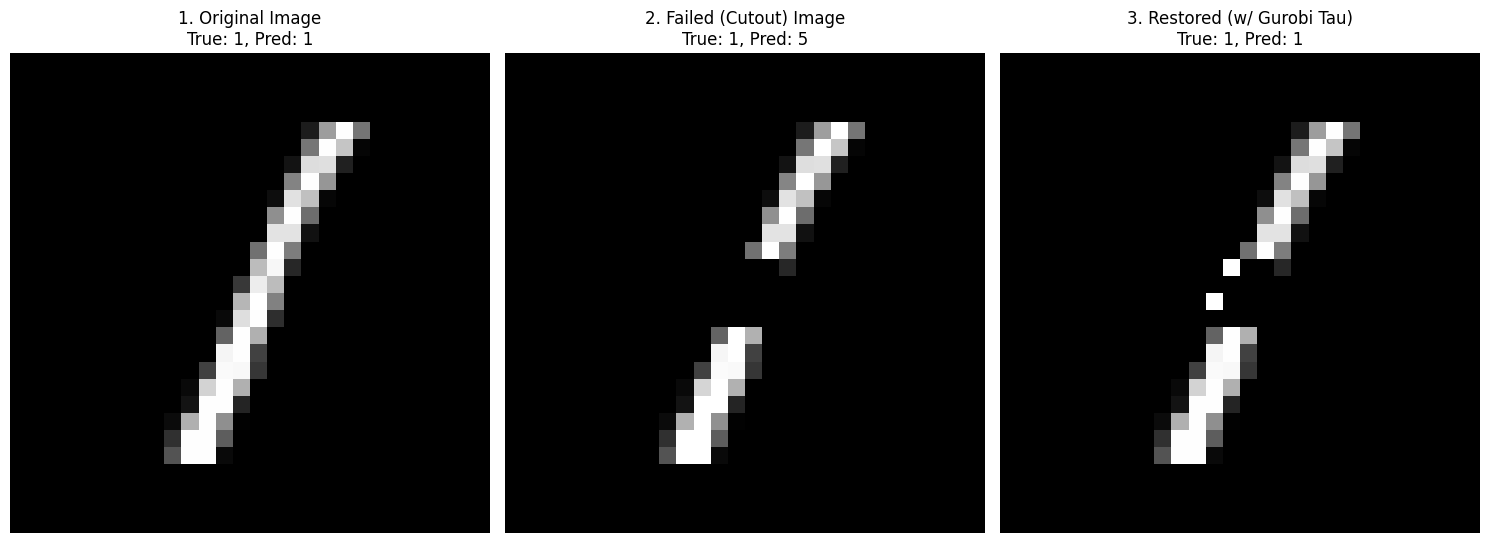


--- TEST 21/100: Image Index 1270 ---
Running Gurobi to find corrective 'tau' patch for target 4...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1268
Always active (L/U)      : 7431
Ambiguous ReLUs          : 709
ReLU binary variables    : 709
Binaries eliminated      : 8699
Binary reduction        : 92.46%
Starting optimized Gurobi optimization...
Solve time: 0.6511 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1270 - True Label: 4
  Prediction (Original): 4 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 4 (Correct)
----------------------------------------


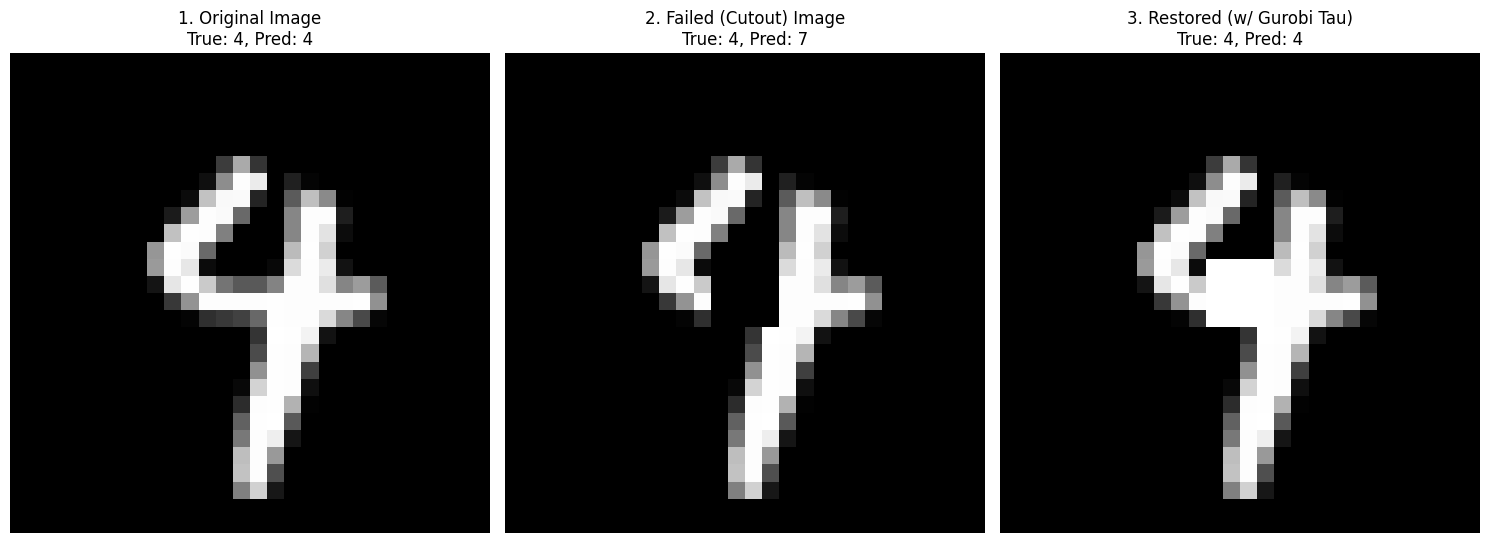


--- TEST 22/100: Image Index 1305 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1202
Always active (L/U)      : 7370
Ambiguous ReLUs          : 836
ReLU binary variables    : 836
Binaries eliminated      : 8572
Binary reduction        : 91.11%
Starting optimized Gurobi optimization...
Solve time: 4.2244 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1305 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


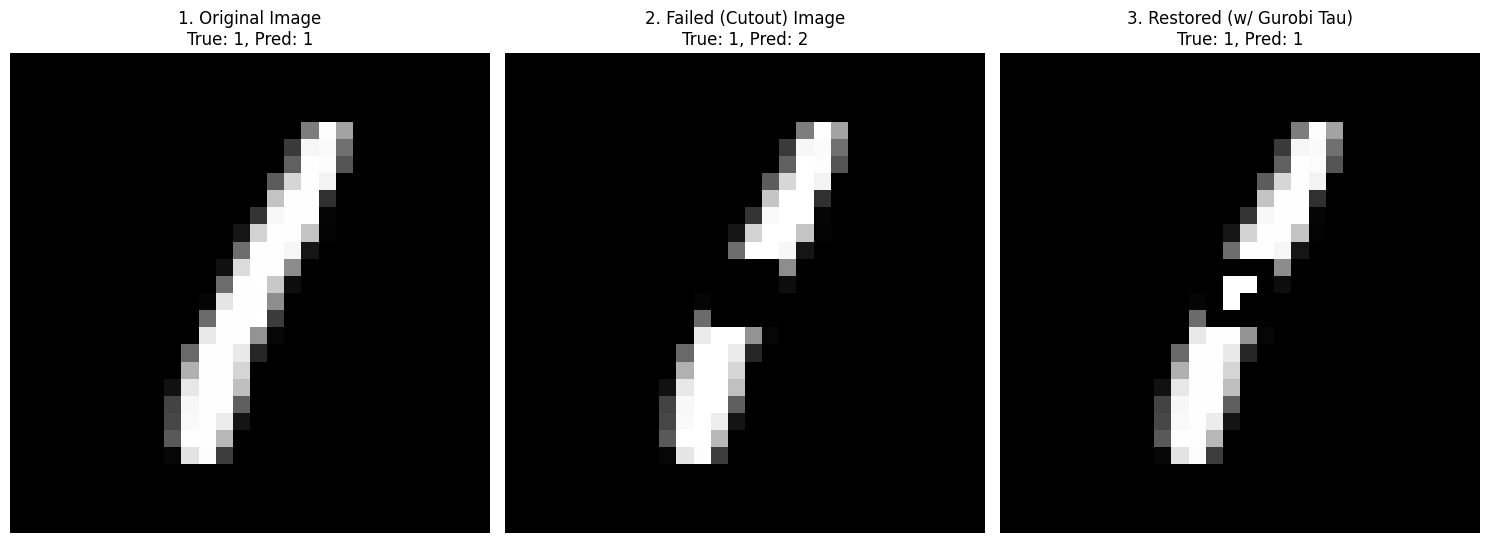


--- TEST 23/100: Image Index 1318 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1190
Always active (L/U)      : 7419
Ambiguous ReLUs          : 799
ReLU binary variables    : 799
Binaries eliminated      : 8609
Binary reduction        : 91.51%
Starting optimized Gurobi optimization...
Solve time: 0.6420 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1318 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


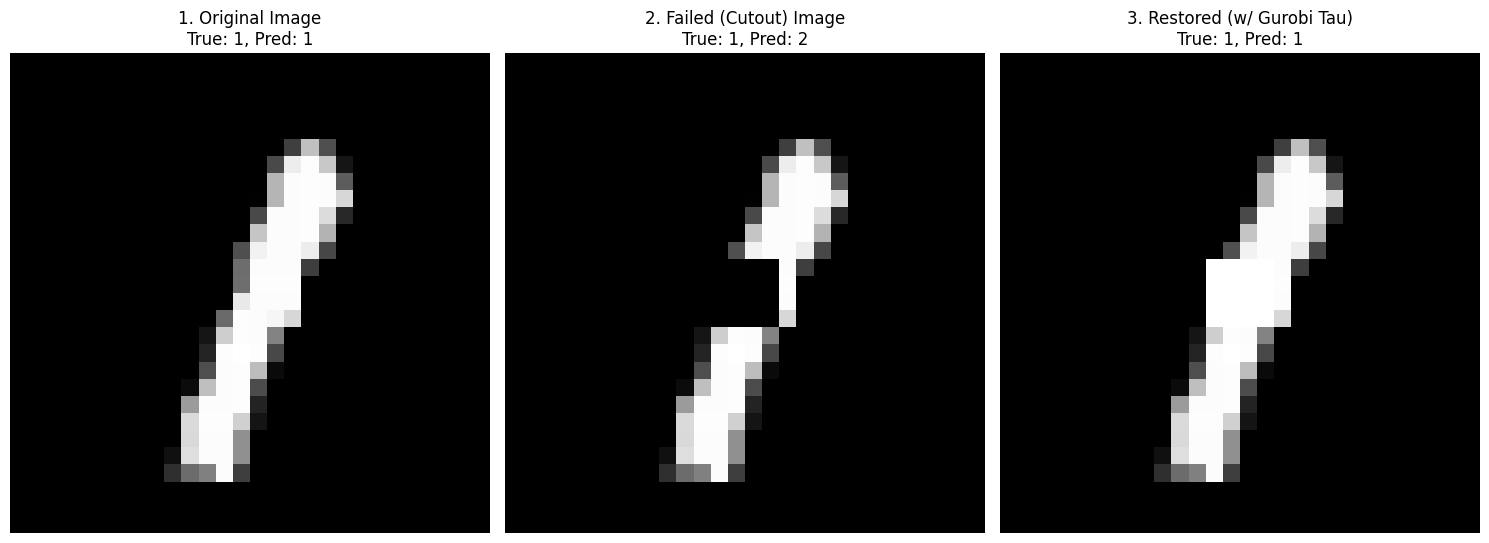


--- TEST 24/100: Image Index 1338 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1194
Always active (L/U)      : 7362
Ambiguous ReLUs          : 852
ReLU binary variables    : 852
Binaries eliminated      : 8556
Binary reduction        : 90.94%
Starting optimized Gurobi optimization...
Solve time: 20.1856 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1338 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


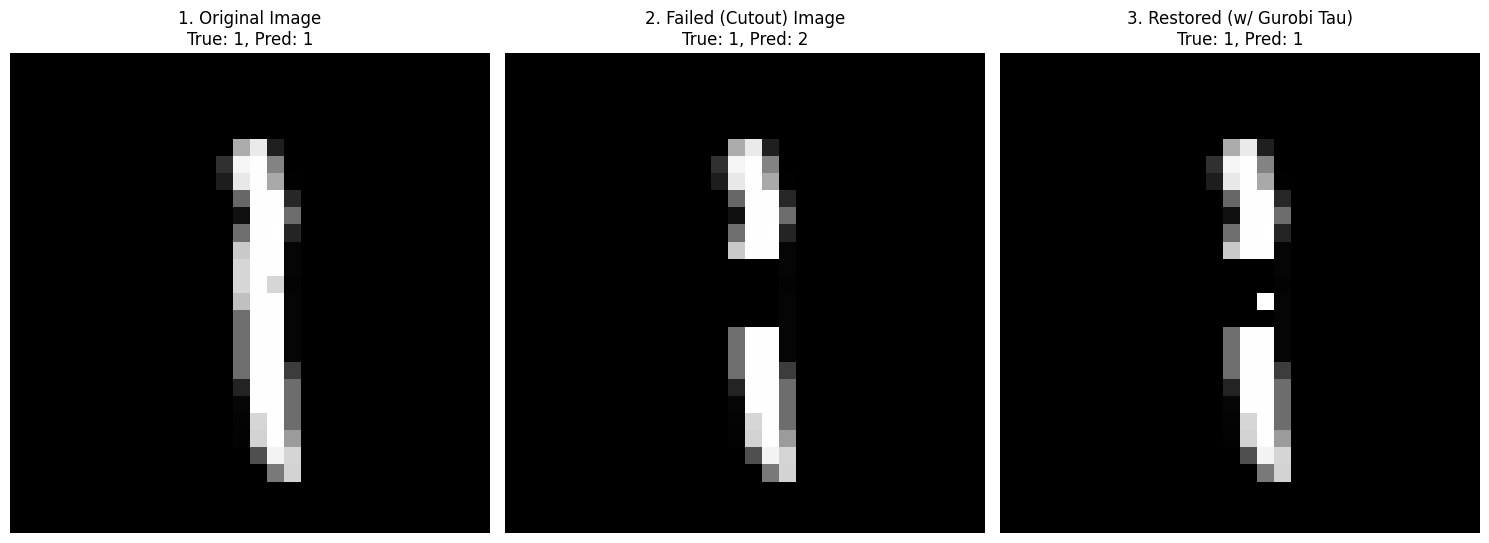


--- TEST 25/100: Image Index 135 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1212
Always active (L/U)      : 7407
Ambiguous ReLUs          : 789
ReLU binary variables    : 789
Binaries eliminated      : 8619
Binary reduction        : 91.61%
Starting optimized Gurobi optimization...
Solve time: 0.8033 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 135 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   3 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


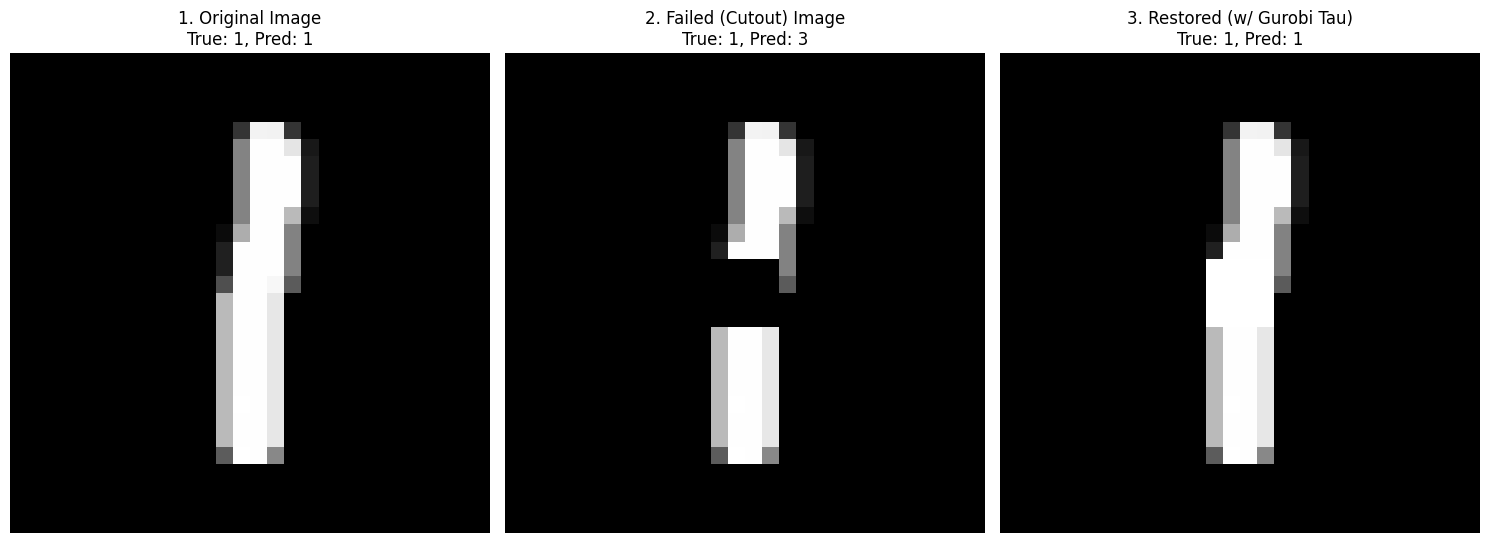


--- TEST 26/100: Image Index 1351 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1222
Always active (L/U)      : 7406
Ambiguous ReLUs          : 780
ReLU binary variables    : 780
Binaries eliminated      : 8628
Binary reduction        : 91.71%
Starting optimized Gurobi optimization...
Solve time: 6.9605 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1351 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


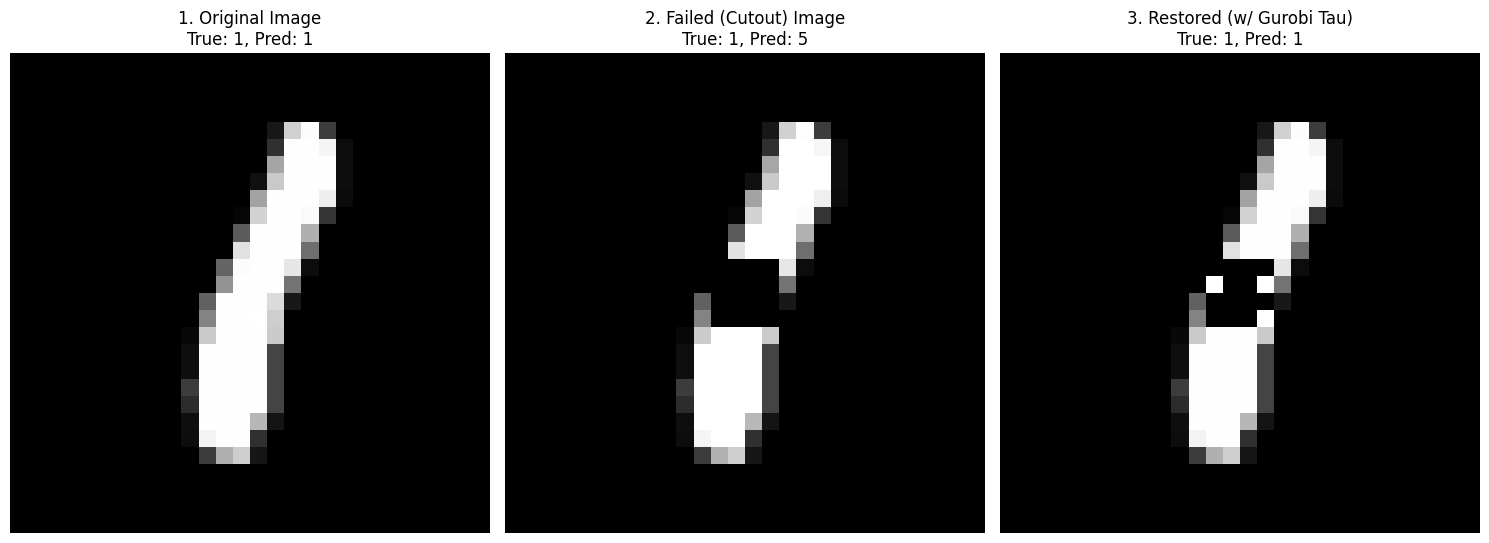


--- TEST 27/100: Image Index 137 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1252
Always active (L/U)      : 7389
Ambiguous ReLUs          : 767
ReLU binary variables    : 767
Binaries eliminated      : 8641
Binary reduction        : 91.85%
Starting optimized Gurobi optimization...
Solve time: 0.7158 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 137 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


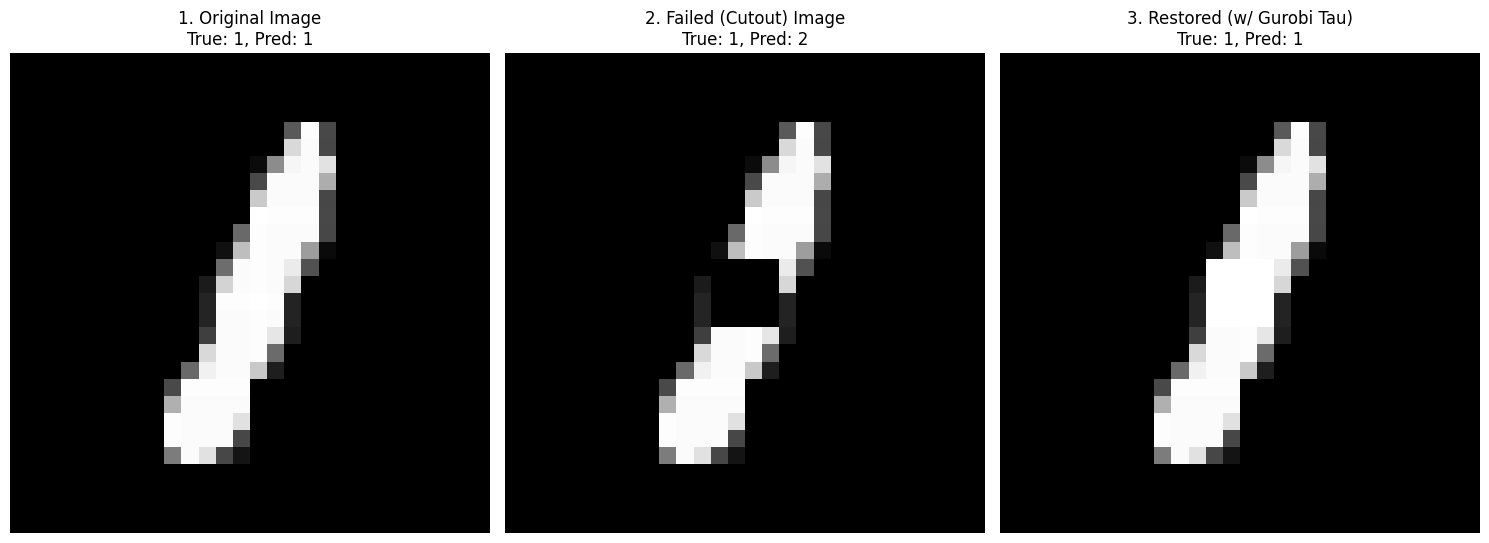


--- TEST 28/100: Image Index 14 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1227
Always active (L/U)      : 7391
Ambiguous ReLUs          : 790
ReLU binary variables    : 790
Binaries eliminated      : 8618
Binary reduction        : 91.60%
Starting optimized Gurobi optimization...
Solve time: 0.5487 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 14 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


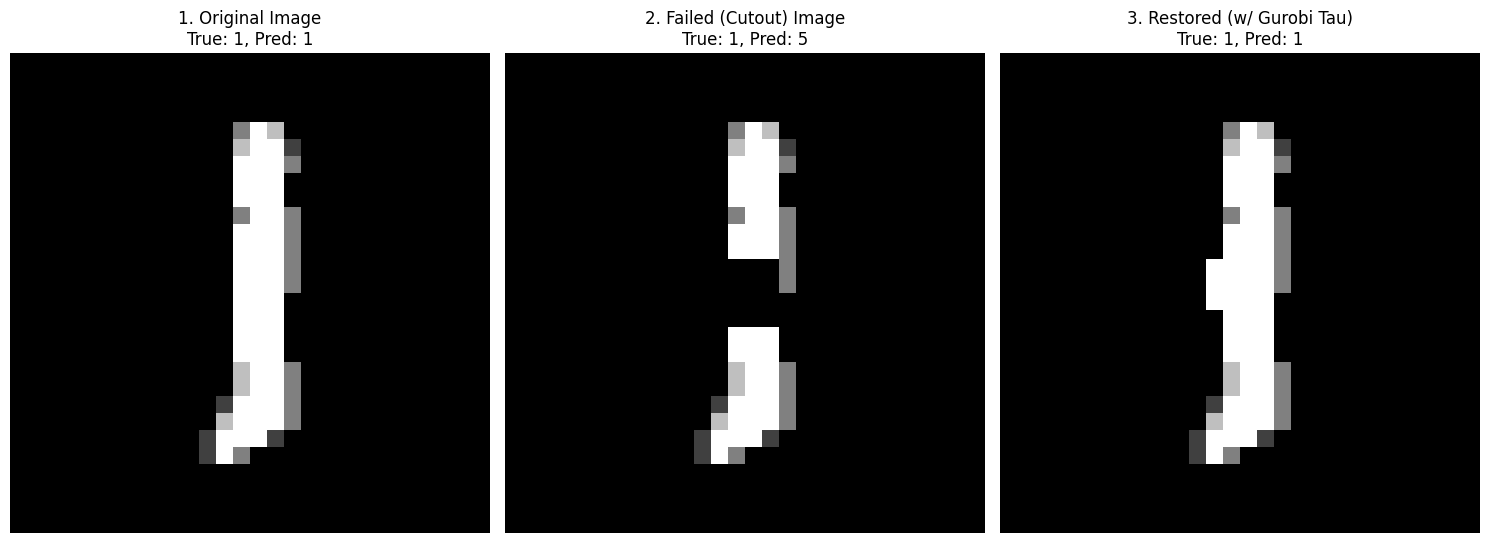


--- TEST 29/100: Image Index 1403 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1258
Always active (L/U)      : 7300
Ambiguous ReLUs          : 850
ReLU binary variables    : 850
Binaries eliminated      : 8558
Binary reduction        : 90.97%
Starting optimized Gurobi optimization...
Solve time: 0.5944 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1403 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   6 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


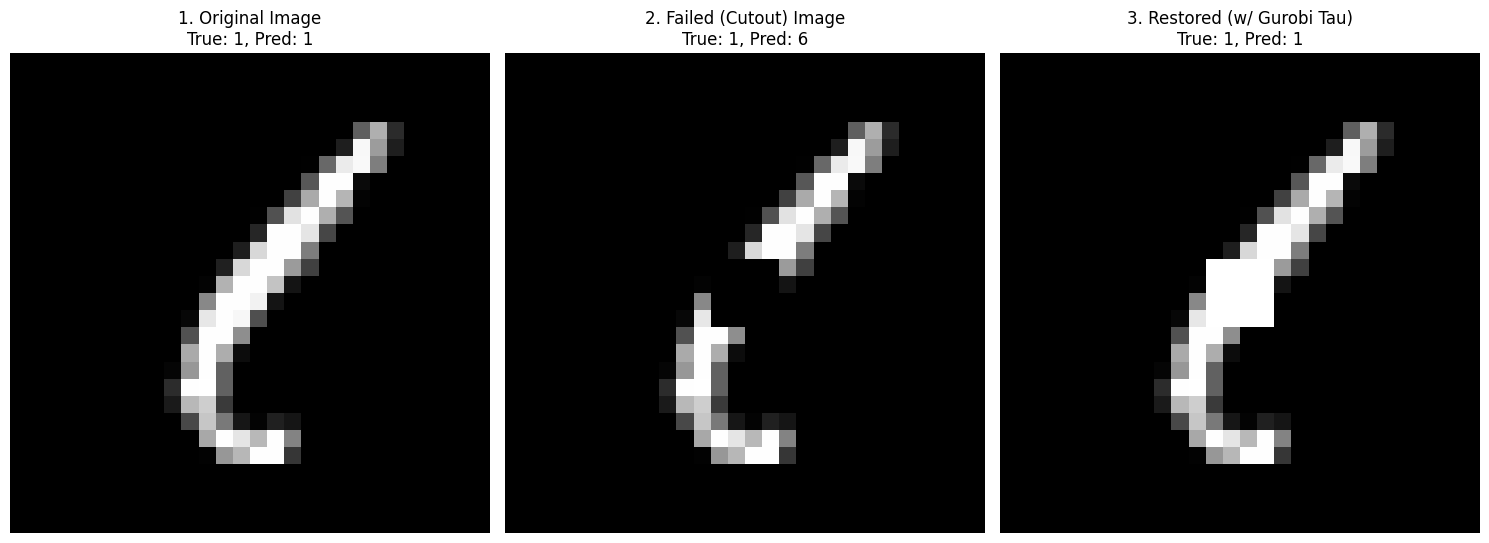


--- TEST 30/100: Image Index 1424 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1161
Always active (L/U)      : 7405
Ambiguous ReLUs          : 842
ReLU binary variables    : 842
Binaries eliminated      : 8566
Binary reduction        : 91.05%
Starting optimized Gurobi optimization...
Solve time: 0.6603 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1424 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


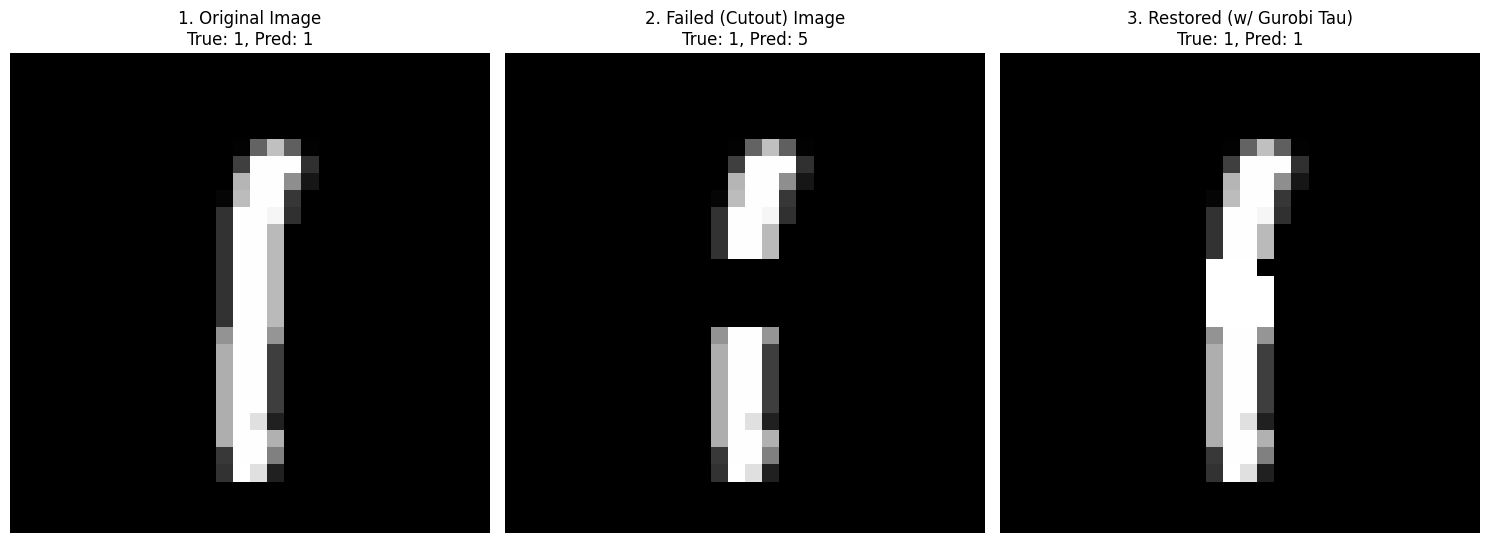


--- TEST 31/100: Image Index 1433 ---
Running Gurobi to find corrective 'tau' patch for target 8...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1340
Always active (L/U)      : 7405
Ambiguous ReLUs          : 663
ReLU binary variables    : 663
Binaries eliminated      : 8745
Binary reduction        : 92.95%
Starting optimized Gurobi optimization...
Solve time: 0.6142 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1433 - True Label: 8
  Prediction (Original): 8 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 8 (Correct)
----------------------------------------


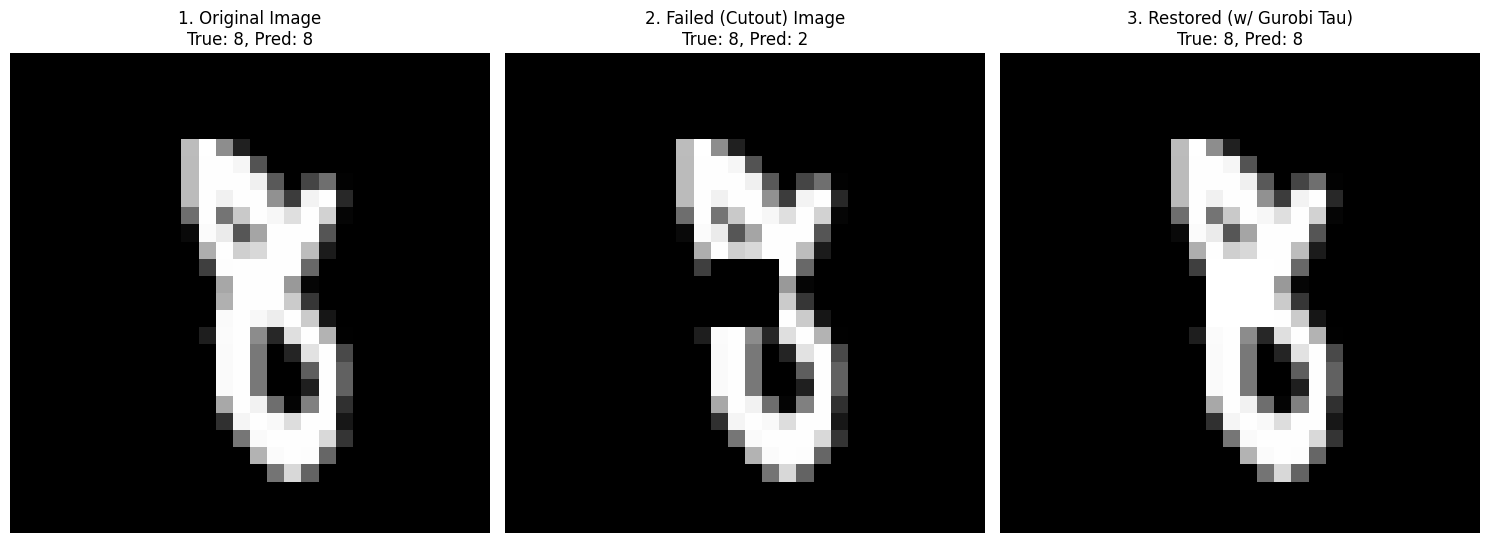


--- TEST 32/100: Image Index 1436 ---
Running Gurobi to find corrective 'tau' patch for target 6...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1354
Always active (L/U)      : 7338
Ambiguous ReLUs          : 716
ReLU binary variables    : 716
Binaries eliminated      : 8692
Binary reduction        : 92.39%
Starting optimized Gurobi optimization...
Solve time: 48.8942 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1436 - True Label: 6
  Prediction (Original): 6 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 6 (Correct)
----------------------------------------


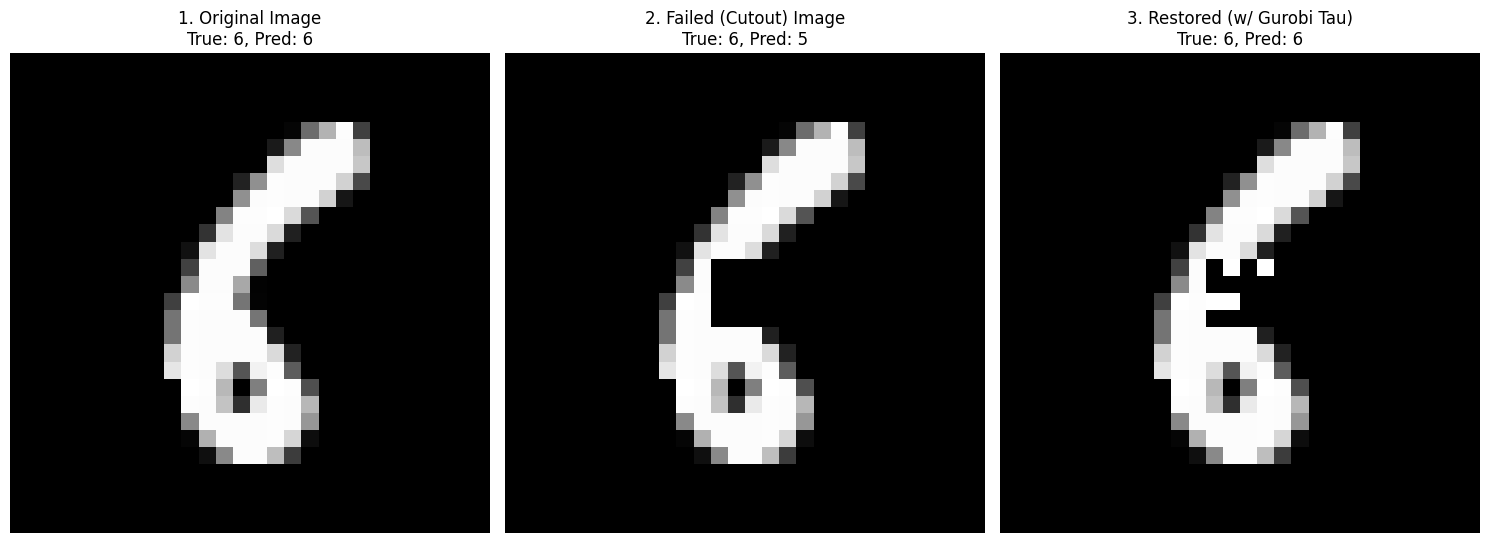


--- TEST 33/100: Image Index 1439 ---
Running Gurobi to find corrective 'tau' patch for target 9...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1180
Always active (L/U)      : 7474
Ambiguous ReLUs          : 754
ReLU binary variables    : 754
Binaries eliminated      : 8654
Binary reduction        : 91.99%
Starting optimized Gurobi optimization...
Solve time: 0.6941 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1439 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


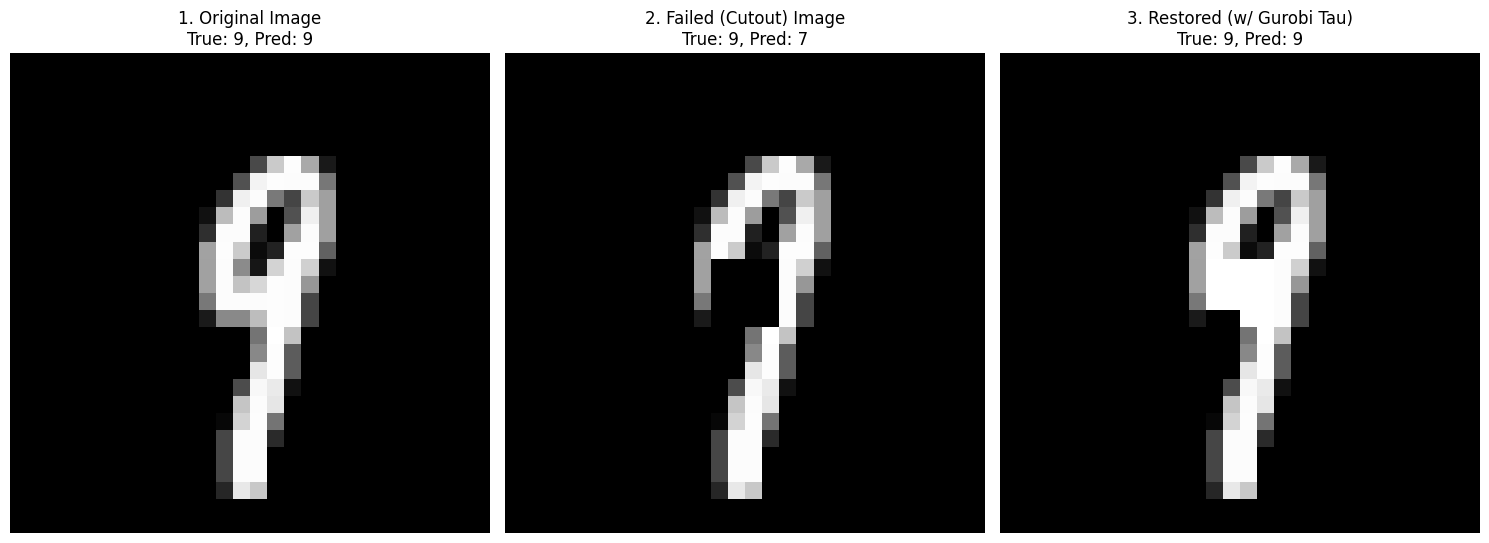


--- TEST 34/100: Image Index 1515 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1207
Always active (L/U)      : 7437
Ambiguous ReLUs          : 764
ReLU binary variables    : 764
Binaries eliminated      : 8644
Binary reduction        : 91.88%
Starting optimized Gurobi optimization...
Solve time: 14.8095 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1515 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   3 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


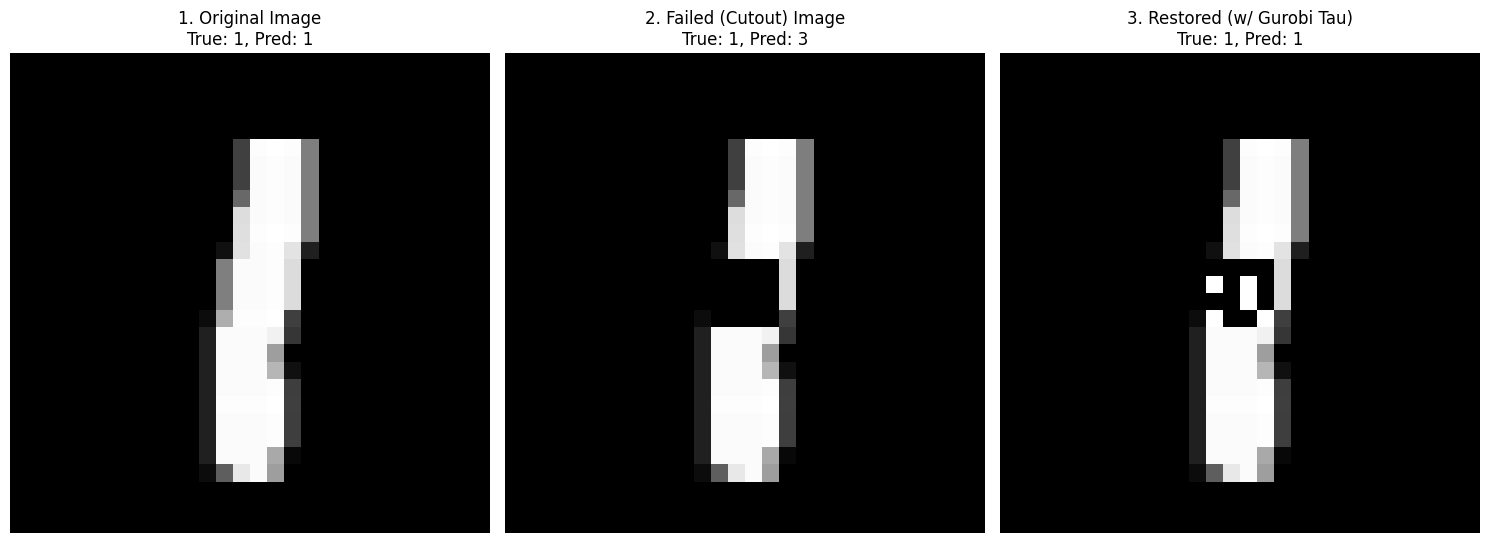


--- TEST 35/100: Image Index 1528 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1200
Always active (L/U)      : 7358
Ambiguous ReLUs          : 850
ReLU binary variables    : 850
Binaries eliminated      : 8558
Binary reduction        : 90.97%
Starting optimized Gurobi optimization...
Solve time: 1.9457 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1528 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


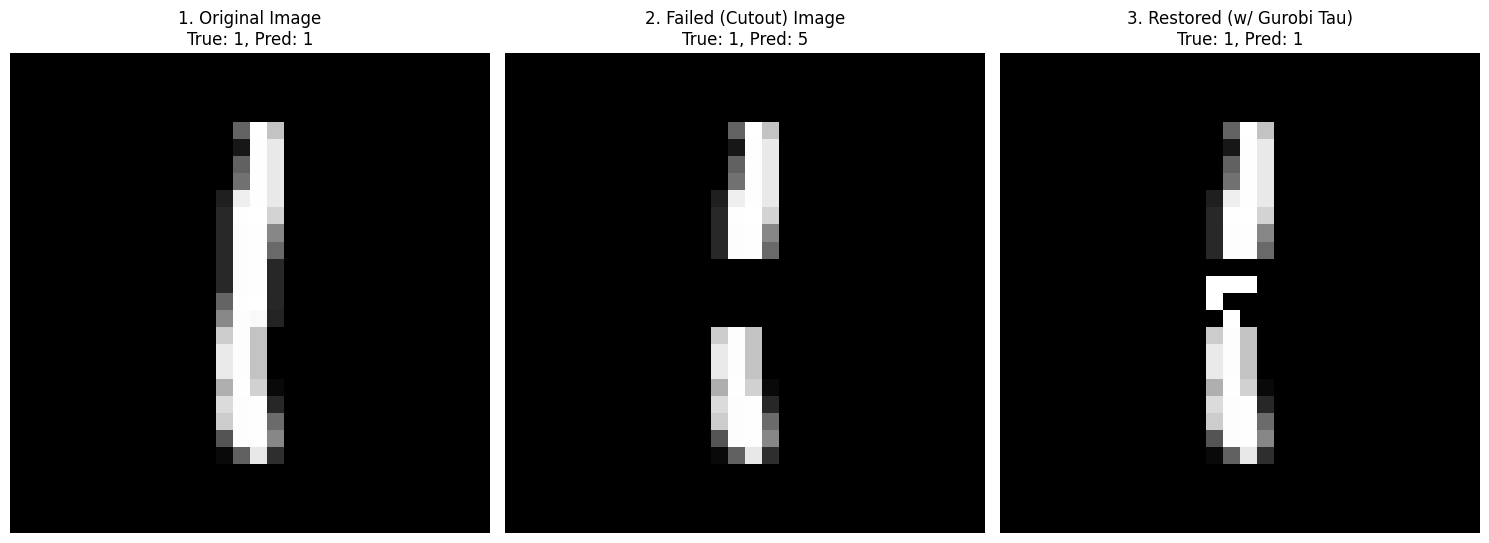


--- TEST 36/100: Image Index 1548 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1170
Always active (L/U)      : 7386
Ambiguous ReLUs          : 852
ReLU binary variables    : 852
Binaries eliminated      : 8556
Binary reduction        : 90.94%
Starting optimized Gurobi optimization...
Solve time: 0.6188 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1548 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


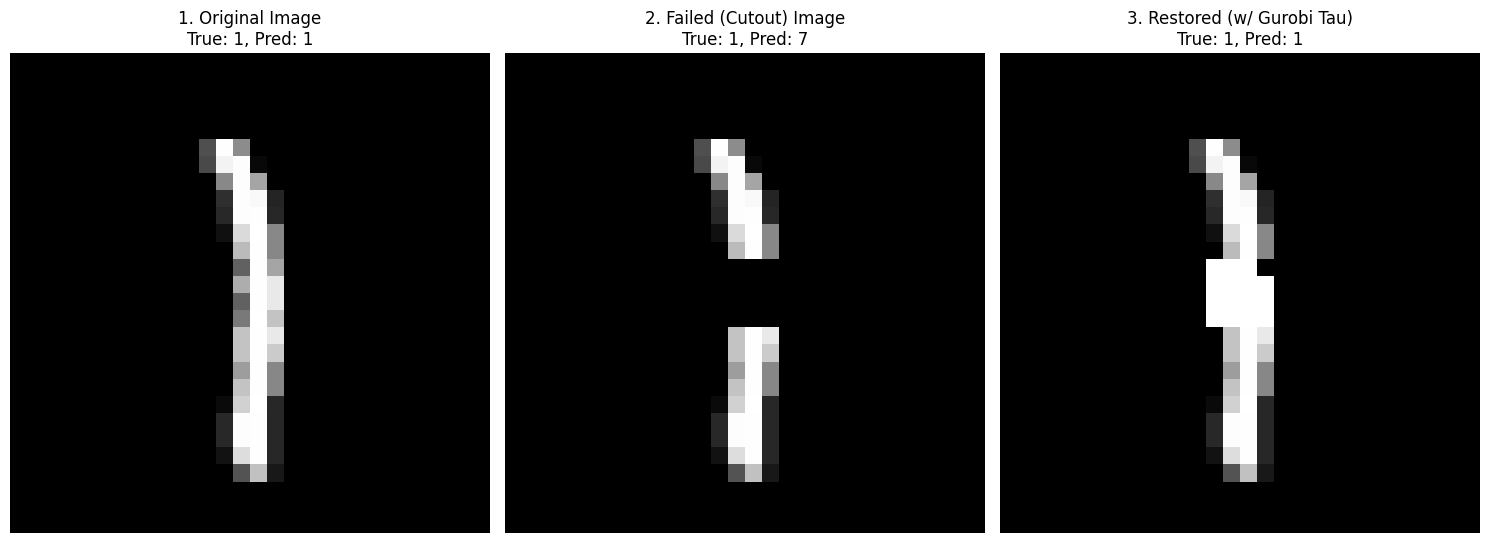


--- TEST 37/100: Image Index 1553 ---
Running Gurobi to find corrective 'tau' patch for target 9...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1438
Always active (L/U)      : 7302
Ambiguous ReLUs          : 668
ReLU binary variables    : 668
Binaries eliminated      : 8740
Binary reduction        : 92.90%
Starting optimized Gurobi optimization...
Solve time: 6.4922 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1553 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


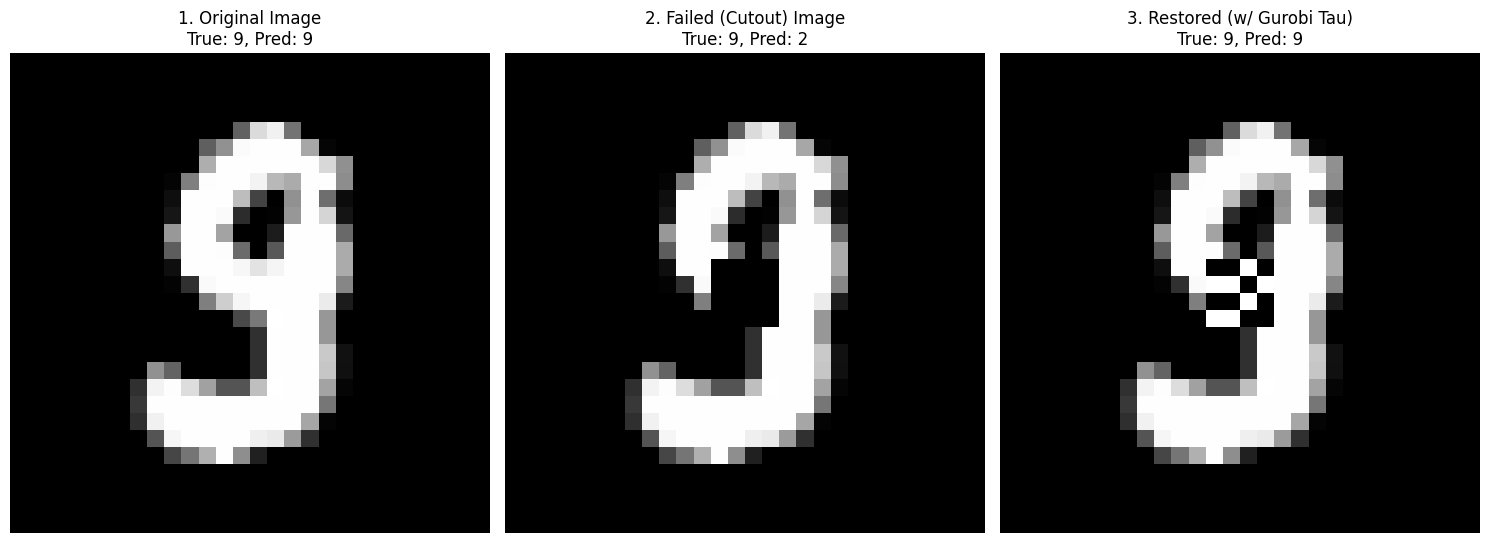


--- TEST 38/100: Image Index 179 ---
Running Gurobi to find corrective 'tau' patch for target 8...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1473
Always active (L/U)      : 7297
Ambiguous ReLUs          : 638
ReLU binary variables    : 638
Binaries eliminated      : 8770
Binary reduction        : 93.22%
Starting optimized Gurobi optimization...
Solve time: 59.0905 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 179 - True Label: 8
  Prediction (Original): 8 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 8 (Correct)
----------------------------------------


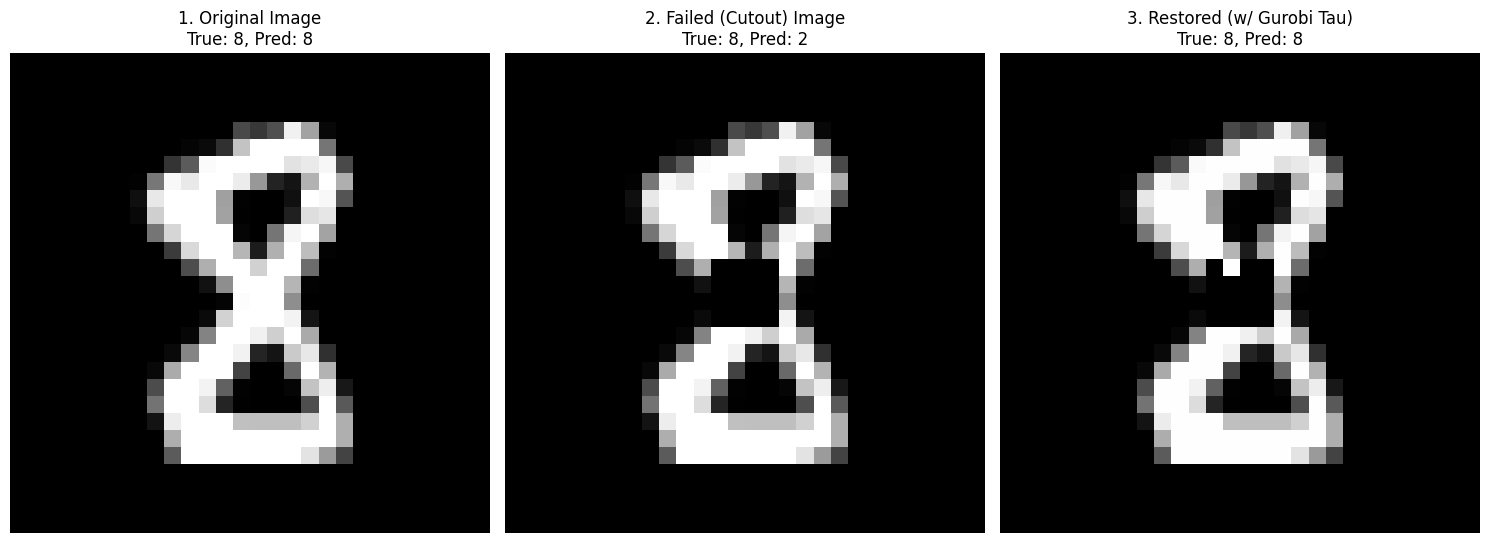


--- TEST 39/100: Image Index 18 ---
Running Gurobi to find corrective 'tau' patch for target 3...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1634
Always active (L/U)      : 7145
Ambiguous ReLUs          : 629
ReLU binary variables    : 629
Binaries eliminated      : 8779
Binary reduction        : 93.31%
Starting optimized Gurobi optimization...
Solve time: 600.2815 s
Gurobi status: 9
Time limit reached before a feasible solution was found.
Gurobi could not find a corrective patch for image 18.

--- TEST 40/100: Image Index 190 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1225
Always active (L/U)      : 7440
Ambiguous ReLUs          : 743
ReLU binary variables    : 743
Binaries eliminated      : 8665
Binary reduction        : 92.10%
Starting optimized Gurobi optimization...
Solve time: 69.5875 s
Gurobi status: 2
Gurobi found a sol

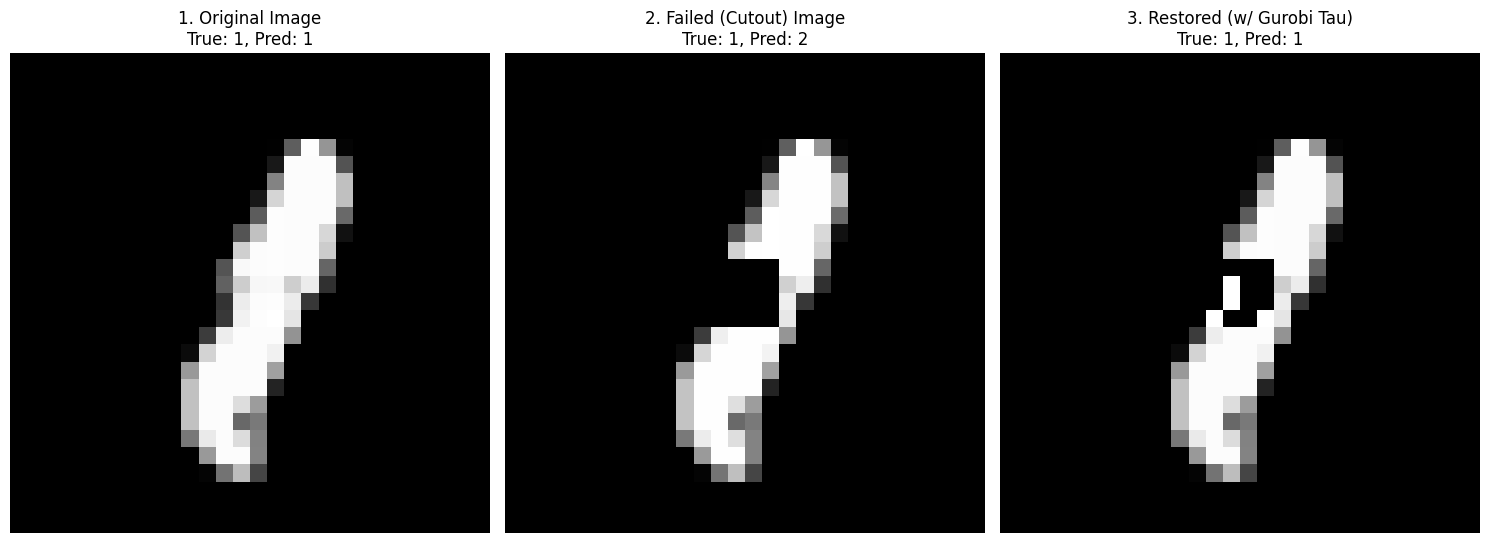


--- TEST 41/100: Image Index 196 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1240
Always active (L/U)      : 7410
Ambiguous ReLUs          : 758
ReLU binary variables    : 758
Binaries eliminated      : 8650
Binary reduction        : 91.94%
Starting optimized Gurobi optimization...
Solve time: 97.7508 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 196 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


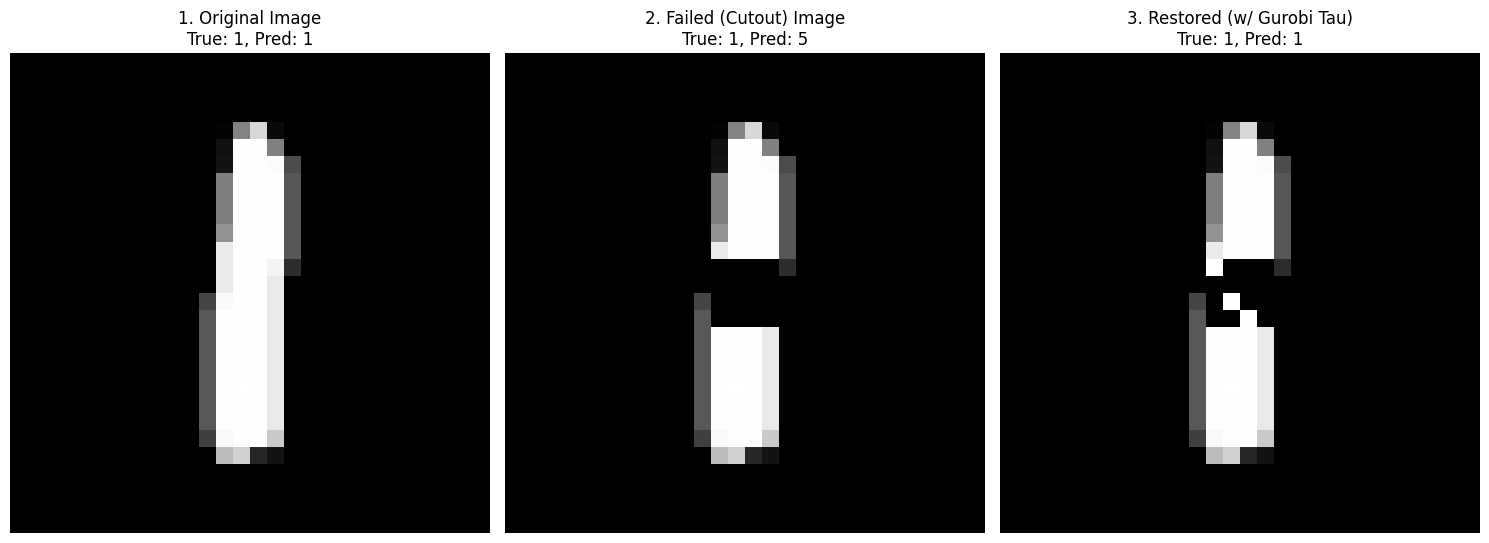


--- TEST 42/100: Image Index 2 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1150
Always active (L/U)      : 7352
Ambiguous ReLUs          : 906
ReLU binary variables    : 906
Binaries eliminated      : 8502
Binary reduction        : 90.37%
Starting optimized Gurobi optimization...
Solve time: 0.7802 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 2 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


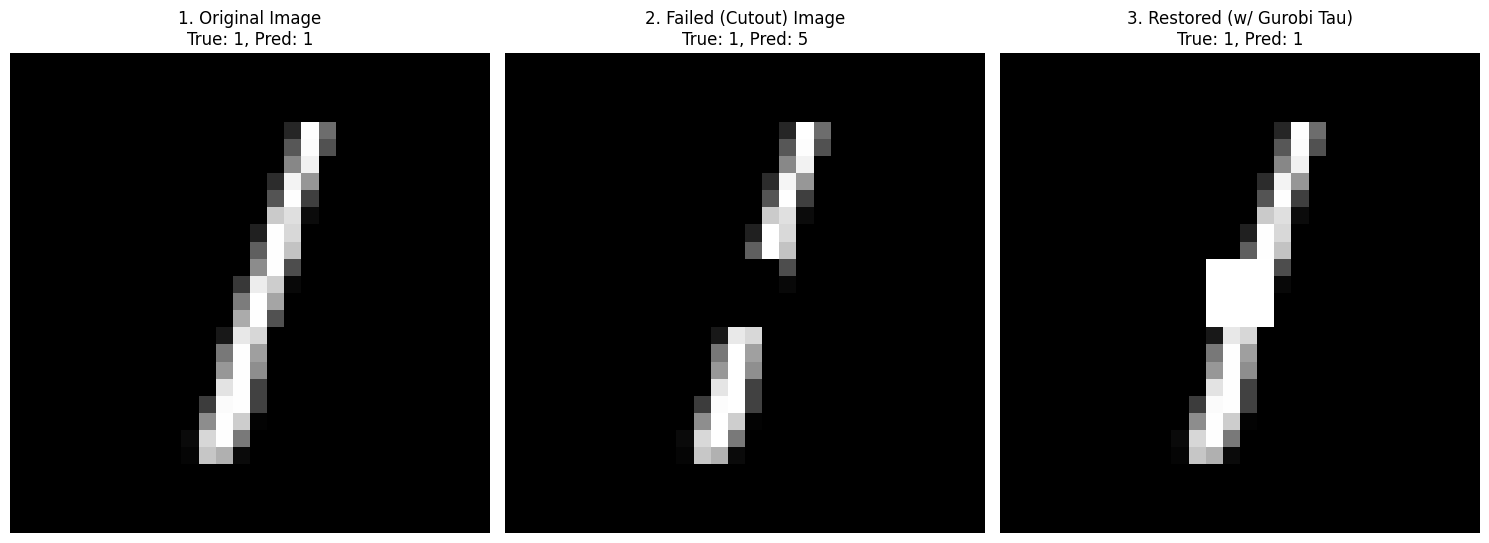


--- TEST 43/100: Image Index 20 ---
Running Gurobi to find corrective 'tau' patch for target 9...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1337
Always active (L/U)      : 7418
Ambiguous ReLUs          : 653
ReLU binary variables    : 653
Binaries eliminated      : 8755
Binary reduction        : 93.06%
Starting optimized Gurobi optimization...
Solve time: 98.6400 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 20 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


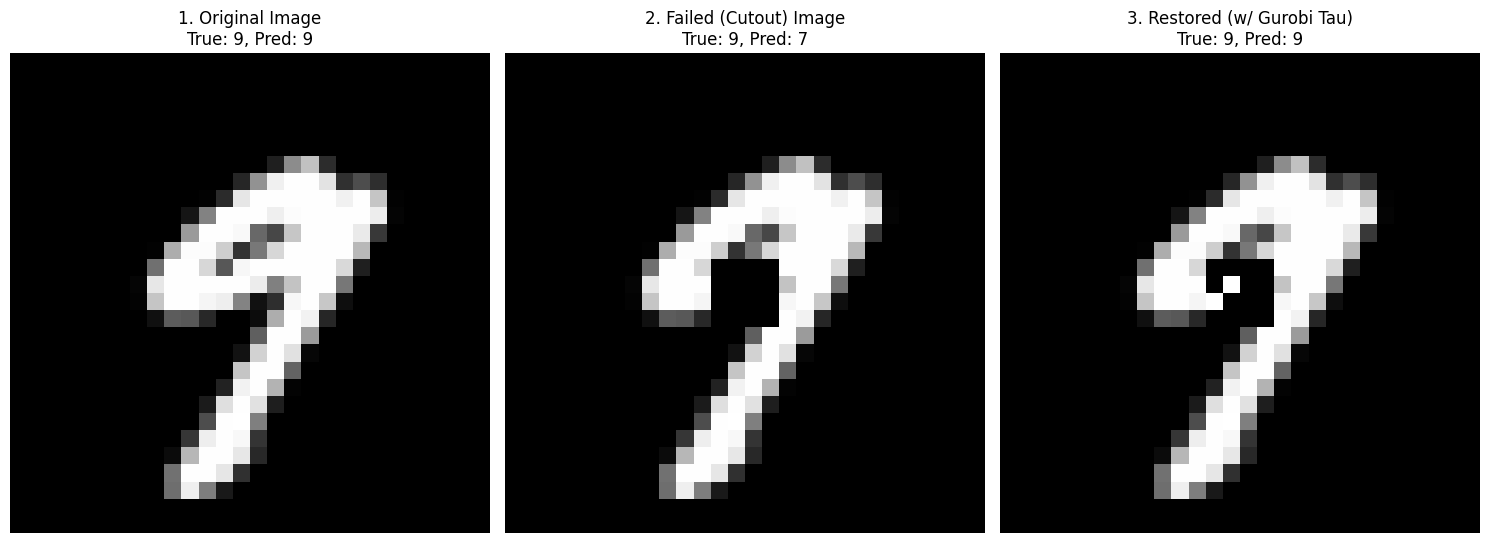


--- TEST 44/100: Image Index 209 ---
Running Gurobi to find corrective 'tau' patch for target 9...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1341
Always active (L/U)      : 7419
Ambiguous ReLUs          : 648
ReLU binary variables    : 648
Binaries eliminated      : 8760
Binary reduction        : 93.11%
Starting optimized Gurobi optimization...
Solve time: 65.9334 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 209 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


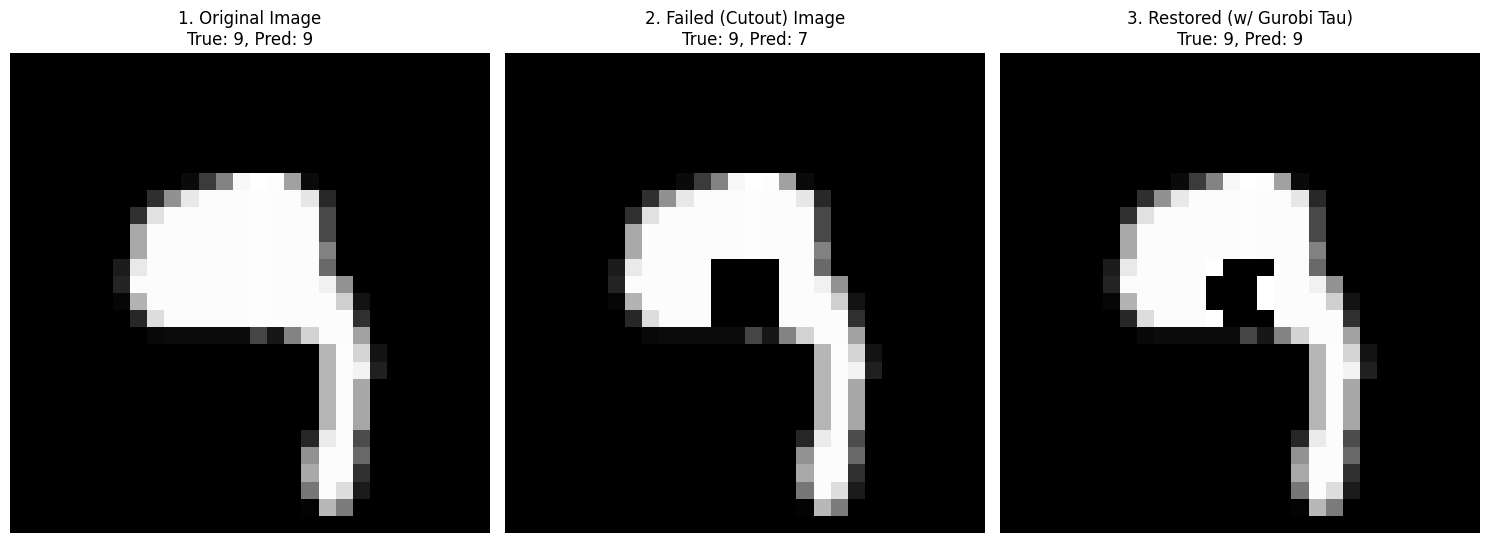


--- TEST 45/100: Image Index 228 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1173
Always active (L/U)      : 7366
Ambiguous ReLUs          : 869
ReLU binary variables    : 869
Binaries eliminated      : 8539
Binary reduction        : 90.76%
Starting optimized Gurobi optimization...
Solve time: 0.7137 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 228 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


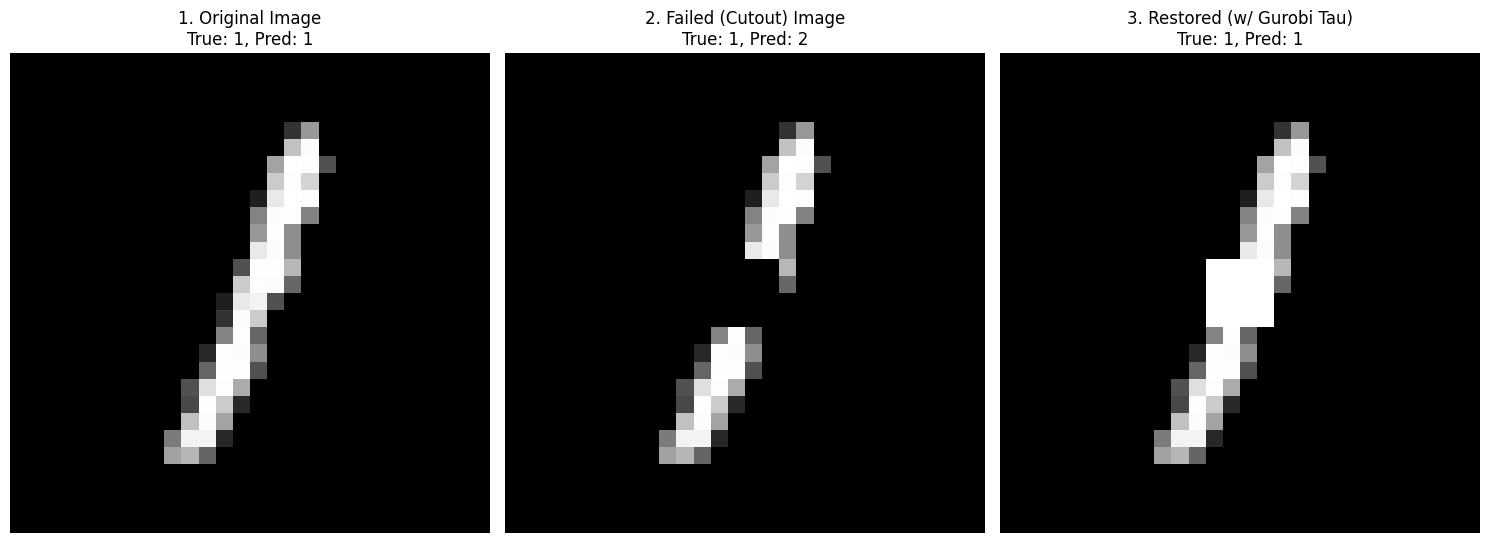


--- TEST 46/100: Image Index 265 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1238
Always active (L/U)      : 7392
Ambiguous ReLUs          : 778
ReLU binary variables    : 778
Binaries eliminated      : 8630
Binary reduction        : 91.73%
Starting optimized Gurobi optimization...
Solve time: 6.0571 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 265 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   3 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


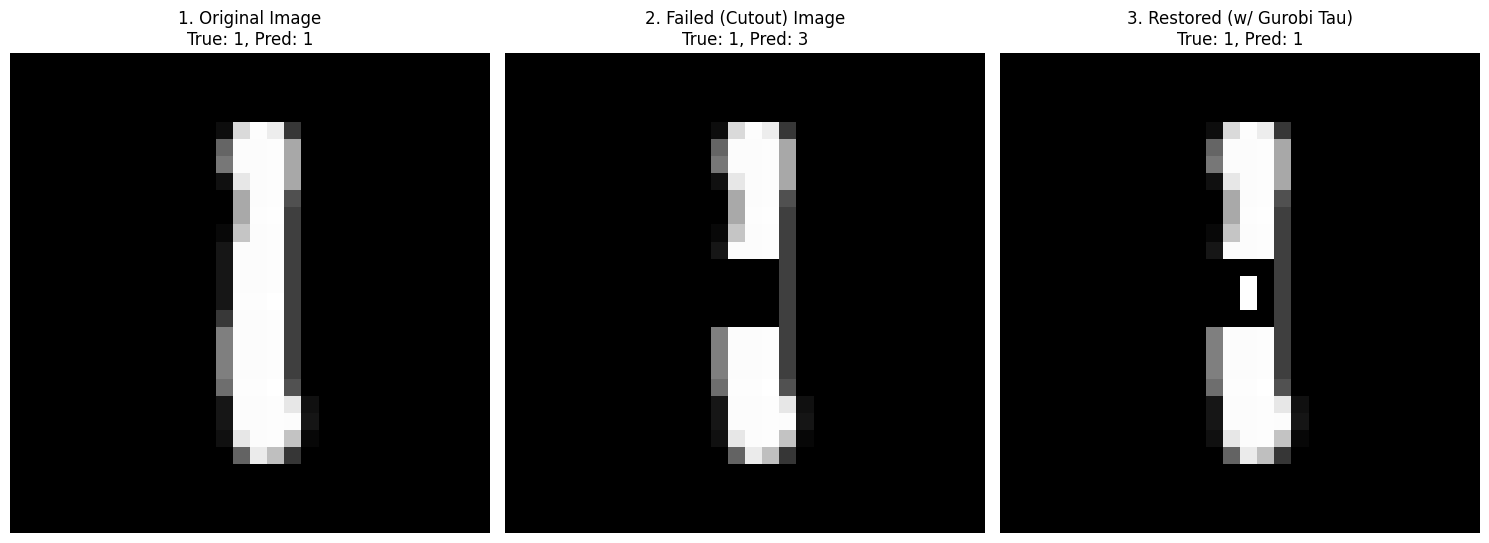


--- TEST 47/100: Image Index 266 ---
Running Gurobi to find corrective 'tau' patch for target 8...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1467
Always active (L/U)      : 7291
Ambiguous ReLUs          : 650
ReLU binary variables    : 650
Binaries eliminated      : 8758
Binary reduction        : 93.09%
Starting optimized Gurobi optimization...
Solve time: 0.7022 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 266 - True Label: 8
  Prediction (Original): 8 (Correct)
  Prediction (Failed):   0 (Incorrect)
  Prediction (Restored): 8 (Correct)
----------------------------------------


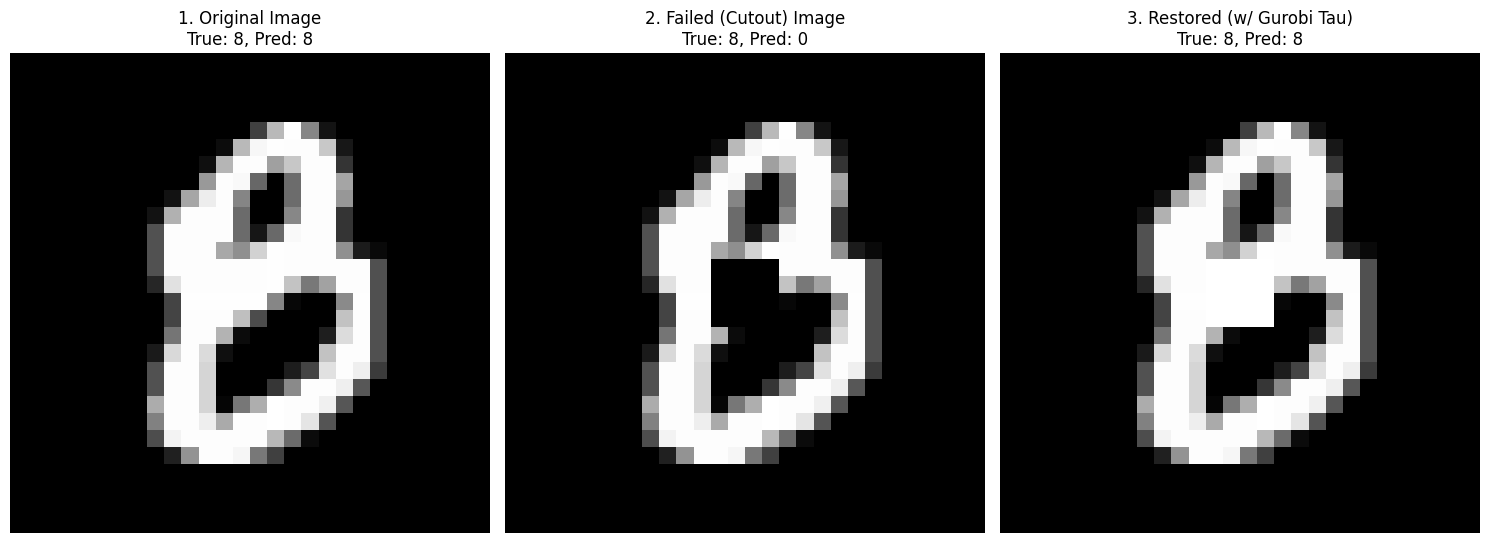


--- TEST 48/100: Image Index 288 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1158
Always active (L/U)      : 7423
Ambiguous ReLUs          : 827
ReLU binary variables    : 827
Binaries eliminated      : 8581
Binary reduction        : 91.21%
Starting optimized Gurobi optimization...
Solve time: 0.6990 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 288 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


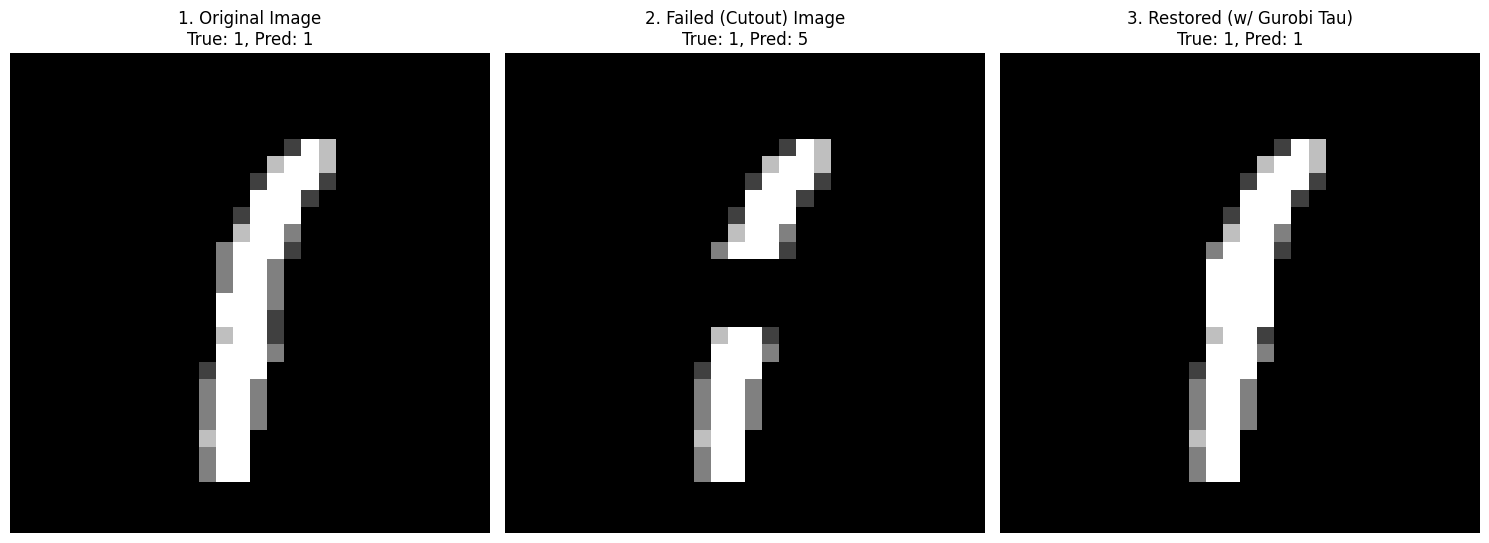


--- TEST 49/100: Image Index 314 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1193
Always active (L/U)      : 7393
Ambiguous ReLUs          : 822
ReLU binary variables    : 822
Binaries eliminated      : 8586
Binary reduction        : 91.26%
Starting optimized Gurobi optimization...
Solve time: 0.7640 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 314 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


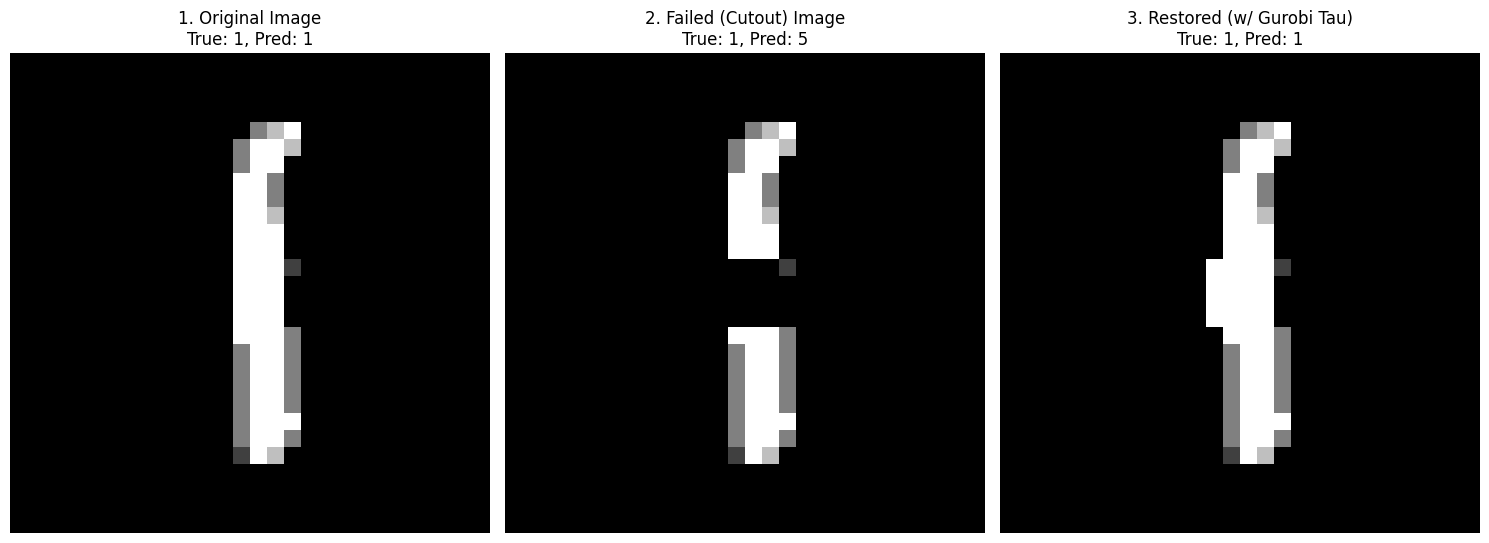


--- TEST 50/100: Image Index 320 ---
Running Gurobi to find corrective 'tau' patch for target 9...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1186
Always active (L/U)      : 7440
Ambiguous ReLUs          : 782
ReLU binary variables    : 782
Binaries eliminated      : 8626
Binary reduction        : 91.69%
Starting optimized Gurobi optimization...
Solve time: 0.6856 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 320 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


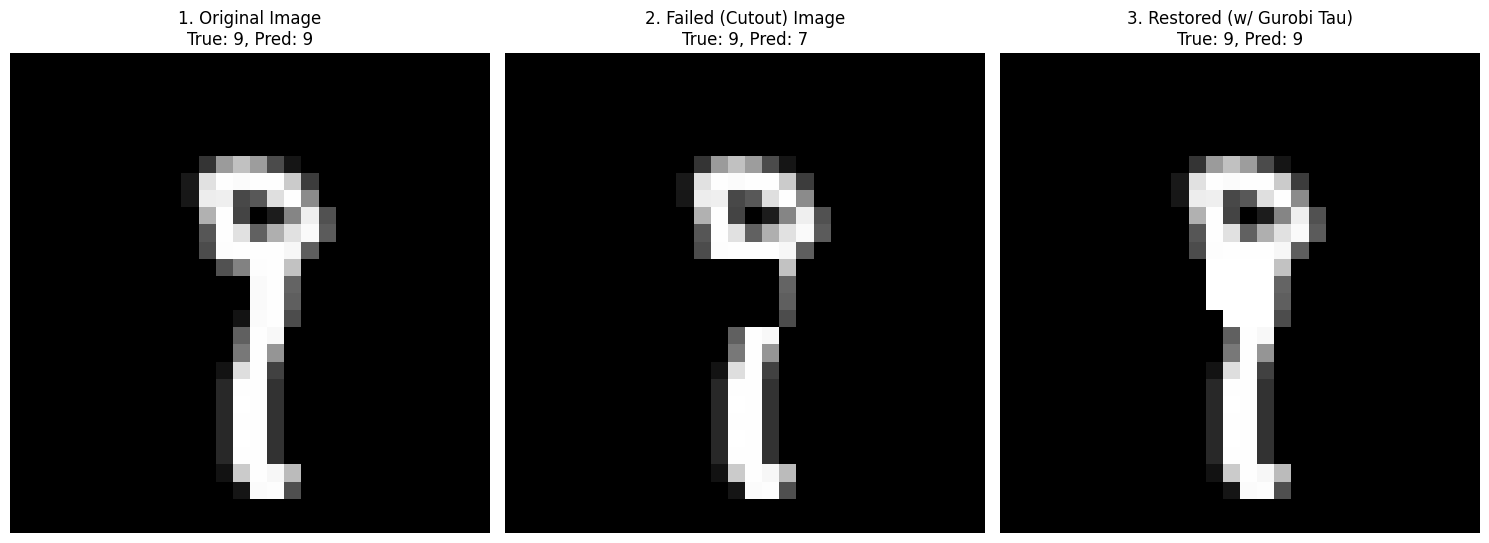


--- TEST 51/100: Image Index 342 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1163
Always active (L/U)      : 7399
Ambiguous ReLUs          : 846
ReLU binary variables    : 846
Binaries eliminated      : 8562
Binary reduction        : 91.01%
Starting optimized Gurobi optimization...
Solve time: 0.7468 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 342 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


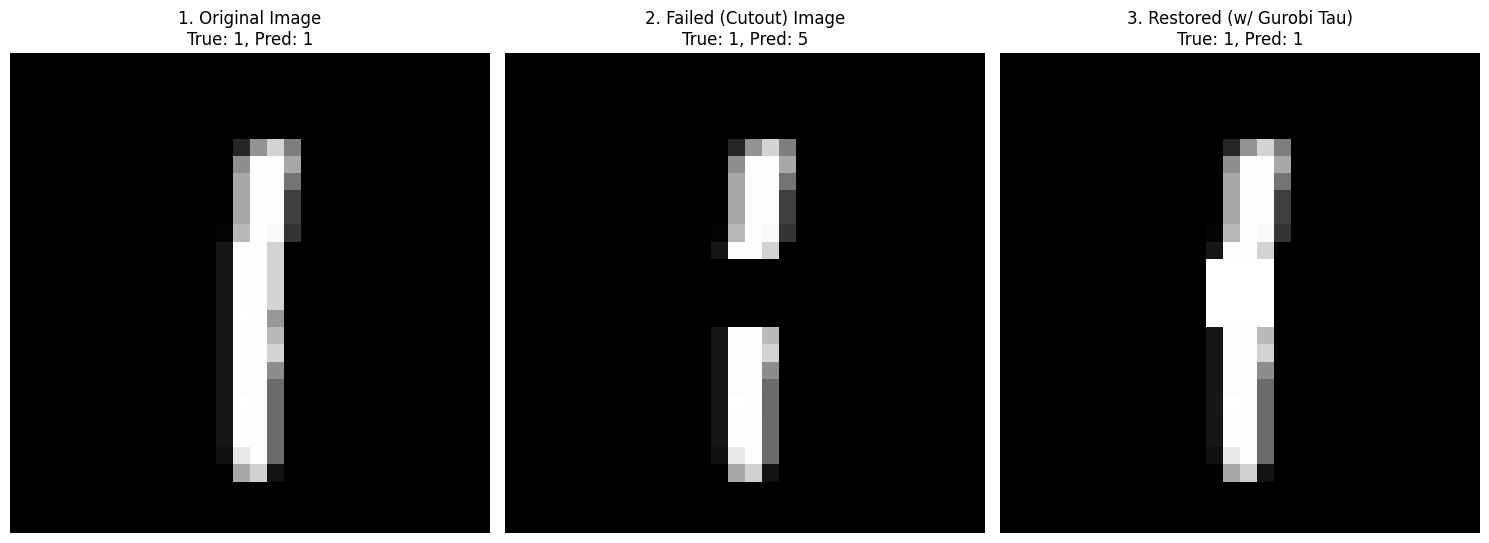


--- TEST 52/100: Image Index 345 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1200
Always active (L/U)      : 7456
Ambiguous ReLUs          : 752
ReLU binary variables    : 752
Binaries eliminated      : 8656
Binary reduction        : 92.01%
Starting optimized Gurobi optimization...
Solve time: 0.6991 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 345 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   3 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


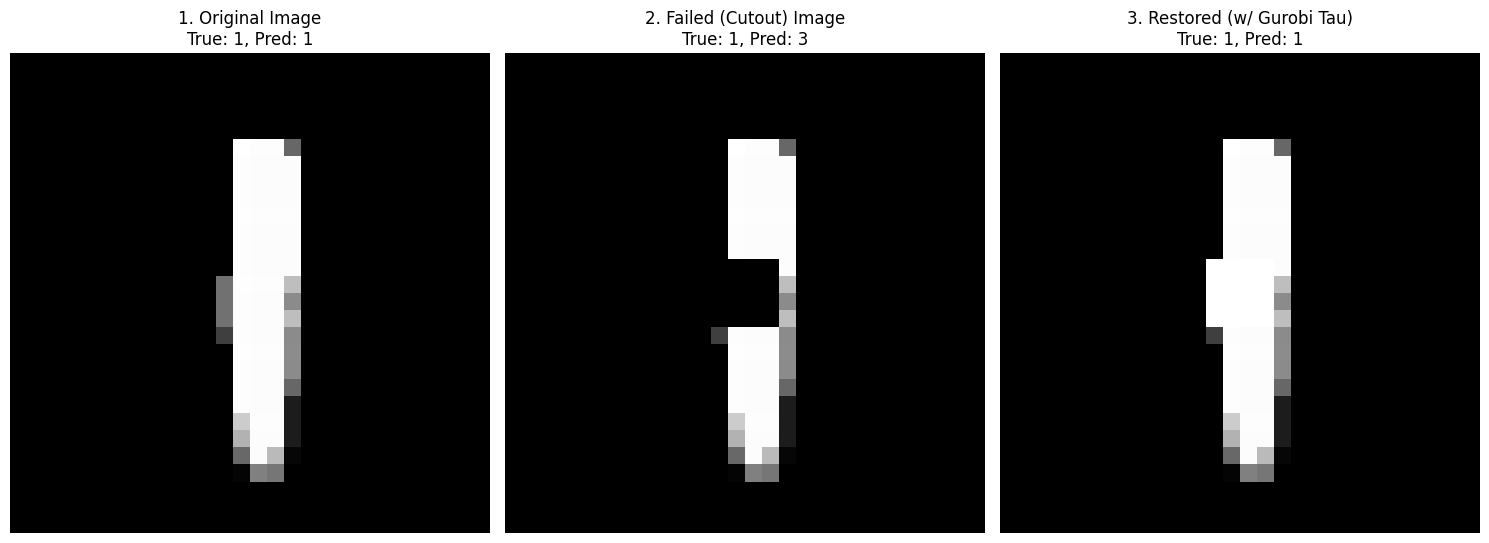


--- TEST 53/100: Image Index 348 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1182
Always active (L/U)      : 7385
Ambiguous ReLUs          : 841
ReLU binary variables    : 841
Binaries eliminated      : 8567
Binary reduction        : 91.06%
Starting optimized Gurobi optimization...
Solve time: 22.8164 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 348 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


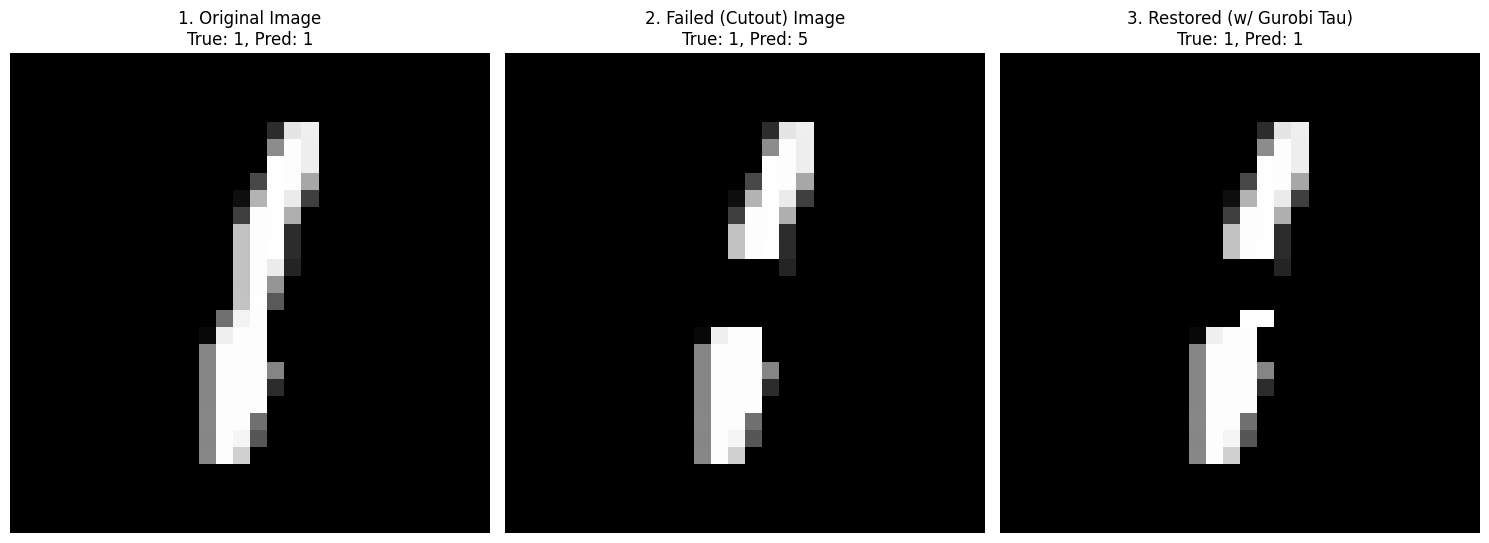


--- TEST 54/100: Image Index 359 ---
Running Gurobi to find corrective 'tau' patch for target 9...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1408
Always active (L/U)      : 7349
Ambiguous ReLUs          : 651
ReLU binary variables    : 651
Binaries eliminated      : 8757
Binary reduction        : 93.08%
Starting optimized Gurobi optimization...
Solve time: 0.6958 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 359 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   4 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


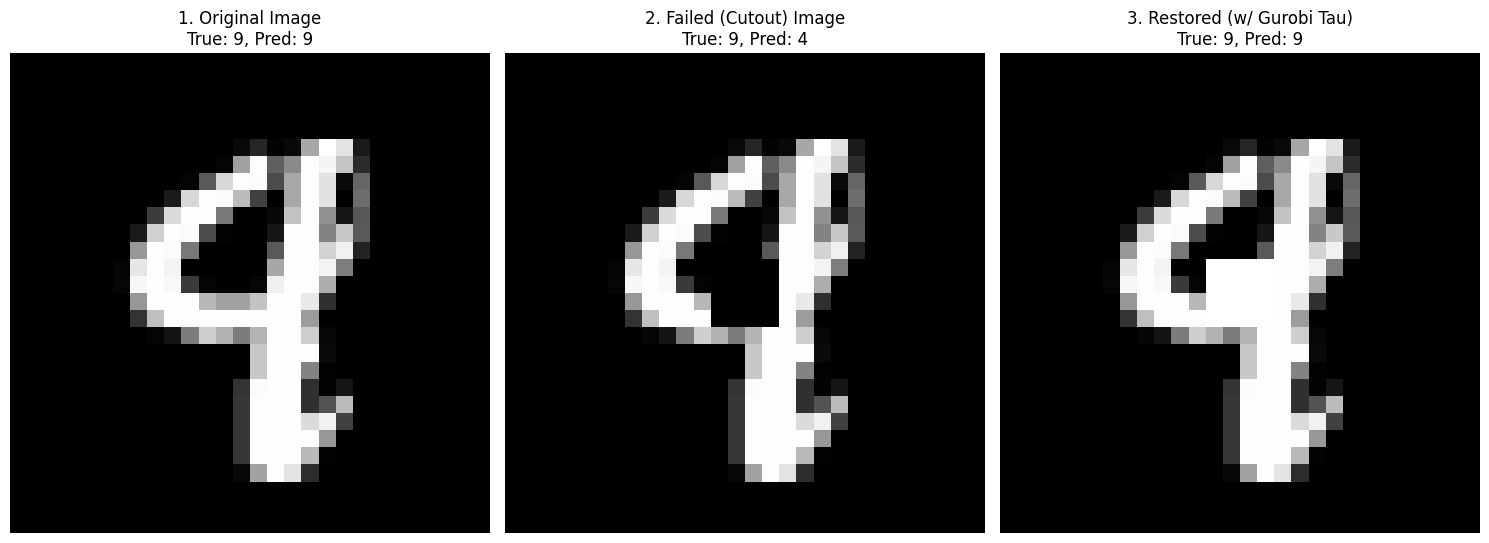


--- TEST 55/100: Image Index 389 ---
Running Gurobi to find corrective 'tau' patch for target 9...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1279
Always active (L/U)      : 7479
Ambiguous ReLUs          : 650
ReLU binary variables    : 650
Binaries eliminated      : 8758
Binary reduction        : 93.09%
Starting optimized Gurobi optimization...
Solve time: 0.5850 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 389 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


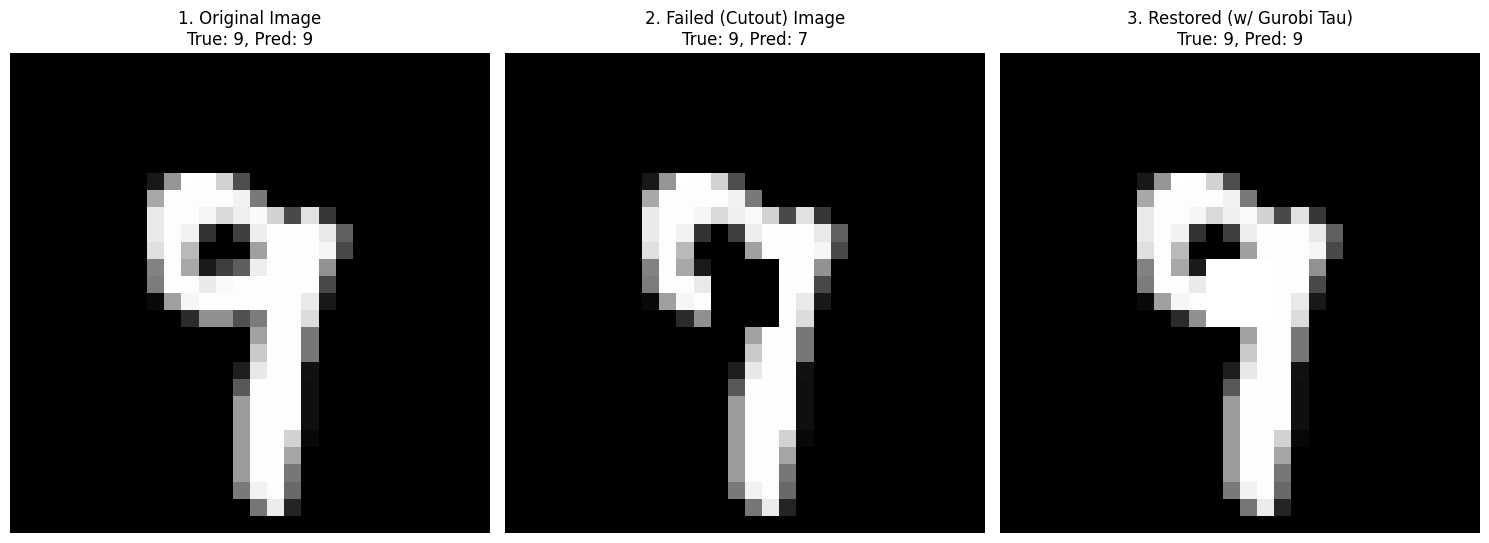


--- TEST 56/100: Image Index 39 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1211
Always active (L/U)      : 7414
Ambiguous ReLUs          : 783
ReLU binary variables    : 783
Binaries eliminated      : 8625
Binary reduction        : 91.68%
Starting optimized Gurobi optimization...
Solve time: 0.5910 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 39 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


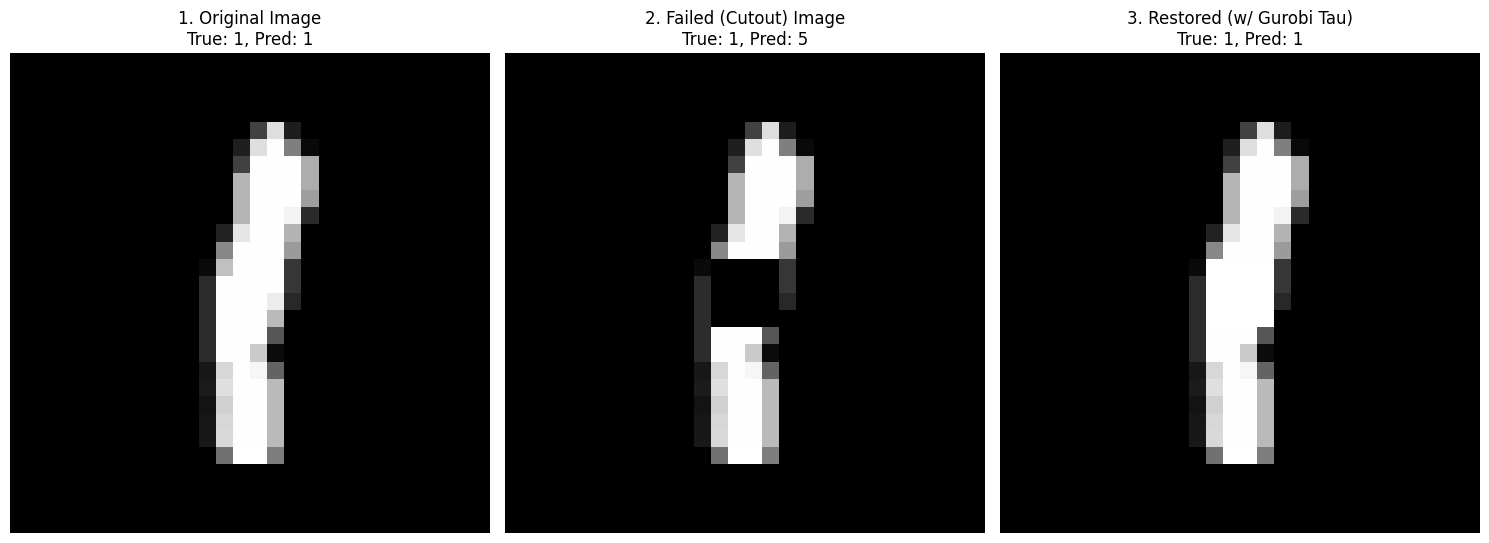


--- TEST 57/100: Image Index 409 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1215
Always active (L/U)      : 7386
Ambiguous ReLUs          : 807
ReLU binary variables    : 807
Binaries eliminated      : 8601
Binary reduction        : 91.42%
Starting optimized Gurobi optimization...
Solve time: 0.7981 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 409 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


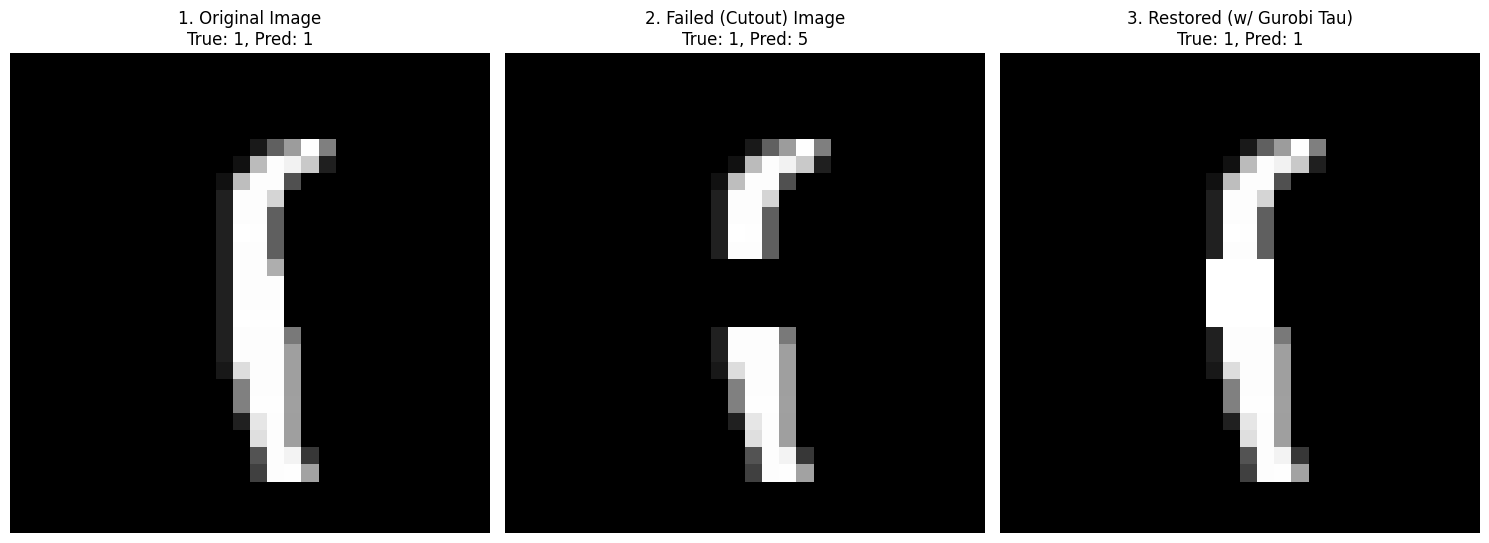


--- TEST 58/100: Image Index 435 ---
Running Gurobi to find corrective 'tau' patch for target 8...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1311
Always active (L/U)      : 7401
Ambiguous ReLUs          : 696
ReLU binary variables    : 696
Binaries eliminated      : 8712
Binary reduction        : 92.60%
Starting optimized Gurobi optimization...
Solve time: 0.6633 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 435 - True Label: 8
  Prediction (Original): 8 (Correct)
  Prediction (Failed):   9 (Incorrect)
  Prediction (Restored): 8 (Correct)
----------------------------------------


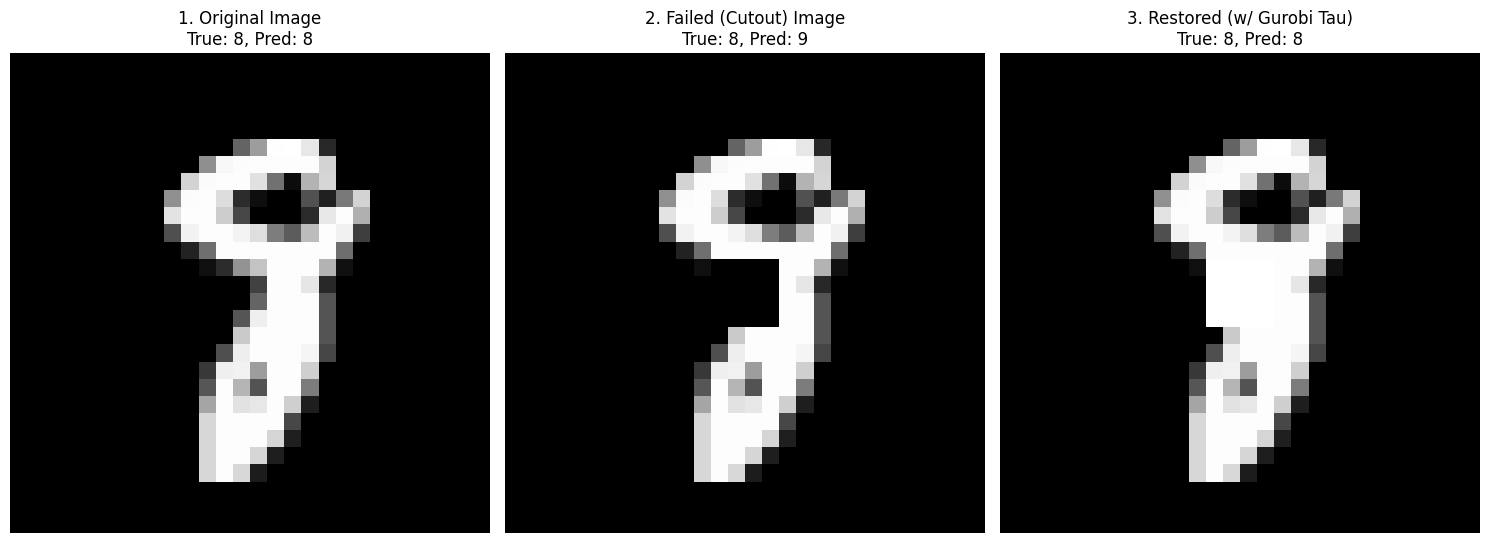


--- TEST 59/100: Image Index 449 ---
Running Gurobi to find corrective 'tau' patch for target 3...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1599
Always active (L/U)      : 7163
Ambiguous ReLUs          : 646
ReLU binary variables    : 646
Binaries eliminated      : 8762
Binary reduction        : 93.13%
Starting optimized Gurobi optimization...
Solve time: 0.5366 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 449 - True Label: 3
  Prediction (Original): 3 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 3 (Correct)
----------------------------------------


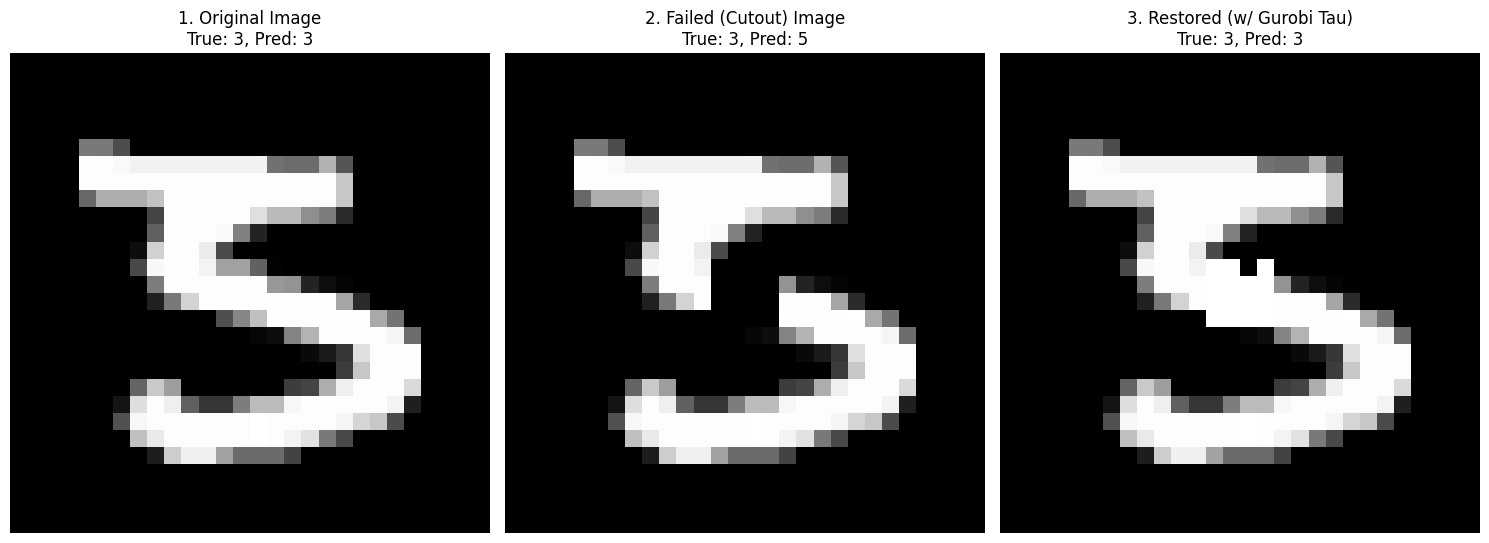


--- TEST 60/100: Image Index 471 ---
Running Gurobi to find corrective 'tau' patch for target 9...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1274
Always active (L/U)      : 7371
Ambiguous ReLUs          : 763
ReLU binary variables    : 763
Binaries eliminated      : 8645
Binary reduction        : 91.89%
Starting optimized Gurobi optimization...
Solve time: 0.7014 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 471 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


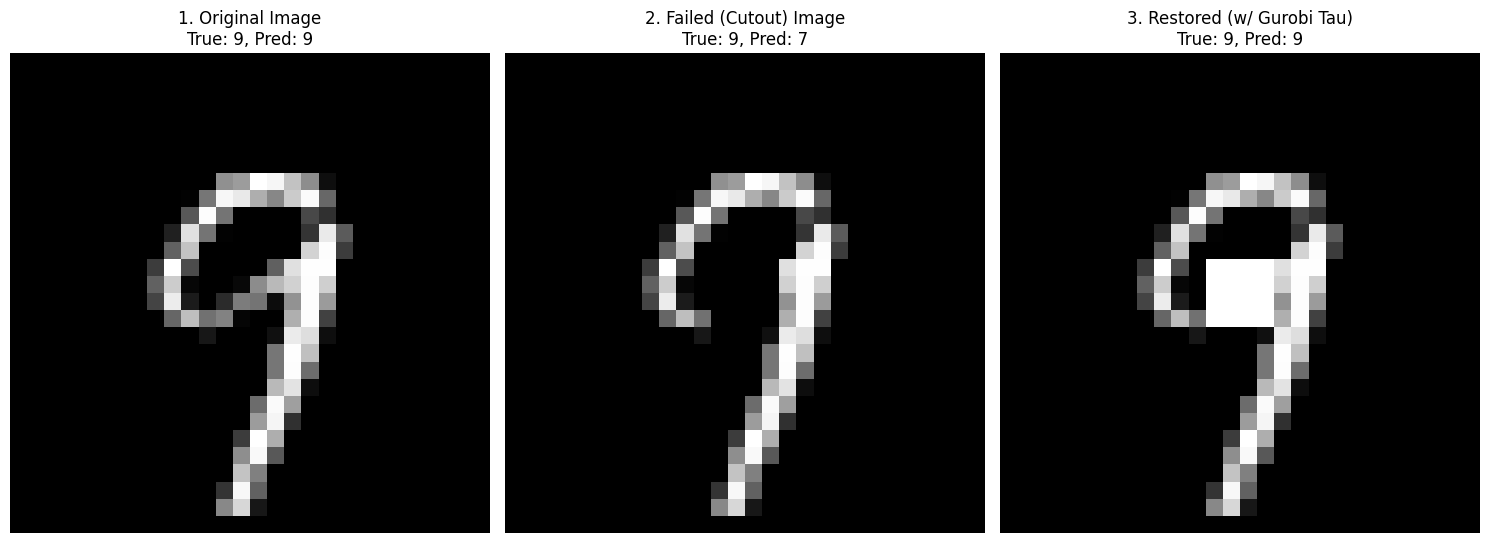


--- TEST 61/100: Image Index 476 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1212
Always active (L/U)      : 7384
Ambiguous ReLUs          : 812
ReLU binary variables    : 812
Binaries eliminated      : 8596
Binary reduction        : 91.37%
Starting optimized Gurobi optimization...
Solve time: 0.7687 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 476 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


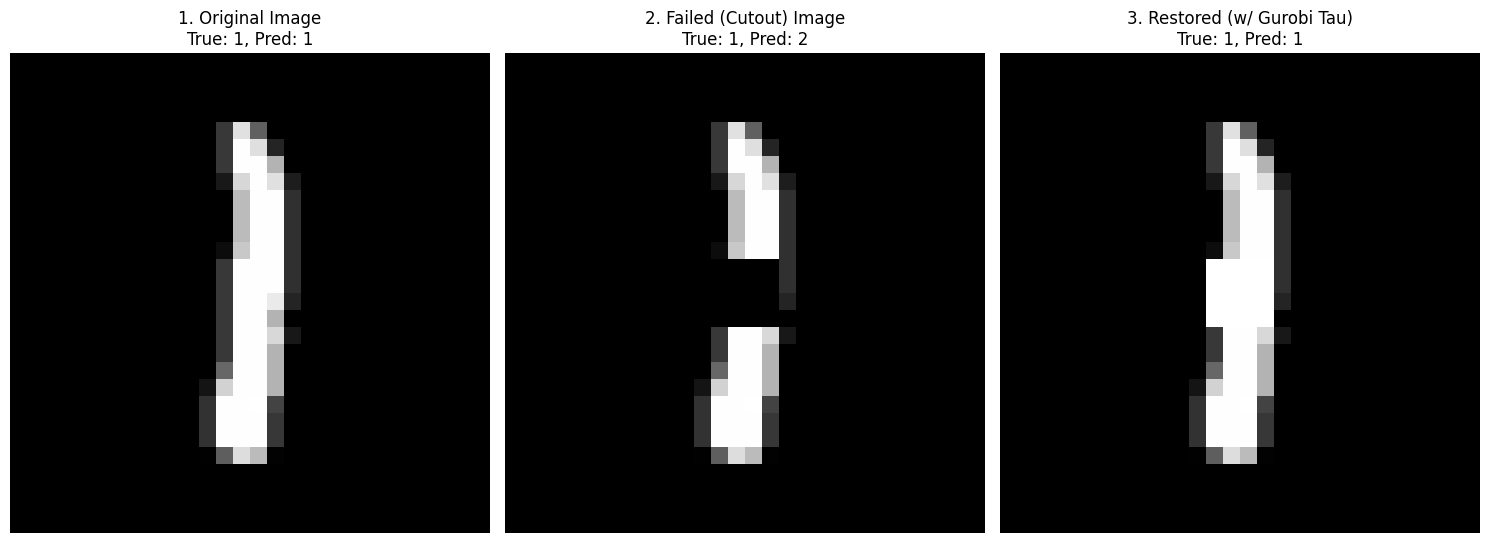


--- TEST 62/100: Image Index 497 ---
Running Gurobi to find corrective 'tau' patch for target 4...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1239
Always active (L/U)      : 7451
Ambiguous ReLUs          : 718
ReLU binary variables    : 718
Binaries eliminated      : 8690
Binary reduction        : 92.37%
Starting optimized Gurobi optimization...
Solve time: 48.4149 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 497 - True Label: 4
  Prediction (Original): 4 (Correct)
  Prediction (Failed):   1 (Incorrect)
  Prediction (Restored): 4 (Correct)
----------------------------------------


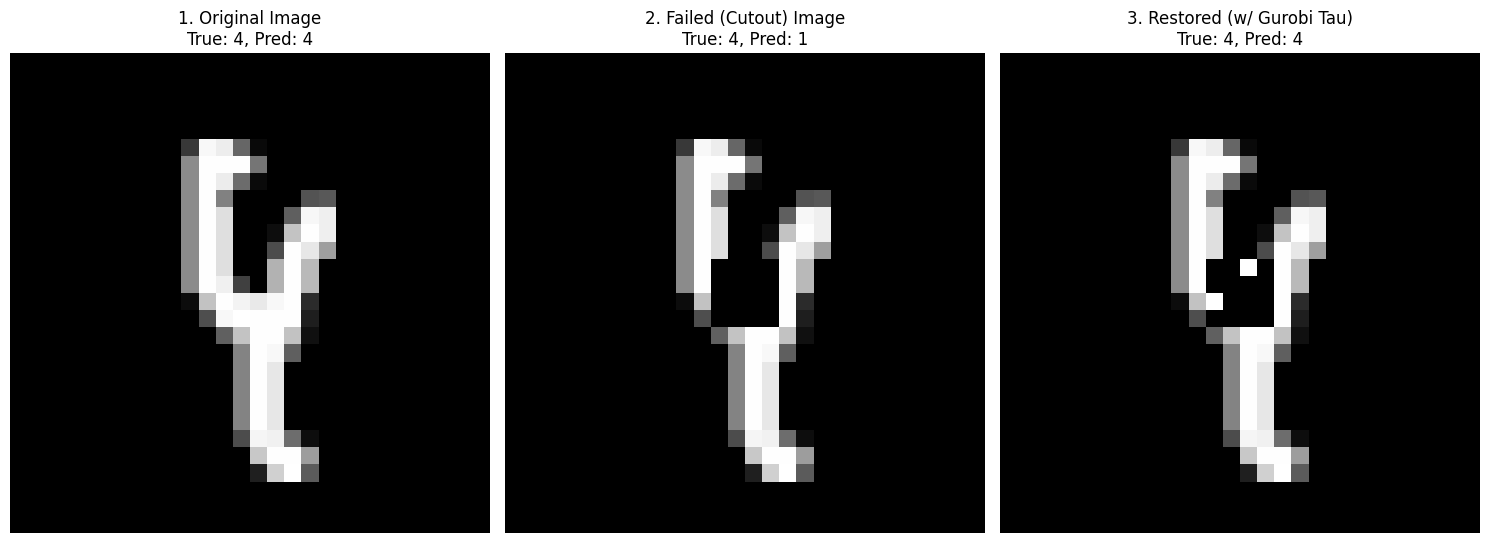


--- TEST 63/100: Image Index 543 ---
Running Gurobi to find corrective 'tau' patch for target 8...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1392
Always active (L/U)      : 7292
Ambiguous ReLUs          : 724
ReLU binary variables    : 724
Binaries eliminated      : 8684
Binary reduction        : 92.30%
Starting optimized Gurobi optimization...
Solve time: 0.6962 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 543 - True Label: 8
  Prediction (Original): 8 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 8 (Correct)
----------------------------------------


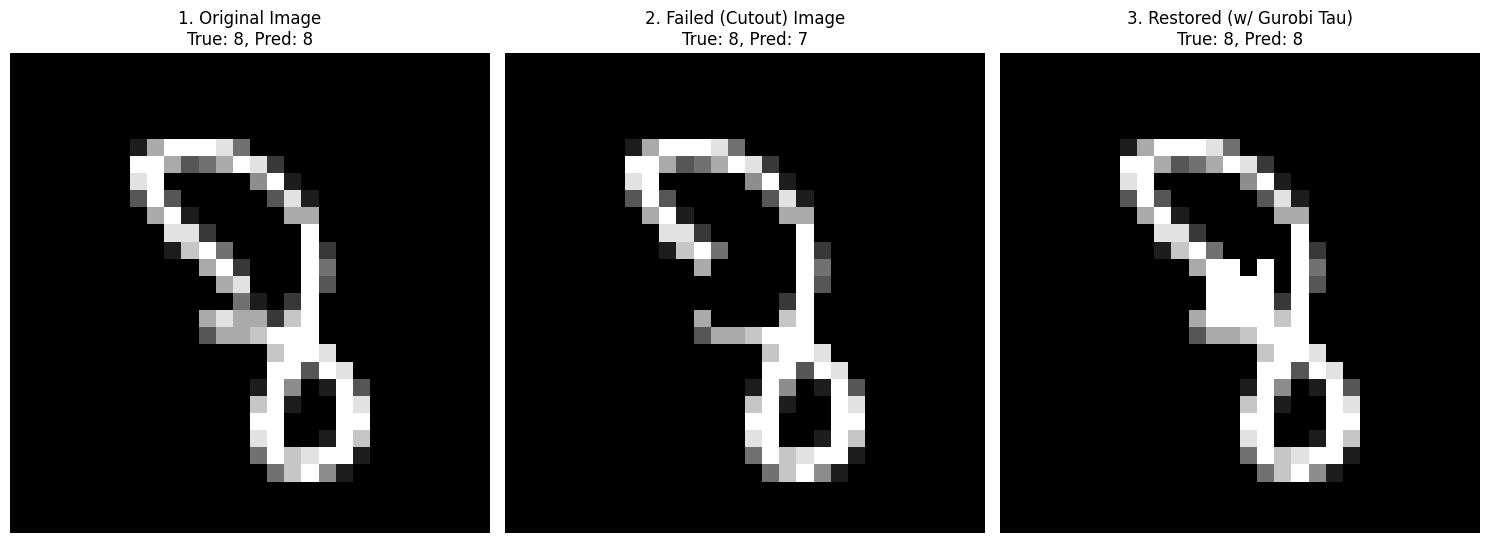


--- TEST 64/100: Image Index 593 ---
Running Gurobi to find corrective 'tau' patch for target 9...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1266
Always active (L/U)      : 7442
Ambiguous ReLUs          : 700
ReLU binary variables    : 700
Binaries eliminated      : 8708
Binary reduction        : 92.56%
Starting optimized Gurobi optimization...
Solve time: 0.7400 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 593 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


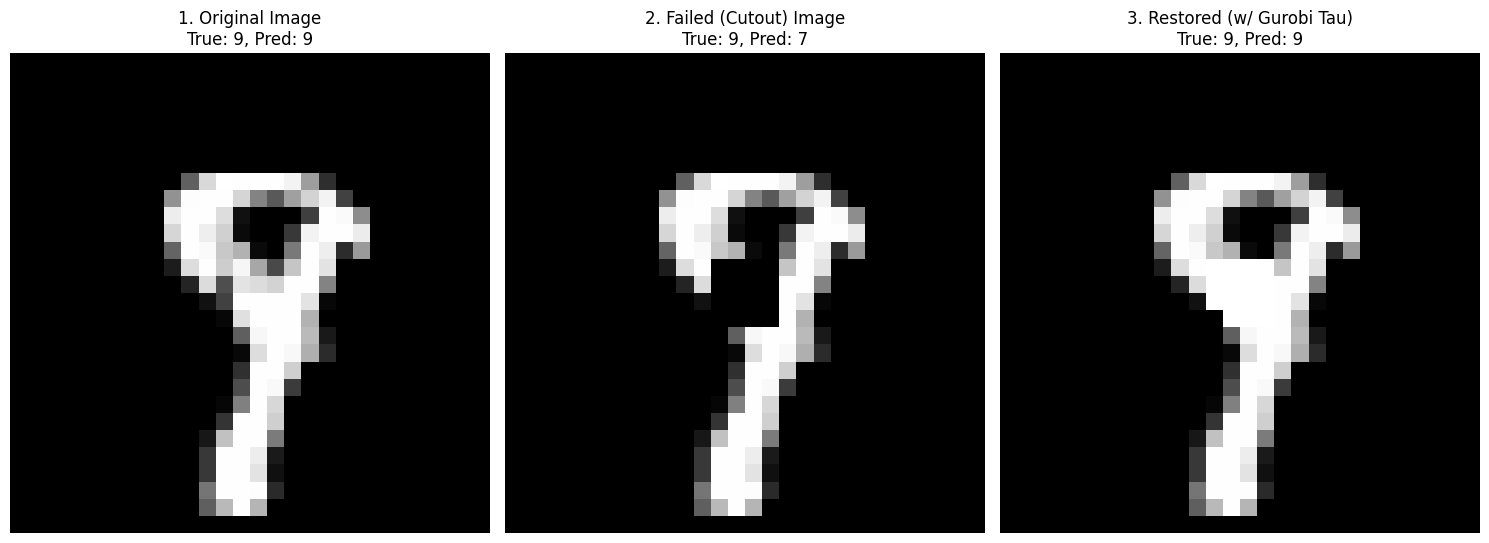


--- TEST 65/100: Image Index 615 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1293
Always active (L/U)      : 7294
Ambiguous ReLUs          : 821
ReLU binary variables    : 821
Binaries eliminated      : 8587
Binary reduction        : 91.27%
Starting optimized Gurobi optimization...
Solve time: 0.6595 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 615 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


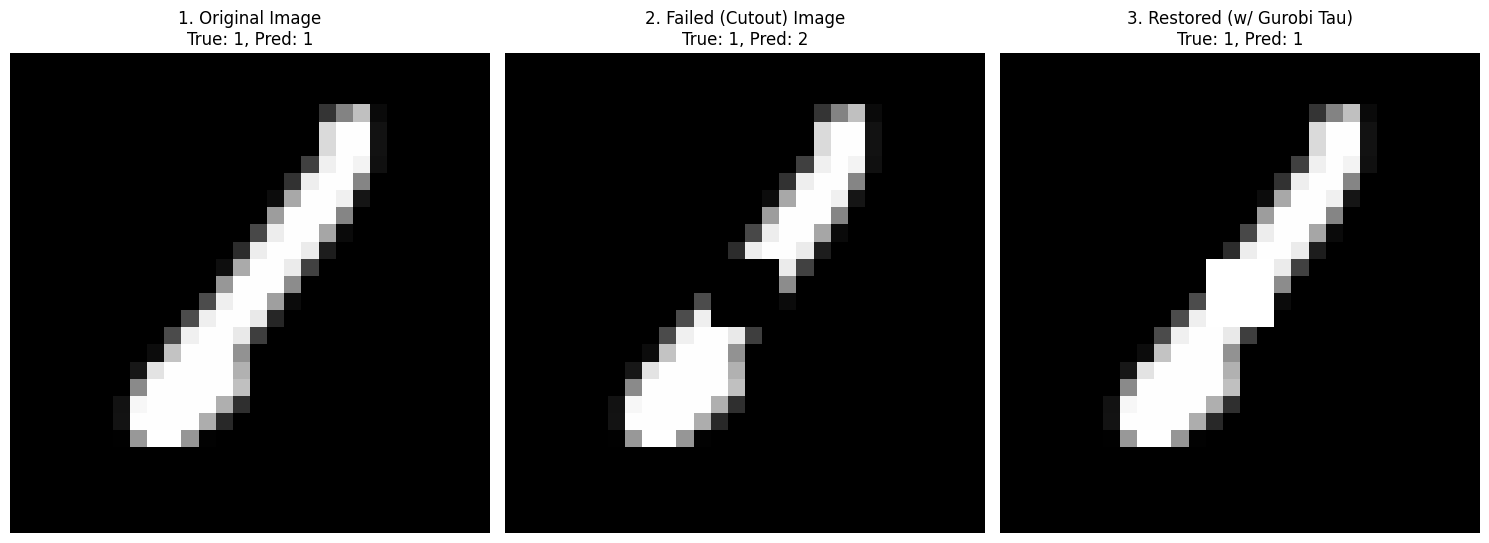


--- TEST 66/100: Image Index 619 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1381
Always active (L/U)      : 7395
Ambiguous ReLUs          : 632
ReLU binary variables    : 632
Binaries eliminated      : 8776
Binary reduction        : 93.28%
Starting optimized Gurobi optimization...
Solve time: 0.7148 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 619 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   3 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


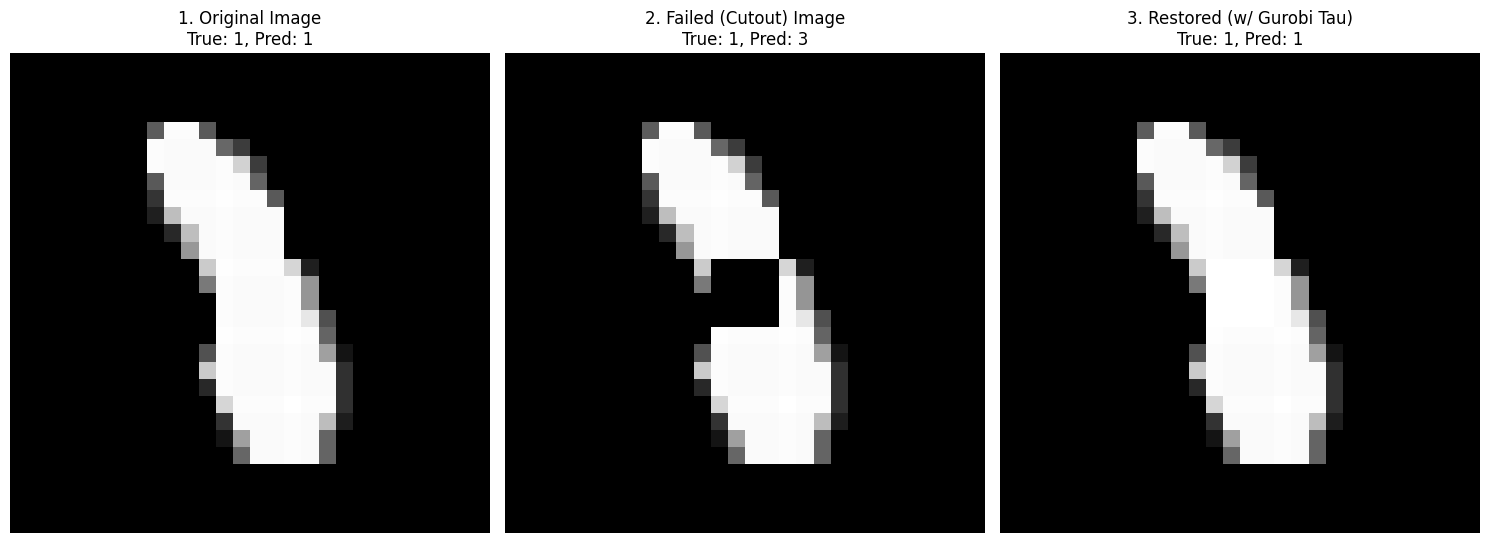


--- TEST 67/100: Image Index 652 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1186
Always active (L/U)      : 7397
Ambiguous ReLUs          : 825
ReLU binary variables    : 825
Binaries eliminated      : 8583
Binary reduction        : 91.23%
Starting optimized Gurobi optimization...
Solve time: 0.6346 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 652 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


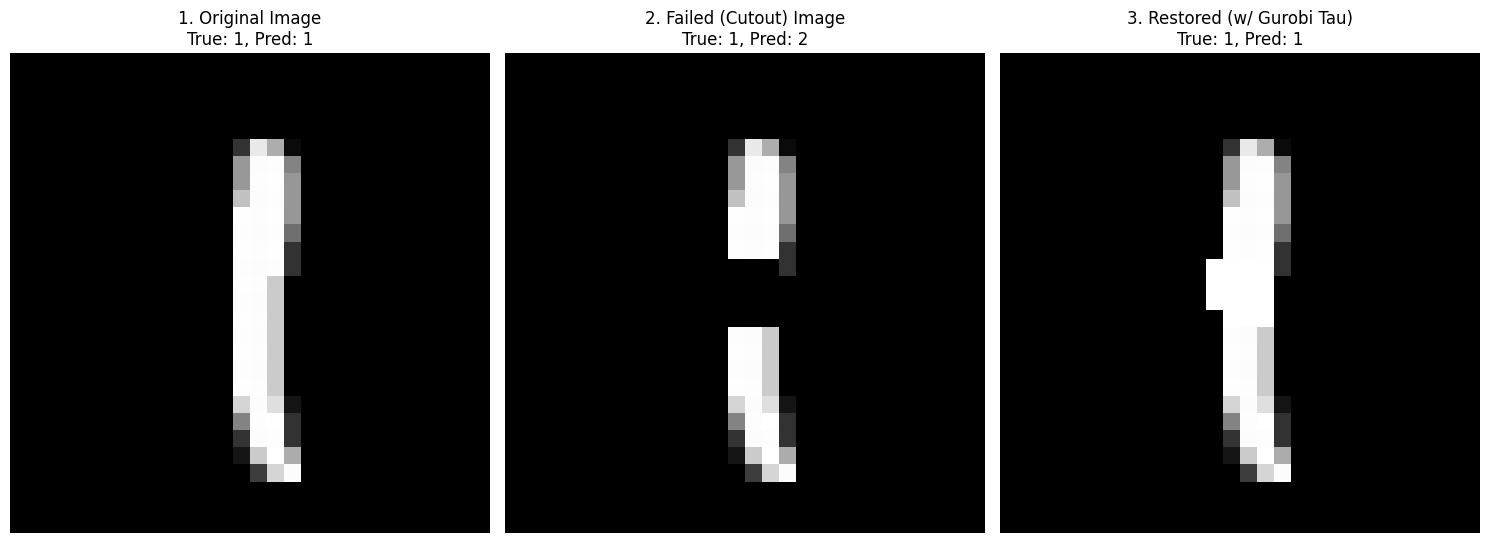


--- TEST 68/100: Image Index 655 ---
Running Gurobi to find corrective 'tau' patch for target 8...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1575
Always active (L/U)      : 7228
Ambiguous ReLUs          : 605
ReLU binary variables    : 605
Binaries eliminated      : 8803
Binary reduction        : 93.57%
Starting optimized Gurobi optimization...
Solve time: 0.5266 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 655 - True Label: 8
  Prediction (Original): 8 (Correct)
  Prediction (Failed):   3 (Incorrect)
  Prediction (Restored): 8 (Correct)
----------------------------------------


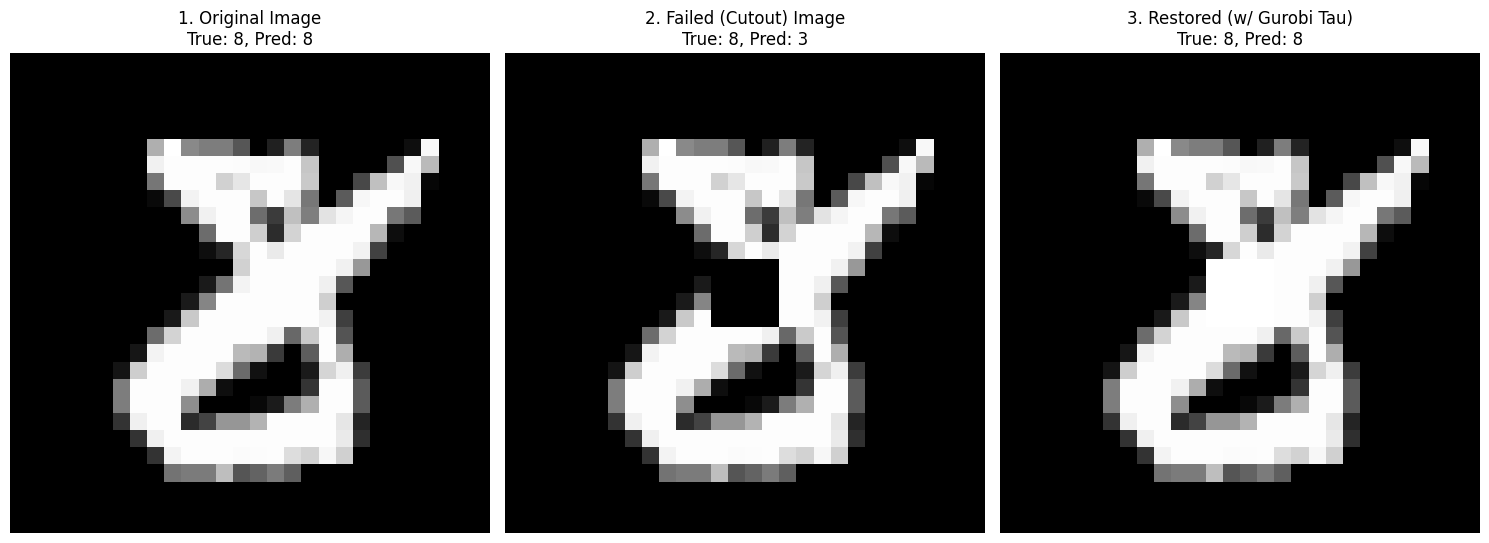


--- TEST 69/100: Image Index 663 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1183
Always active (L/U)      : 7389
Ambiguous ReLUs          : 836
ReLU binary variables    : 836
Binaries eliminated      : 8572
Binary reduction        : 91.11%
Starting optimized Gurobi optimization...
Solve time: 0.6923 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 663 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


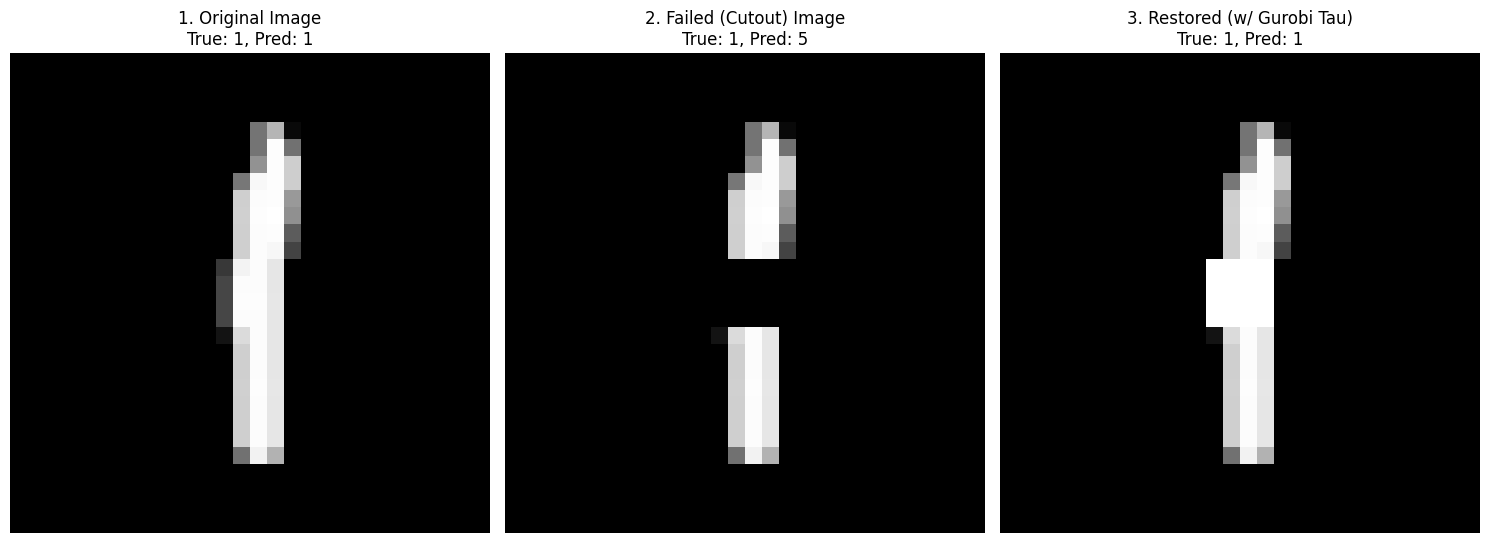


--- TEST 70/100: Image Index 674 ---
Running Gurobi to find corrective 'tau' patch for target 5...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1414
Always active (L/U)      : 7269
Ambiguous ReLUs          : 725
ReLU binary variables    : 725
Binaries eliminated      : 8683
Binary reduction        : 92.29%
Starting optimized Gurobi optimization...
Solve time: 137.7770 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 674 - True Label: 5
  Prediction (Original): 5 (Correct)
  Prediction (Failed):   3 (Incorrect)
  Prediction (Restored): 5 (Correct)
----------------------------------------


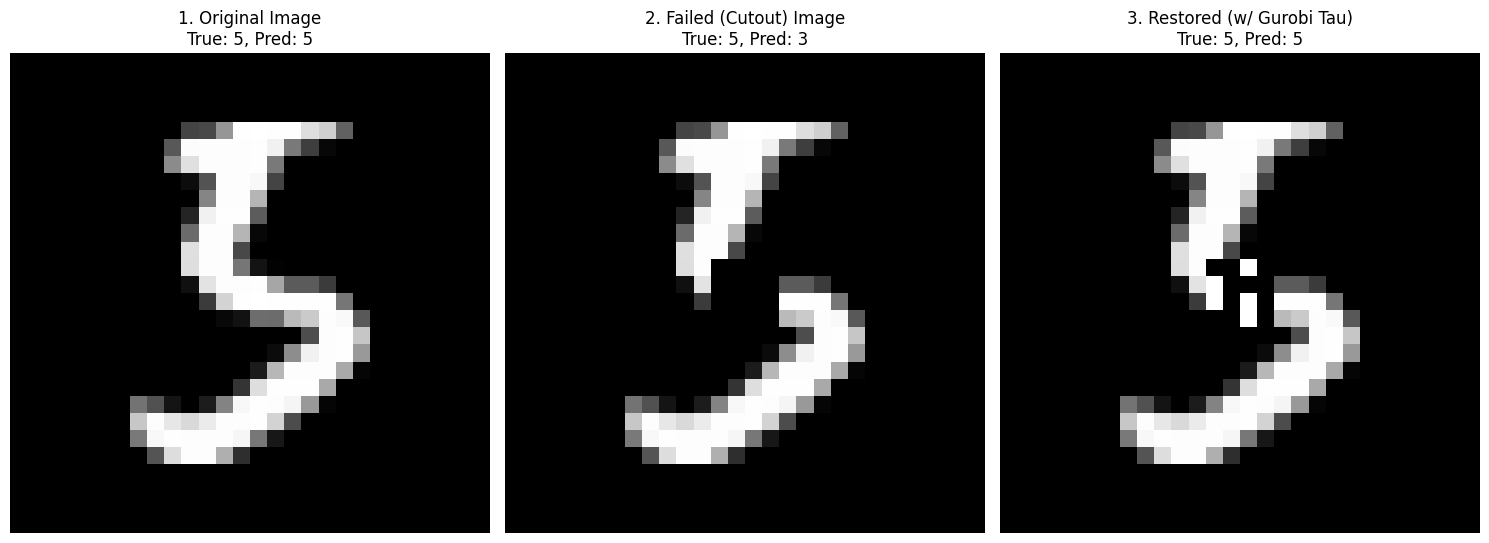


--- TEST 71/100: Image Index 675 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1164
Always active (L/U)      : 7389
Ambiguous ReLUs          : 855
ReLU binary variables    : 855
Binaries eliminated      : 8553
Binary reduction        : 90.91%
Starting optimized Gurobi optimization...
Solve time: 0.7956 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 675 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


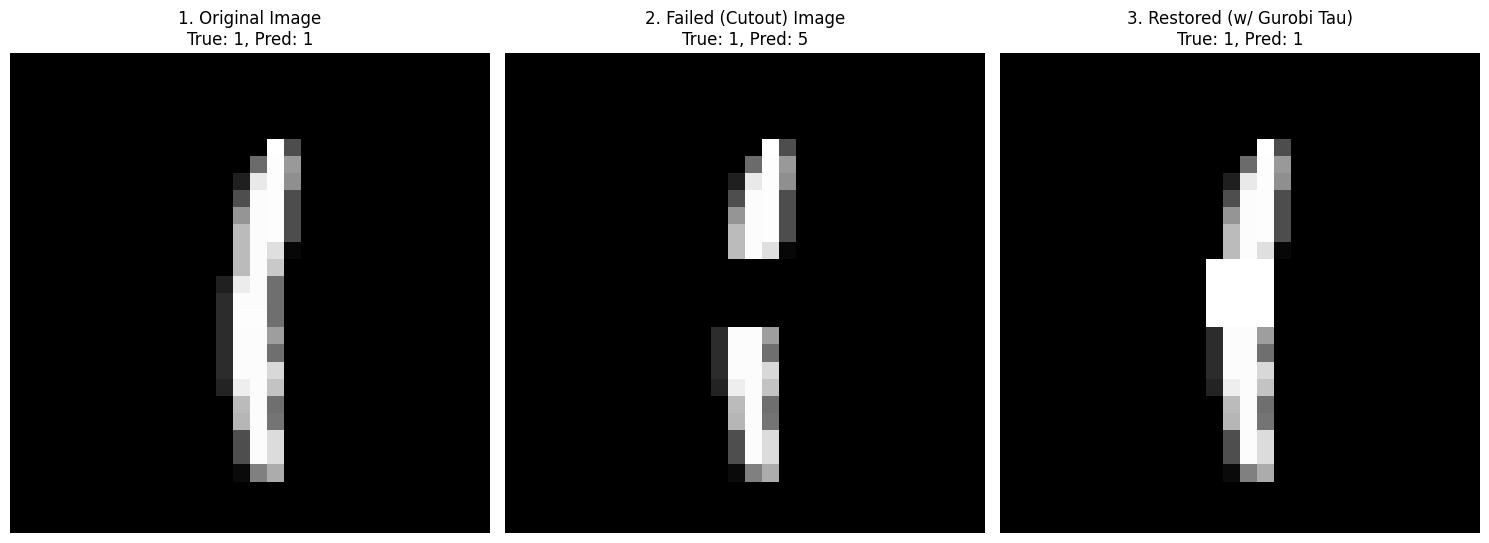


--- TEST 72/100: Image Index 716 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1167
Always active (L/U)      : 7396
Ambiguous ReLUs          : 845
ReLU binary variables    : 845
Binaries eliminated      : 8563
Binary reduction        : 91.02%
Starting optimized Gurobi optimization...
Solve time: 0.7696 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 716 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


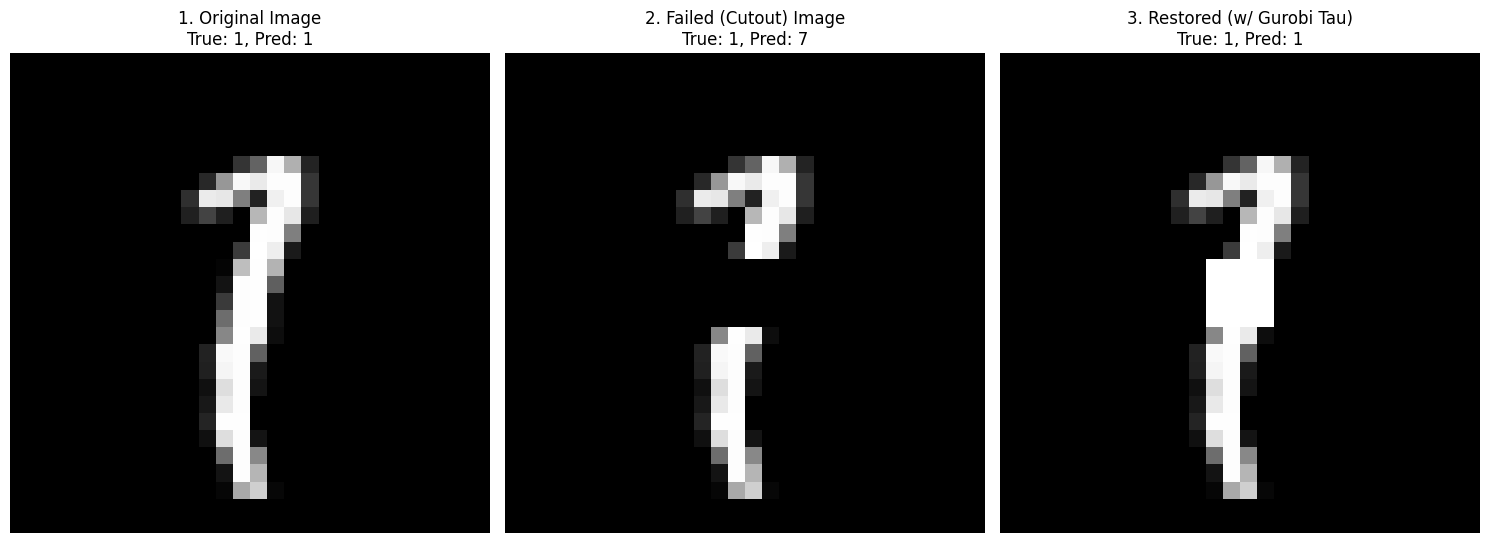


--- TEST 73/100: Image Index 718 ---
Running Gurobi to find corrective 'tau' patch for target 8...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1414
Always active (L/U)      : 7350
Ambiguous ReLUs          : 644
ReLU binary variables    : 644
Binaries eliminated      : 8764
Binary reduction        : 93.15%
Starting optimized Gurobi optimization...
Solve time: 55.5996 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 718 - True Label: 8
  Prediction (Original): 8 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 8 (Correct)
----------------------------------------


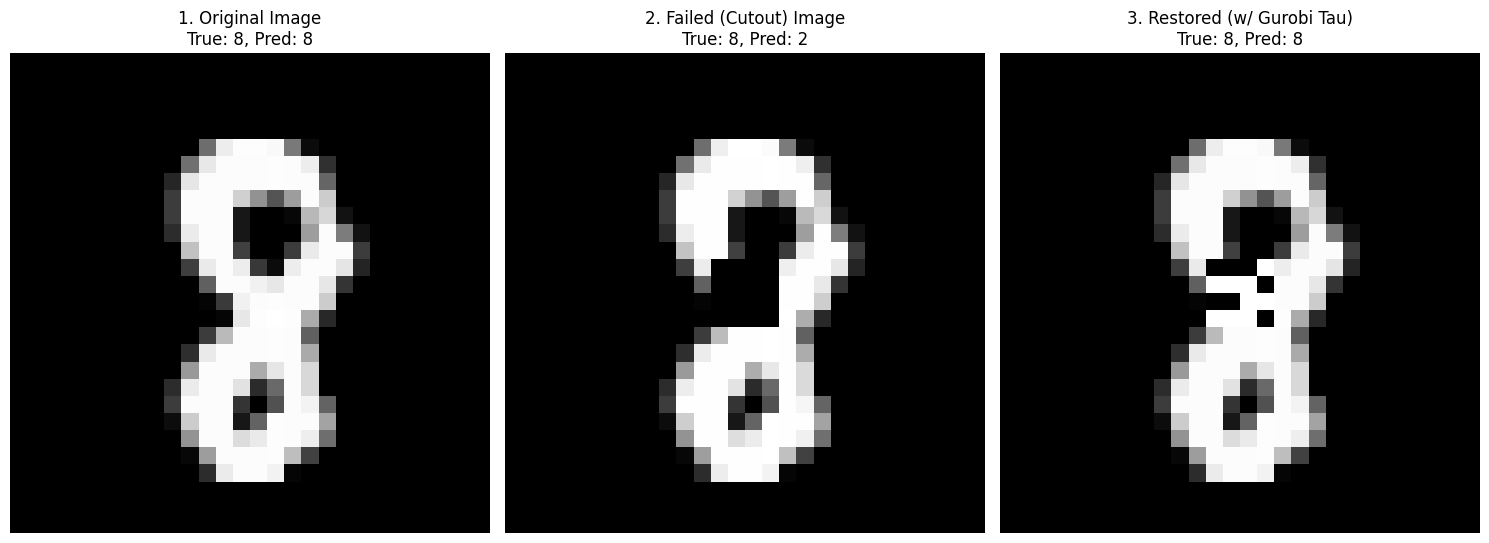


--- TEST 74/100: Image Index 73 ---
Running Gurobi to find corrective 'tau' patch for target 9...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1340
Always active (L/U)      : 7416
Ambiguous ReLUs          : 652
ReLU binary variables    : 652
Binaries eliminated      : 8756
Binary reduction        : 93.07%
Starting optimized Gurobi optimization...
Solve time: 0.6525 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 73 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


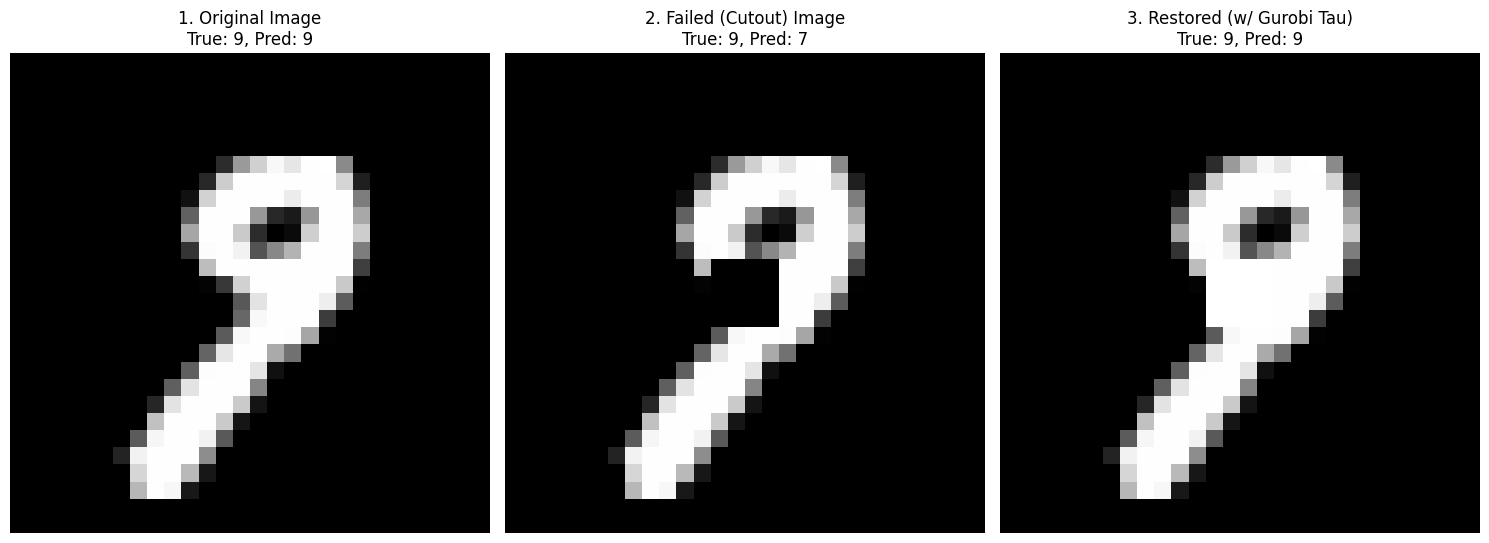


--- TEST 75/100: Image Index 759 ---
Running Gurobi to find corrective 'tau' patch for target 9...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1287
Always active (L/U)      : 7384
Ambiguous ReLUs          : 737
ReLU binary variables    : 737
Binaries eliminated      : 8671
Binary reduction        : 92.17%
Starting optimized Gurobi optimization...
Solve time: 20.4419 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 759 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


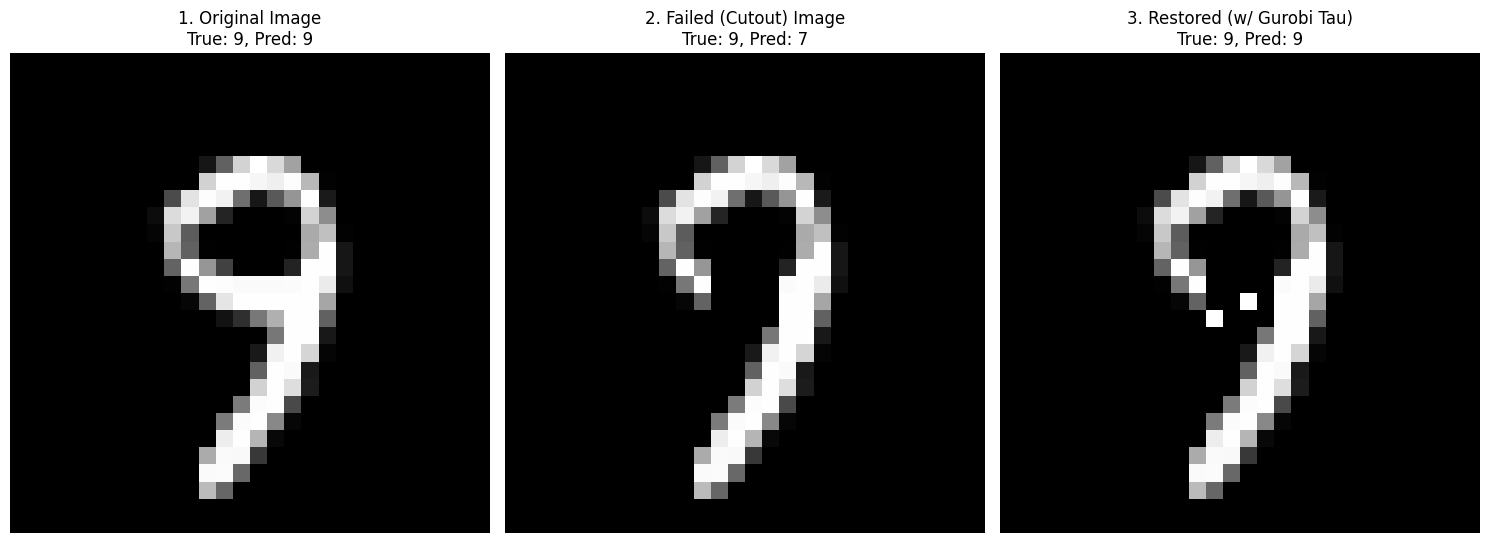


--- TEST 76/100: Image Index 767 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1126
Always active (L/U)      : 7395
Ambiguous ReLUs          : 887
ReLU binary variables    : 887
Binaries eliminated      : 8521
Binary reduction        : 90.57%
Starting optimized Gurobi optimization...
Solve time: 0.8060 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 767 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


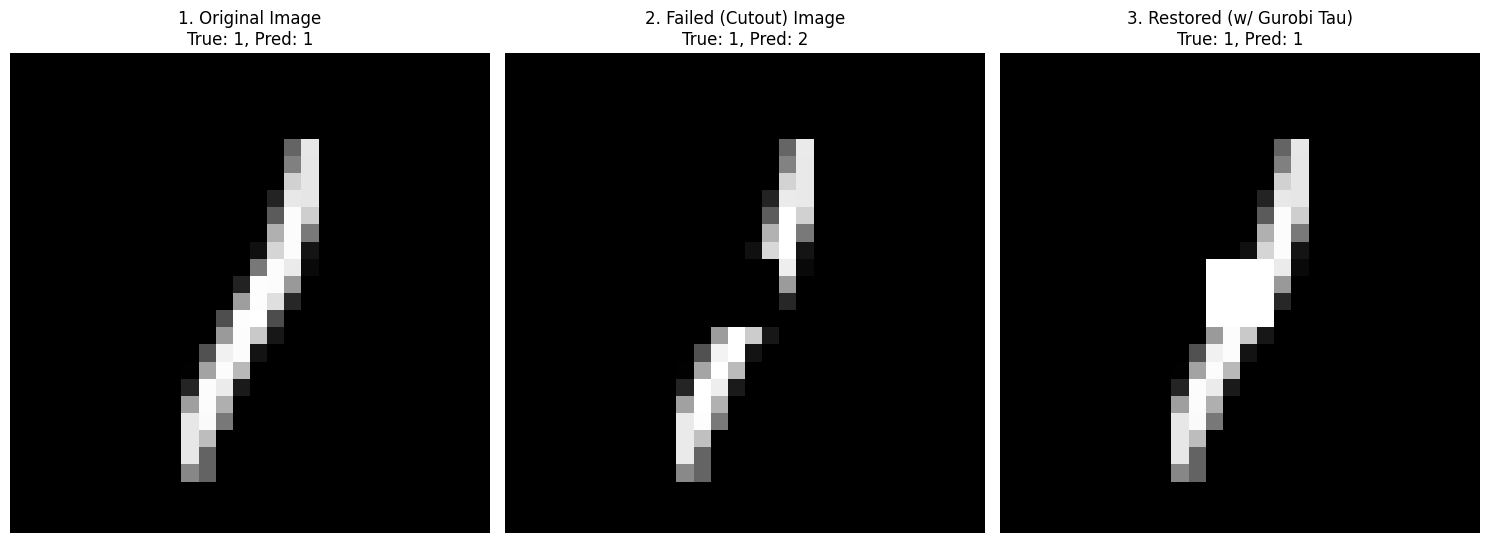


--- TEST 77/100: Image Index 768 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1185
Always active (L/U)      : 7390
Ambiguous ReLUs          : 833
ReLU binary variables    : 833
Binaries eliminated      : 8575
Binary reduction        : 91.15%
Starting optimized Gurobi optimization...
Solve time: 0.7000 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 768 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


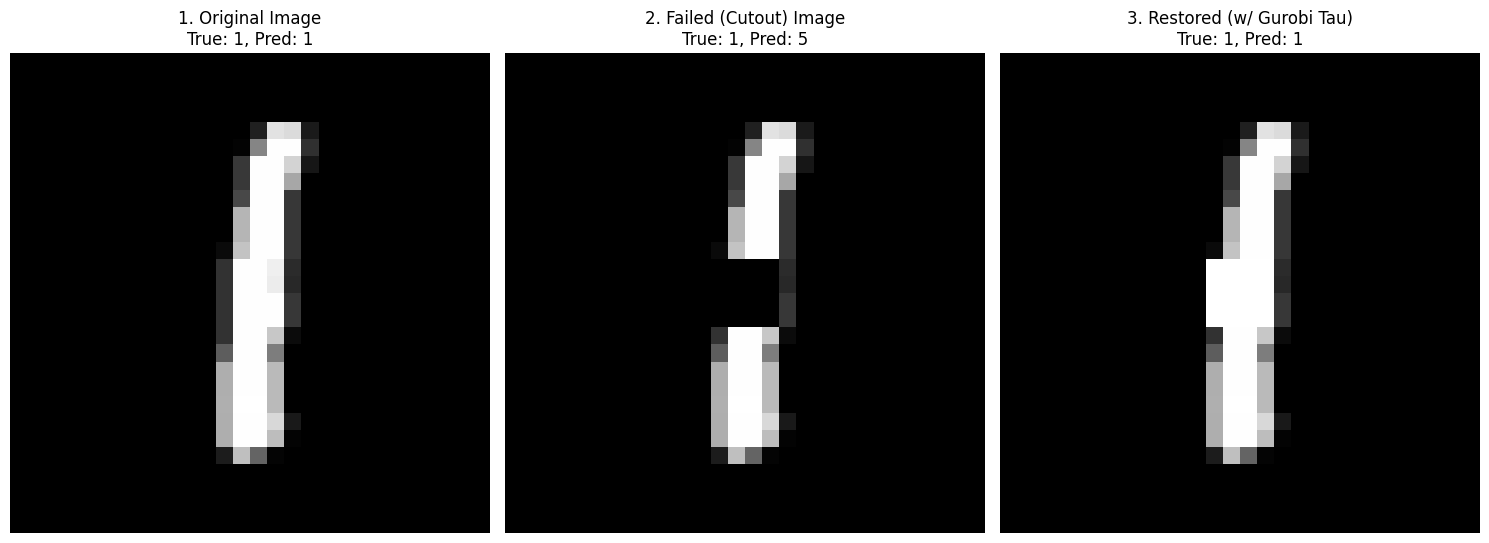


--- TEST 78/100: Image Index 777 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1252
Always active (L/U)      : 7437
Ambiguous ReLUs          : 719
ReLU binary variables    : 719
Binaries eliminated      : 8689
Binary reduction        : 92.36%
Starting optimized Gurobi optimization...
Solve time: 23.1137 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 777 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   3 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


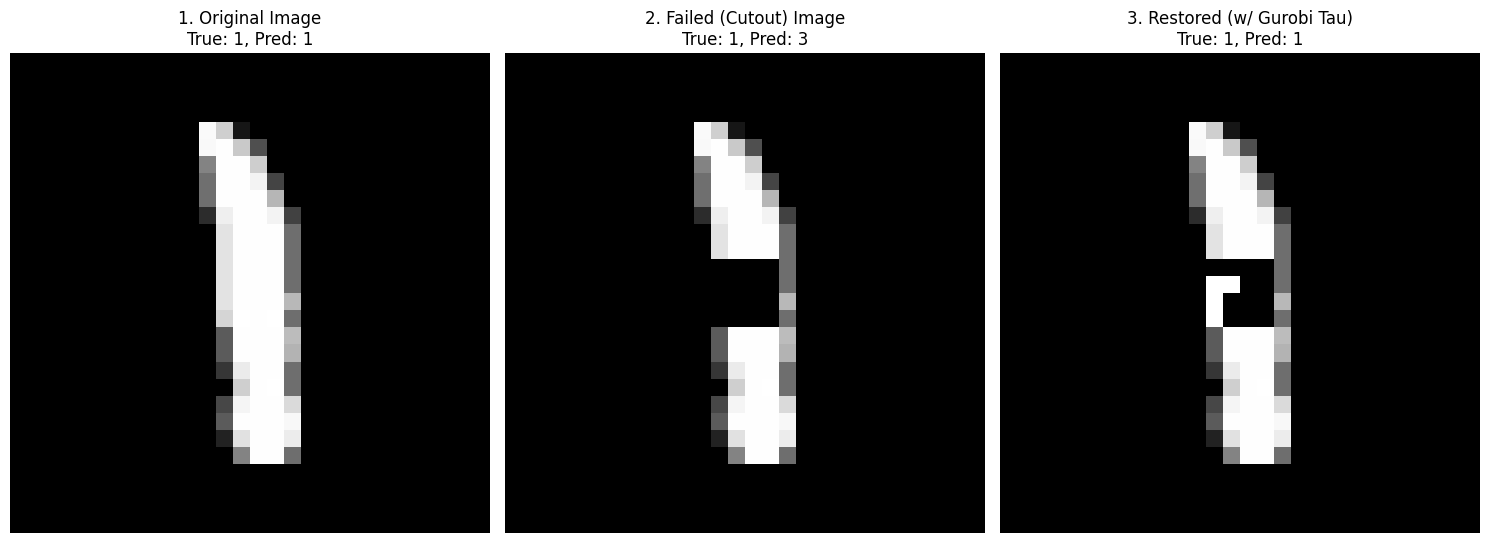


--- TEST 79/100: Image Index 790 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1209
Always active (L/U)      : 7386
Ambiguous ReLUs          : 813
ReLU binary variables    : 813
Binaries eliminated      : 8595
Binary reduction        : 91.36%
Starting optimized Gurobi optimization...
Solve time: 54.3994 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 790 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


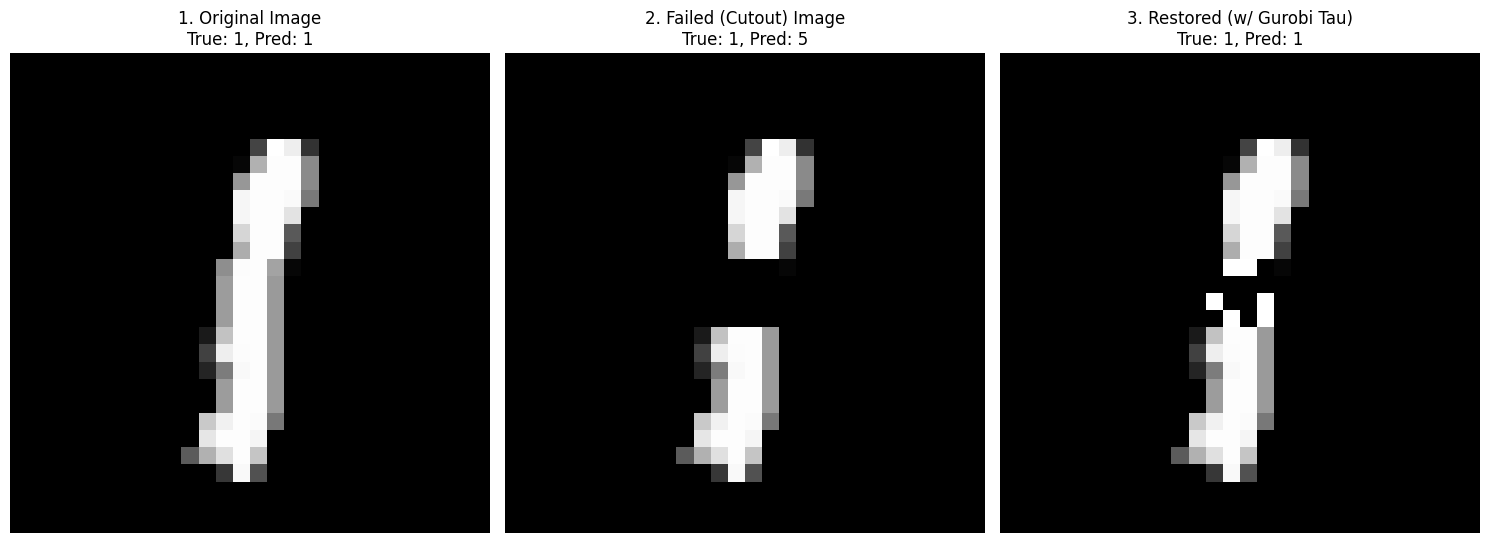


--- TEST 80/100: Image Index 800 ---
Running Gurobi to find corrective 'tau' patch for target 8...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1448
Always active (L/U)      : 7253
Ambiguous ReLUs          : 707
ReLU binary variables    : 707
Binaries eliminated      : 8701
Binary reduction        : 92.49%
Starting optimized Gurobi optimization...
Solve time: 0.6435 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 800 - True Label: 8
  Prediction (Original): 8 (Correct)
  Prediction (Failed):   0 (Incorrect)
  Prediction (Restored): 8 (Correct)
----------------------------------------


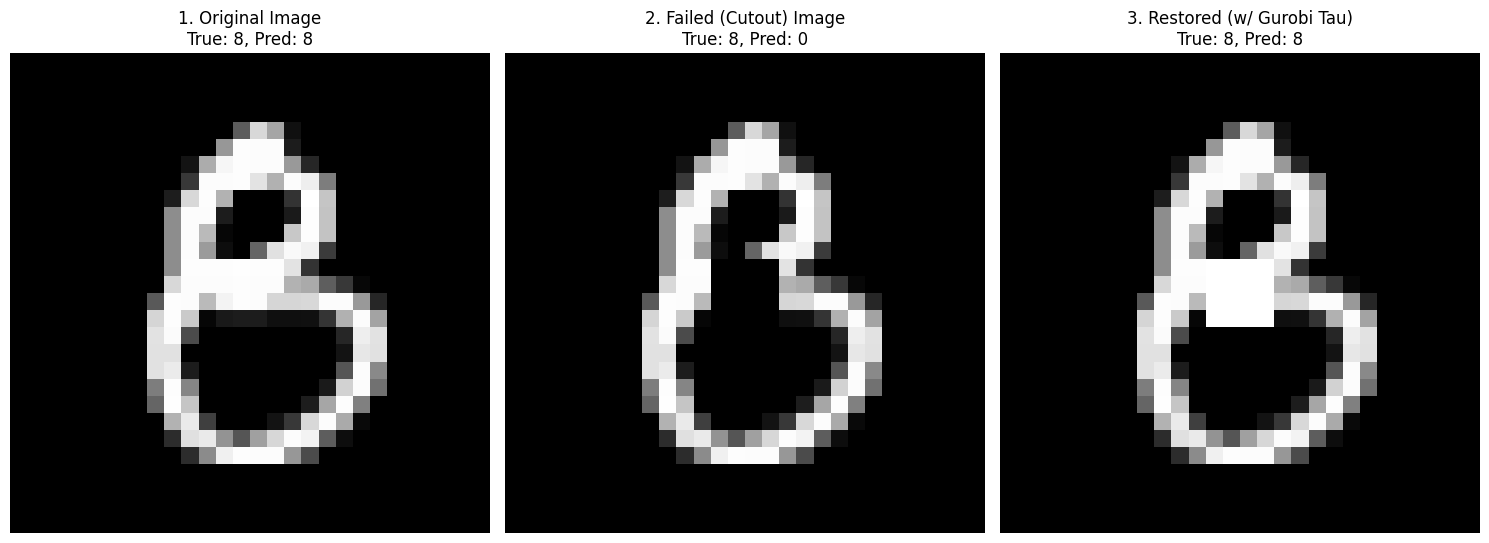


--- TEST 81/100: Image Index 818 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1254
Always active (L/U)      : 7359
Ambiguous ReLUs          : 795
ReLU binary variables    : 795
Binaries eliminated      : 8613
Binary reduction        : 91.55%
Starting optimized Gurobi optimization...
Solve time: 2.9343 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 818 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


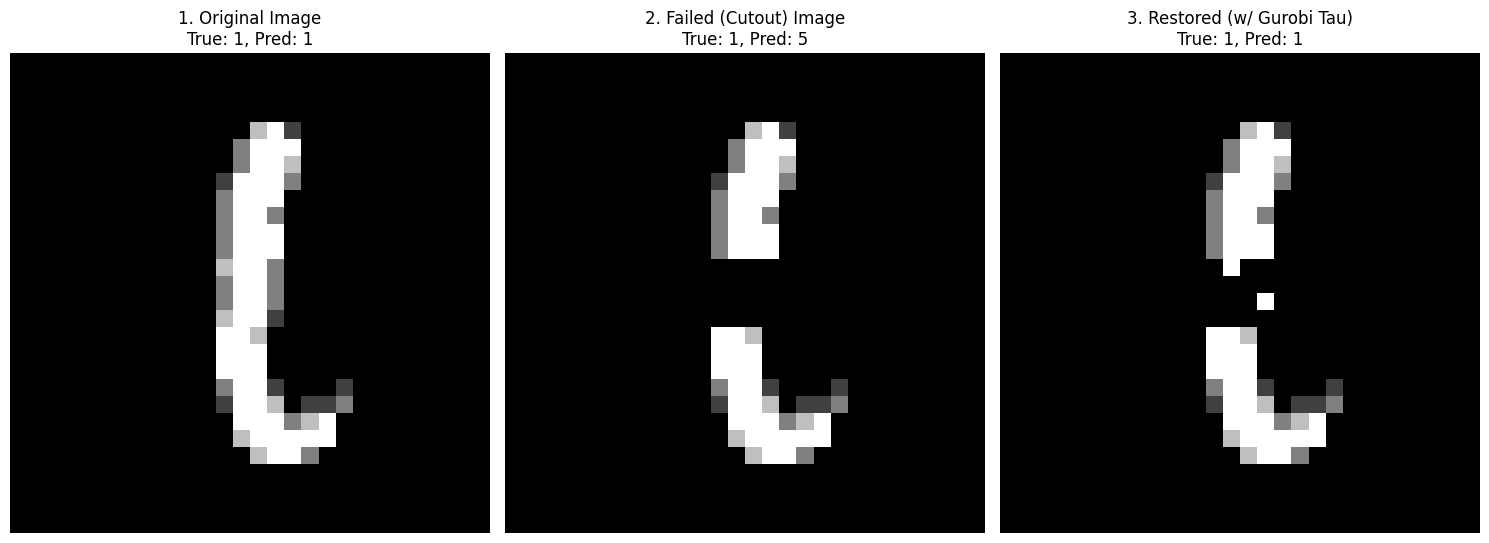


--- TEST 82/100: Image Index 826 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1168
Always active (L/U)      : 7377
Ambiguous ReLUs          : 863
ReLU binary variables    : 863
Binaries eliminated      : 8545
Binary reduction        : 90.83%
Starting optimized Gurobi optimization...
Solve time: 0.7517 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 826 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


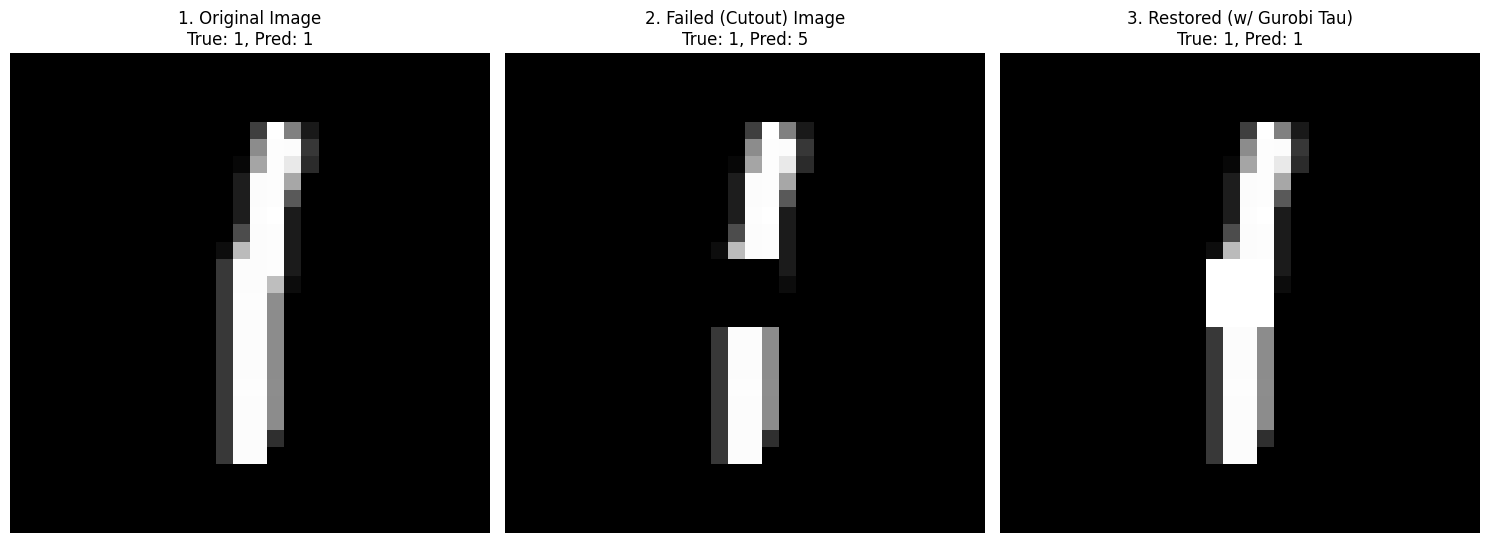


--- TEST 83/100: Image Index 831 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1166
Always active (L/U)      : 7420
Ambiguous ReLUs          : 822
ReLU binary variables    : 822
Binaries eliminated      : 8586
Binary reduction        : 91.26%
Starting optimized Gurobi optimization...
Solve time: 0.6745 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 831 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


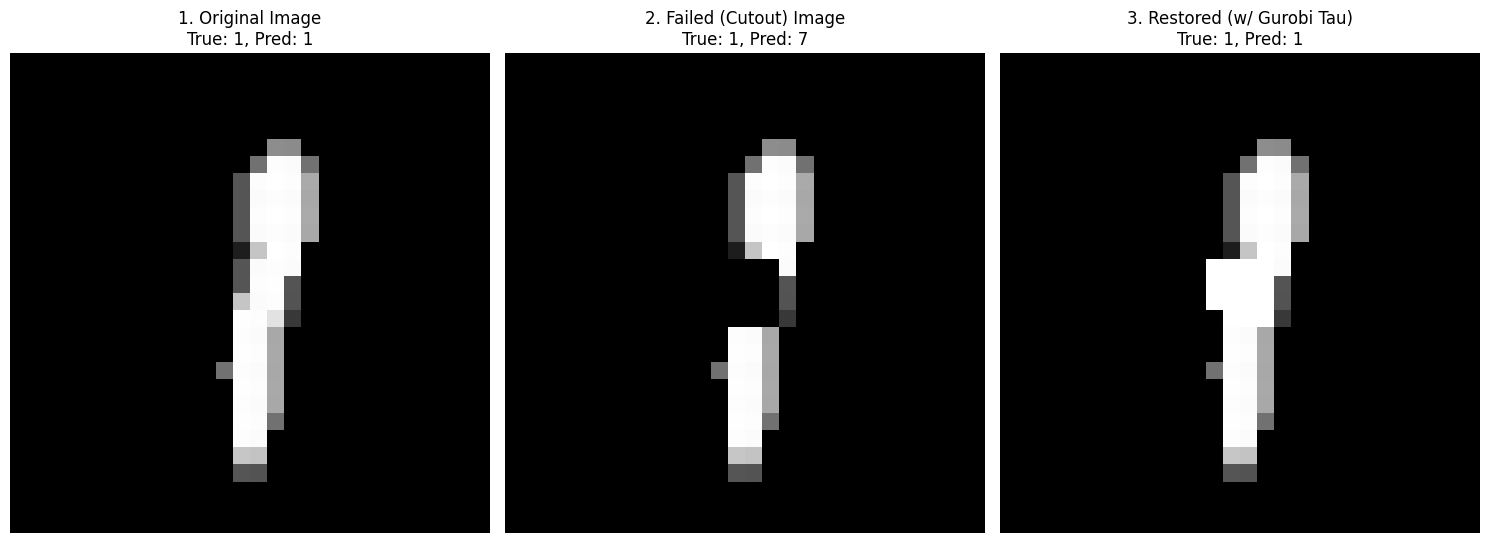


--- TEST 84/100: Image Index 833 ---
Running Gurobi to find corrective 'tau' patch for target 9...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1292
Always active (L/U)      : 7441
Ambiguous ReLUs          : 675
ReLU binary variables    : 675
Binaries eliminated      : 8733
Binary reduction        : 92.83%
Starting optimized Gurobi optimization...
Solve time: 4.4912 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 833 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


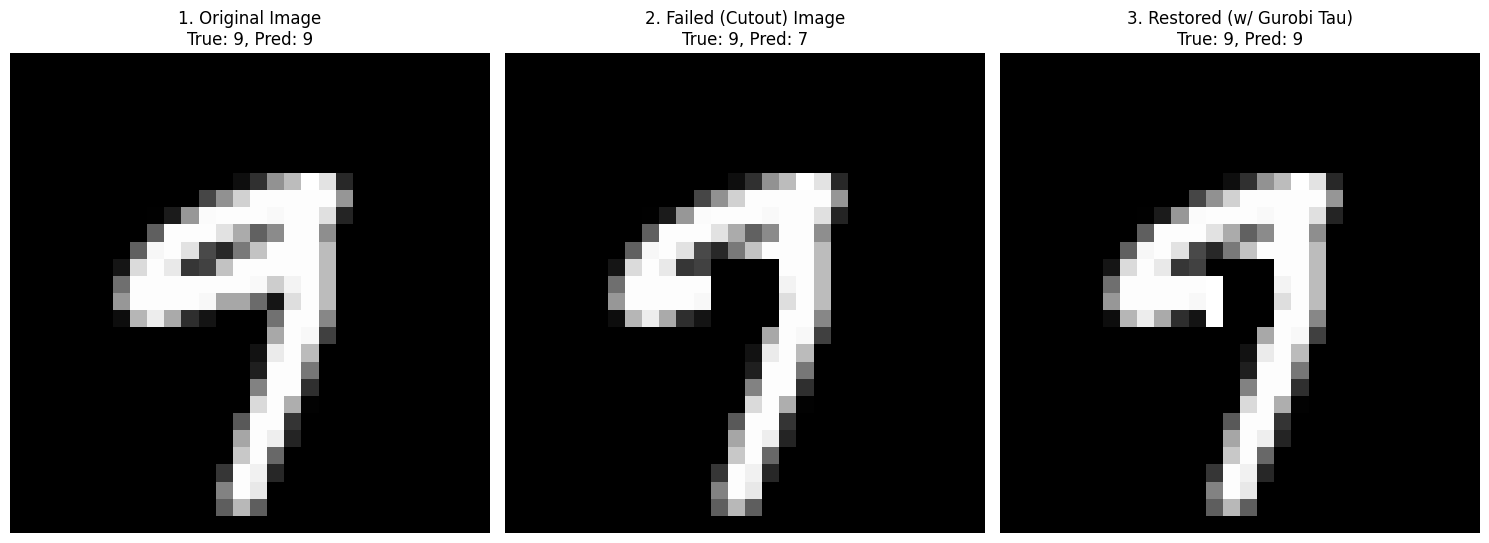


--- TEST 85/100: Image Index 836 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1156
Always active (L/U)      : 7378
Ambiguous ReLUs          : 874
ReLU binary variables    : 874
Binaries eliminated      : 8534
Binary reduction        : 90.71%
Starting optimized Gurobi optimization...
Solve time: 50.2156 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 836 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


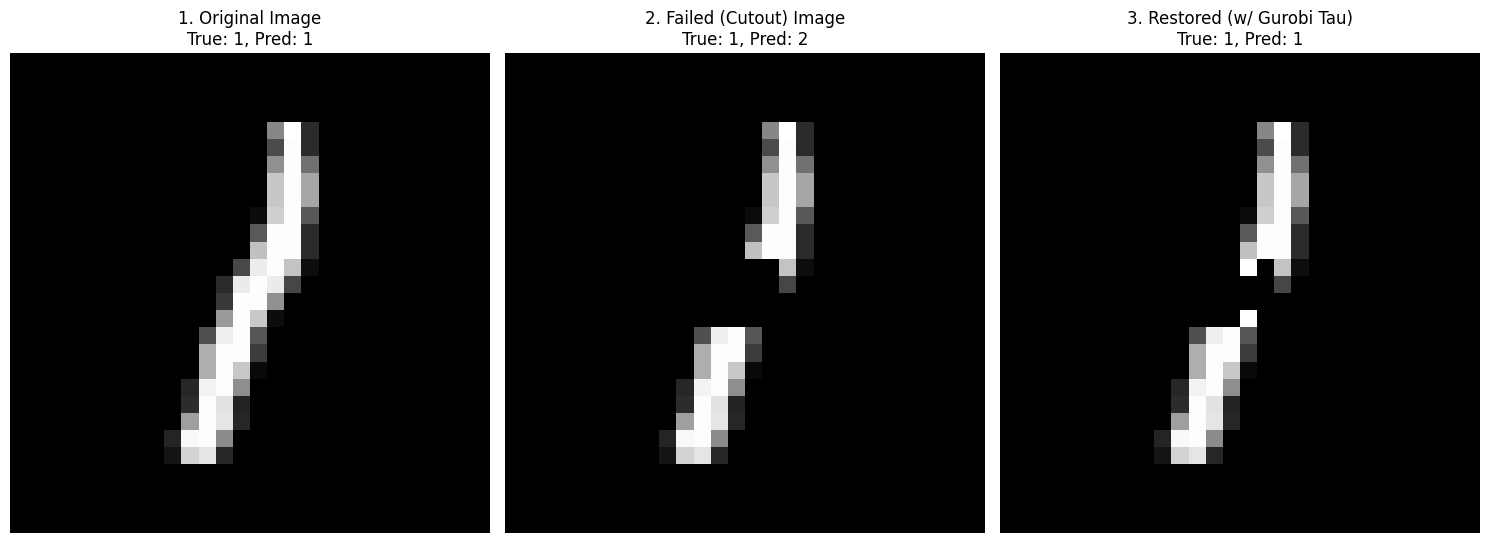


--- TEST 86/100: Image Index 840 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1225
Always active (L/U)      : 7427
Ambiguous ReLUs          : 756
ReLU binary variables    : 756
Binaries eliminated      : 8652
Binary reduction        : 91.96%
Starting optimized Gurobi optimization...
Solve time: 0.7646 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 840 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


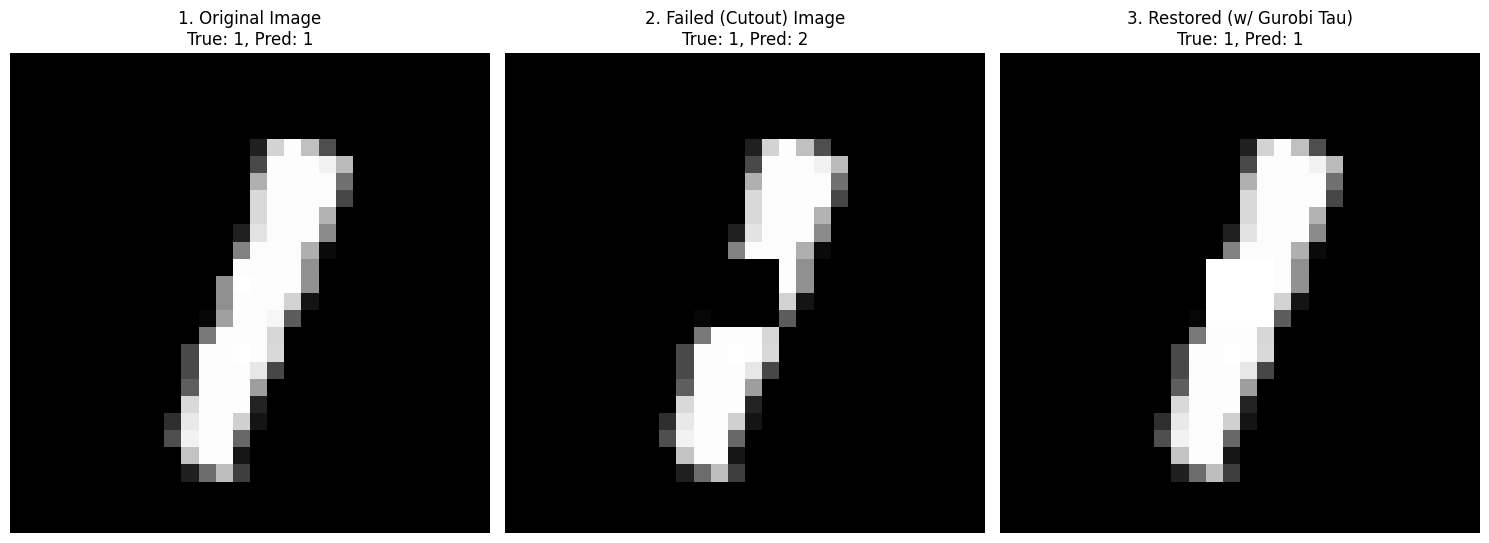


--- TEST 87/100: Image Index 848 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1165
Always active (L/U)      : 7371
Ambiguous ReLUs          : 872
ReLU binary variables    : 872
Binaries eliminated      : 8536
Binary reduction        : 90.73%
Starting optimized Gurobi optimization...
Solve time: 9.4745 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 848 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


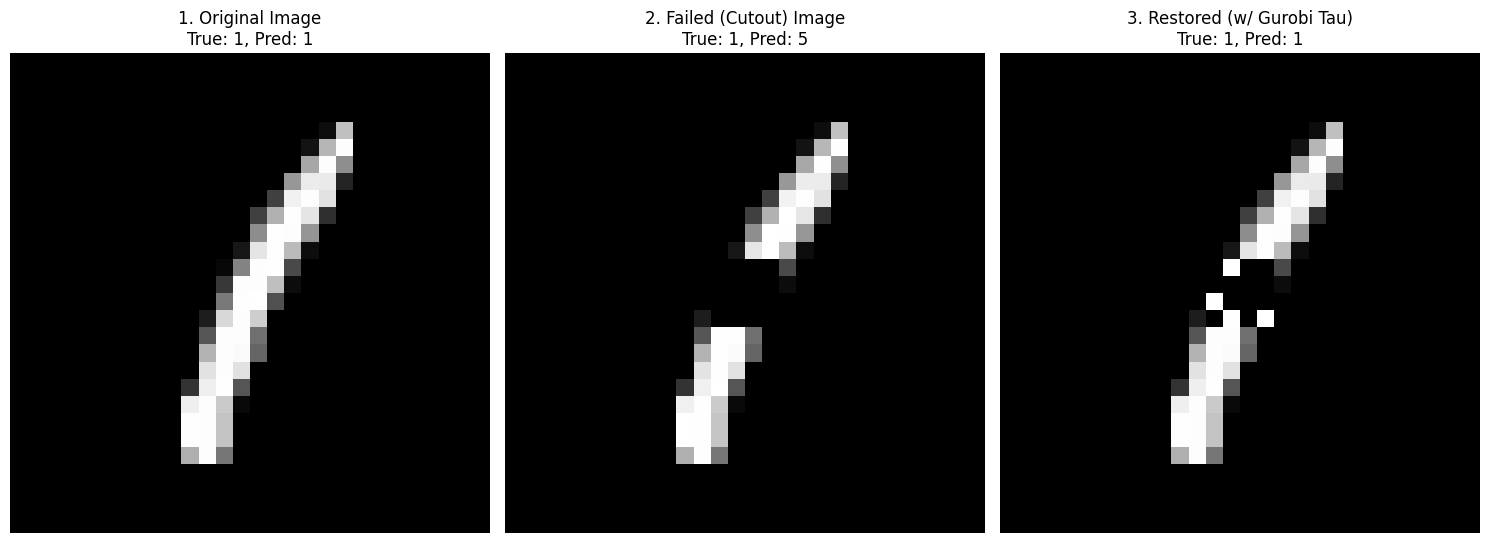


--- TEST 88/100: Image Index 850 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1196
Always active (L/U)      : 7414
Ambiguous ReLUs          : 798
ReLU binary variables    : 798
Binaries eliminated      : 8610
Binary reduction        : 91.52%
Starting optimized Gurobi optimization...
Solve time: 0.7977 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 850 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


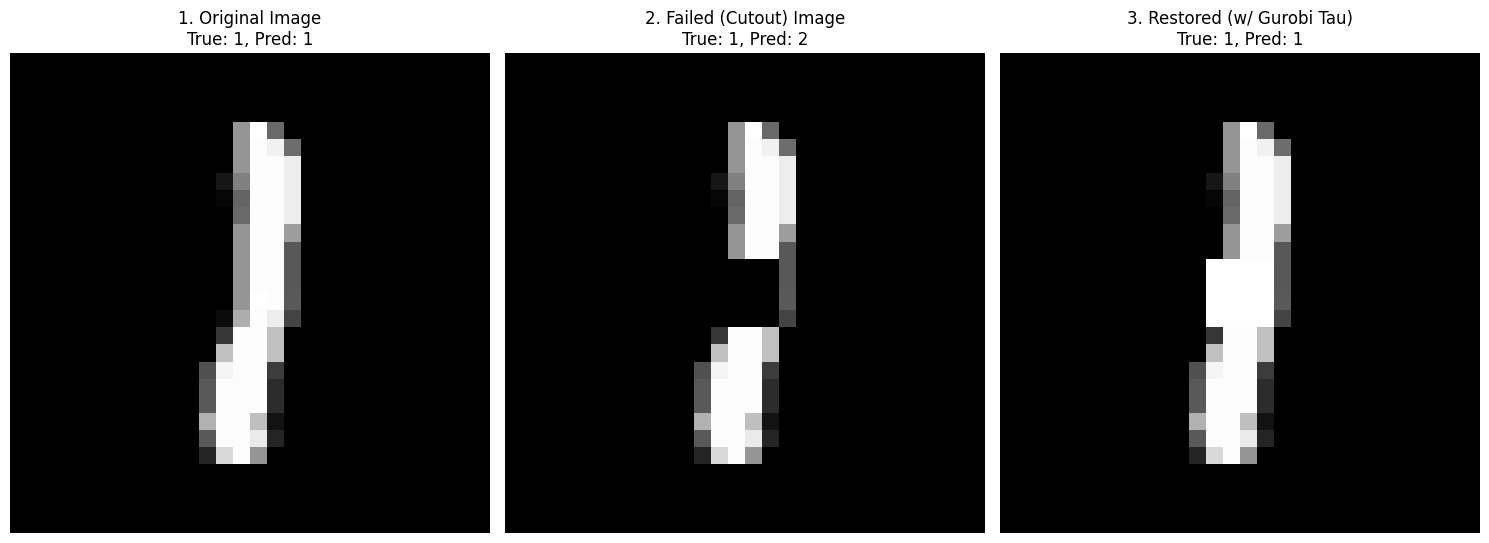


--- TEST 89/100: Image Index 89 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1199
Always active (L/U)      : 7397
Ambiguous ReLUs          : 812
ReLU binary variables    : 812
Binaries eliminated      : 8596
Binary reduction        : 91.37%
Starting optimized Gurobi optimization...
Solve time: 0.7217 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 89 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


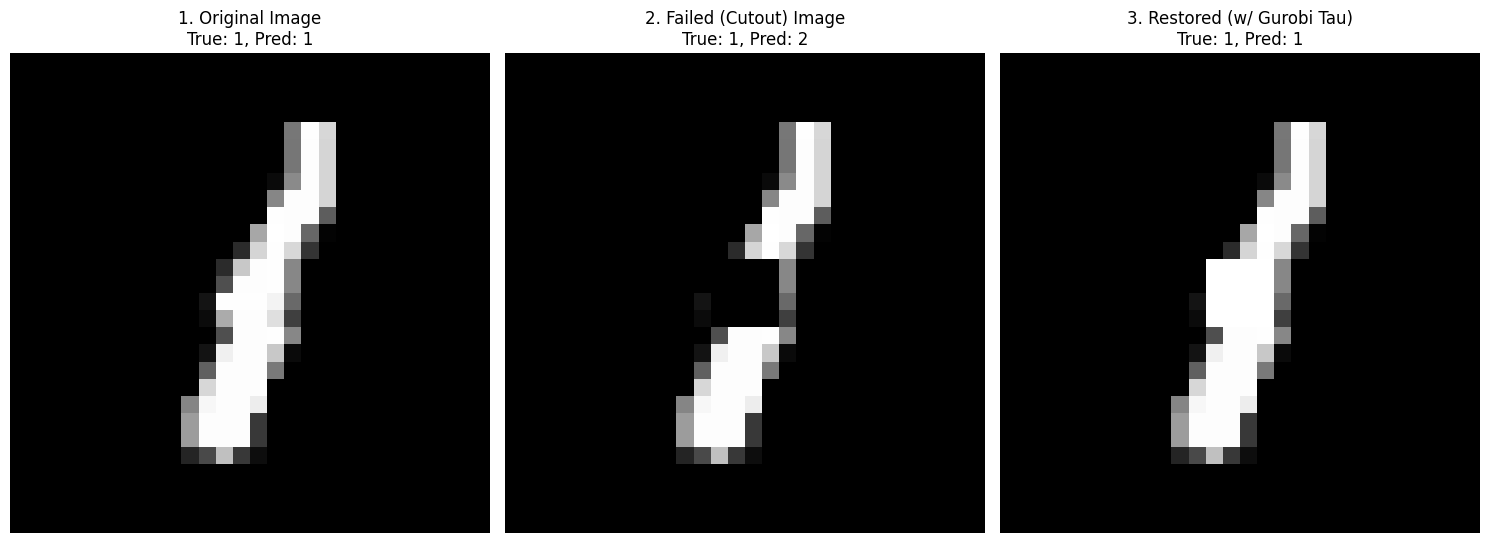


--- TEST 90/100: Image Index 907 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1152
Always active (L/U)      : 7366
Ambiguous ReLUs          : 890
ReLU binary variables    : 890
Binaries eliminated      : 8518
Binary reduction        : 90.54%
Starting optimized Gurobi optimization...
Solve time: 31.4538 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 907 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


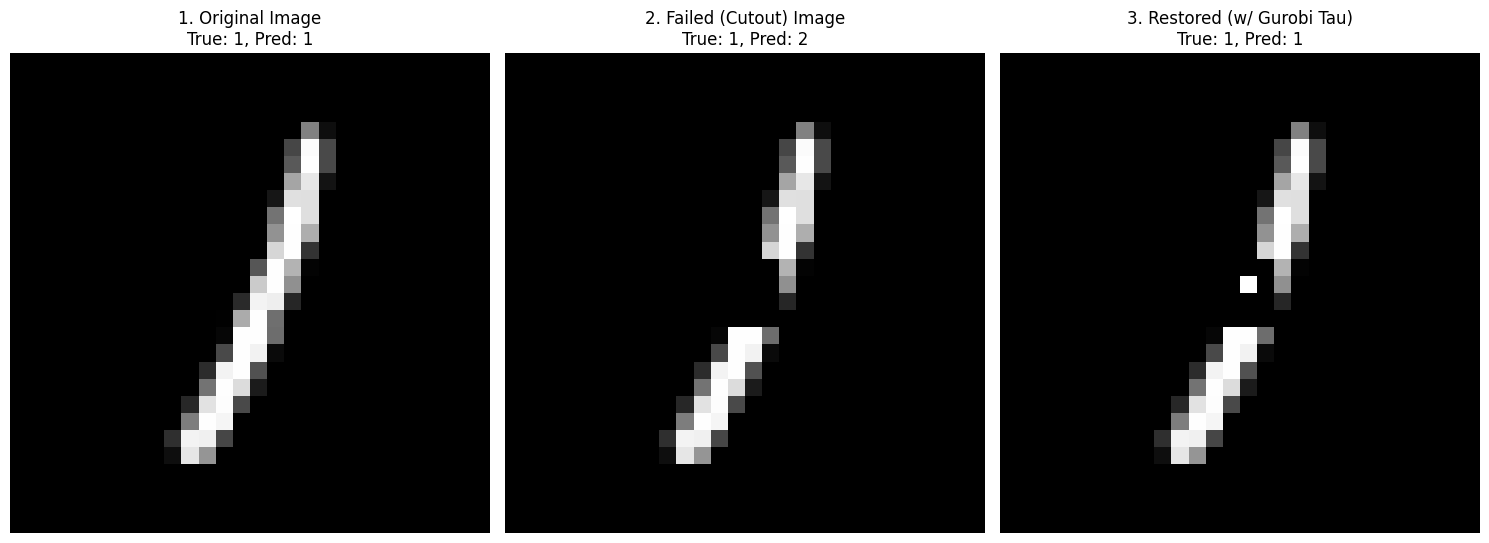


--- TEST 91/100: Image Index 938 ---
Running Gurobi to find corrective 'tau' patch for target 3...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1501
Always active (L/U)      : 7214
Ambiguous ReLUs          : 693
ReLU binary variables    : 693
Binaries eliminated      : 8715
Binary reduction        : 92.63%
Starting optimized Gurobi optimization...
Solve time: 84.3522 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 938 - True Label: 3
  Prediction (Original): 3 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 3 (Correct)
----------------------------------------


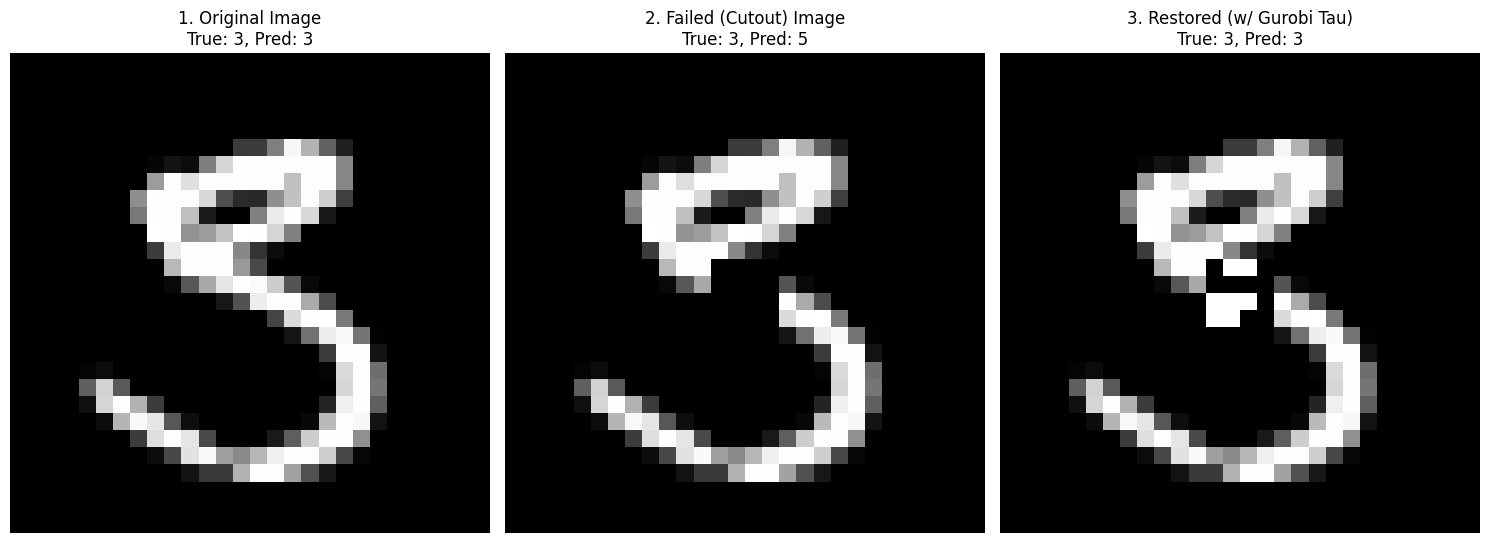


--- TEST 92/100: Image Index 94 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1309
Always active (L/U)      : 7432
Ambiguous ReLUs          : 667
ReLU binary variables    : 667
Binaries eliminated      : 8741
Binary reduction        : 92.91%
Starting optimized Gurobi optimization...
Solve time: 39.3979 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 94 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


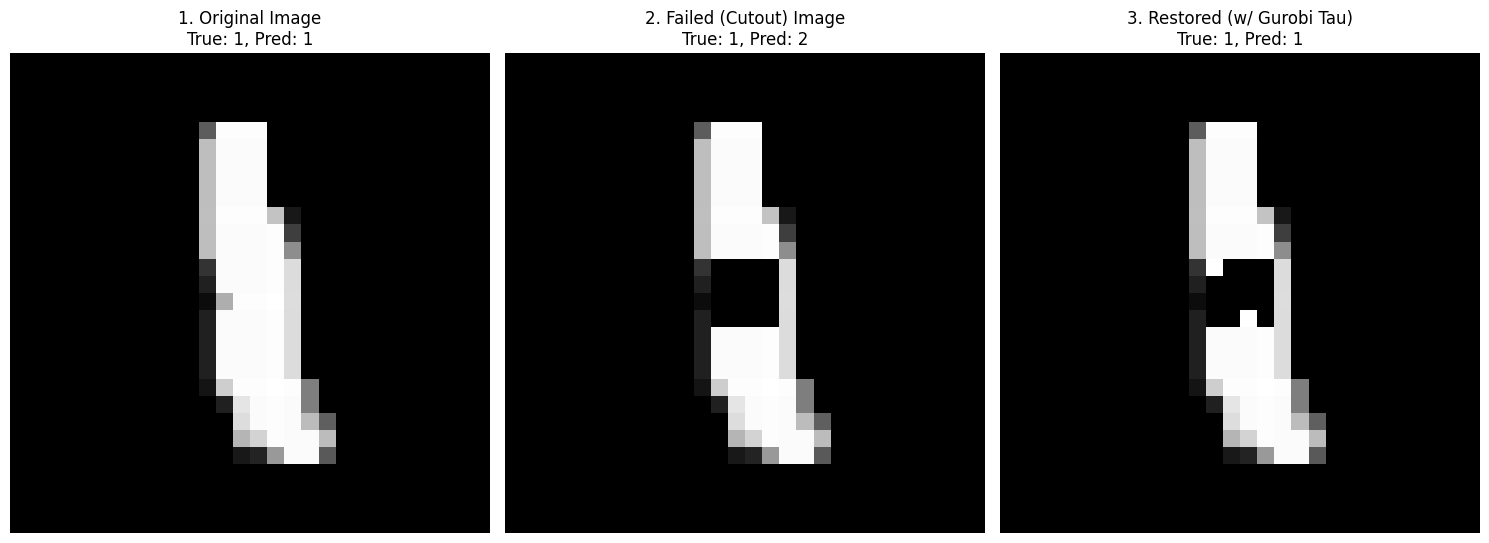


--- TEST 93/100: Image Index 954 ---
Running Gurobi to find corrective 'tau' patch for target 9...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1273
Always active (L/U)      : 7436
Ambiguous ReLUs          : 699
ReLU binary variables    : 699
Binaries eliminated      : 8709
Binary reduction        : 92.57%
Starting optimized Gurobi optimization...
Solve time: 83.4441 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 954 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


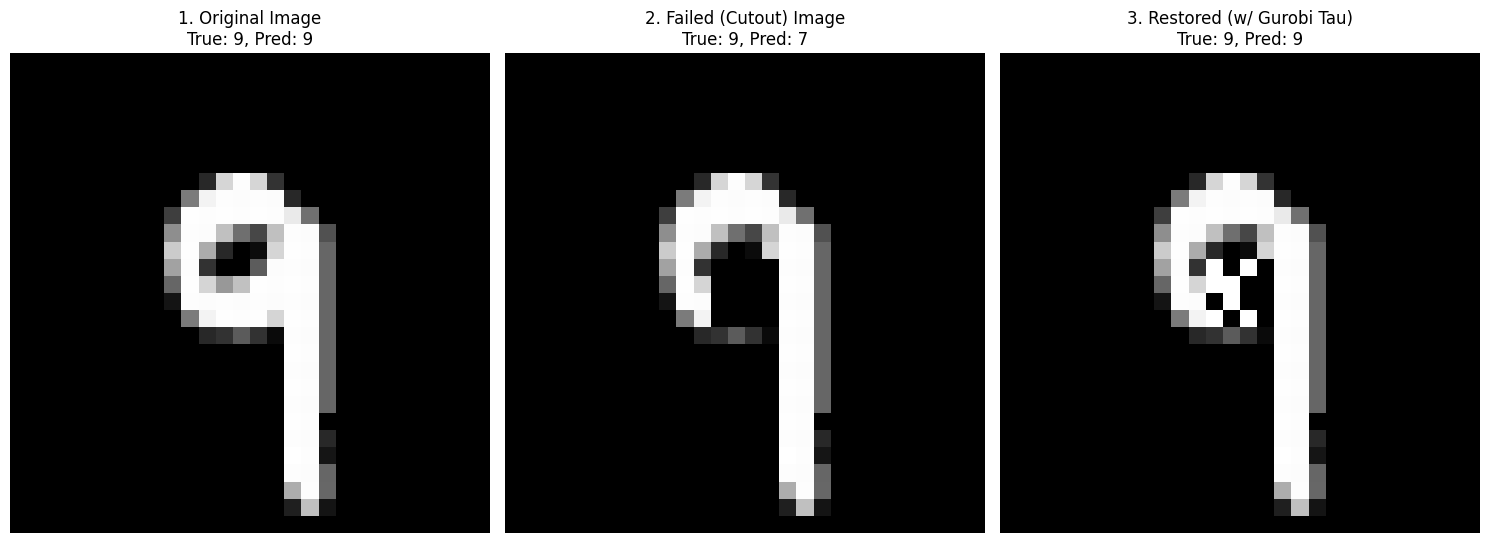


--- TEST 94/100: Image Index 956 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1342
Always active (L/U)      : 7318
Ambiguous ReLUs          : 748
ReLU binary variables    : 748
Binaries eliminated      : 8660
Binary reduction        : 92.05%
Starting optimized Gurobi optimization...
Solve time: 0.7802 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 956 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


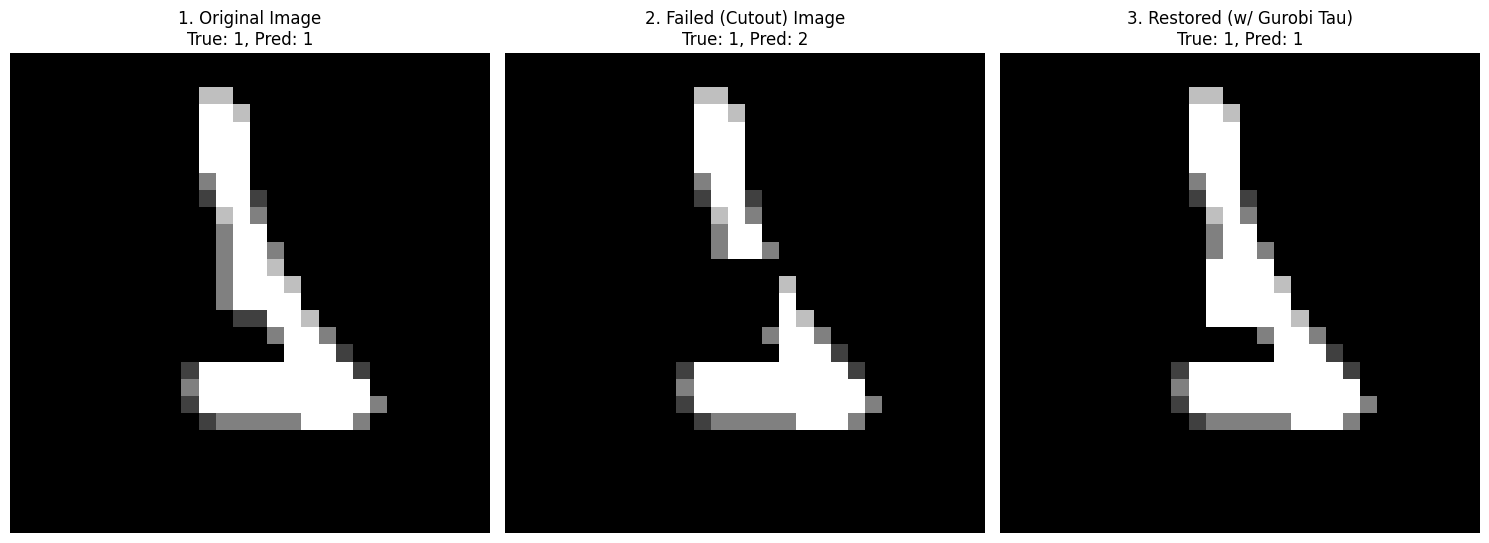


--- TEST 95/100: Image Index 958 ---
Running Gurobi to find corrective 'tau' patch for target 3...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1372
Always active (L/U)      : 7283
Ambiguous ReLUs          : 753
ReLU binary variables    : 753
Binaries eliminated      : 8655
Binary reduction        : 92.00%
Starting optimized Gurobi optimization...
Solve time: 5.0484 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 958 - True Label: 3
  Prediction (Original): 3 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 3 (Correct)
----------------------------------------


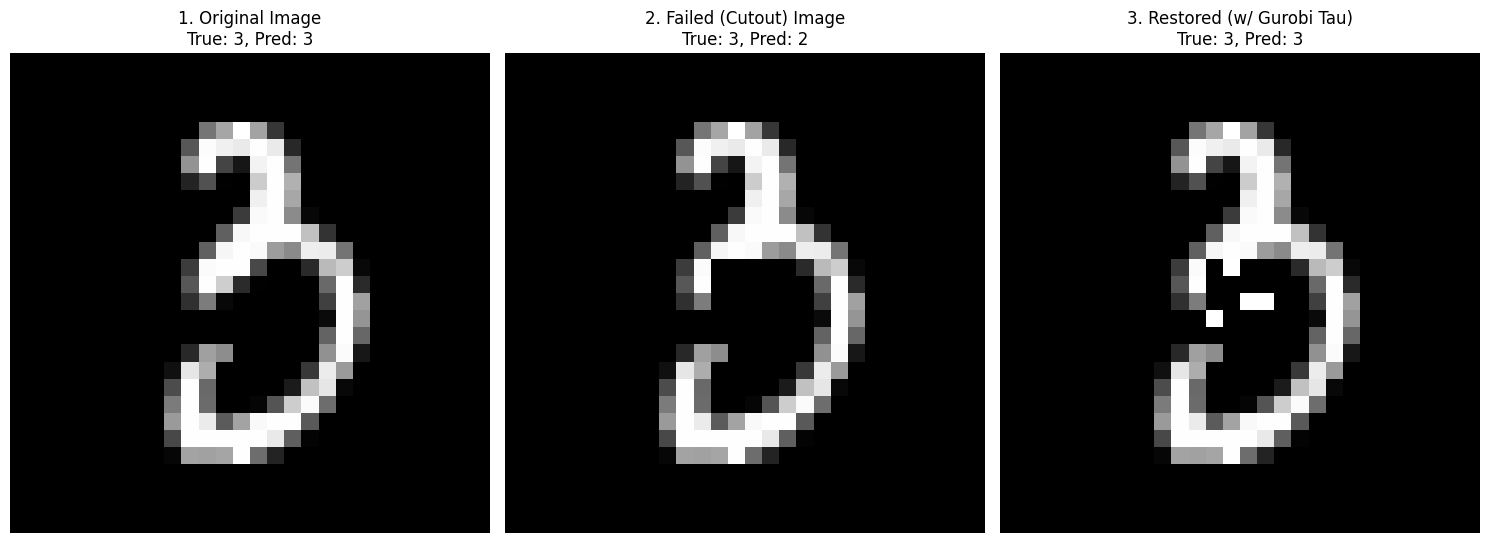


--- TEST 96/100: Image Index 964 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1140
Always active (L/U)      : 7338
Ambiguous ReLUs          : 930
ReLU binary variables    : 930
Binaries eliminated      : 8478
Binary reduction        : 90.11%
Starting optimized Gurobi optimization...
Solve time: 6.4797 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 964 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


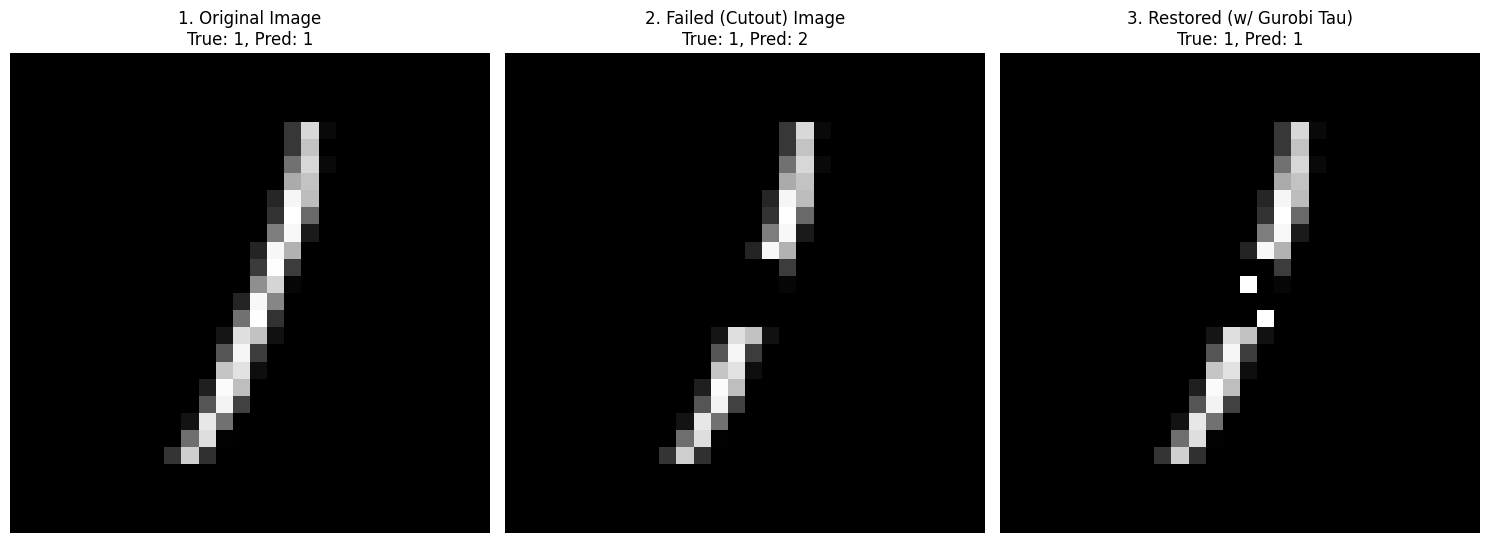


--- TEST 97/100: Image Index 966 ---
Running Gurobi to find corrective 'tau' patch for target 9...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1283
Always active (L/U)      : 7441
Ambiguous ReLUs          : 684
ReLU binary variables    : 684
Binaries eliminated      : 8724
Binary reduction        : 92.73%
Starting optimized Gurobi optimization...
Solve time: 59.5739 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 966 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


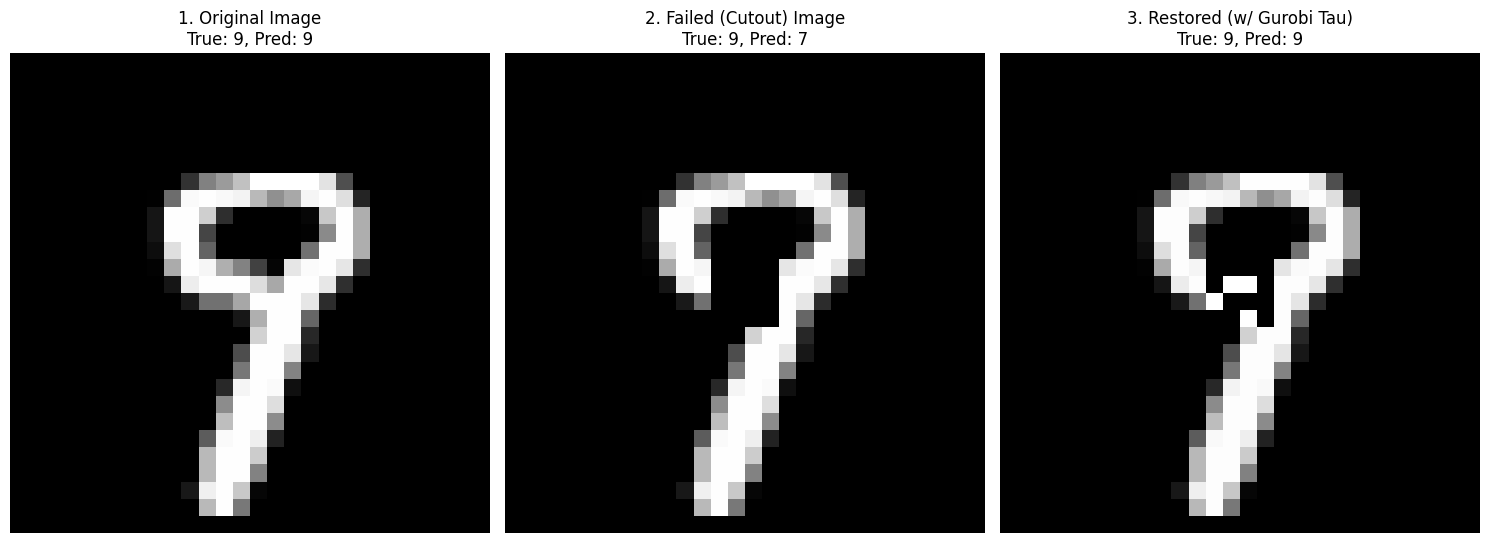


--- TEST 98/100: Image Index 977 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1261
Always active (L/U)      : 7405
Ambiguous ReLUs          : 742
ReLU binary variables    : 742
Binaries eliminated      : 8666
Binary reduction        : 92.11%
Starting optimized Gurobi optimization...
Solve time: 0.6988 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 977 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


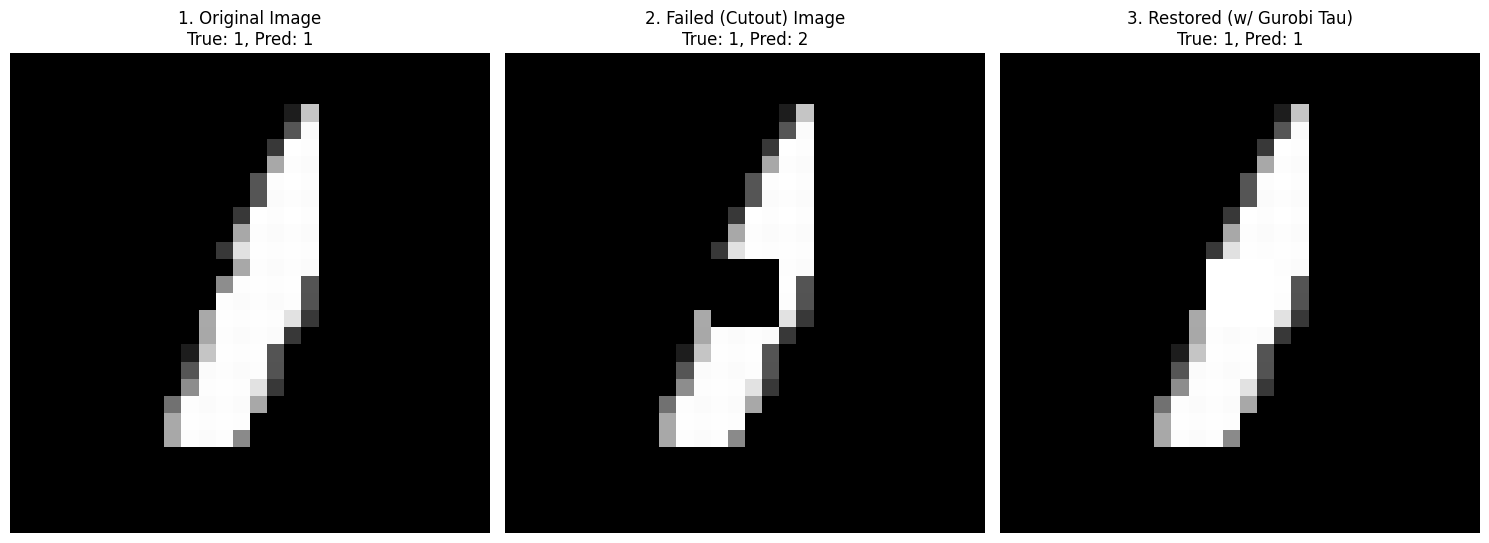


--- TEST 99/100: Image Index 979 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1251
Always active (L/U)      : 7369
Ambiguous ReLUs          : 788
ReLU binary variables    : 788
Binaries eliminated      : 8620
Binary reduction        : 91.62%
Starting optimized Gurobi optimization...
Solve time: 0.7056 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 979 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   3 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


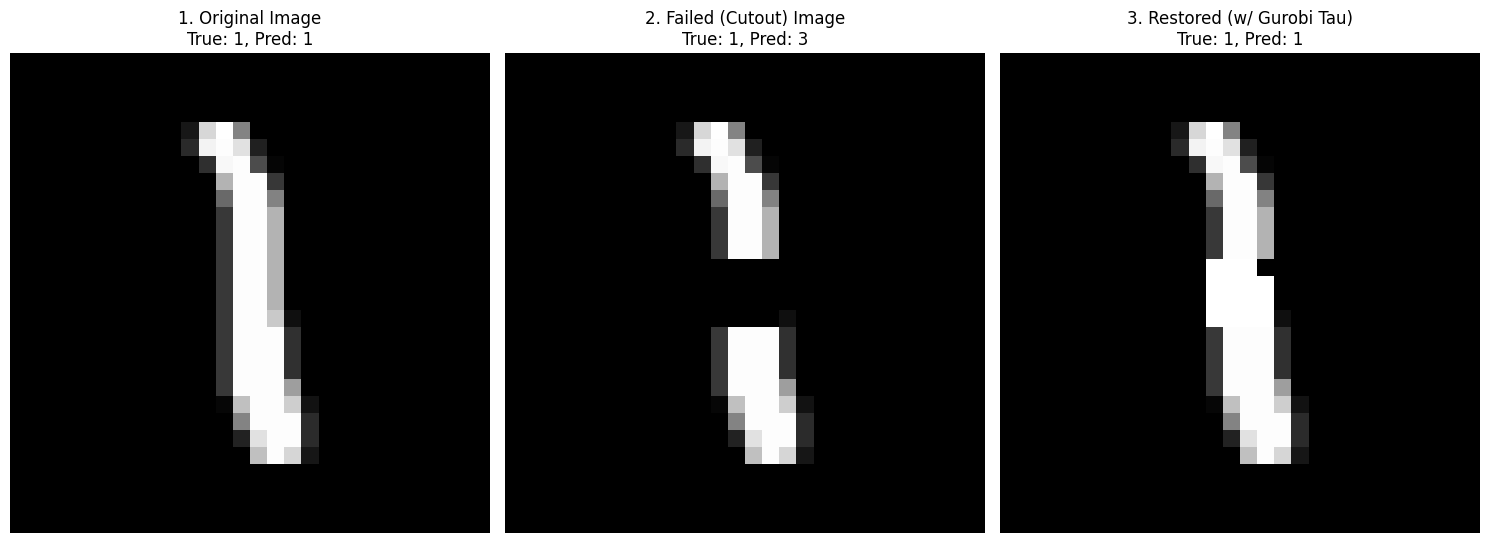


--- TEST 100/100: Image Index 994 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1299
Always active (L/U)      : 7336
Ambiguous ReLUs          : 773
ReLU binary variables    : 773
Binaries eliminated      : 8635
Binary reduction        : 91.78%
Starting optimized Gurobi optimization...
Solve time: 0.7781 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 994 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


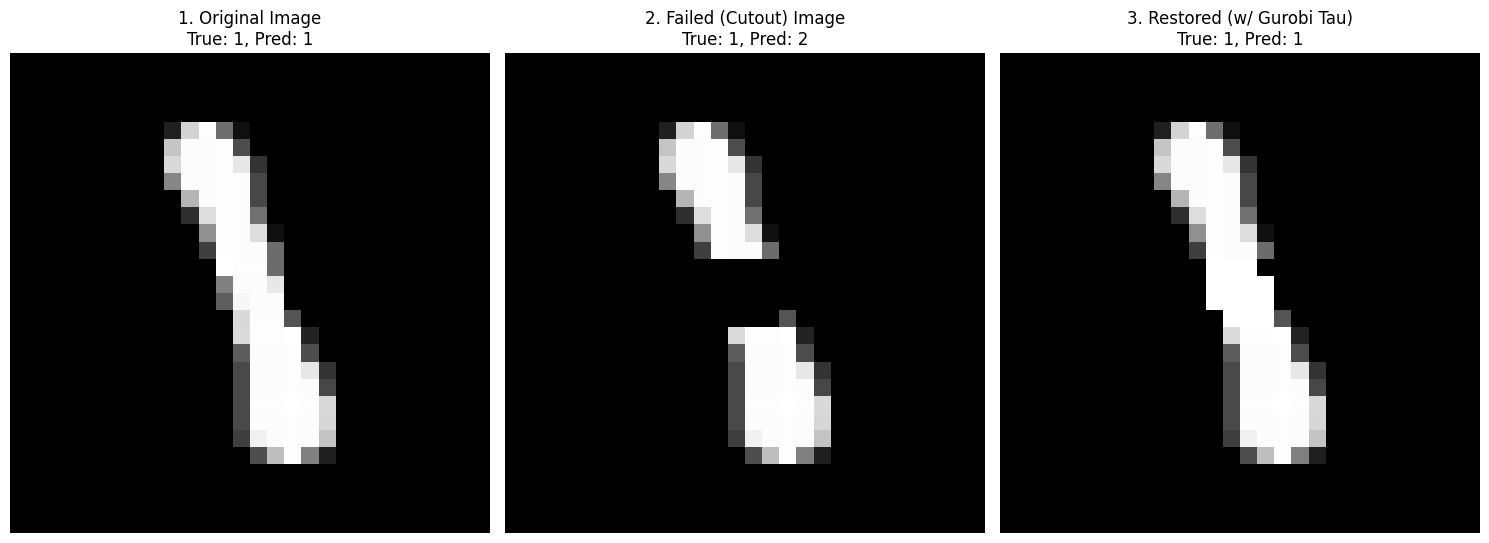

Total Images Processed: 100
  Gurobi Found a Fix (Success):   99
  Gurobi Failed (Infeasible/Timeout): 1
  Gurobi/Code Error:            0
---
Keras Confirmed Correct: 99
Restoration Accuracy: 99 / 100 = 99.00%


In [15]:
print("\n 8. Running Full Verification Test on Multiple Images for binarised TAU")

#1 Find all available failed images
data_folder = "./cnn_failures/"
failed_images_to_test = []

if not os.path.exists(data_folder) or not os.listdir(data_folder):
    print(f"Error: Folder '{data_folder}' is empty or does not exist.")
    print("Please run Block 10 (generate_cutout_images_cnn) first.")
else:
    for filename in os.listdir(data_folder):
        if filename.startswith("failed_image_") and filename.endswith(".npy"):
            try:
                image_index_str = filename.split('_')[-1].split('.')[0]
                image_index = int(image_index_str)

                label_path = os.path.join(data_folder, f"failed_label_{image_index}.npy")
                image_path = os.path.join(data_folder, filename)

                if os.path.exists(label_path):
                    true_label = np.load(label_path).item()
                    failed_images_to_test.append((image_index, image_path, true_label))
                else:
                    print(f"Warning: Found image {filename} but missing label file. Skipping.")

            except Exception as e:
                print(f"Could not parse index from {filename}: {e}")

# 2. Set processing limit
num_to_process = len(failed_images_to_test)

if num_to_process == 0:
    print("No failed image files found in 'cnn_failures/'.")
    print("Please run Block 10 to generate these files first.")
else:
    print(f"Found {len(failed_images_to_test)} failed images. Processing all of them...")

    cor = 0 # "Corrected" / "Fixed"
    incor = 0 # "Gurobi Failed"
    unclassified = 0 # "Infeasible" or "Timeout"
    cnt = 0

    restored_correctly_count = 0

    # 3. Loop through each failed image and run the test
    for i in range(num_to_process):

        image_index, failed_image_path, true_label = failed_images_to_test[i]
        cnt += 1

        print("\n" + "="*50)
        print(f"--- TEST {i+1}/{num_to_process}: Image Index {image_index} ---")
        print("="*50)

        # a. The original (non-cutout) image from the test set
        original_image = x_test[image_index]

        # b. The failed (cutout) image
        failed_image = np.load(failed_image_path)

        # 5. Run Gurobi to get the corrective 'tau' patch
        print(f"Running Gurobi to find corrective 'tau' patch for target {true_label}...")

        # This now calls the GENERALIZED function. this we have defined above
        (tau_values, gurobi_prediction) = model_encoding(failed_image, true_label, num_conv_layers=N_LAYERS,tauType=0)

        if tau_values is not None:
            print("Gurobi found a solution. Preparing comparison...")

            # 6. Create the Restored image
            grid_size = 4 # Updated
            x_centre, y_centre = 14, 14
            grid_bound = grid_size // 2
            start_x, start_y = x_centre - grid_bound, y_centre - grid_bound

            tau_patch = np.array(tau_values).reshape(grid_size, grid_size)
            restored_image = failed_image.copy()
            restored_image[start_x:start_x + grid_size, start_y:start_y + grid_size, 0] += tau_patch
            restored_image = np.clip(restored_image, 0, 1)

            # 7. Get Predictions for all 3 images i.e. original vs perturbed vs restored
            def get_pred(image):
                img_batch = np.expand_dims(image, axis=0)
                pred = model_cnn.predict(img_batch, verbose=0)
                return np.argmax(pred)

            pred_original = get_pred(original_image)
            pred_failed = get_pred(failed_image)
            pred_restored = get_pred(restored_image)

            if pred_restored == true_label:
                restored_correctly_count += 1

            # results
            print("\n" + "-"*40)
            print(f"Image {image_index} - True Label: {true_label}")
            print(f"  Prediction (Original): {pred_original} {'(Correct)' if pred_original == true_label else '(Incorrect)'}")
            print(f"  Prediction (Failed):   {pred_failed} {'(Correct)' if pred_failed == true_label else '(Incorrect)'}")
            print(f"  Prediction (Restored): {pred_restored} {'(Correct)' if pred_restored == true_label else '(Incorrect)'}")
            print("-"*40)

            plt.figure(figsize=(15, 6))
            plt.subplot(1, 3, 1)
            plt.imshow(original_image.squeeze(), cmap='gray')
            plt.title(f"1. Original Image\nTrue: {true_label}, Pred: {pred_original}")
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.imshow(failed_image.squeeze(), cmap='gray')
            plt.title(f"2. Failed (Cutout) Image\nTrue: {true_label}, Pred: {pred_failed}")
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.imshow(restored_image.squeeze(), cmap='gray')
            plt.title(f"3. Restored (w/ Gurobi Tau)\nTrue: {true_label}, Pred: {pred_restored}")
            plt.axis('off')

            plt.tight_layout()
            plt.show()

            cor += 1

        else:
            print(f"Gurobi could not find a corrective patch for image {image_index}.")
            unclassified += 1 # Gurobi was INFEASIBLE or TIMED OUT

    # print("\n" + "="*30)
    # print("FINAL RESULTS")
    # print("="*30)
    # print(f"Success (Fixed)={cor}, Failed (Gurobi error)={incor}, Unclassified (Not-Fixed)={unclassified}, Total={cnt}")
    # print(f"Total Processed Files: {cnt}")

    print(f"Total Images Processed: {cnt}")
    print(f"  Gurobi Found a Fix (Success):   {cor}")
    print(f"  Gurobi Failed (Infeasible/Timeout): {unclassified}")
    print(f"  Gurobi/Code Error:            {incor}")
    print(f"---")
    print(f"Keras Confirmed Correct: {restored_correctly_count}")

    if cnt > 0:
        accuracy = (restored_correctly_count / cnt) * 100
        print(f"Restoration Accuracy: {restored_correctly_count} / {cnt} = {accuracy:.2f}%")
    else:
        print("Restoration Accuracy: N/A (no images processed)")



 9. Running Full Verification Test on Multiple Images for continuous TAU
Found 100 failed images. Processing all of them...

--- TEST 1/100: Image Index 1000 ---
Running Gurobi to find corrective 'tau' patch for target 9...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1244
Always active (L/U)      : 7426
Ambiguous ReLUs          : 738
ReLU binary variables    : 738
Binaries eliminated      : 8670
Binary reduction        : 92.16%
Starting optimized Gurobi optimization...
Solve time: 7.0597 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1000 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


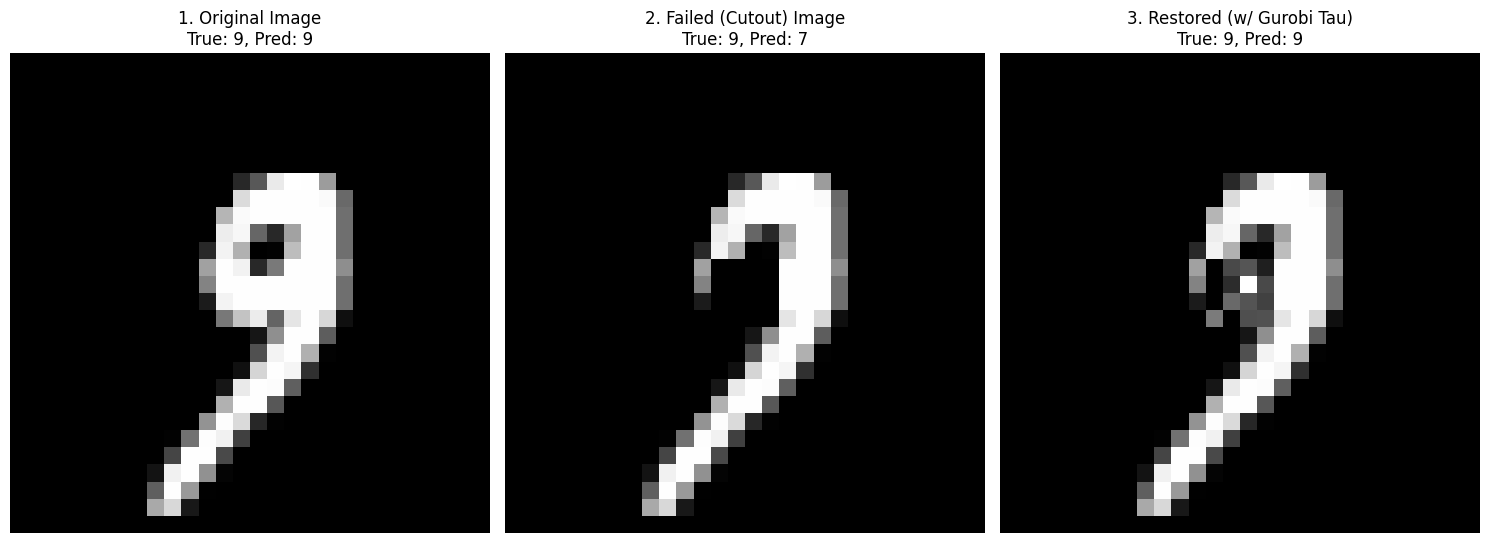


--- TEST 2/100: Image Index 1008 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1202
Always active (L/U)      : 7386
Ambiguous ReLUs          : 820
ReLU binary variables    : 820
Binaries eliminated      : 8588
Binary reduction        : 91.28%
Starting optimized Gurobi optimization...
Solve time: 2.5127 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1008 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


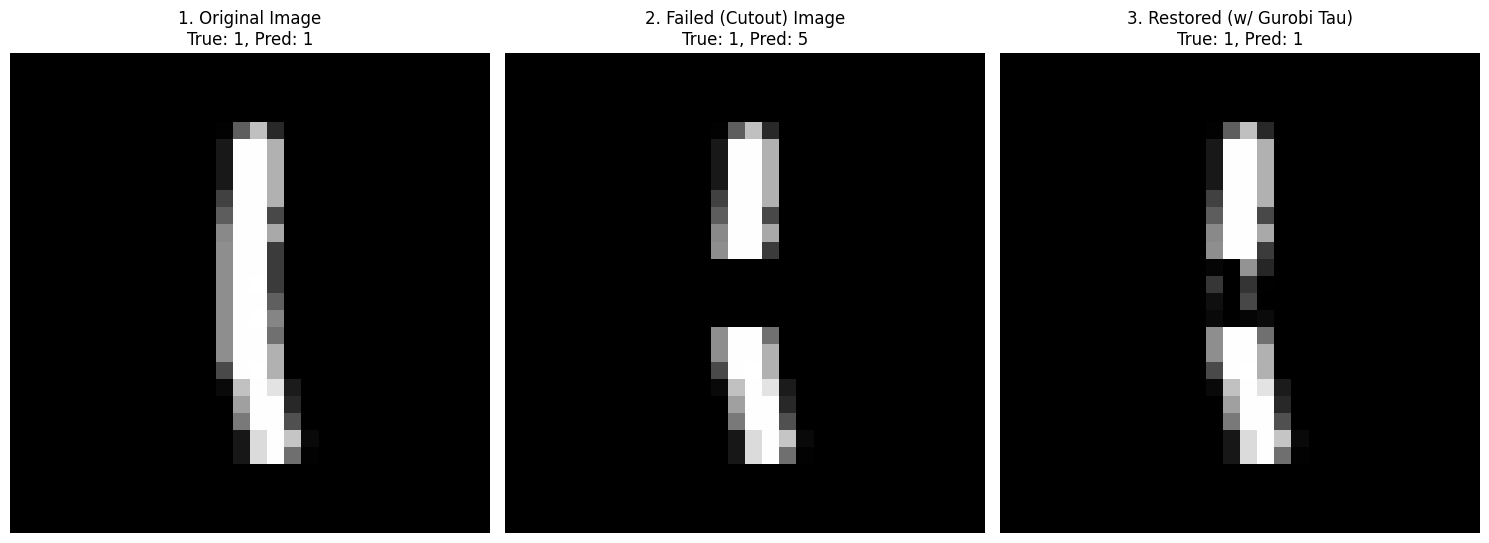


--- TEST 3/100: Image Index 1011 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1221
Always active (L/U)      : 7395
Ambiguous ReLUs          : 792
ReLU binary variables    : 792
Binaries eliminated      : 8616
Binary reduction        : 91.58%
Starting optimized Gurobi optimization...
Solve time: 10.2429 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1011 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


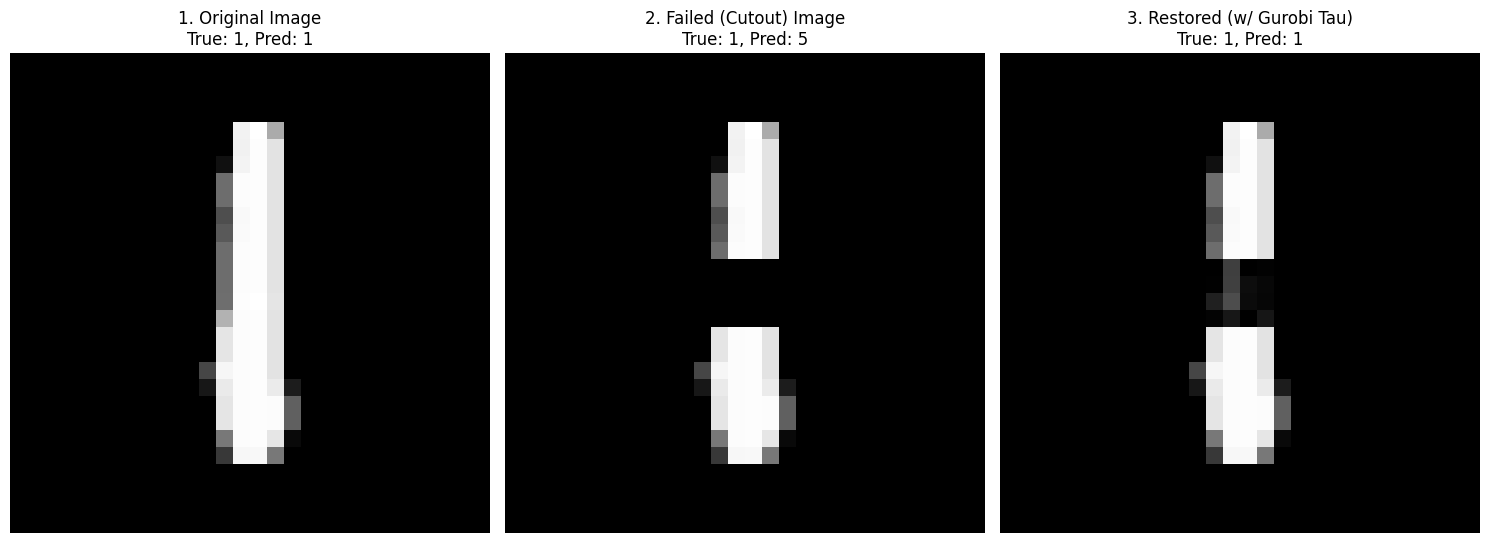


--- TEST 4/100: Image Index 1037 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1177
Always active (L/U)      : 7385
Ambiguous ReLUs          : 846
ReLU binary variables    : 846
Binaries eliminated      : 8562
Binary reduction        : 91.01%
Starting optimized Gurobi optimization...
Solve time: 2.7705 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1037 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


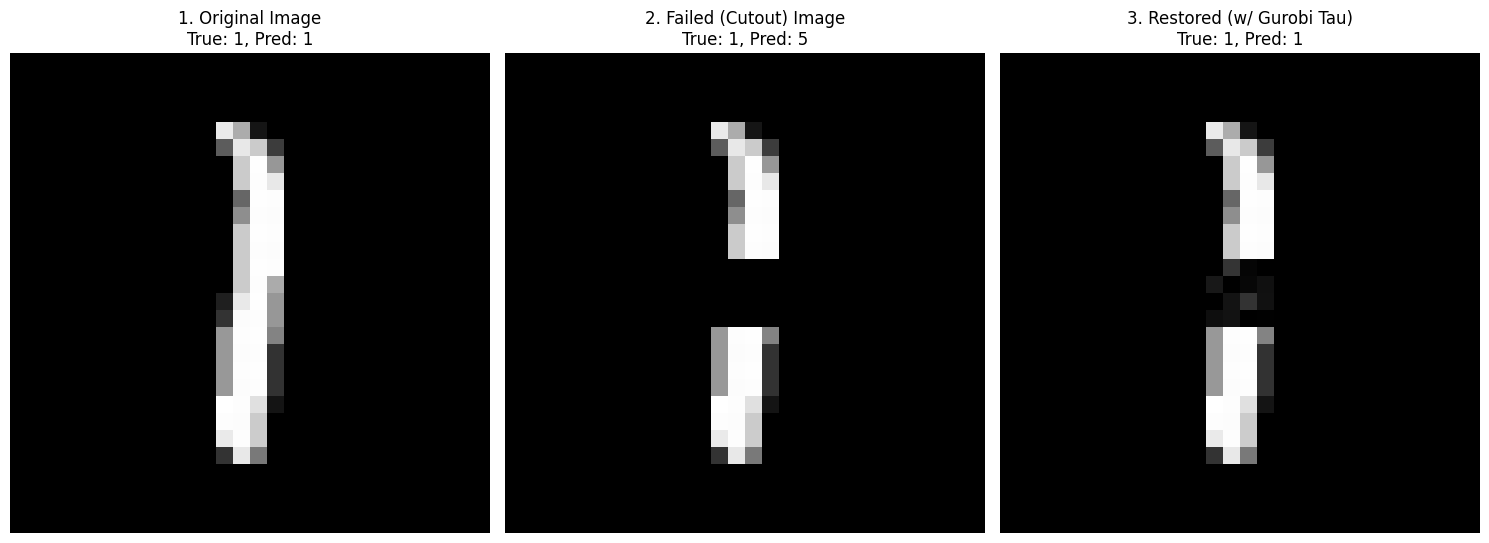


--- TEST 5/100: Image Index 1045 ---
Running Gurobi to find corrective 'tau' patch for target 9...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1260
Always active (L/U)      : 7457
Ambiguous ReLUs          : 691
ReLU binary variables    : 691
Binaries eliminated      : 8717
Binary reduction        : 92.66%
Starting optimized Gurobi optimization...
Solve time: 139.9844 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1045 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


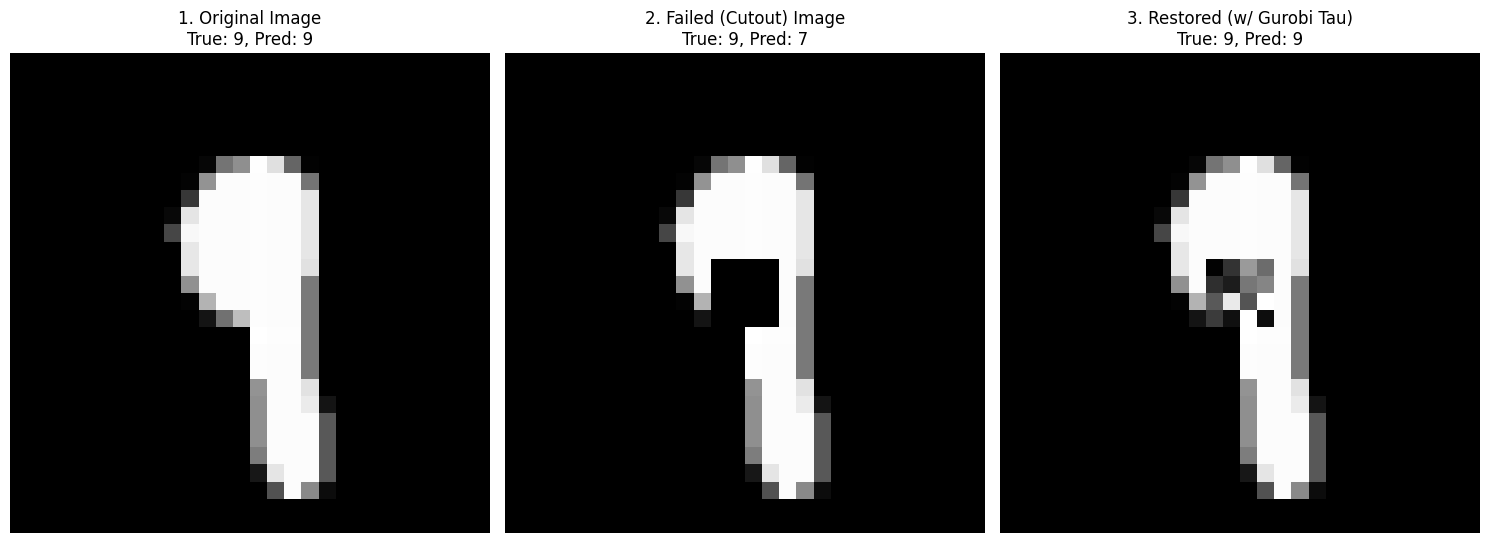


--- TEST 6/100: Image Index 107 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1220
Always active (L/U)      : 7328
Ambiguous ReLUs          : 860
ReLU binary variables    : 860
Binaries eliminated      : 8548
Binary reduction        : 90.86%
Starting optimized Gurobi optimization...
Solve time: 107.8006 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 107 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


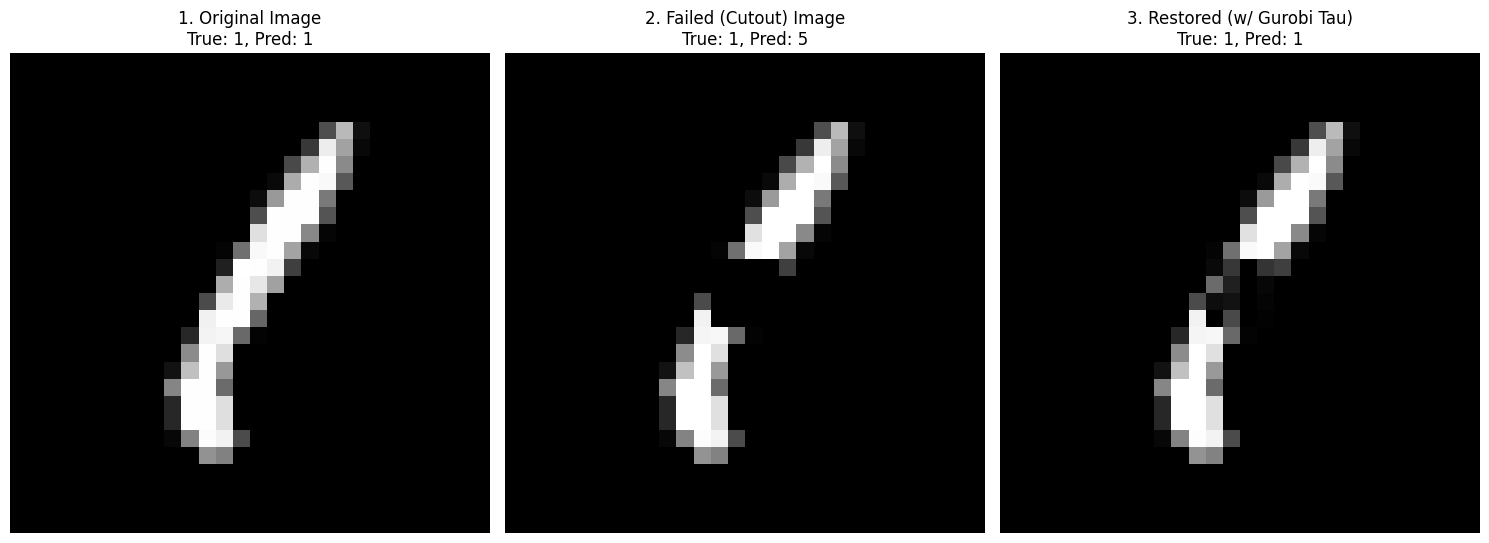


--- TEST 7/100: Image Index 1093 ---
Running Gurobi to find corrective 'tau' patch for target 8...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1440
Always active (L/U)      : 7318
Ambiguous ReLUs          : 650
ReLU binary variables    : 650
Binaries eliminated      : 8758
Binary reduction        : 93.09%
Starting optimized Gurobi optimization...
Solve time: 6.6281 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1093 - True Label: 8
  Prediction (Original): 8 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 8 (Correct)
----------------------------------------


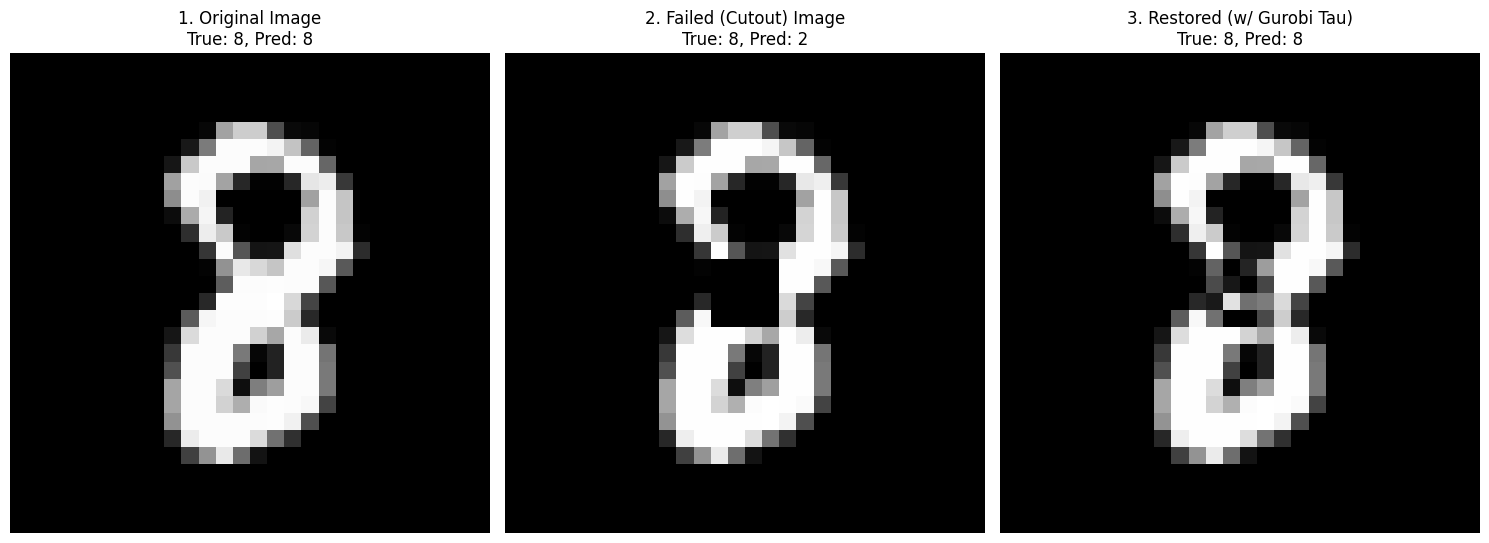


--- TEST 8/100: Image Index 1097 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1136
Always active (L/U)      : 7370
Ambiguous ReLUs          : 902
ReLU binary variables    : 902
Binaries eliminated      : 8506
Binary reduction        : 90.41%
Starting optimized Gurobi optimization...
Solve time: 2.9788 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1097 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


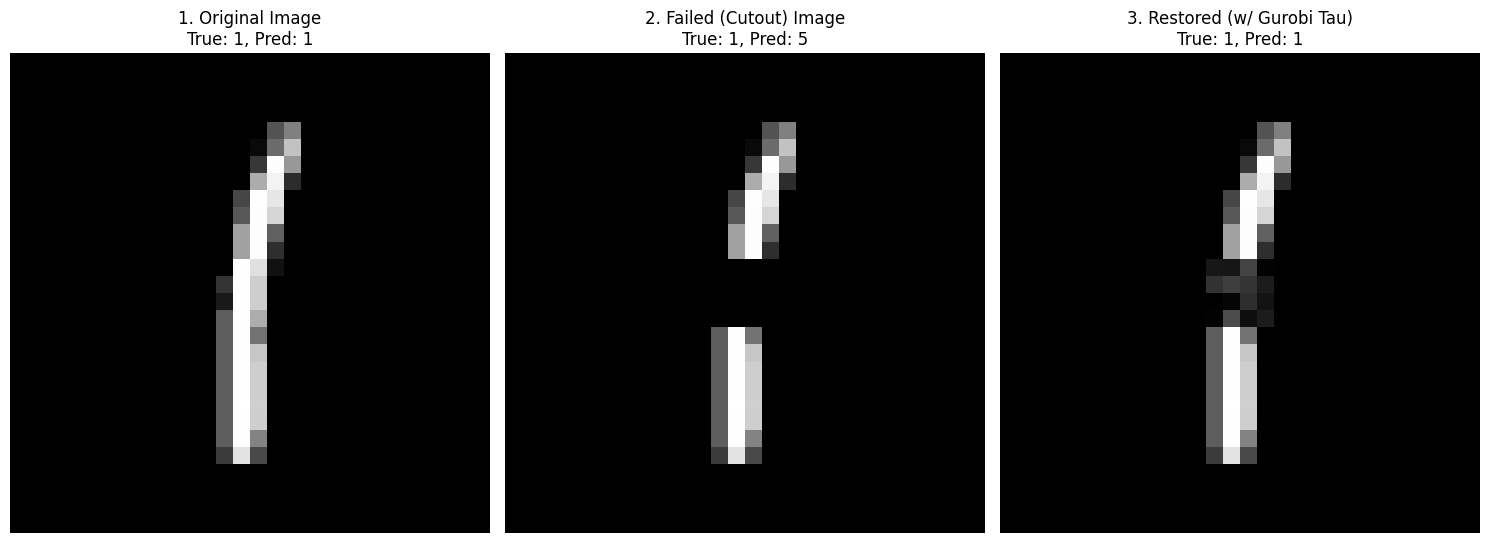


--- TEST 9/100: Image Index 1114 ---
Running Gurobi to find corrective 'tau' patch for target 3...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1456
Always active (L/U)      : 7337
Ambiguous ReLUs          : 615
ReLU binary variables    : 615
Binaries eliminated      : 8793
Binary reduction        : 93.46%
Starting optimized Gurobi optimization...
Solve time: 11.6892 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1114 - True Label: 3
  Prediction (Original): 3 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 3 (Correct)
----------------------------------------


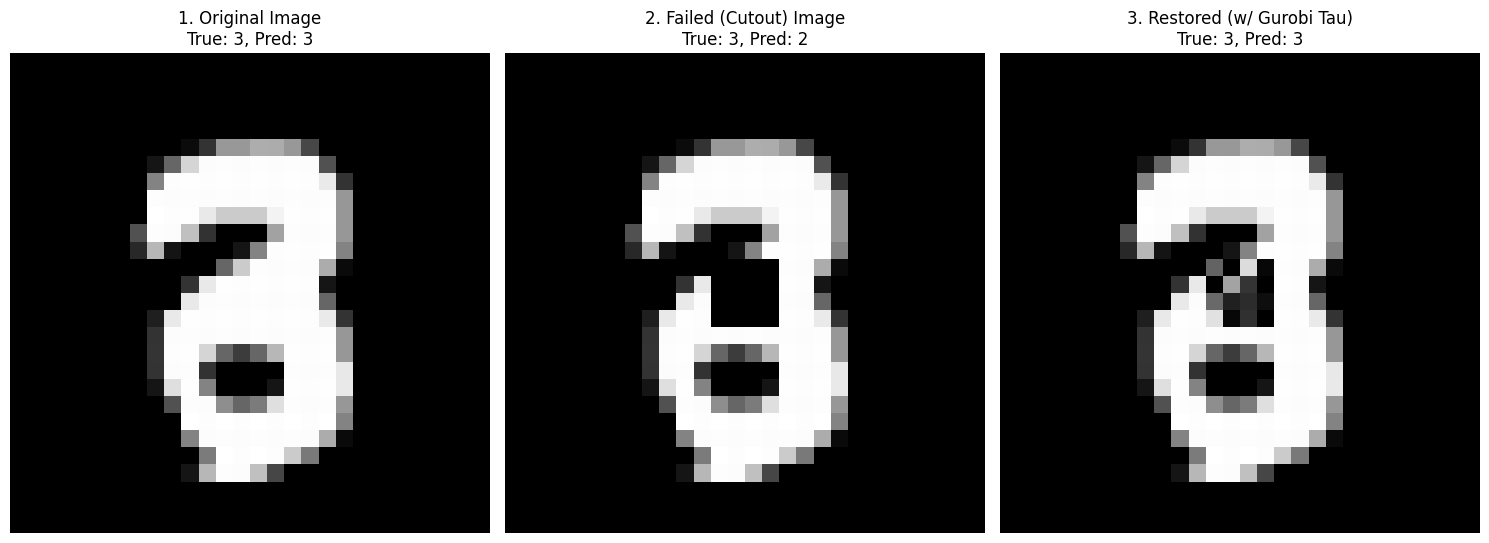


--- TEST 10/100: Image Index 1118 ---
Running Gurobi to find corrective 'tau' patch for target 8...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1532
Always active (L/U)      : 7212
Ambiguous ReLUs          : 664
ReLU binary variables    : 664
Binaries eliminated      : 8744
Binary reduction        : 92.94%
Starting optimized Gurobi optimization...
Solve time: 2.1910 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1118 - True Label: 8
  Prediction (Original): 8 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 8 (Correct)
----------------------------------------


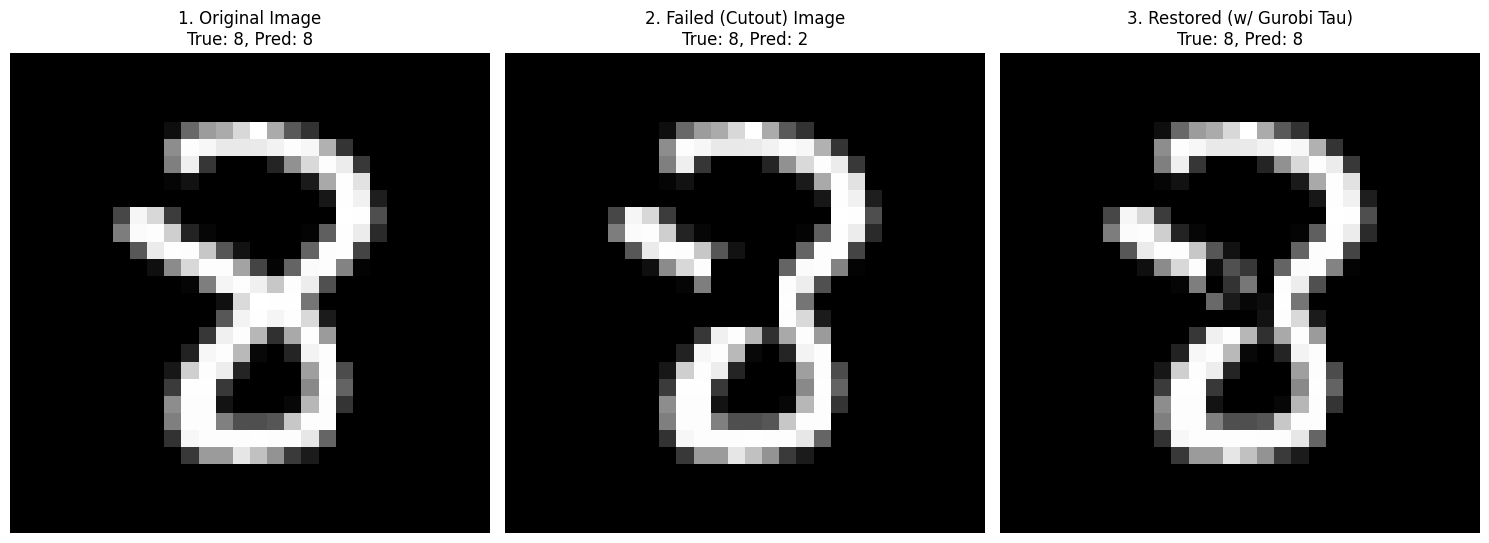


--- TEST 11/100: Image Index 1129 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1237
Always active (L/U)      : 7402
Ambiguous ReLUs          : 769
ReLU binary variables    : 769
Binaries eliminated      : 8639
Binary reduction        : 91.83%
Starting optimized Gurobi optimization...
Solve time: 9.8259 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1129 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


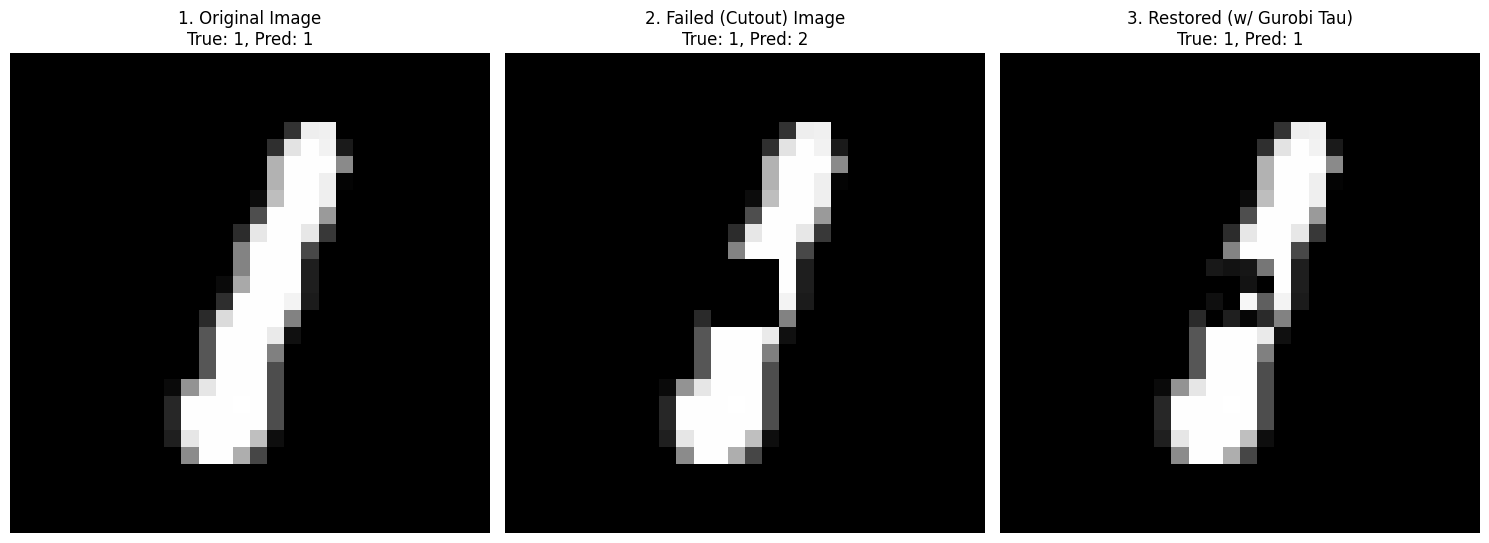


--- TEST 12/100: Image Index 1136 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1206
Always active (L/U)      : 7377
Ambiguous ReLUs          : 825
ReLU binary variables    : 825
Binaries eliminated      : 8583
Binary reduction        : 91.23%
Starting optimized Gurobi optimization...
Solve time: 18.0475 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1136 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


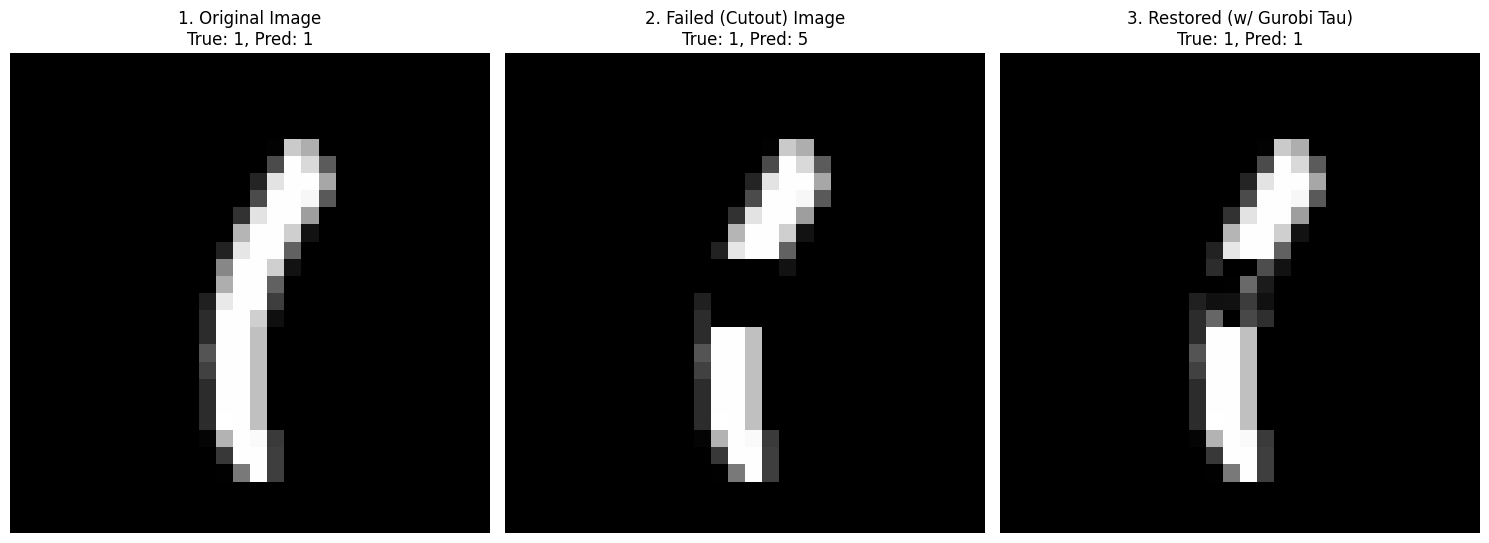


--- TEST 13/100: Image Index 1139 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1228
Always active (L/U)      : 7435
Ambiguous ReLUs          : 745
ReLU binary variables    : 745
Binaries eliminated      : 8663
Binary reduction        : 92.08%
Starting optimized Gurobi optimization...
Solve time: 2.2458 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1139 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


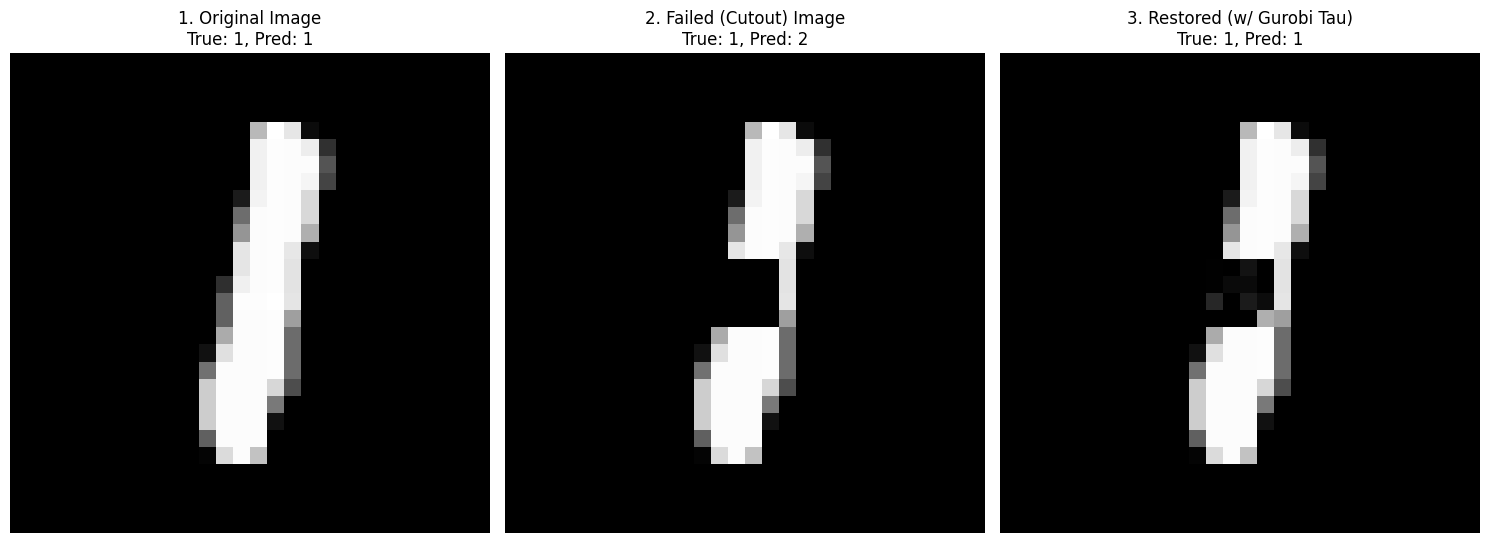


--- TEST 14/100: Image Index 1179 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1165
Always active (L/U)      : 7377
Ambiguous ReLUs          : 866
ReLU binary variables    : 866
Binaries eliminated      : 8542
Binary reduction        : 90.80%
Starting optimized Gurobi optimization...
Solve time: 3.0881 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1179 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


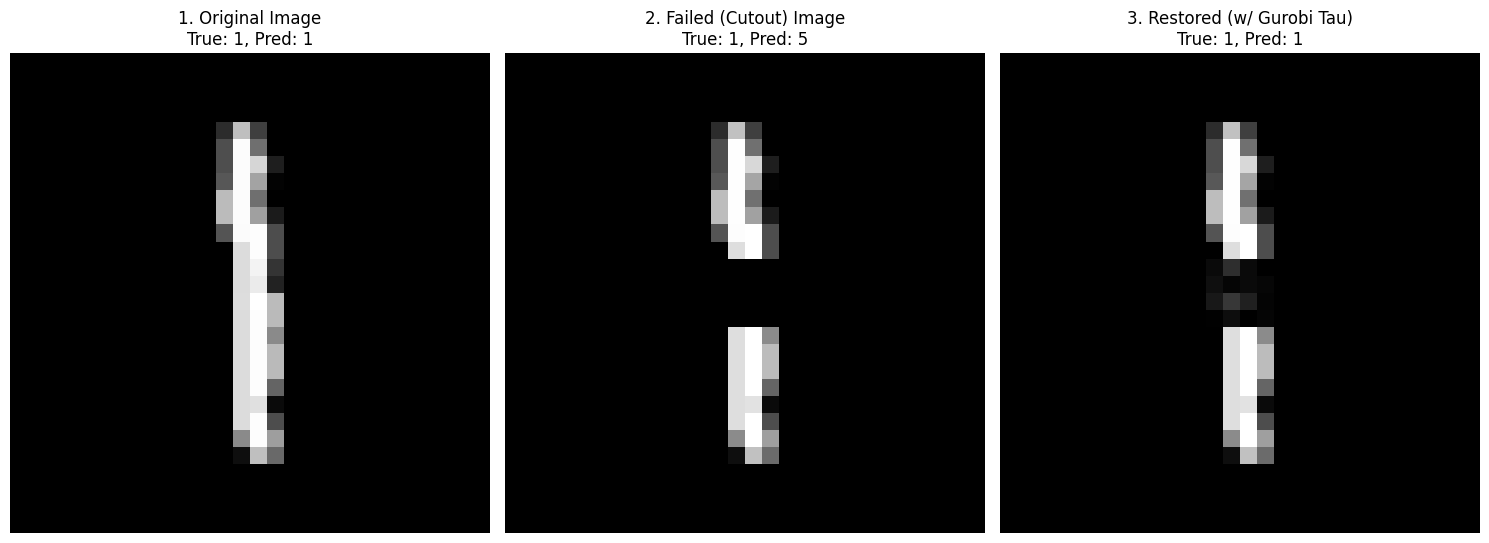


--- TEST 15/100: Image Index 1180 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1239
Always active (L/U)      : 7394
Ambiguous ReLUs          : 775
ReLU binary variables    : 775
Binaries eliminated      : 8633
Binary reduction        : 91.76%
Starting optimized Gurobi optimization...
Solve time: 1.9087 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1180 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


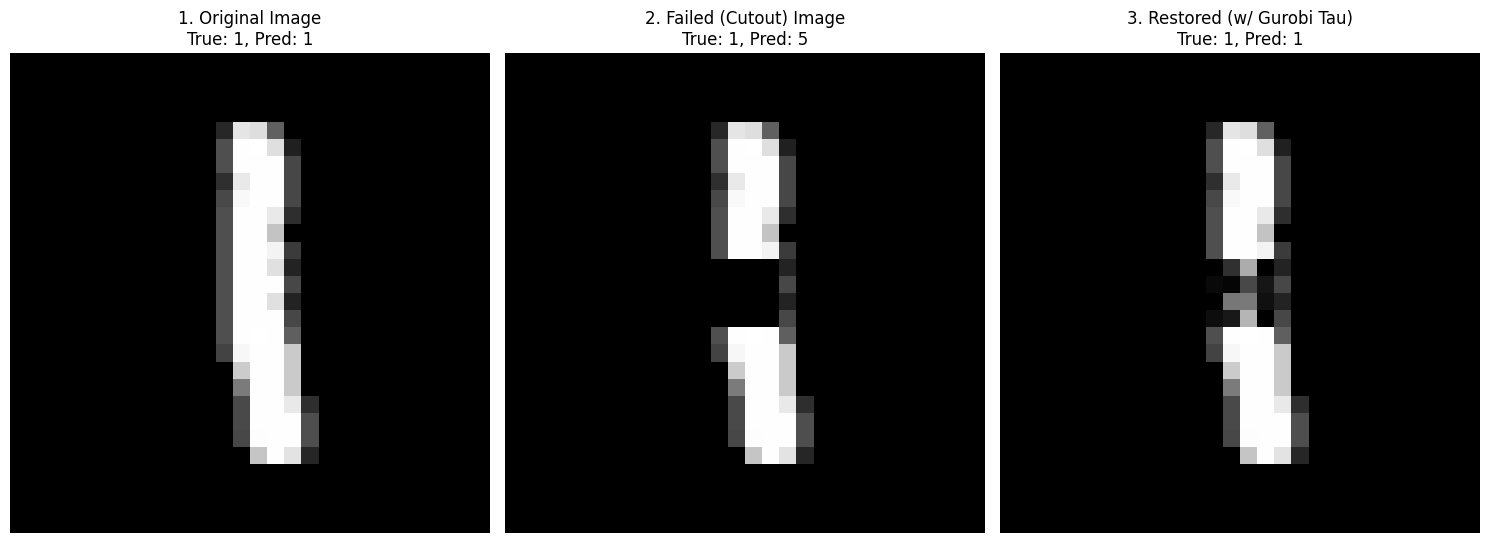


--- TEST 16/100: Image Index 1192 ---
Running Gurobi to find corrective 'tau' patch for target 9...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1291
Always active (L/U)      : 7319
Ambiguous ReLUs          : 798
ReLU binary variables    : 798
Binaries eliminated      : 8610
Binary reduction        : 91.52%
Starting optimized Gurobi optimization...
Solve time: 104.5950 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1192 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


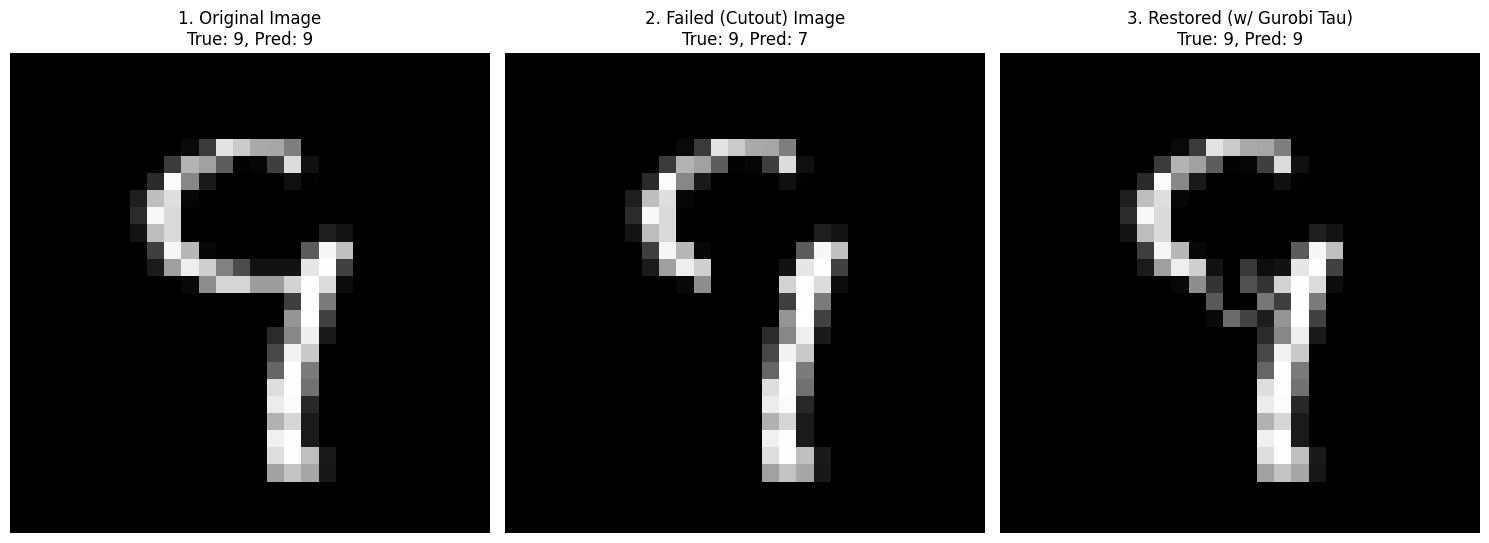


--- TEST 17/100: Image Index 1201 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1189
Always active (L/U)      : 7444
Ambiguous ReLUs          : 775
ReLU binary variables    : 775
Binaries eliminated      : 8633
Binary reduction        : 91.76%
Starting optimized Gurobi optimization...
Solve time: 2.5708 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1201 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


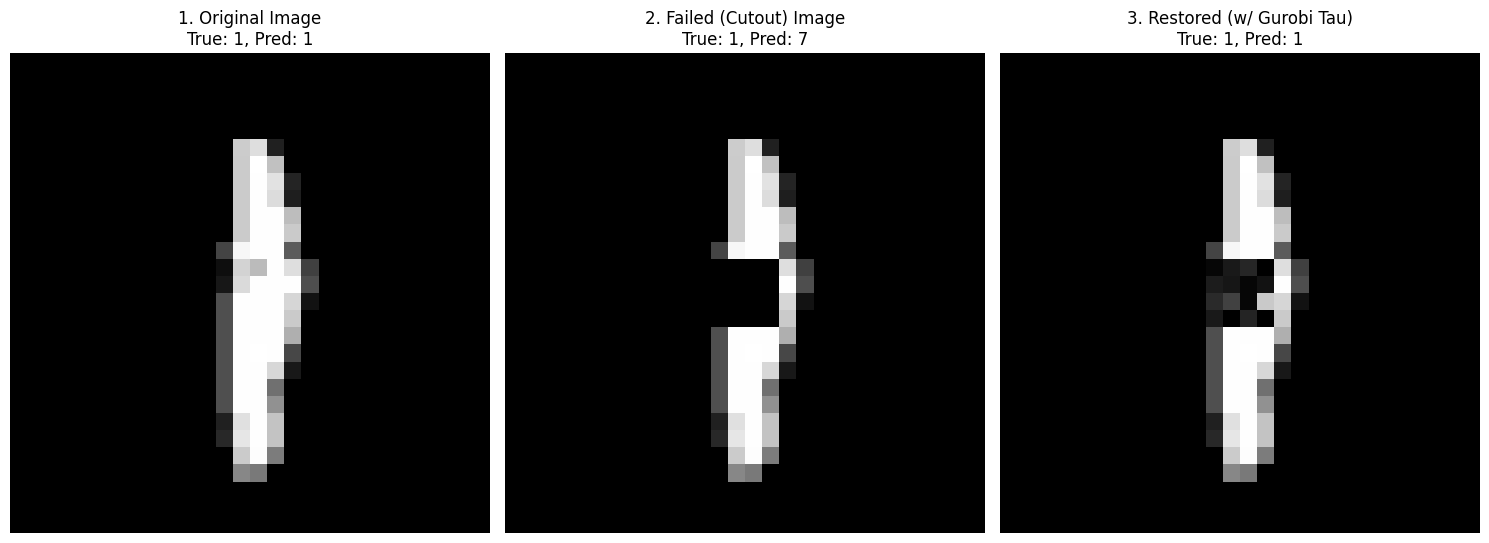


--- TEST 18/100: Image Index 1214 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1228
Always active (L/U)      : 7424
Ambiguous ReLUs          : 756
ReLU binary variables    : 756
Binaries eliminated      : 8652
Binary reduction        : 91.96%
Starting optimized Gurobi optimization...
Solve time: 6.9826 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1214 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


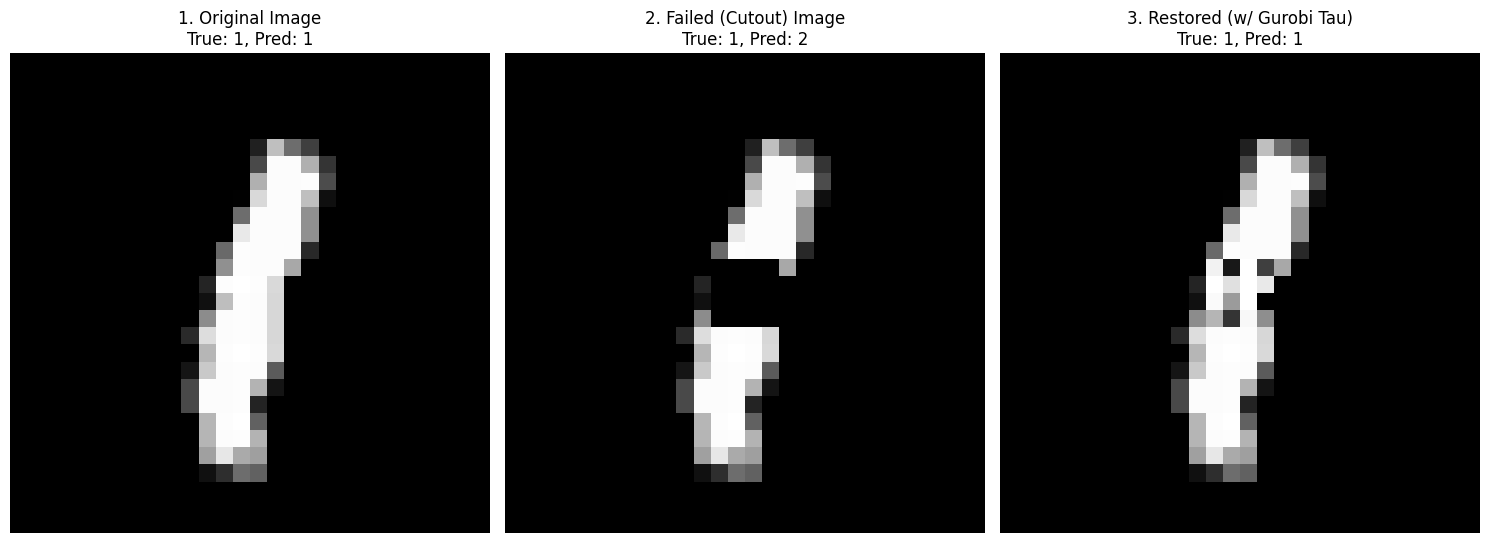


--- TEST 19/100: Image Index 1240 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1219
Always active (L/U)      : 7474
Ambiguous ReLUs          : 715
ReLU binary variables    : 715
Binaries eliminated      : 8693
Binary reduction        : 92.40%
Starting optimized Gurobi optimization...
Solve time: 10.4559 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1240 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   9 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


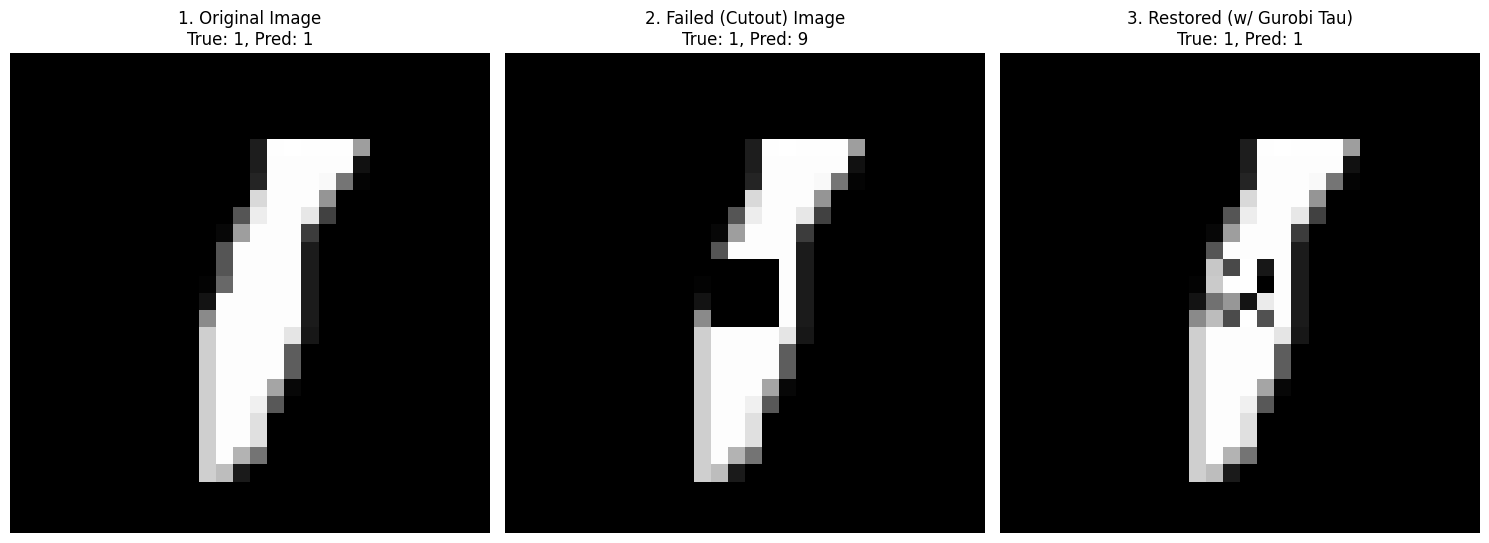


--- TEST 20/100: Image Index 1257 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1167
Always active (L/U)      : 7329
Ambiguous ReLUs          : 912
ReLU binary variables    : 912
Binaries eliminated      : 8496
Binary reduction        : 90.31%
Starting optimized Gurobi optimization...
Solve time: 65.5930 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1257 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


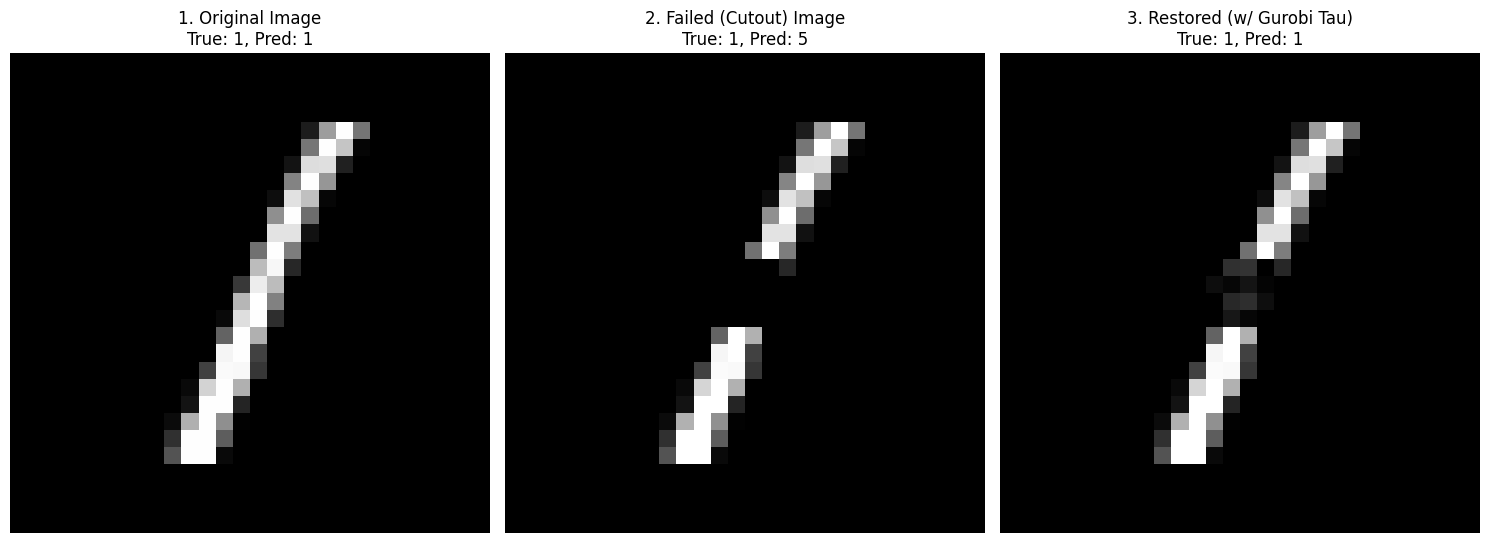


--- TEST 21/100: Image Index 1270 ---
Running Gurobi to find corrective 'tau' patch for target 4...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1268
Always active (L/U)      : 7431
Ambiguous ReLUs          : 709
ReLU binary variables    : 709
Binaries eliminated      : 8699
Binary reduction        : 92.46%
Starting optimized Gurobi optimization...
Solve time: 48.9633 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1270 - True Label: 4
  Prediction (Original): 4 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 4 (Correct)
----------------------------------------


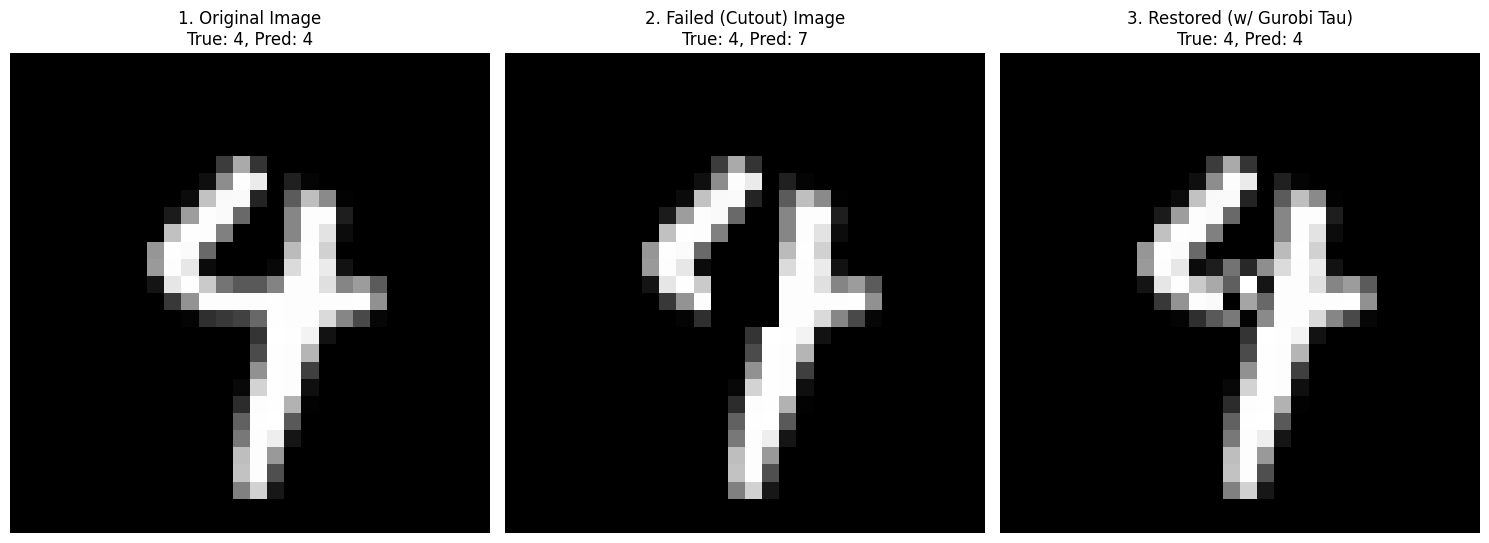


--- TEST 22/100: Image Index 1305 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1202
Always active (L/U)      : 7370
Ambiguous ReLUs          : 836
ReLU binary variables    : 836
Binaries eliminated      : 8572
Binary reduction        : 91.11%
Starting optimized Gurobi optimization...
Solve time: 9.7163 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1305 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


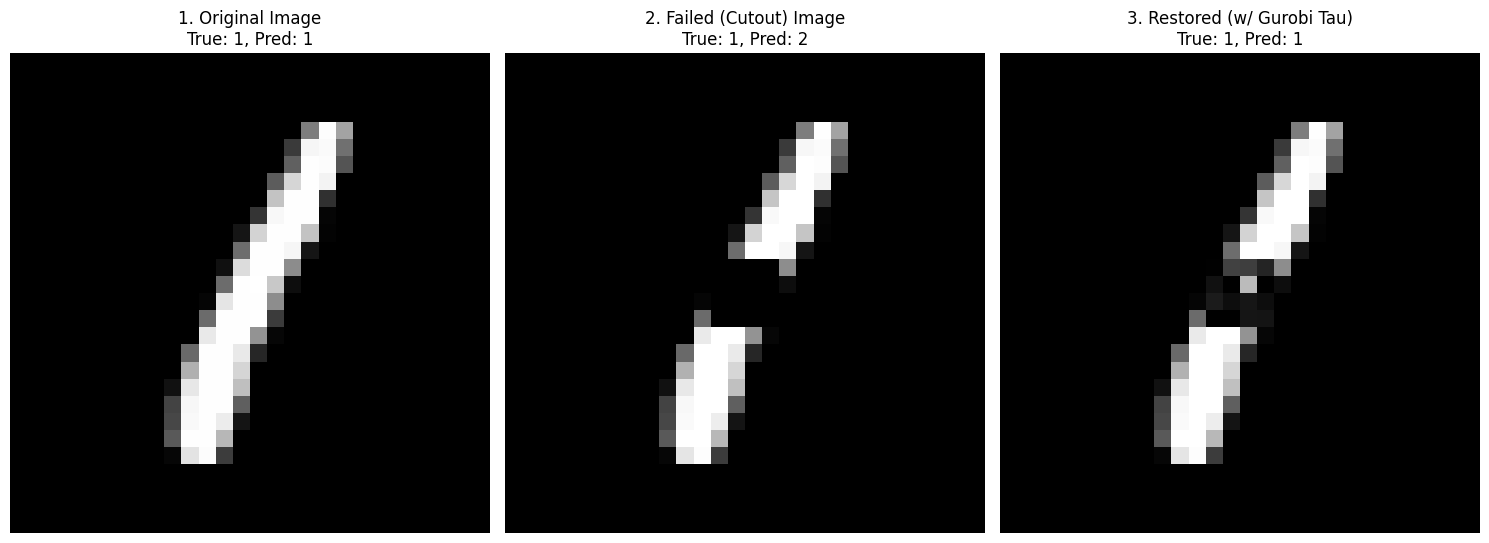


--- TEST 23/100: Image Index 1318 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1190
Always active (L/U)      : 7419
Ambiguous ReLUs          : 799
ReLU binary variables    : 799
Binaries eliminated      : 8609
Binary reduction        : 91.51%
Starting optimized Gurobi optimization...
Solve time: 3.0064 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1318 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


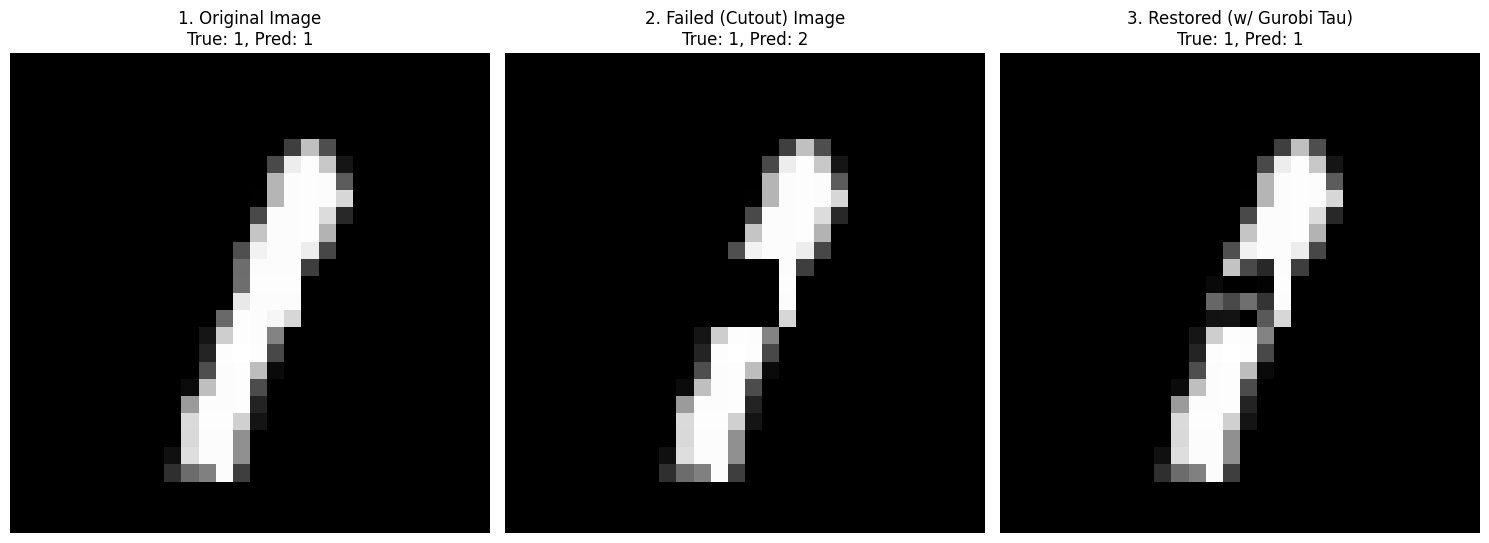


--- TEST 24/100: Image Index 1338 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1194
Always active (L/U)      : 7362
Ambiguous ReLUs          : 852
ReLU binary variables    : 852
Binaries eliminated      : 8556
Binary reduction        : 90.94%
Starting optimized Gurobi optimization...
Solve time: 3.0013 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1338 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


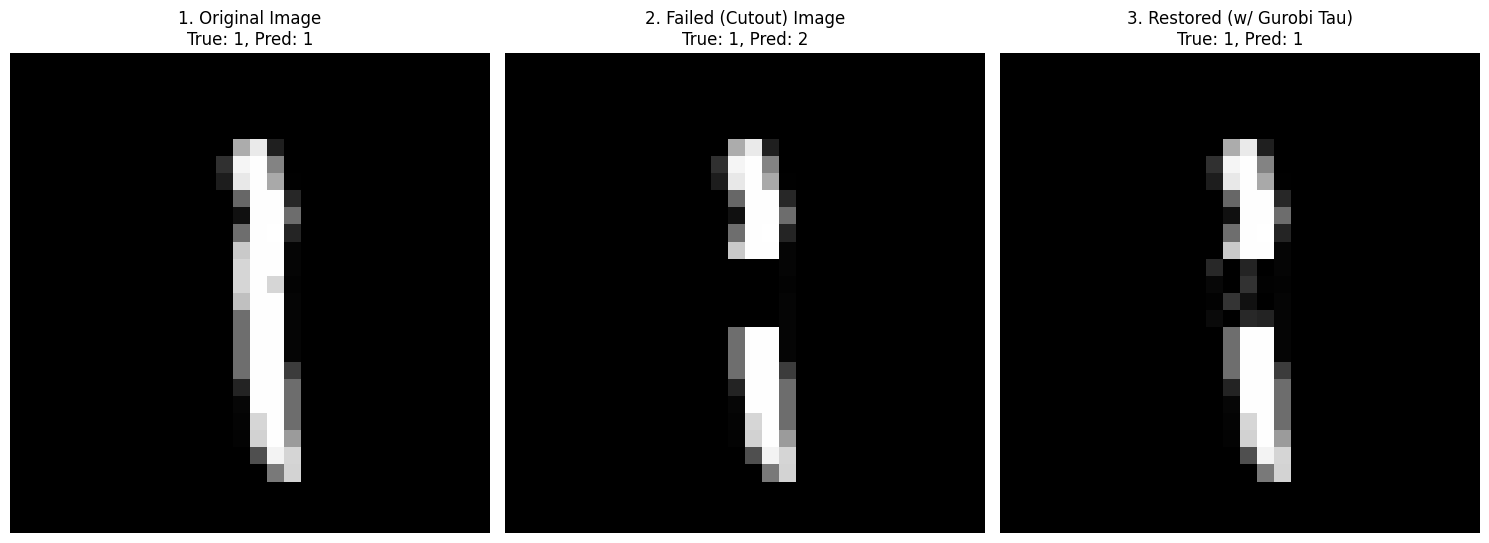


--- TEST 25/100: Image Index 135 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1212
Always active (L/U)      : 7407
Ambiguous ReLUs          : 789
ReLU binary variables    : 789
Binaries eliminated      : 8619
Binary reduction        : 91.61%
Starting optimized Gurobi optimization...
Solve time: 2.3449 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 135 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   3 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


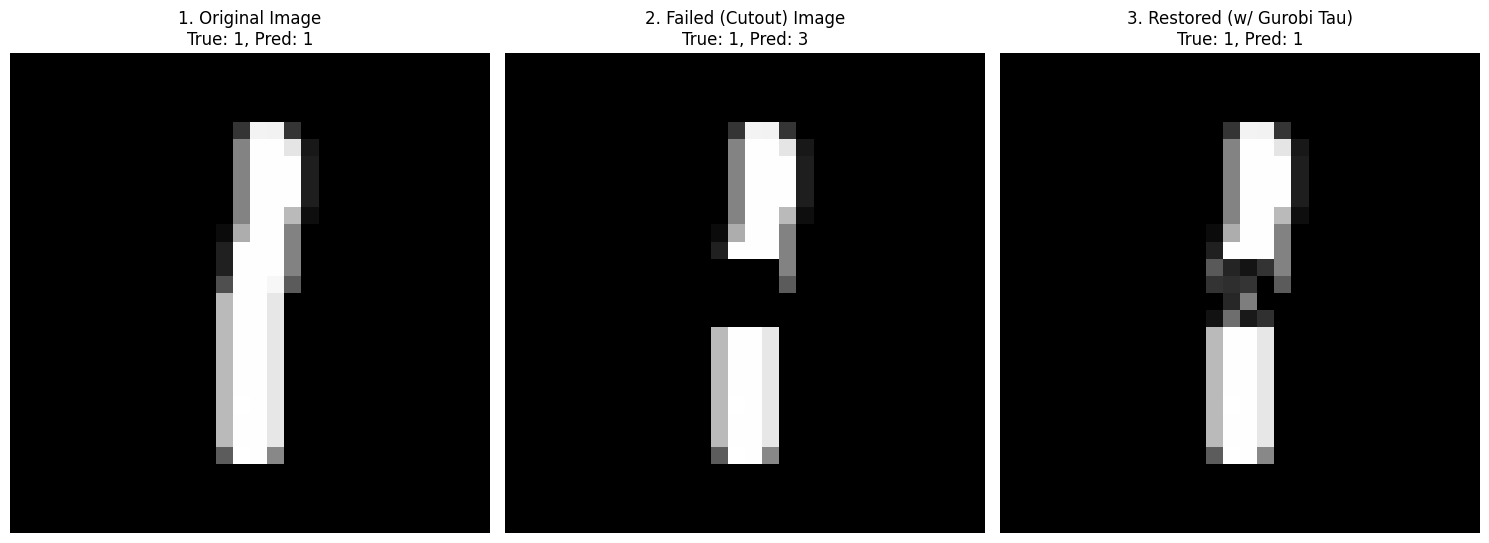


--- TEST 26/100: Image Index 1351 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1222
Always active (L/U)      : 7406
Ambiguous ReLUs          : 780
ReLU binary variables    : 780
Binaries eliminated      : 8628
Binary reduction        : 91.71%
Starting optimized Gurobi optimization...
Solve time: 4.9300 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1351 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


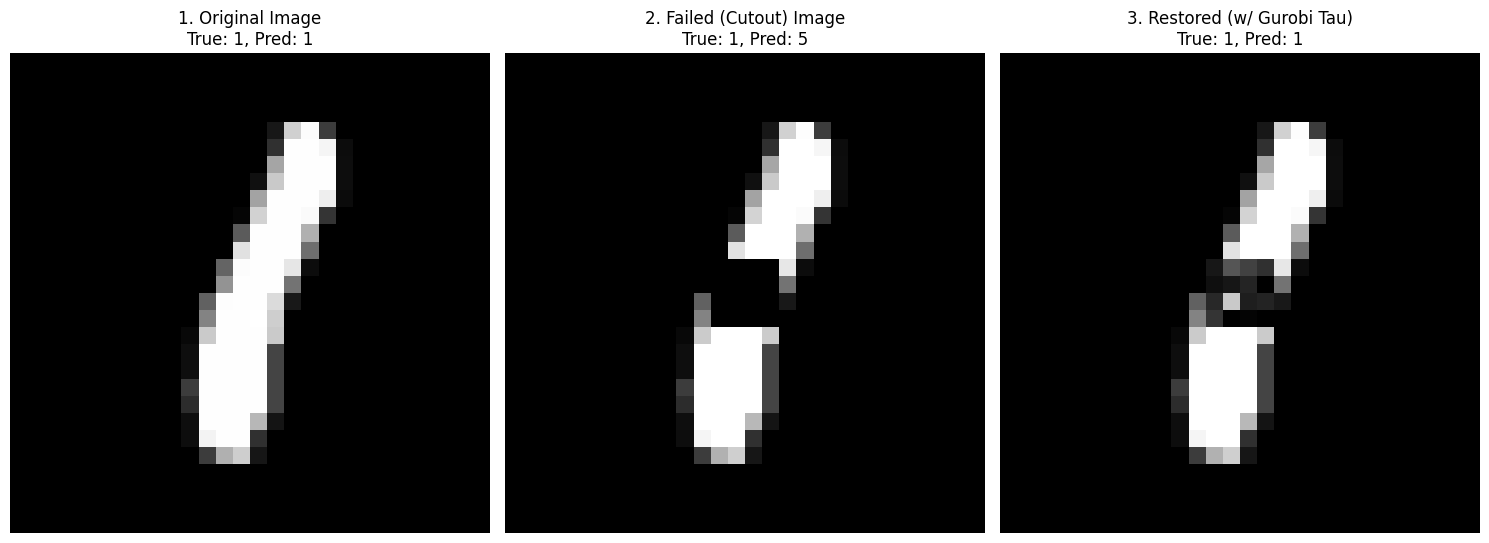


--- TEST 27/100: Image Index 137 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1252
Always active (L/U)      : 7389
Ambiguous ReLUs          : 767
ReLU binary variables    : 767
Binaries eliminated      : 8641
Binary reduction        : 91.85%
Starting optimized Gurobi optimization...
Solve time: 17.1591 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 137 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


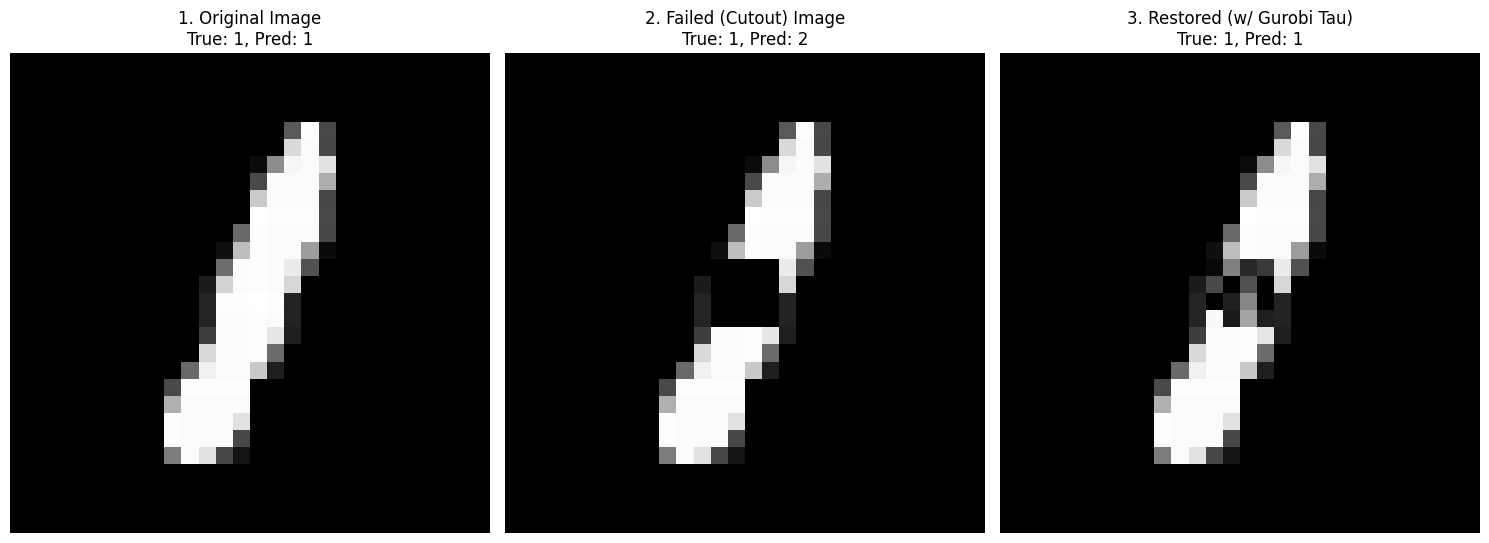


--- TEST 28/100: Image Index 14 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1227
Always active (L/U)      : 7391
Ambiguous ReLUs          : 790
ReLU binary variables    : 790
Binaries eliminated      : 8618
Binary reduction        : 91.60%
Starting optimized Gurobi optimization...
Solve time: 2.7838 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 14 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


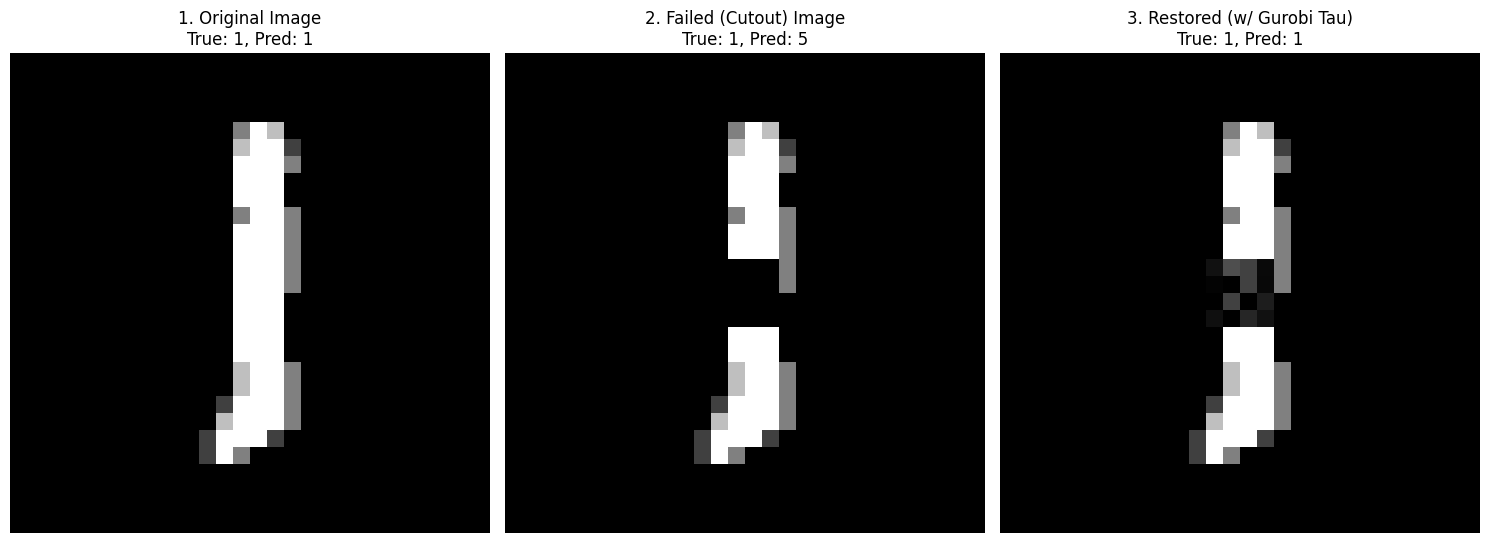


--- TEST 29/100: Image Index 1403 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1258
Always active (L/U)      : 7300
Ambiguous ReLUs          : 850
ReLU binary variables    : 850
Binaries eliminated      : 8558
Binary reduction        : 90.97%
Starting optimized Gurobi optimization...
Solve time: 184.8947 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1403 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   6 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


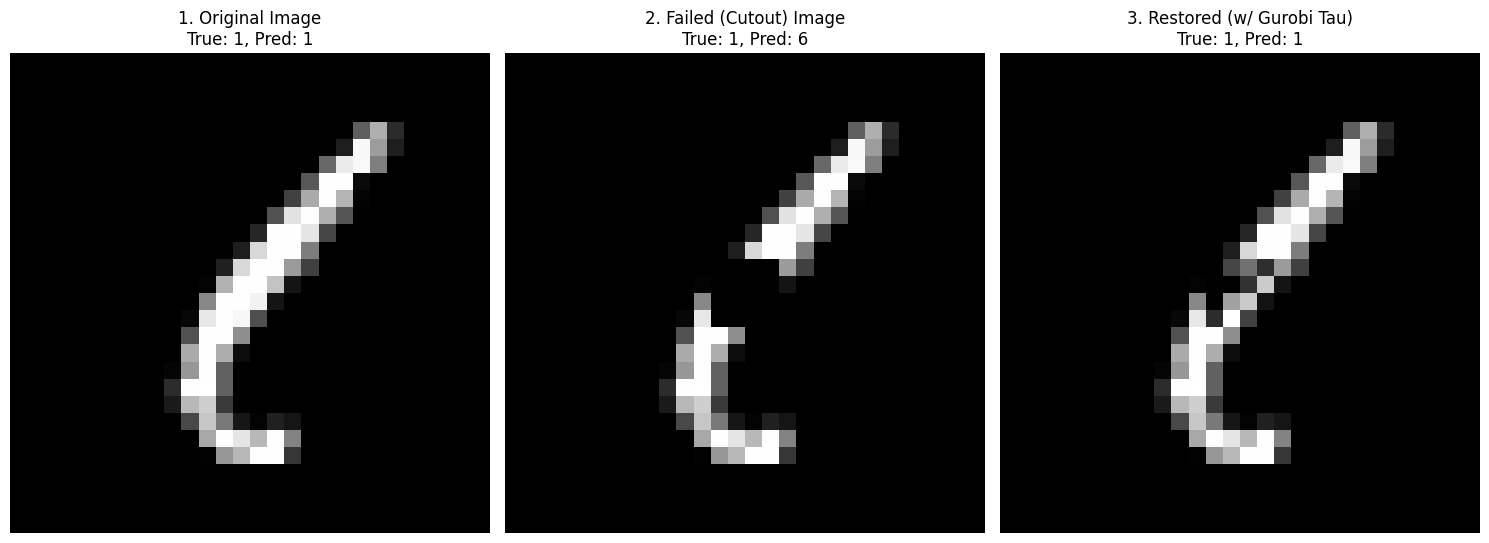


--- TEST 30/100: Image Index 1424 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1161
Always active (L/U)      : 7405
Ambiguous ReLUs          : 842
ReLU binary variables    : 842
Binaries eliminated      : 8566
Binary reduction        : 91.05%
Starting optimized Gurobi optimization...
Solve time: 27.0784 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1424 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


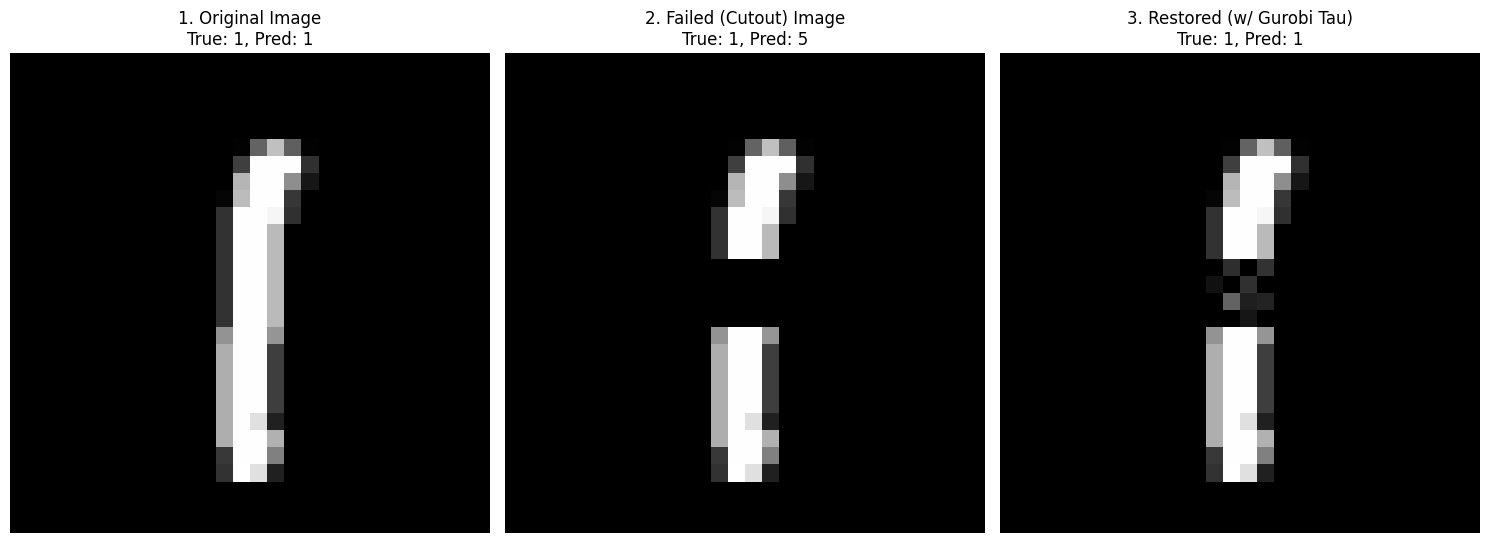


--- TEST 31/100: Image Index 1433 ---
Running Gurobi to find corrective 'tau' patch for target 8...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1340
Always active (L/U)      : 7405
Ambiguous ReLUs          : 663
ReLU binary variables    : 663
Binaries eliminated      : 8745
Binary reduction        : 92.95%
Starting optimized Gurobi optimization...
Solve time: 1.6926 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1433 - True Label: 8
  Prediction (Original): 8 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 8 (Correct)
----------------------------------------


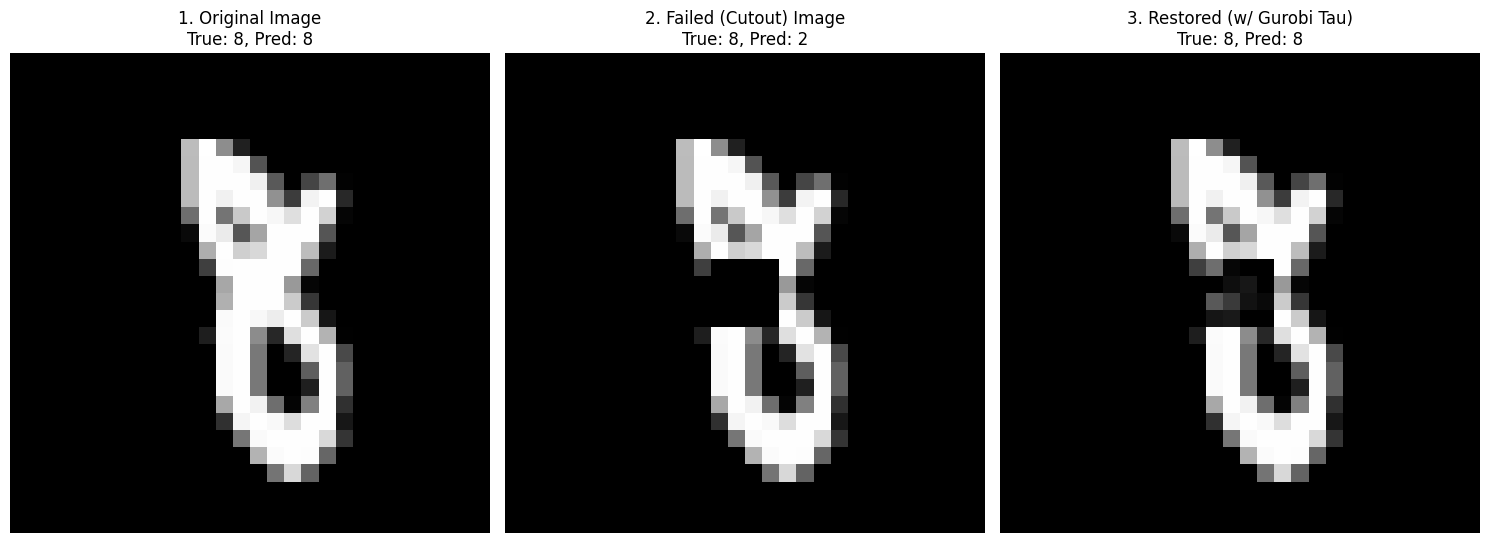


--- TEST 32/100: Image Index 1436 ---
Running Gurobi to find corrective 'tau' patch for target 6...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1354
Always active (L/U)      : 7338
Ambiguous ReLUs          : 716
ReLU binary variables    : 716
Binaries eliminated      : 8692
Binary reduction        : 92.39%
Starting optimized Gurobi optimization...
Solve time: 2.1509 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1436 - True Label: 6
  Prediction (Original): 6 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 6 (Correct)
----------------------------------------


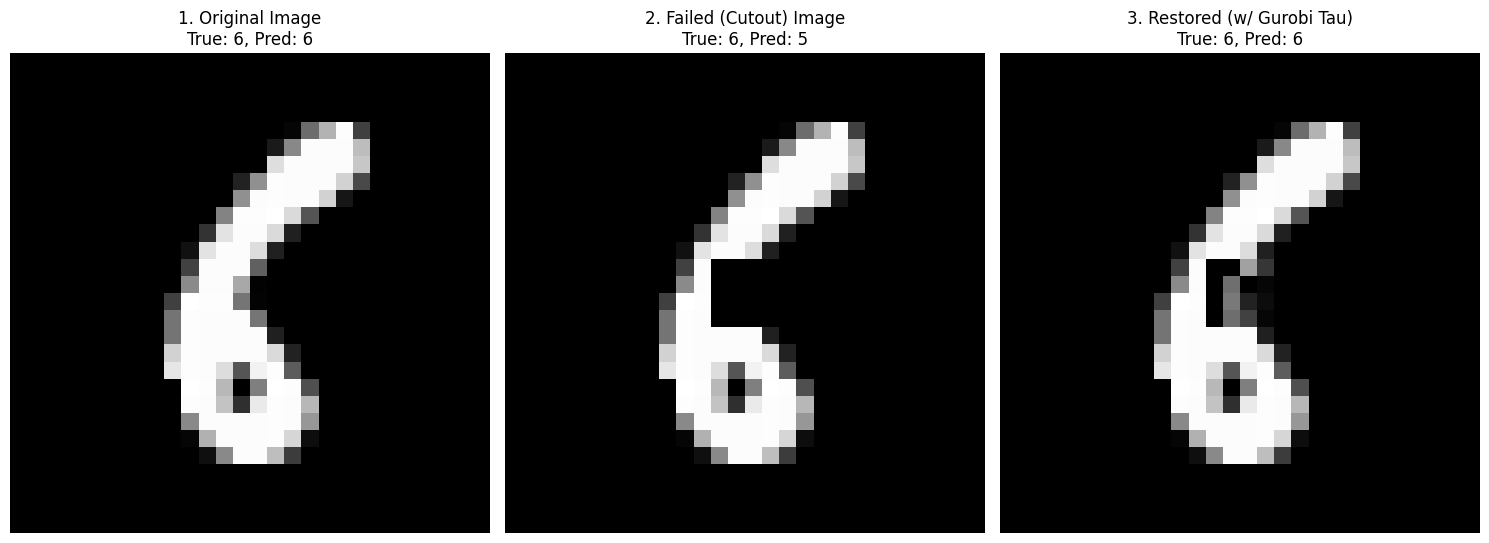


--- TEST 33/100: Image Index 1439 ---
Running Gurobi to find corrective 'tau' patch for target 9...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1180
Always active (L/U)      : 7474
Ambiguous ReLUs          : 754
ReLU binary variables    : 754
Binaries eliminated      : 8654
Binary reduction        : 91.99%
Starting optimized Gurobi optimization...
Solve time: 2.2826 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1439 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


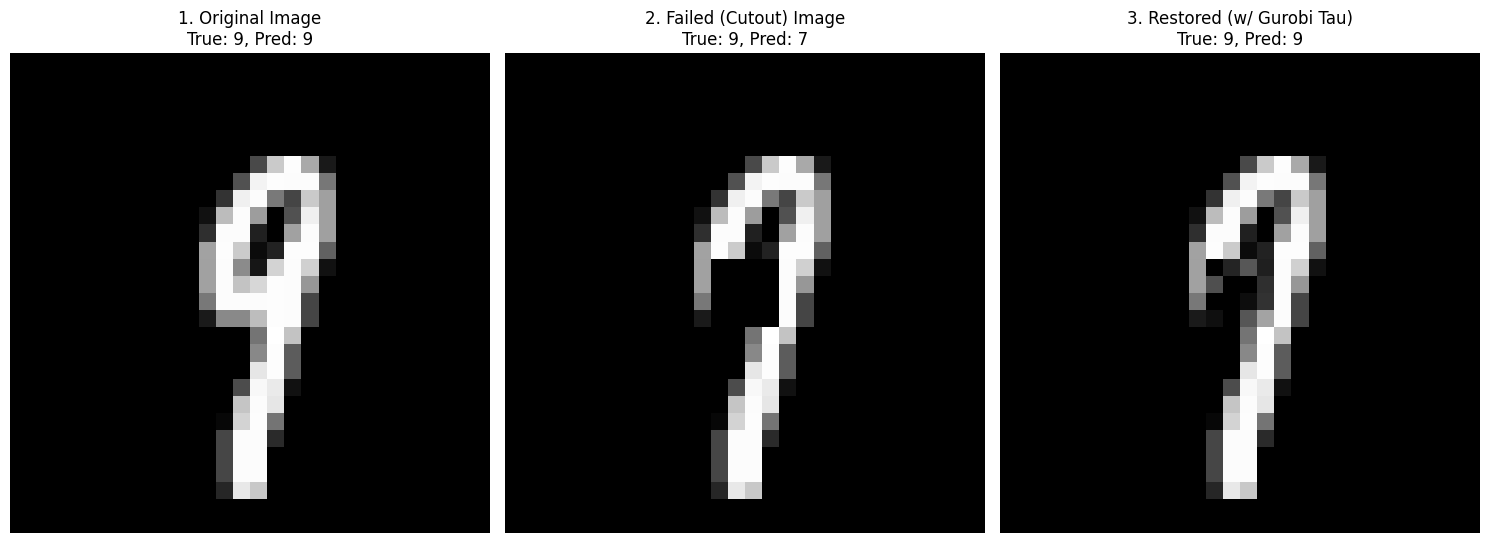


--- TEST 34/100: Image Index 1515 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1207
Always active (L/U)      : 7437
Ambiguous ReLUs          : 764
ReLU binary variables    : 764
Binaries eliminated      : 8644
Binary reduction        : 91.88%
Starting optimized Gurobi optimization...
Solve time: 6.4385 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1515 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   3 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


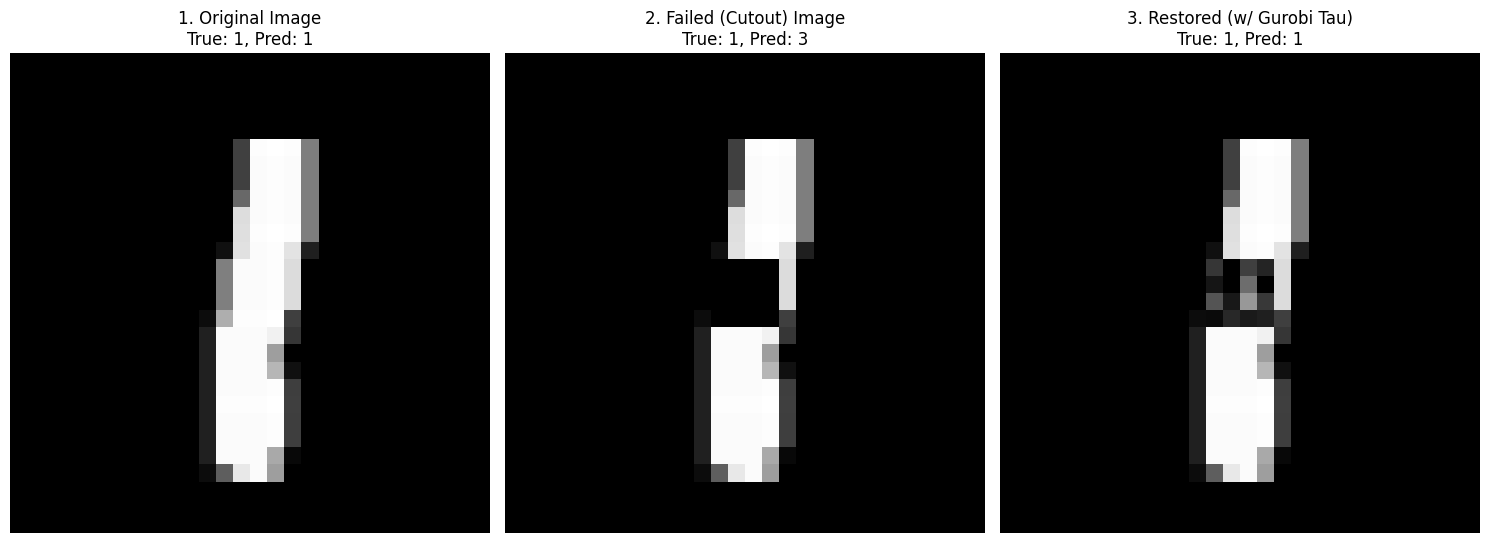


--- TEST 35/100: Image Index 1528 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1200
Always active (L/U)      : 7358
Ambiguous ReLUs          : 850
ReLU binary variables    : 850
Binaries eliminated      : 8558
Binary reduction        : 90.97%
Starting optimized Gurobi optimization...
Solve time: 2.6683 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1528 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


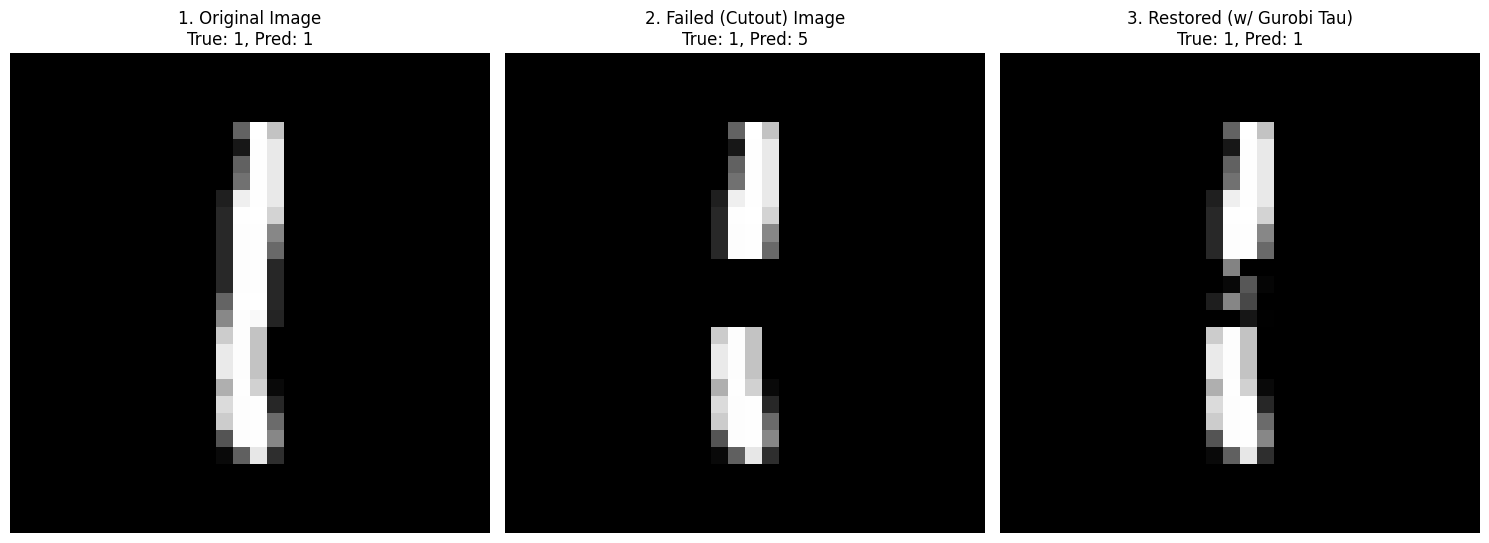


--- TEST 36/100: Image Index 1548 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1170
Always active (L/U)      : 7386
Ambiguous ReLUs          : 852
ReLU binary variables    : 852
Binaries eliminated      : 8556
Binary reduction        : 90.94%
Starting optimized Gurobi optimization...
Solve time: 3.3198 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1548 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


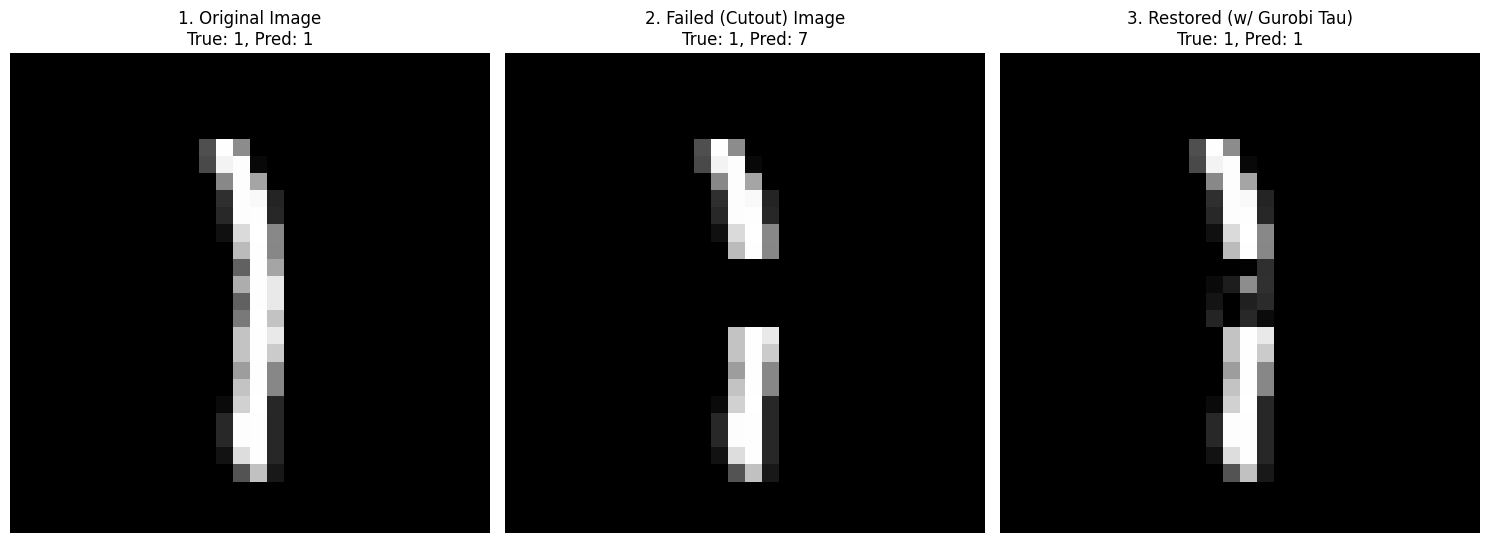


--- TEST 37/100: Image Index 1553 ---
Running Gurobi to find corrective 'tau' patch for target 9...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1438
Always active (L/U)      : 7302
Ambiguous ReLUs          : 668
ReLU binary variables    : 668
Binaries eliminated      : 8740
Binary reduction        : 92.90%
Starting optimized Gurobi optimization...
Solve time: 6.1288 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1553 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


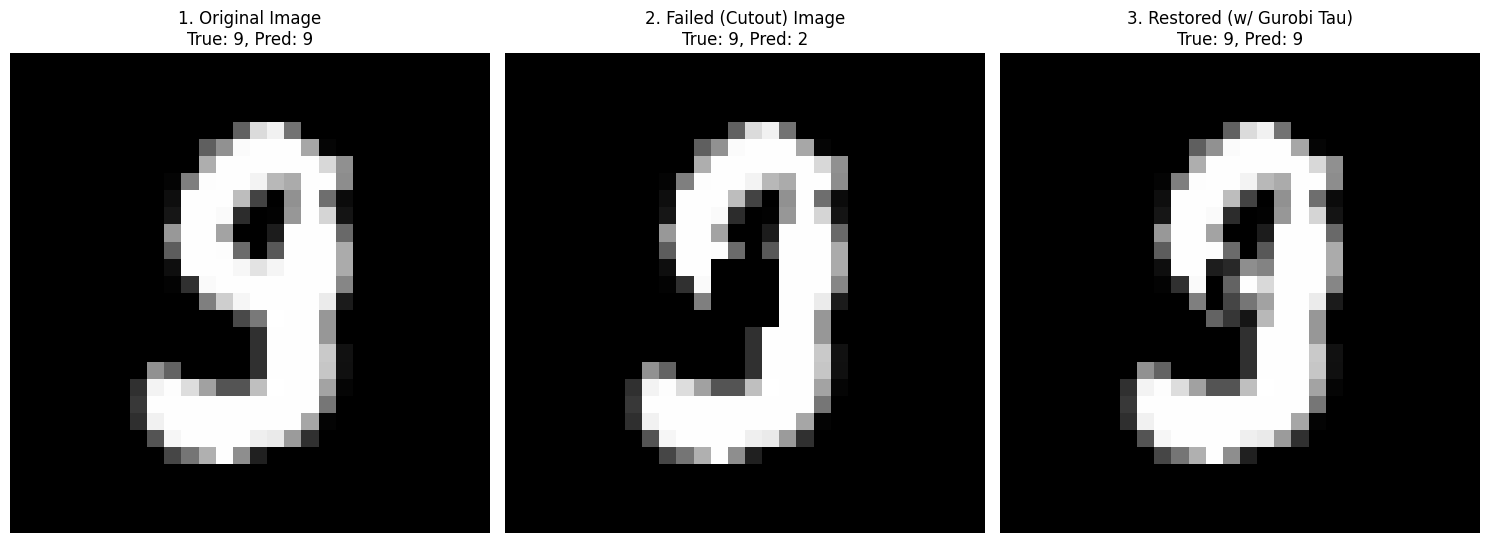


--- TEST 38/100: Image Index 179 ---
Running Gurobi to find corrective 'tau' patch for target 8...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1473
Always active (L/U)      : 7297
Ambiguous ReLUs          : 638
ReLU binary variables    : 638
Binaries eliminated      : 8770
Binary reduction        : 93.22%
Starting optimized Gurobi optimization...
Solve time: 1.6914 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 179 - True Label: 8
  Prediction (Original): 8 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 8 (Correct)
----------------------------------------


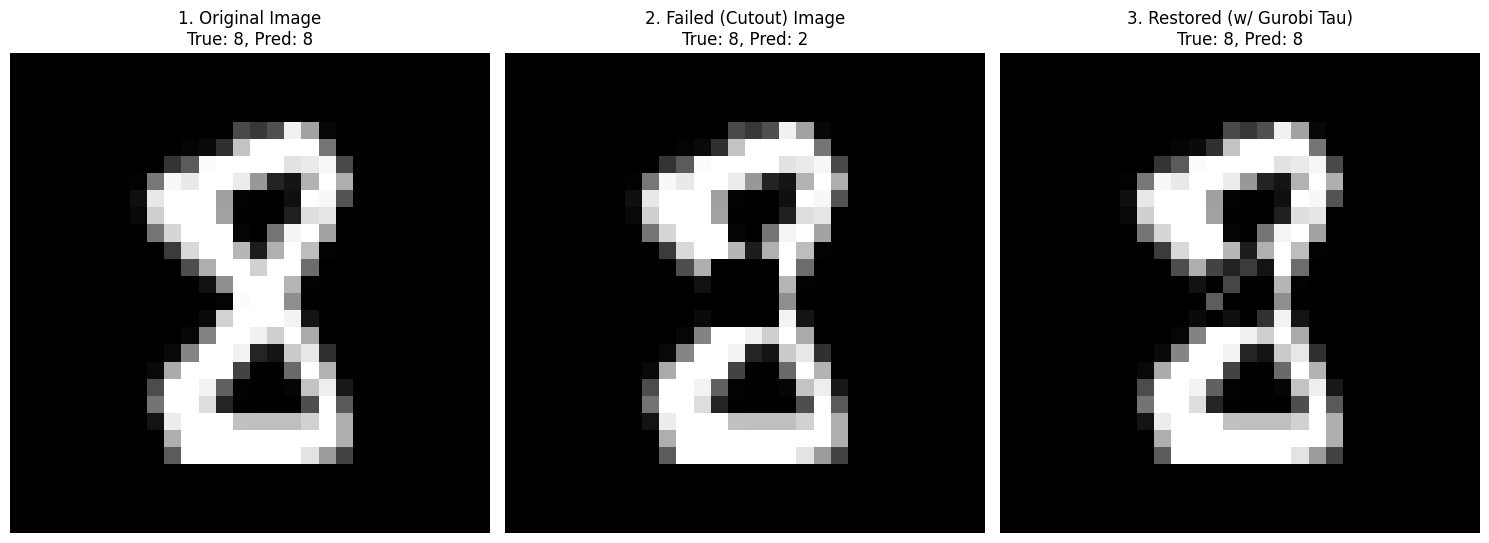


--- TEST 39/100: Image Index 18 ---
Running Gurobi to find corrective 'tau' patch for target 3...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1634
Always active (L/U)      : 7145
Ambiguous ReLUs          : 629
ReLU binary variables    : 629
Binaries eliminated      : 8779
Binary reduction        : 93.31%
Starting optimized Gurobi optimization...
Solve time: 600.1546 s
Gurobi status: 9
Time limit reached before a feasible solution was found.
Gurobi could not find a corrective patch for image 18.

--- TEST 40/100: Image Index 190 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1225
Always active (L/U)      : 7440
Ambiguous ReLUs          : 743
ReLU binary variables    : 743
Binaries eliminated      : 8665
Binary reduction        : 92.10%
Starting optimized Gurobi optimization...
Solve time: 2.4620 s
Gurobi status: 2
Gurobi found a solu

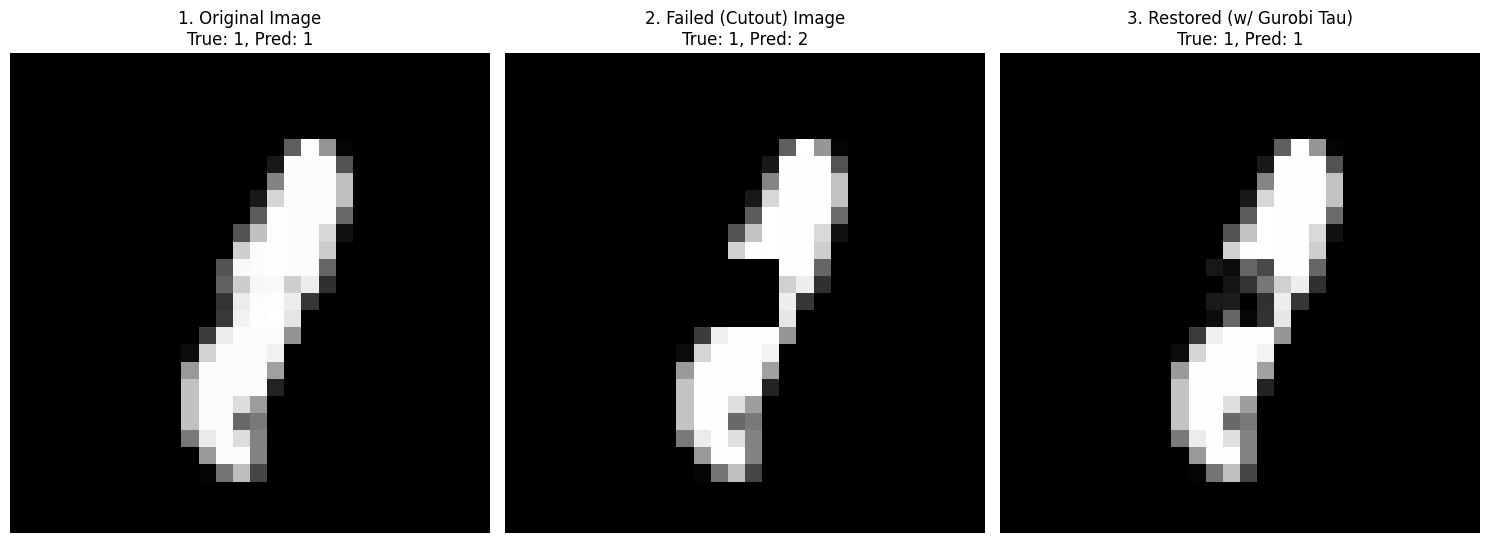


--- TEST 41/100: Image Index 196 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1240
Always active (L/U)      : 7410
Ambiguous ReLUs          : 758
ReLU binary variables    : 758
Binaries eliminated      : 8650
Binary reduction        : 91.94%
Starting optimized Gurobi optimization...
Solve time: 2.6197 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 196 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


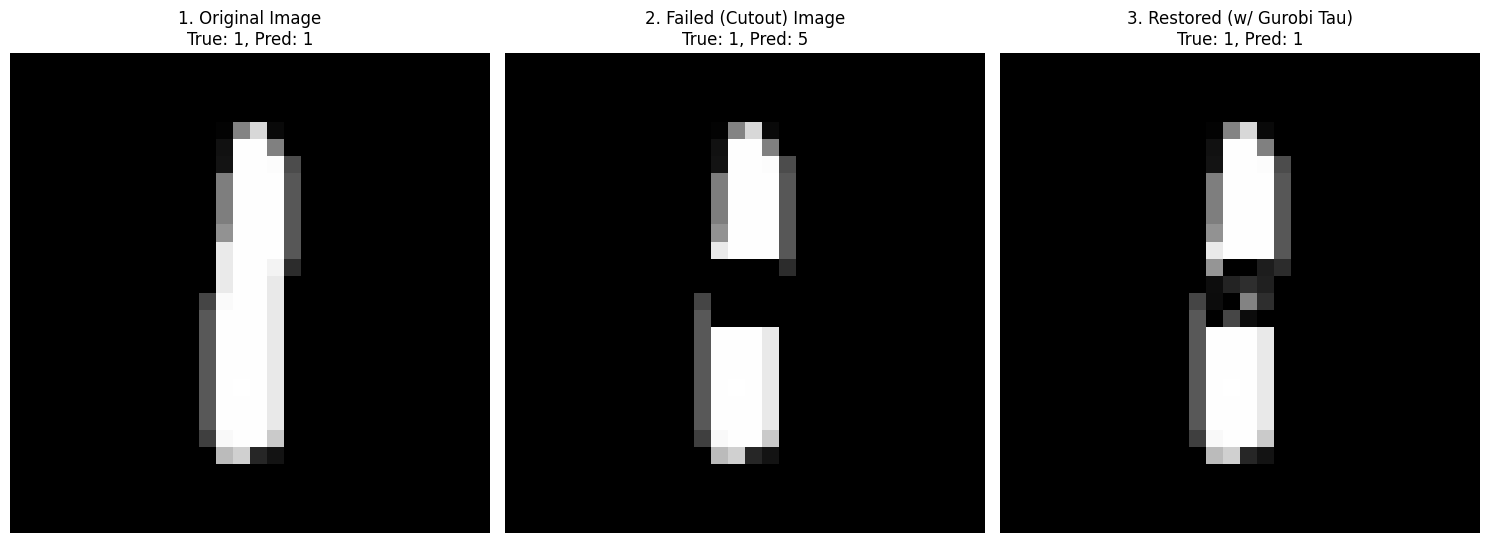


--- TEST 42/100: Image Index 2 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1150
Always active (L/U)      : 7352
Ambiguous ReLUs          : 906
ReLU binary variables    : 906
Binaries eliminated      : 8502
Binary reduction        : 90.37%
Starting optimized Gurobi optimization...
Solve time: 4.8859 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 2 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


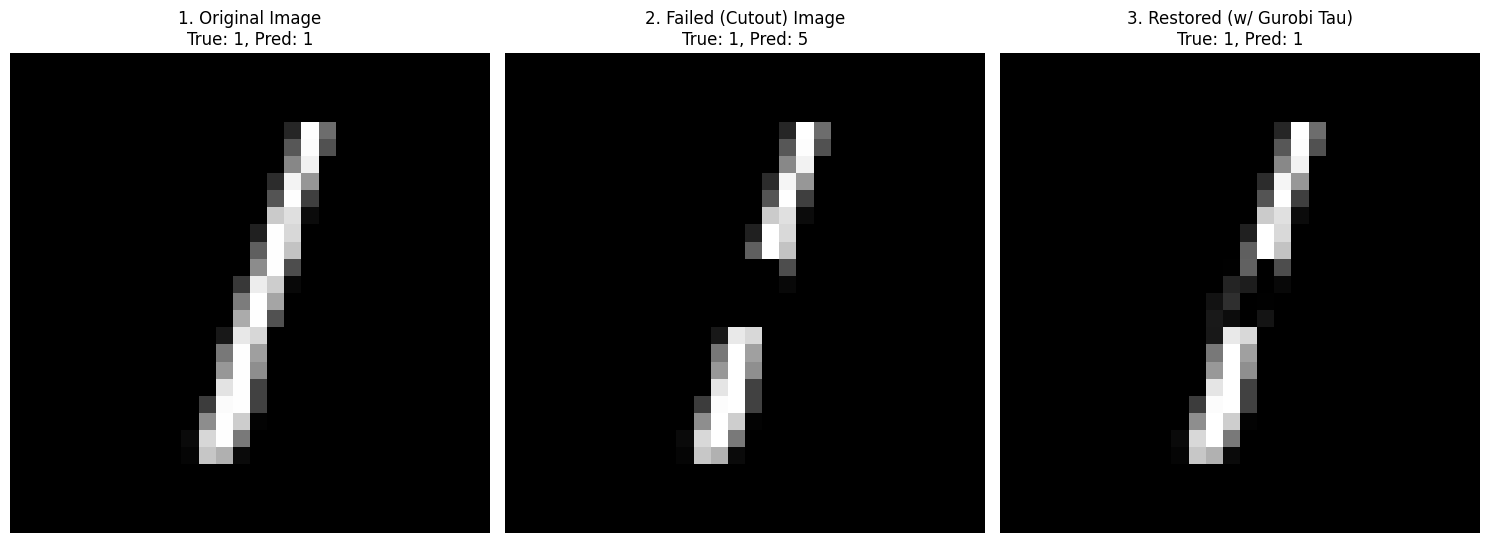


--- TEST 43/100: Image Index 20 ---
Running Gurobi to find corrective 'tau' patch for target 9...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1337
Always active (L/U)      : 7418
Ambiguous ReLUs          : 653
ReLU binary variables    : 653
Binaries eliminated      : 8755
Binary reduction        : 93.06%
Starting optimized Gurobi optimization...
Solve time: 8.2095 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 20 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


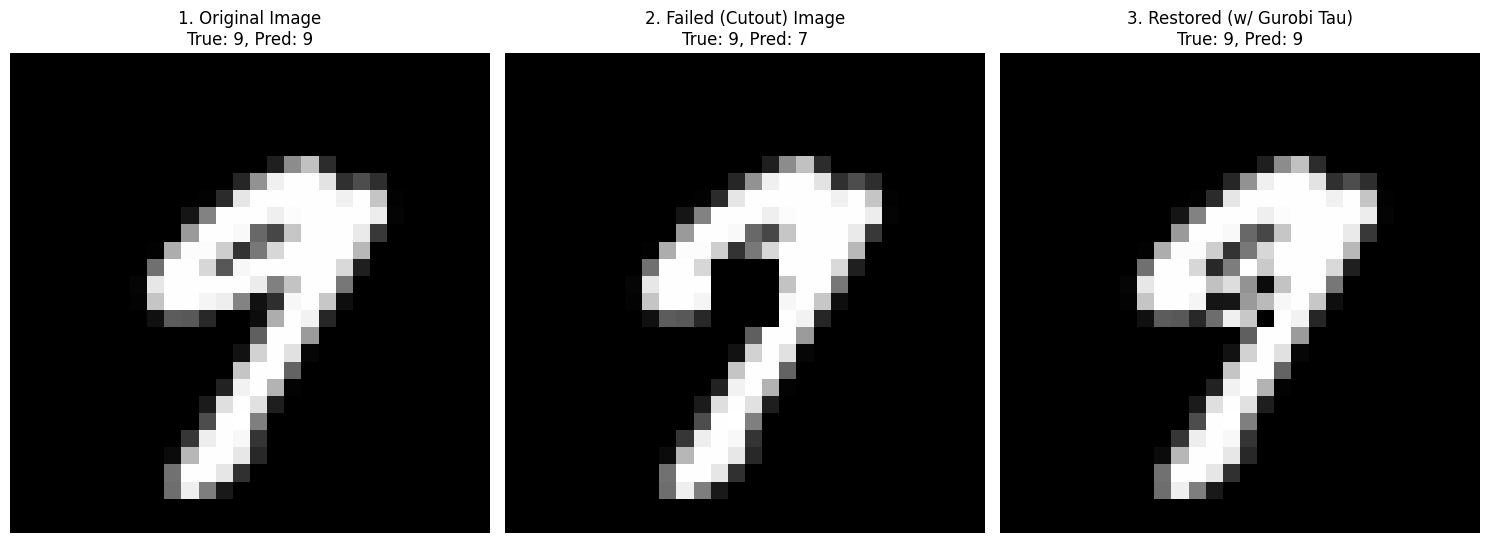


--- TEST 44/100: Image Index 209 ---
Running Gurobi to find corrective 'tau' patch for target 9...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1341
Always active (L/U)      : 7419
Ambiguous ReLUs          : 648
ReLU binary variables    : 648
Binaries eliminated      : 8760
Binary reduction        : 93.11%
Starting optimized Gurobi optimization...
Solve time: 8.8036 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 209 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


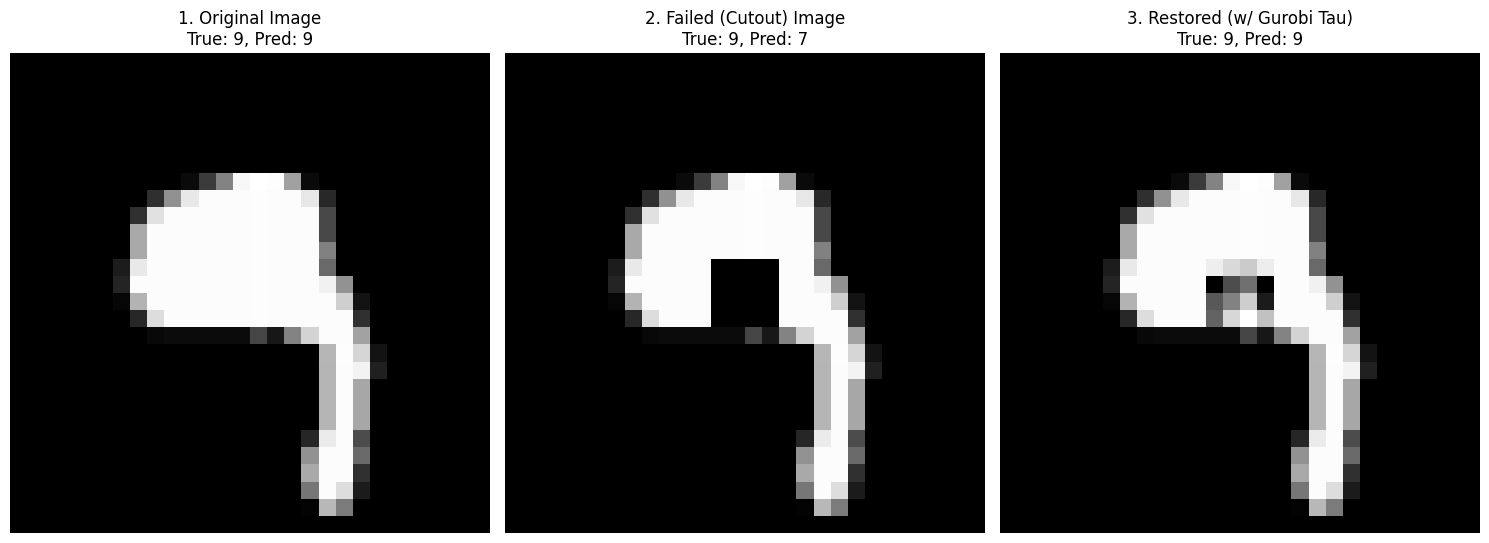


--- TEST 45/100: Image Index 228 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1173
Always active (L/U)      : 7366
Ambiguous ReLUs          : 869
ReLU binary variables    : 869
Binaries eliminated      : 8539
Binary reduction        : 90.76%
Starting optimized Gurobi optimization...
Solve time: 3.7123 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 228 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


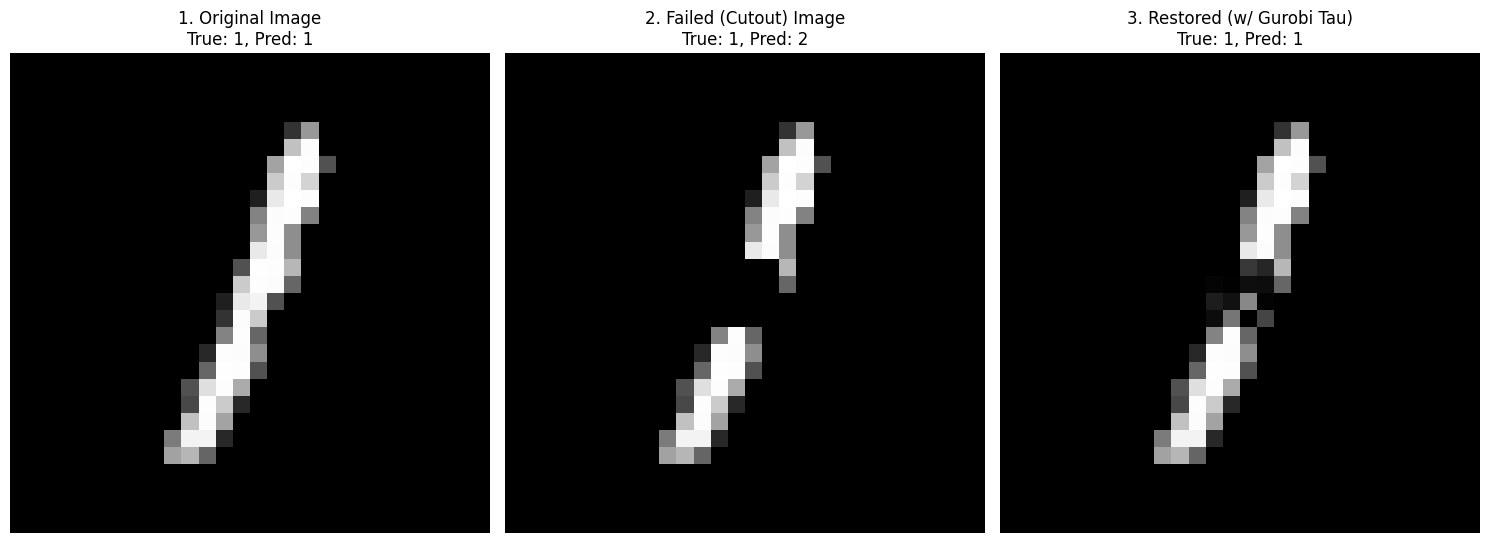


--- TEST 46/100: Image Index 265 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1238
Always active (L/U)      : 7392
Ambiguous ReLUs          : 778
ReLU binary variables    : 778
Binaries eliminated      : 8630
Binary reduction        : 91.73%
Starting optimized Gurobi optimization...
Solve time: 19.1784 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 265 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   3 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


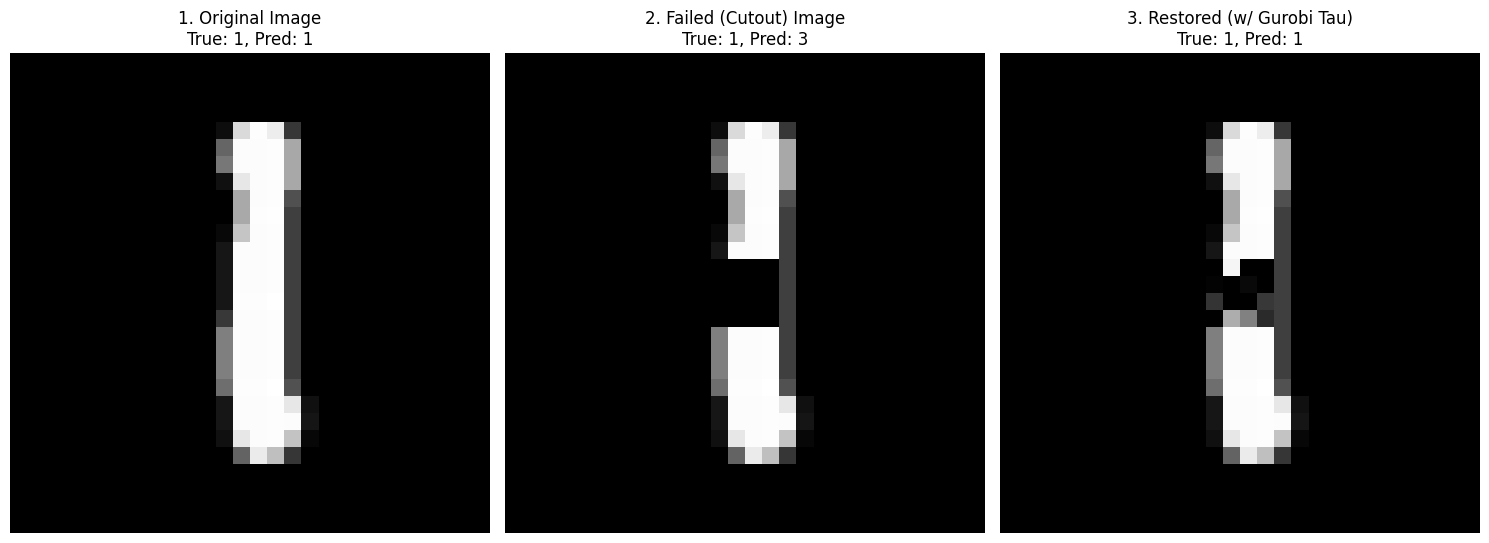


--- TEST 47/100: Image Index 266 ---
Running Gurobi to find corrective 'tau' patch for target 8...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1467
Always active (L/U)      : 7291
Ambiguous ReLUs          : 650
ReLU binary variables    : 650
Binaries eliminated      : 8758
Binary reduction        : 93.09%
Starting optimized Gurobi optimization...
Solve time: 62.0016 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 266 - True Label: 8
  Prediction (Original): 8 (Correct)
  Prediction (Failed):   0 (Incorrect)
  Prediction (Restored): 8 (Correct)
----------------------------------------


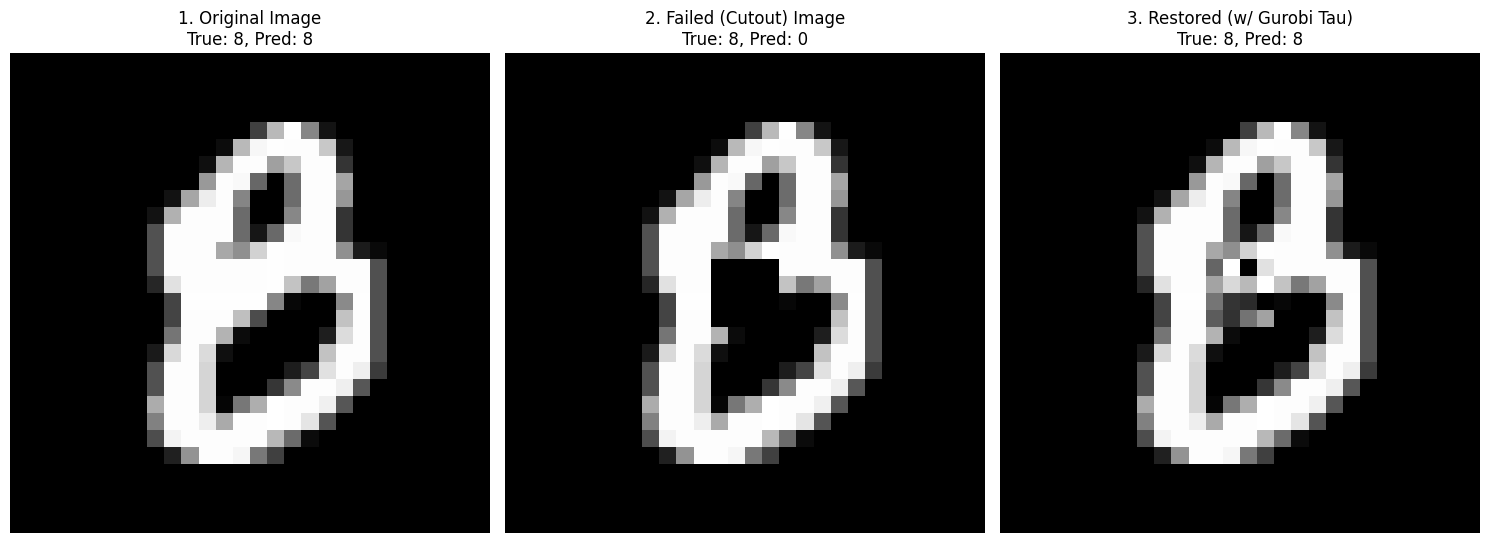


--- TEST 48/100: Image Index 288 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1158
Always active (L/U)      : 7423
Ambiguous ReLUs          : 827
ReLU binary variables    : 827
Binaries eliminated      : 8581
Binary reduction        : 91.21%
Starting optimized Gurobi optimization...
Solve time: 2.3285 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 288 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


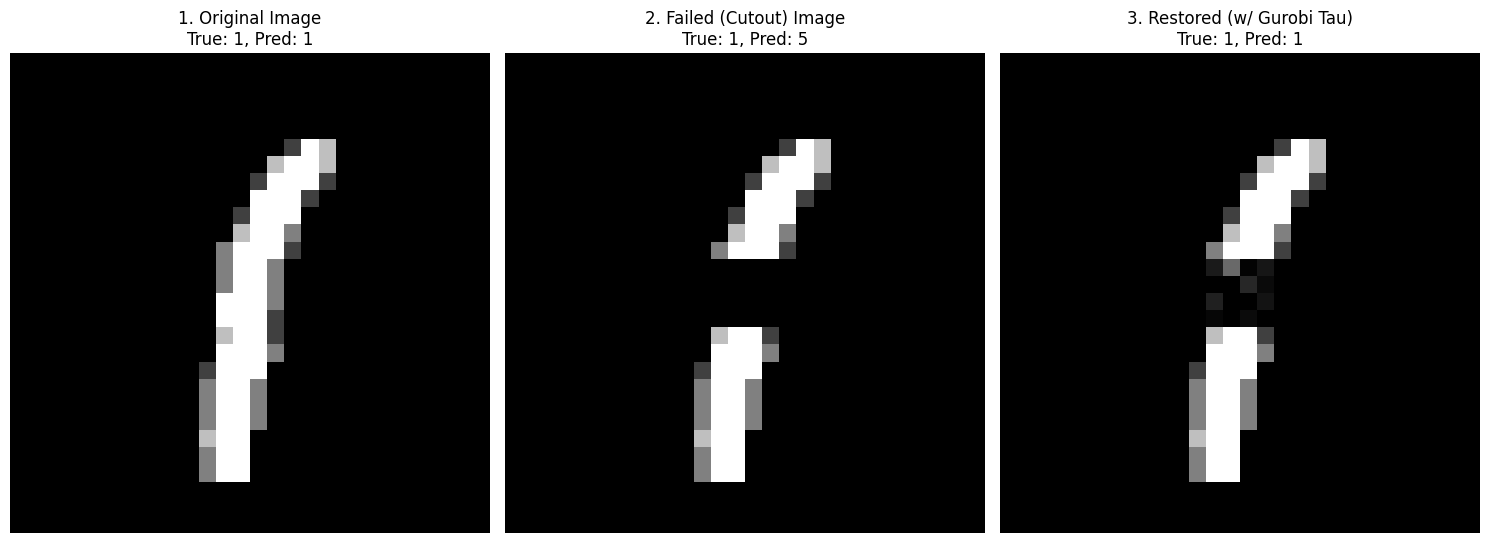


--- TEST 49/100: Image Index 314 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1193
Always active (L/U)      : 7393
Ambiguous ReLUs          : 822
ReLU binary variables    : 822
Binaries eliminated      : 8586
Binary reduction        : 91.26%
Starting optimized Gurobi optimization...
Solve time: 3.1795 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 314 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


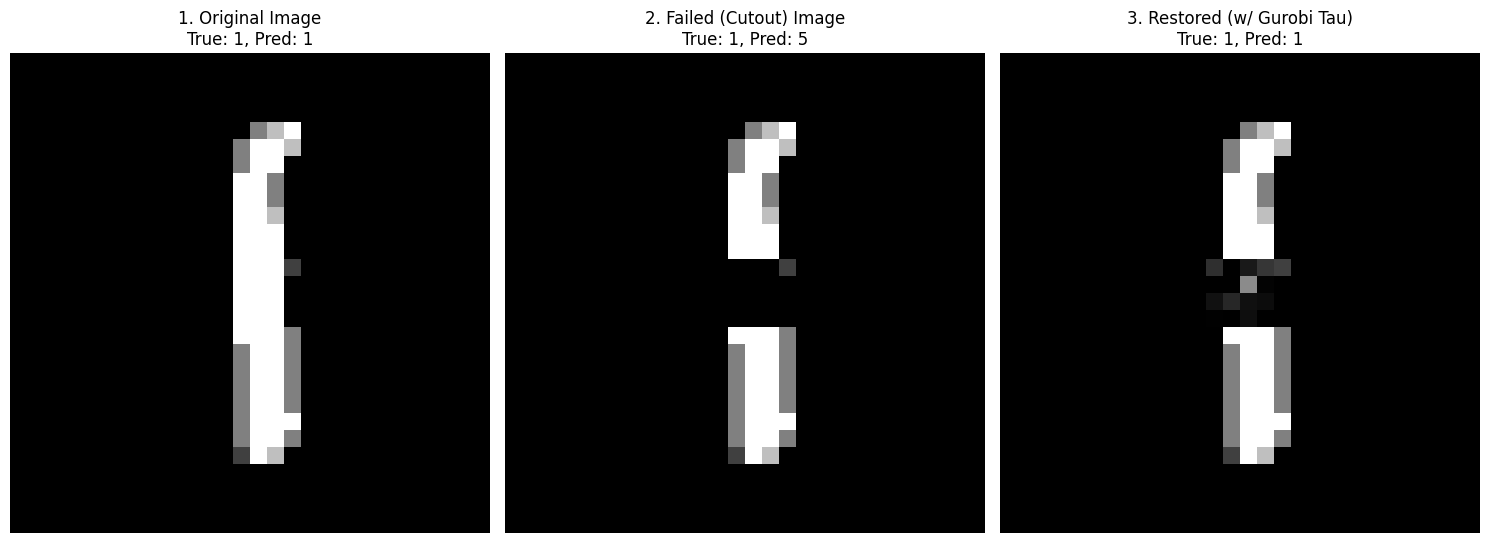


--- TEST 50/100: Image Index 320 ---
Running Gurobi to find corrective 'tau' patch for target 9...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1186
Always active (L/U)      : 7440
Ambiguous ReLUs          : 782
ReLU binary variables    : 782
Binaries eliminated      : 8626
Binary reduction        : 91.69%
Starting optimized Gurobi optimization...
Solve time: 122.2467 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 320 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


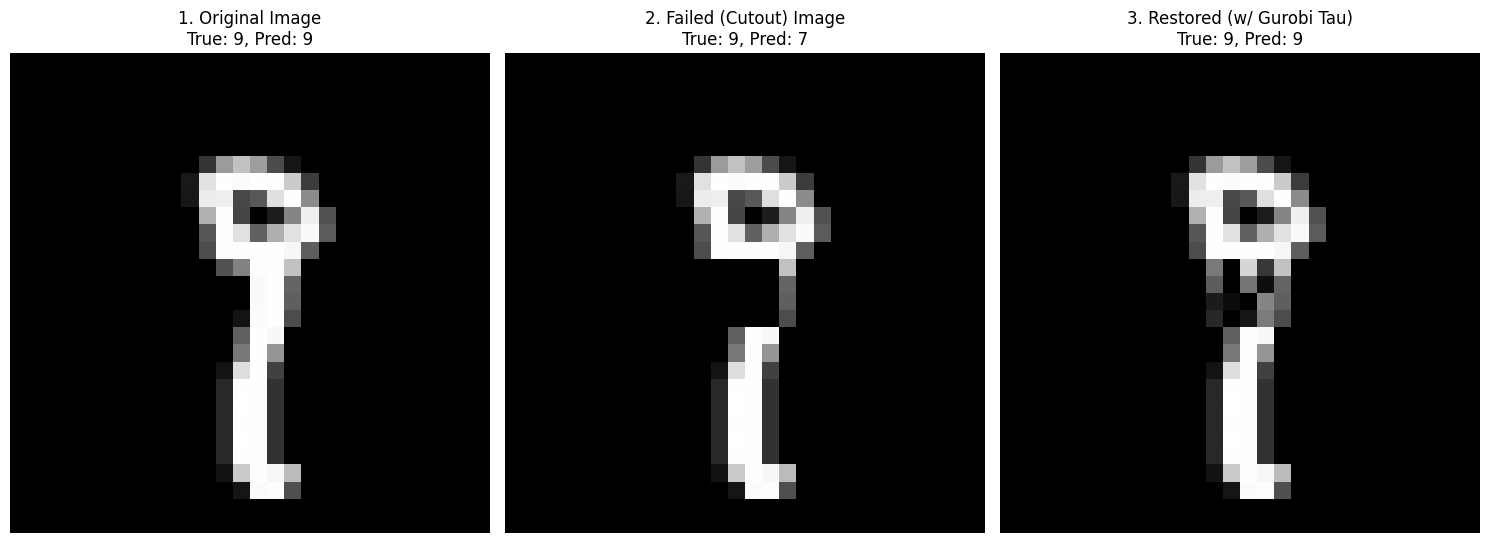


--- TEST 51/100: Image Index 342 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1163
Always active (L/U)      : 7399
Ambiguous ReLUs          : 846
ReLU binary variables    : 846
Binaries eliminated      : 8562
Binary reduction        : 91.01%
Starting optimized Gurobi optimization...
Solve time: 2.8840 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 342 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


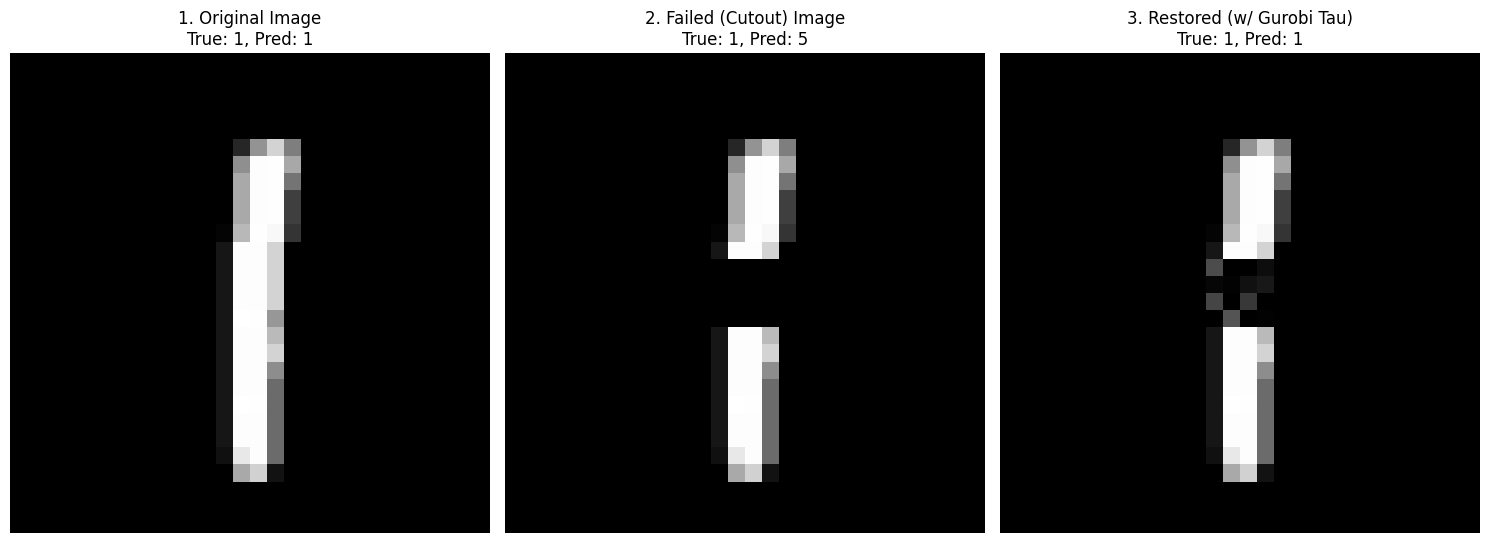


--- TEST 52/100: Image Index 345 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1200
Always active (L/U)      : 7456
Ambiguous ReLUs          : 752
ReLU binary variables    : 752
Binaries eliminated      : 8656
Binary reduction        : 92.01%
Starting optimized Gurobi optimization...
Solve time: 6.5921 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 345 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   3 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


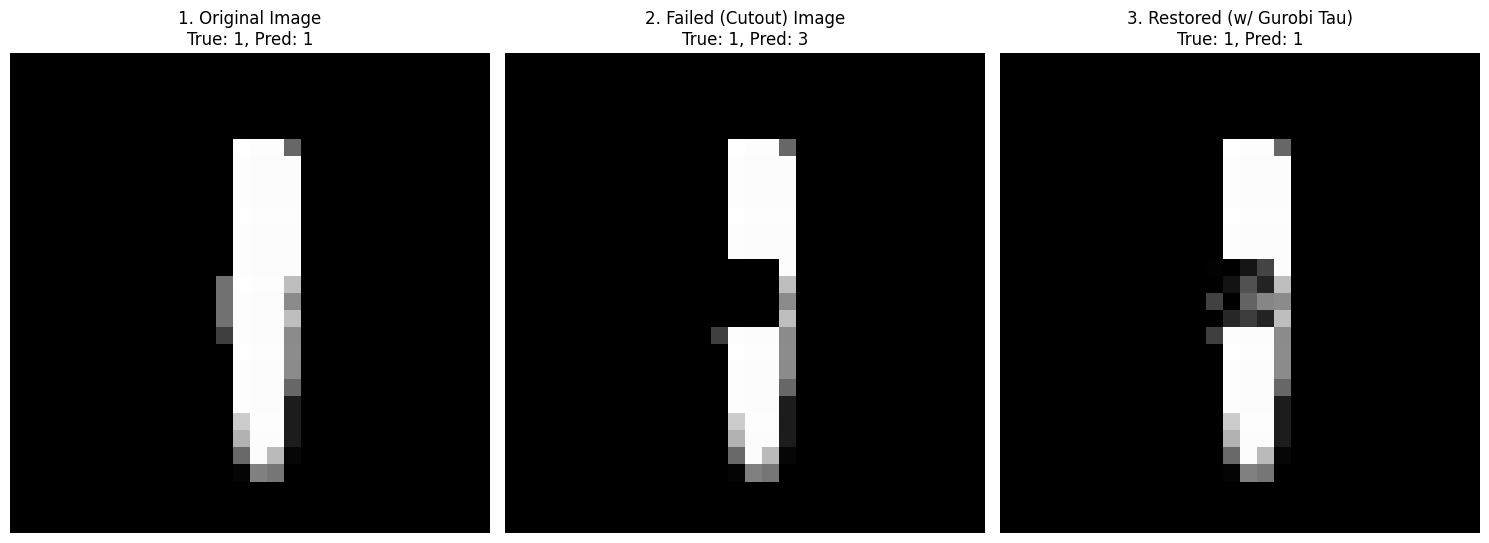


--- TEST 53/100: Image Index 348 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1182
Always active (L/U)      : 7385
Ambiguous ReLUs          : 841
ReLU binary variables    : 841
Binaries eliminated      : 8567
Binary reduction        : 91.06%
Starting optimized Gurobi optimization...
Solve time: 2.5662 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 348 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


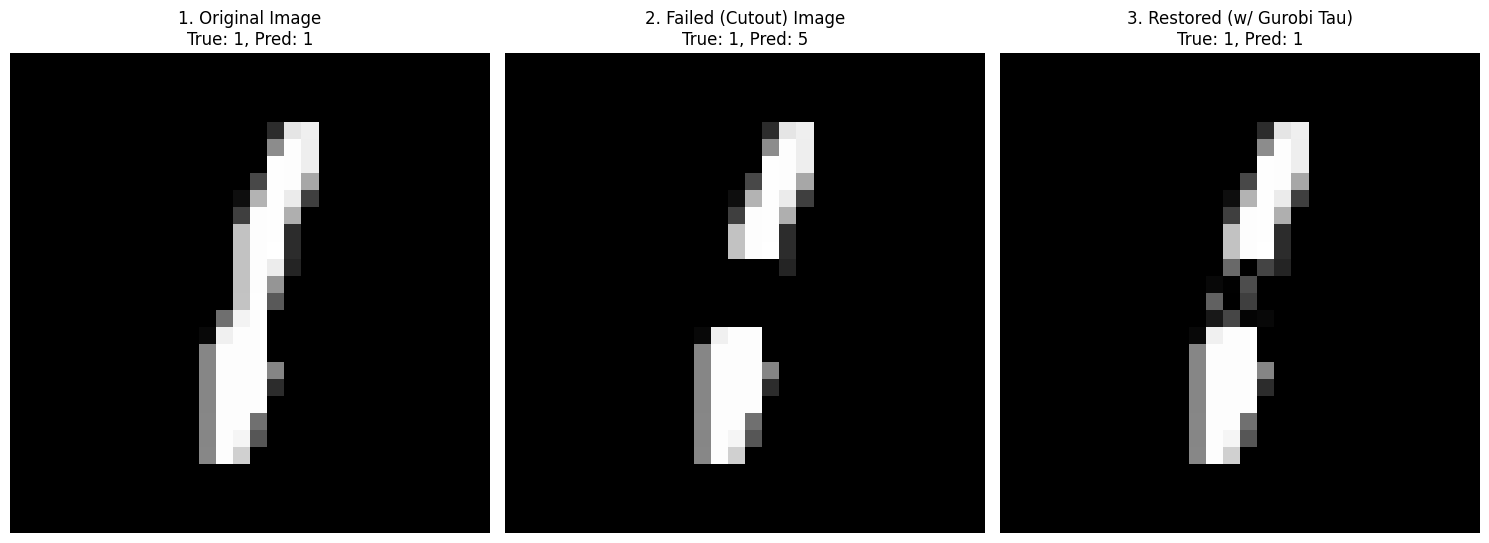


--- TEST 54/100: Image Index 359 ---
Running Gurobi to find corrective 'tau' patch for target 9...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1408
Always active (L/U)      : 7349
Ambiguous ReLUs          : 651
ReLU binary variables    : 651
Binaries eliminated      : 8757
Binary reduction        : 93.08%
Starting optimized Gurobi optimization...
Solve time: 6.0905 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 359 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   4 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


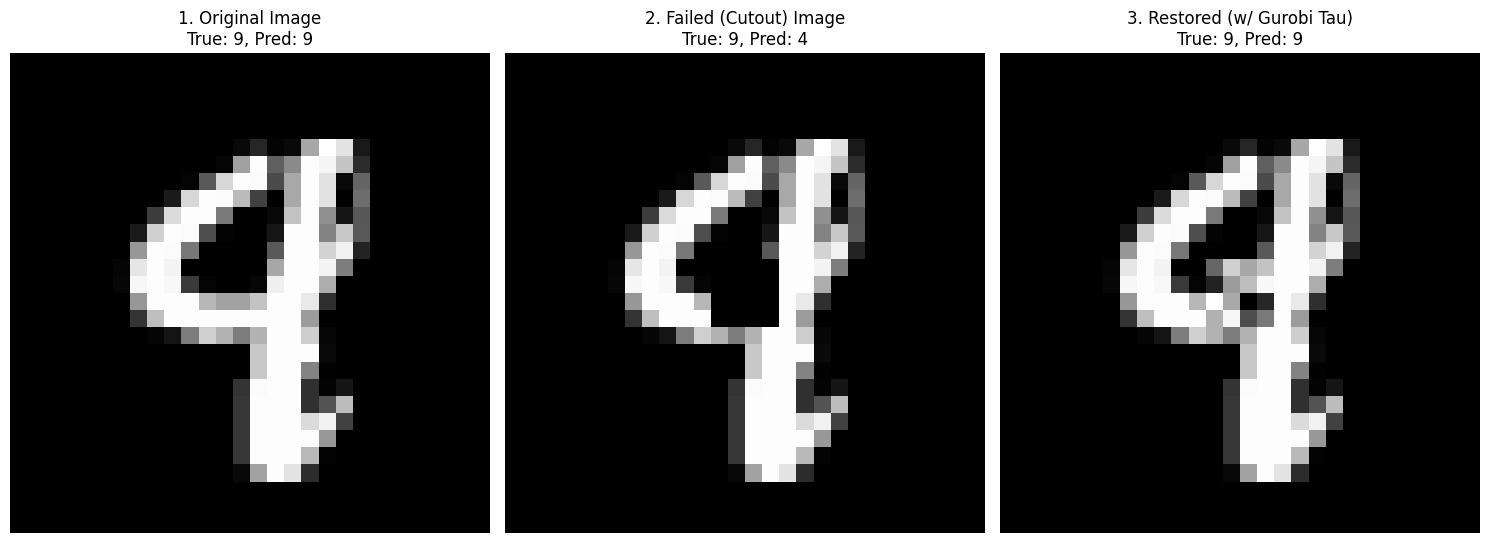


--- TEST 55/100: Image Index 389 ---
Running Gurobi to find corrective 'tau' patch for target 9...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1279
Always active (L/U)      : 7479
Ambiguous ReLUs          : 650
ReLU binary variables    : 650
Binaries eliminated      : 8758
Binary reduction        : 93.09%
Starting optimized Gurobi optimization...
Solve time: 7.0609 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 389 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


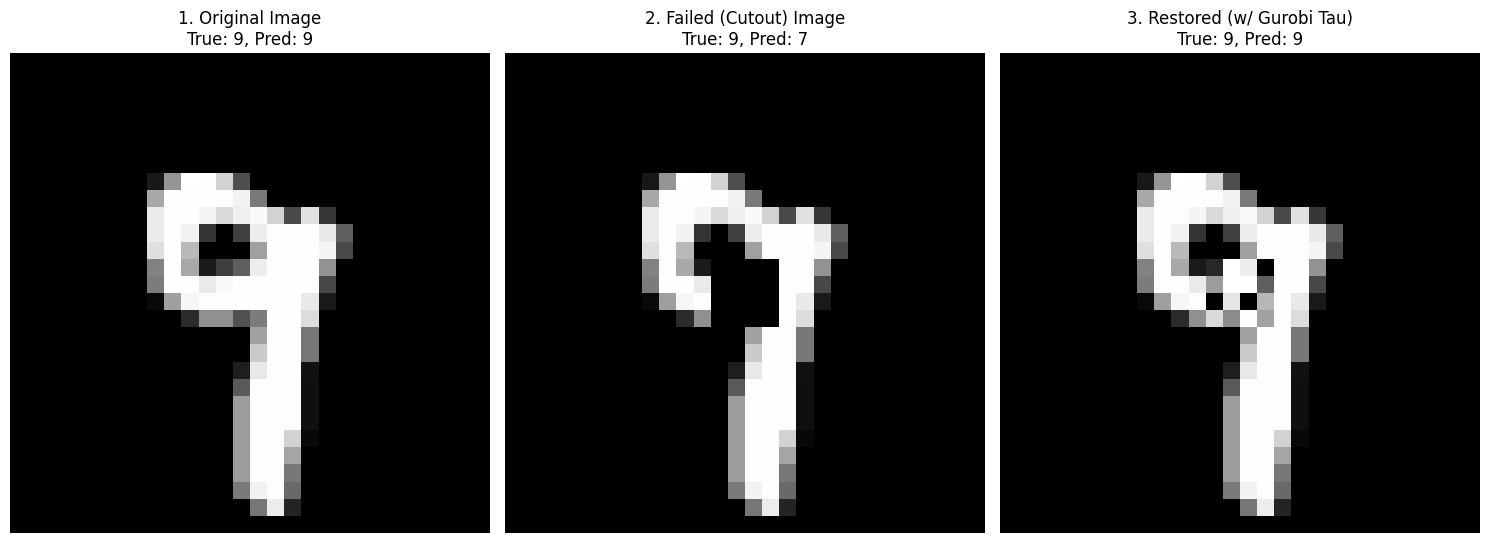


--- TEST 56/100: Image Index 39 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1211
Always active (L/U)      : 7414
Ambiguous ReLUs          : 783
ReLU binary variables    : 783
Binaries eliminated      : 8625
Binary reduction        : 91.68%
Starting optimized Gurobi optimization...
Solve time: 7.9661 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 39 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


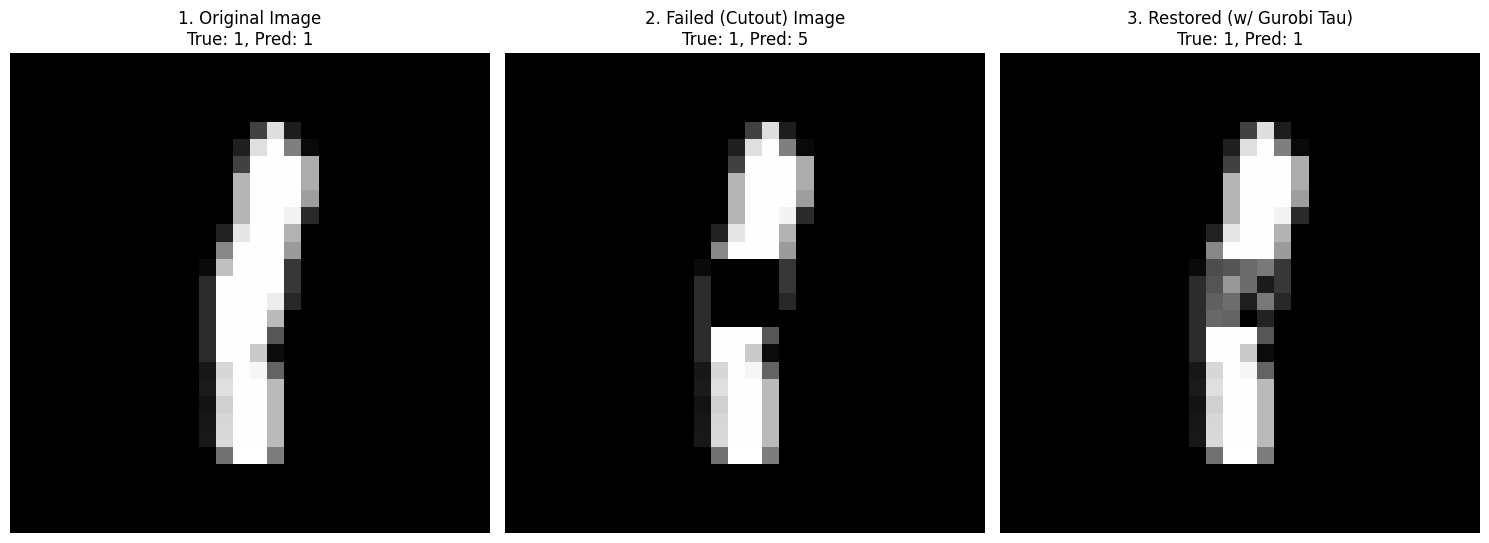


--- TEST 57/100: Image Index 409 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1215
Always active (L/U)      : 7386
Ambiguous ReLUs          : 807
ReLU binary variables    : 807
Binaries eliminated      : 8601
Binary reduction        : 91.42%
Starting optimized Gurobi optimization...
Solve time: 41.9076 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 409 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


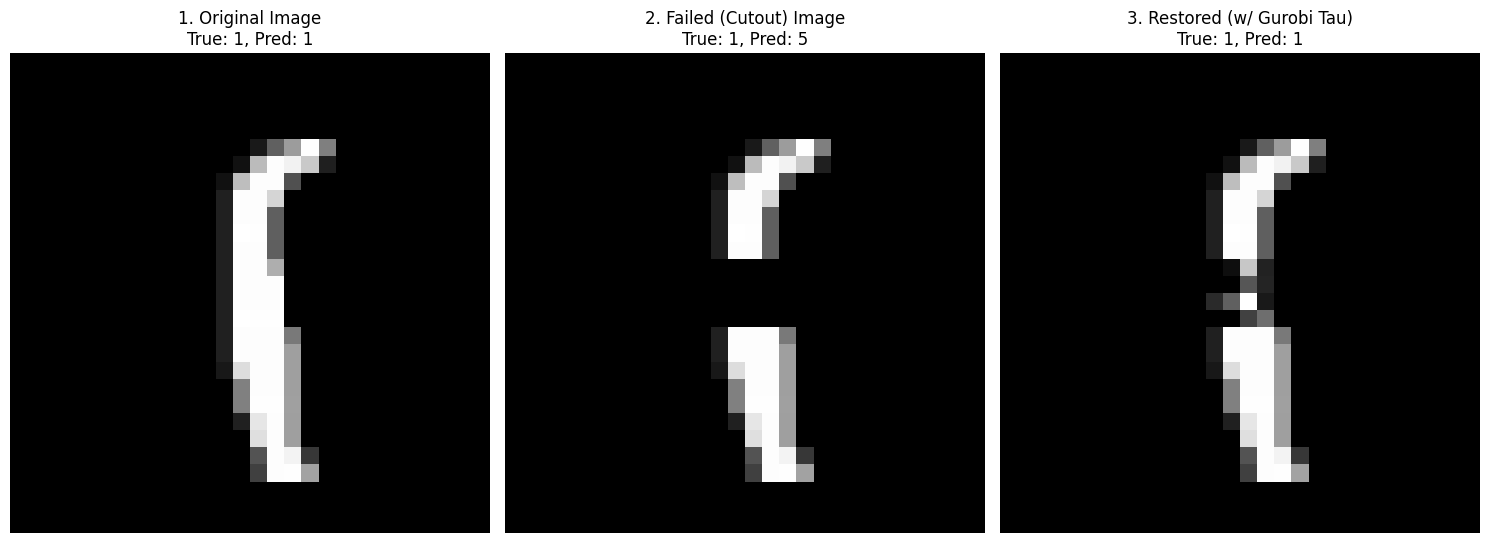


--- TEST 58/100: Image Index 435 ---
Running Gurobi to find corrective 'tau' patch for target 8...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1311
Always active (L/U)      : 7401
Ambiguous ReLUs          : 696
ReLU binary variables    : 696
Binaries eliminated      : 8712
Binary reduction        : 92.60%
Starting optimized Gurobi optimization...
Solve time: 1.7977 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 435 - True Label: 8
  Prediction (Original): 8 (Correct)
  Prediction (Failed):   9 (Incorrect)
  Prediction (Restored): 8 (Correct)
----------------------------------------


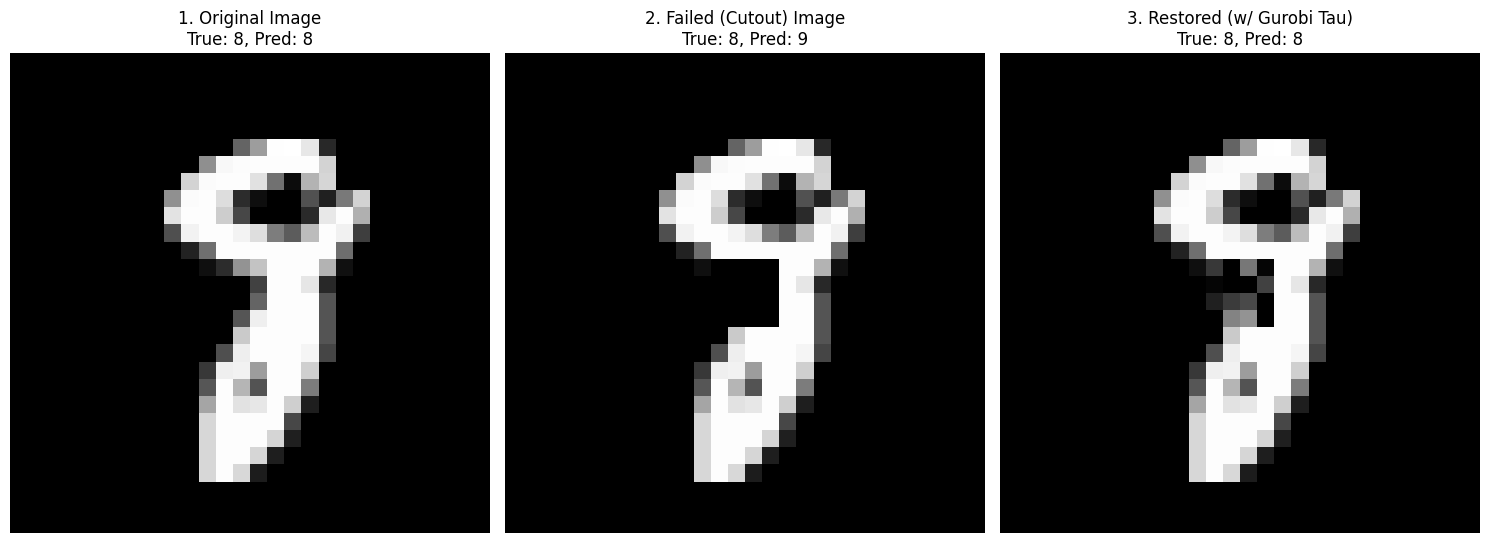


--- TEST 59/100: Image Index 449 ---
Running Gurobi to find corrective 'tau' patch for target 3...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1599
Always active (L/U)      : 7163
Ambiguous ReLUs          : 646
ReLU binary variables    : 646
Binaries eliminated      : 8762
Binary reduction        : 93.13%
Starting optimized Gurobi optimization...
Solve time: 4.4143 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 449 - True Label: 3
  Prediction (Original): 3 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 3 (Correct)
----------------------------------------


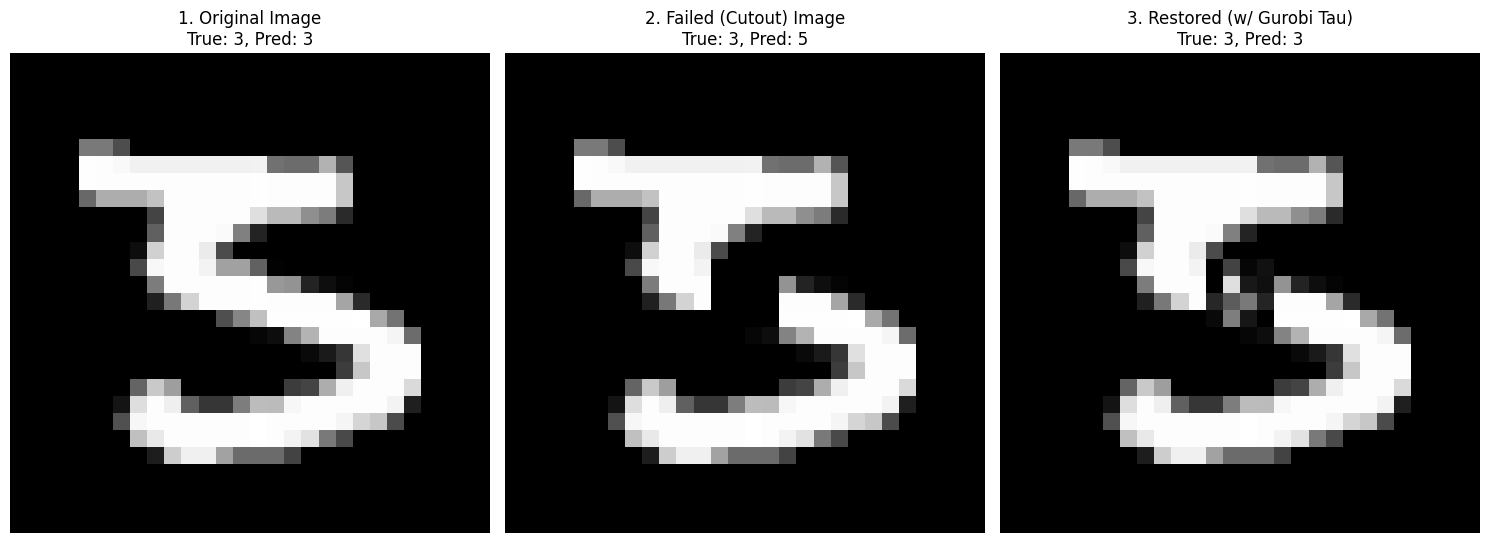


--- TEST 60/100: Image Index 471 ---
Running Gurobi to find corrective 'tau' patch for target 9...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1274
Always active (L/U)      : 7371
Ambiguous ReLUs          : 763
ReLU binary variables    : 763
Binaries eliminated      : 8645
Binary reduction        : 91.89%
Starting optimized Gurobi optimization...
Solve time: 2.7635 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 471 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


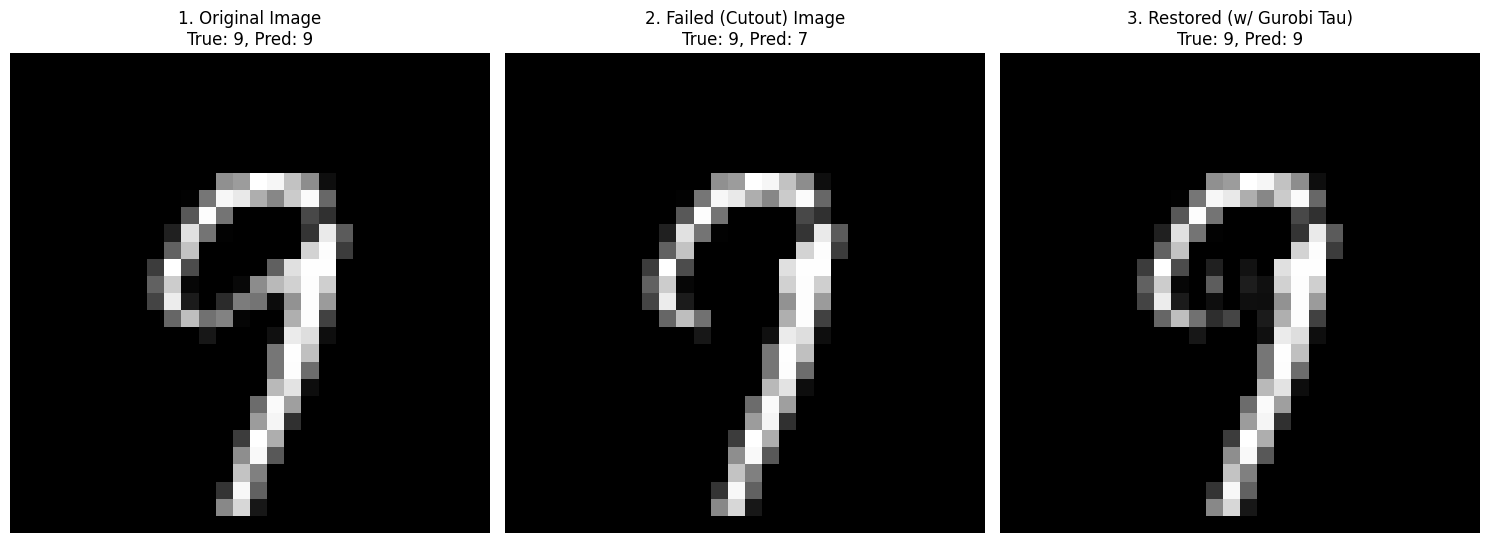


--- TEST 61/100: Image Index 476 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1212
Always active (L/U)      : 7384
Ambiguous ReLUs          : 812
ReLU binary variables    : 812
Binaries eliminated      : 8596
Binary reduction        : 91.37%
Starting optimized Gurobi optimization...
Solve time: 2.0253 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 476 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


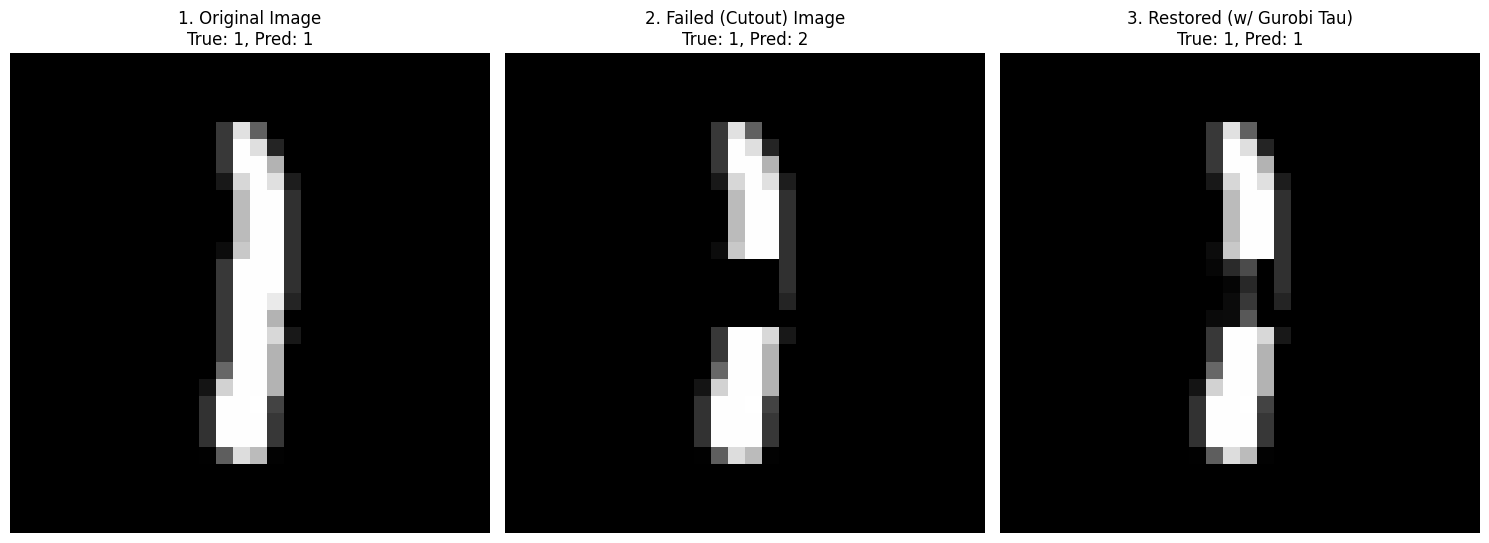


--- TEST 62/100: Image Index 497 ---
Running Gurobi to find corrective 'tau' patch for target 4...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1239
Always active (L/U)      : 7451
Ambiguous ReLUs          : 718
ReLU binary variables    : 718
Binaries eliminated      : 8690
Binary reduction        : 92.37%
Starting optimized Gurobi optimization...
Solve time: 5.7697 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 497 - True Label: 4
  Prediction (Original): 4 (Correct)
  Prediction (Failed):   1 (Incorrect)
  Prediction (Restored): 4 (Correct)
----------------------------------------


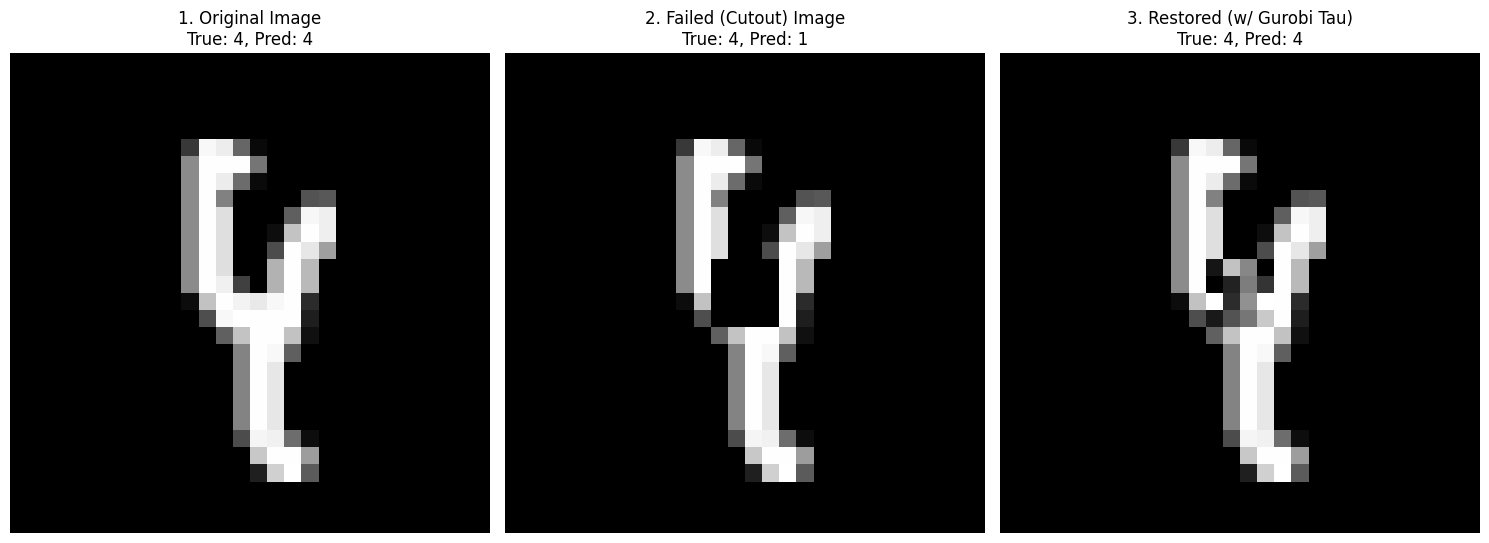


--- TEST 63/100: Image Index 543 ---
Running Gurobi to find corrective 'tau' patch for target 8...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1392
Always active (L/U)      : 7292
Ambiguous ReLUs          : 724
ReLU binary variables    : 724
Binaries eliminated      : 8684
Binary reduction        : 92.30%
Starting optimized Gurobi optimization...
Solve time: 7.7564 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 543 - True Label: 8
  Prediction (Original): 8 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 8 (Correct)
----------------------------------------


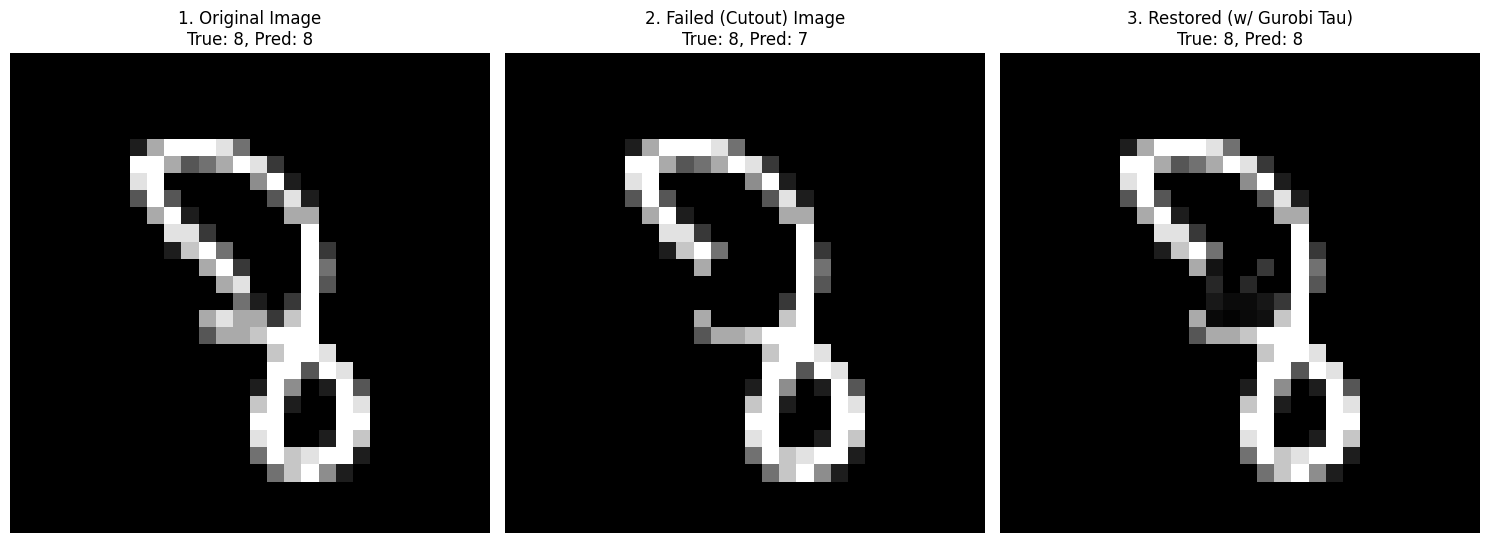


--- TEST 64/100: Image Index 593 ---
Running Gurobi to find corrective 'tau' patch for target 9...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1266
Always active (L/U)      : 7442
Ambiguous ReLUs          : 700
ReLU binary variables    : 700
Binaries eliminated      : 8708
Binary reduction        : 92.56%
Starting optimized Gurobi optimization...
Solve time: 75.8994 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 593 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


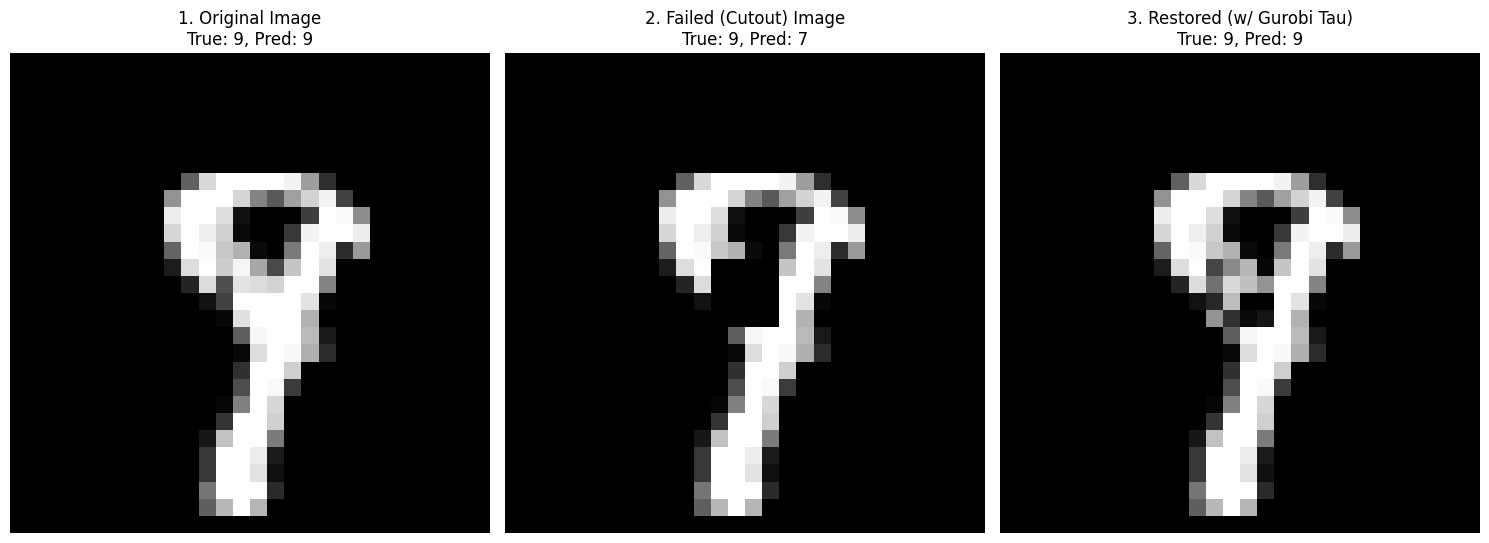


--- TEST 65/100: Image Index 615 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1293
Always active (L/U)      : 7294
Ambiguous ReLUs          : 821
ReLU binary variables    : 821
Binaries eliminated      : 8587
Binary reduction        : 91.27%
Starting optimized Gurobi optimization...
Solve time: 31.4454 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 615 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


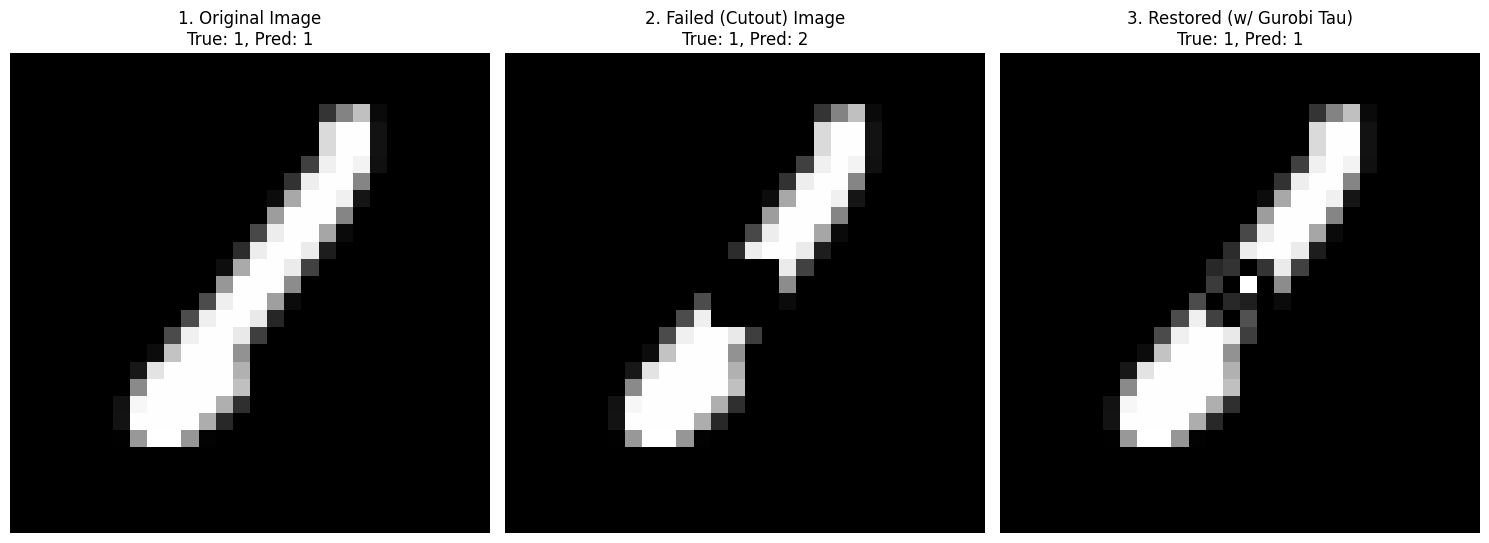


--- TEST 66/100: Image Index 619 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1381
Always active (L/U)      : 7395
Ambiguous ReLUs          : 632
ReLU binary variables    : 632
Binaries eliminated      : 8776
Binary reduction        : 93.28%
Starting optimized Gurobi optimization...
Solve time: 600.1194 s
Gurobi status: 9
Time limit reached before a feasible solution was found.
Gurobi could not find a corrective patch for image 619.

--- TEST 67/100: Image Index 652 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1186
Always active (L/U)      : 7397
Ambiguous ReLUs          : 825
ReLU binary variables    : 825
Binaries eliminated      : 8583
Binary reduction        : 91.23%
Starting optimized Gurobi optimization...
Solve time: 2.2575 s
Gurobi status: 2
Gurobi found a so

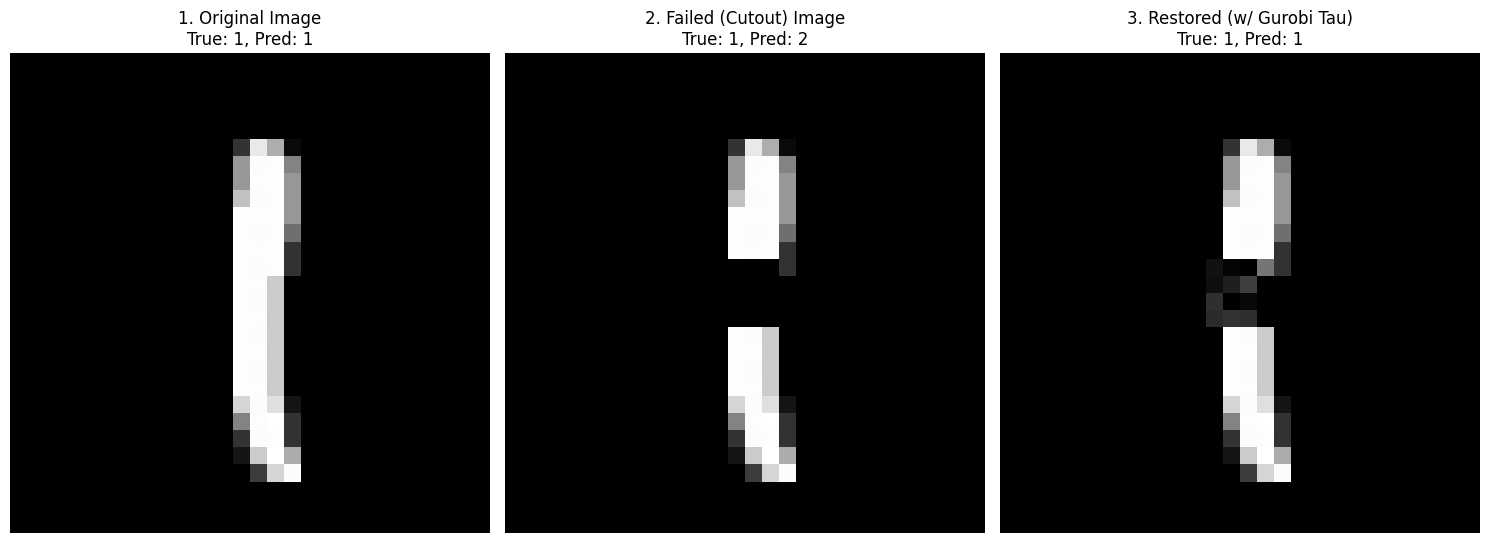


--- TEST 68/100: Image Index 655 ---
Running Gurobi to find corrective 'tau' patch for target 8...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1575
Always active (L/U)      : 7228
Ambiguous ReLUs          : 605
ReLU binary variables    : 605
Binaries eliminated      : 8803
Binary reduction        : 93.57%
Starting optimized Gurobi optimization...
Solve time: 5.1375 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 655 - True Label: 8
  Prediction (Original): 8 (Correct)
  Prediction (Failed):   3 (Incorrect)
  Prediction (Restored): 8 (Correct)
----------------------------------------


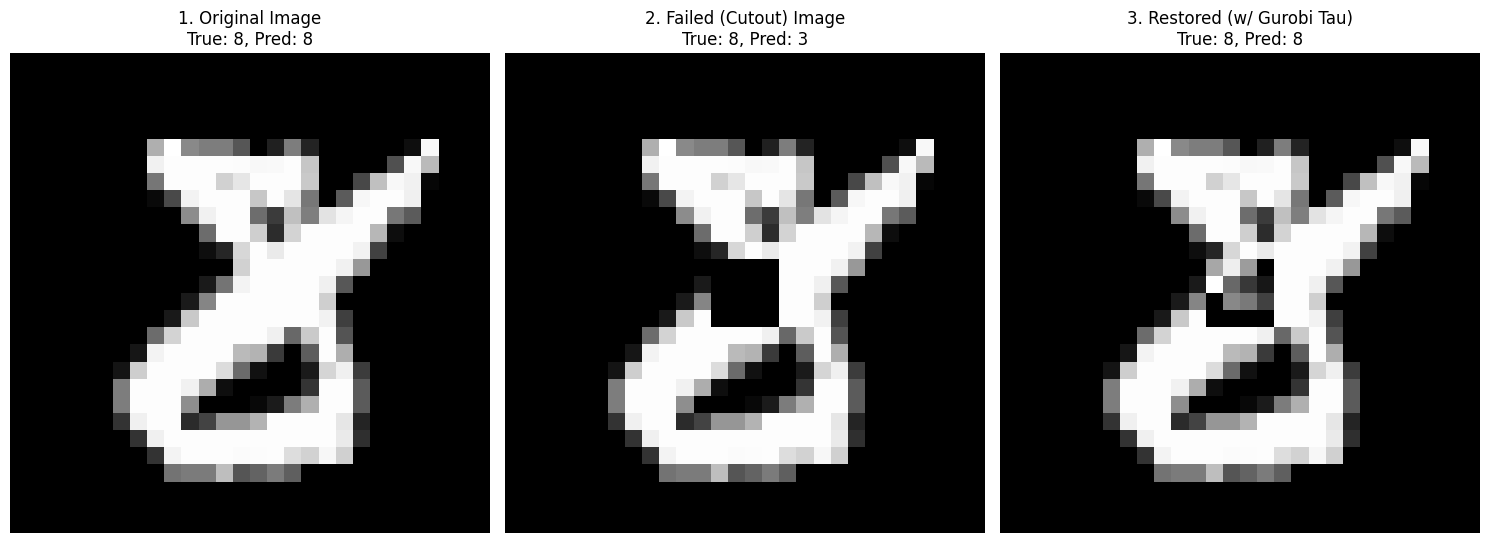


--- TEST 69/100: Image Index 663 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1183
Always active (L/U)      : 7389
Ambiguous ReLUs          : 836
ReLU binary variables    : 836
Binaries eliminated      : 8572
Binary reduction        : 91.11%
Starting optimized Gurobi optimization...
Solve time: 12.5187 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 663 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


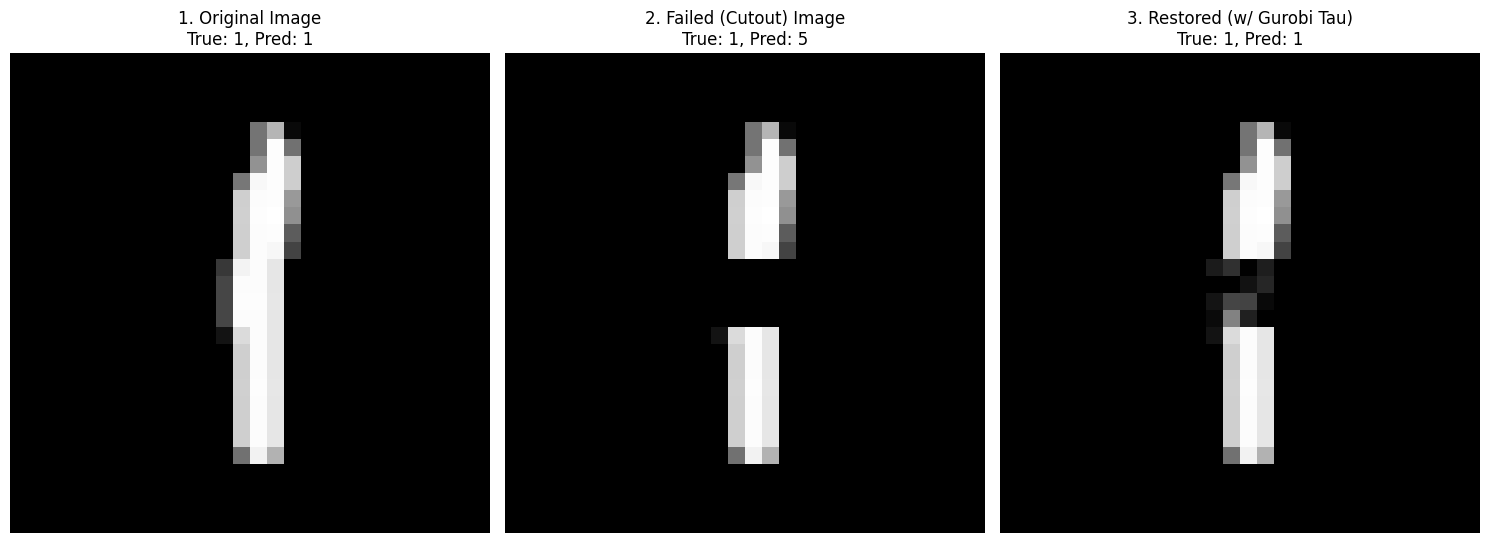


--- TEST 70/100: Image Index 674 ---
Running Gurobi to find corrective 'tau' patch for target 5...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1414
Always active (L/U)      : 7269
Ambiguous ReLUs          : 725
ReLU binary variables    : 725
Binaries eliminated      : 8683
Binary reduction        : 92.29%
Starting optimized Gurobi optimization...
Solve time: 86.5392 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 674 - True Label: 5
  Prediction (Original): 5 (Correct)
  Prediction (Failed):   3 (Incorrect)
  Prediction (Restored): 5 (Correct)
----------------------------------------


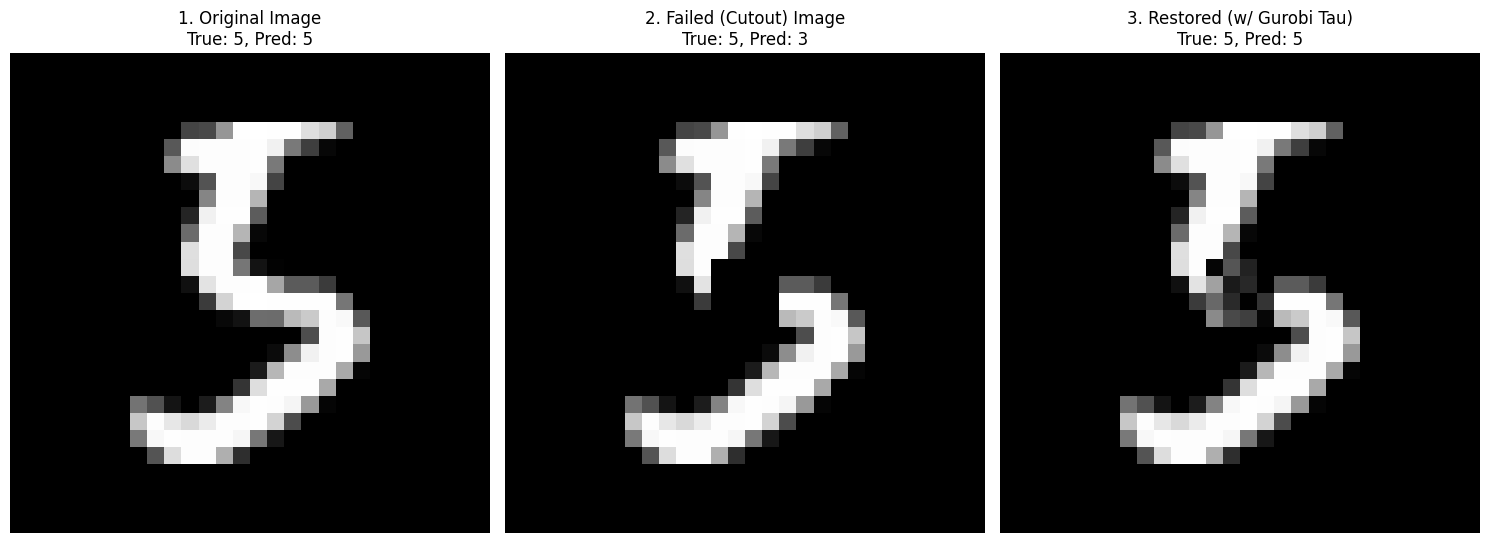


--- TEST 71/100: Image Index 675 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1164
Always active (L/U)      : 7389
Ambiguous ReLUs          : 855
ReLU binary variables    : 855
Binaries eliminated      : 8553
Binary reduction        : 90.91%
Starting optimized Gurobi optimization...
Solve time: 2.8637 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 675 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


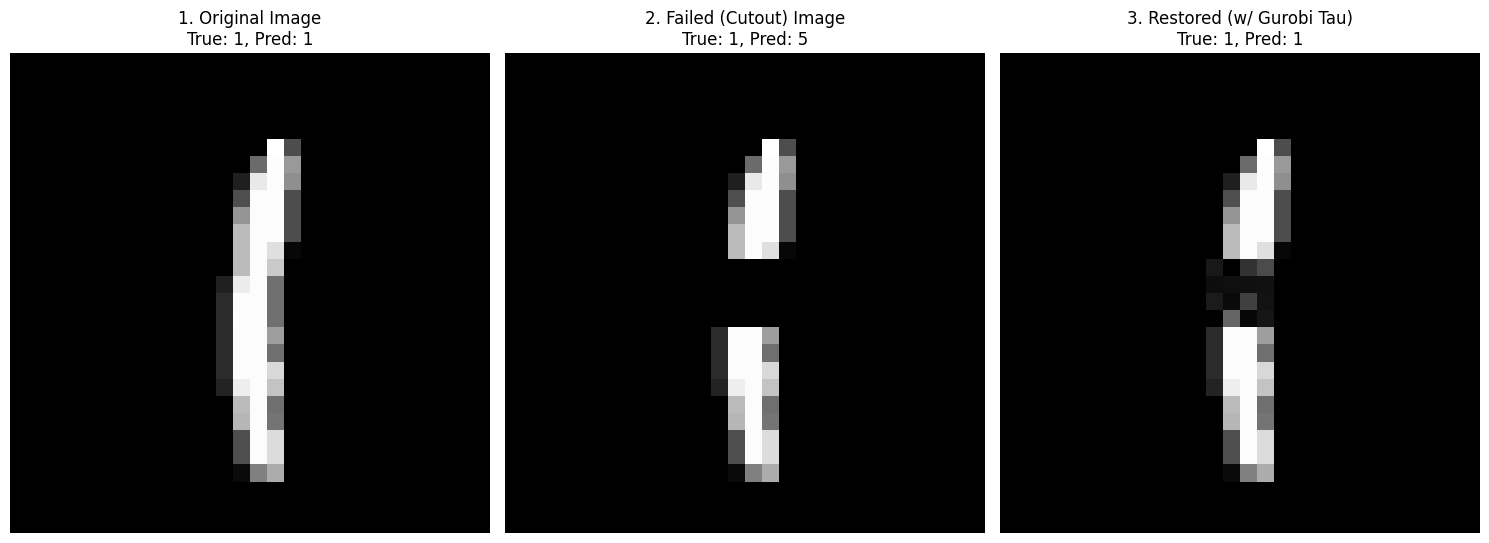


--- TEST 72/100: Image Index 716 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1167
Always active (L/U)      : 7396
Ambiguous ReLUs          : 845
ReLU binary variables    : 845
Binaries eliminated      : 8563
Binary reduction        : 91.02%
Starting optimized Gurobi optimization...
Solve time: 121.4596 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 716 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


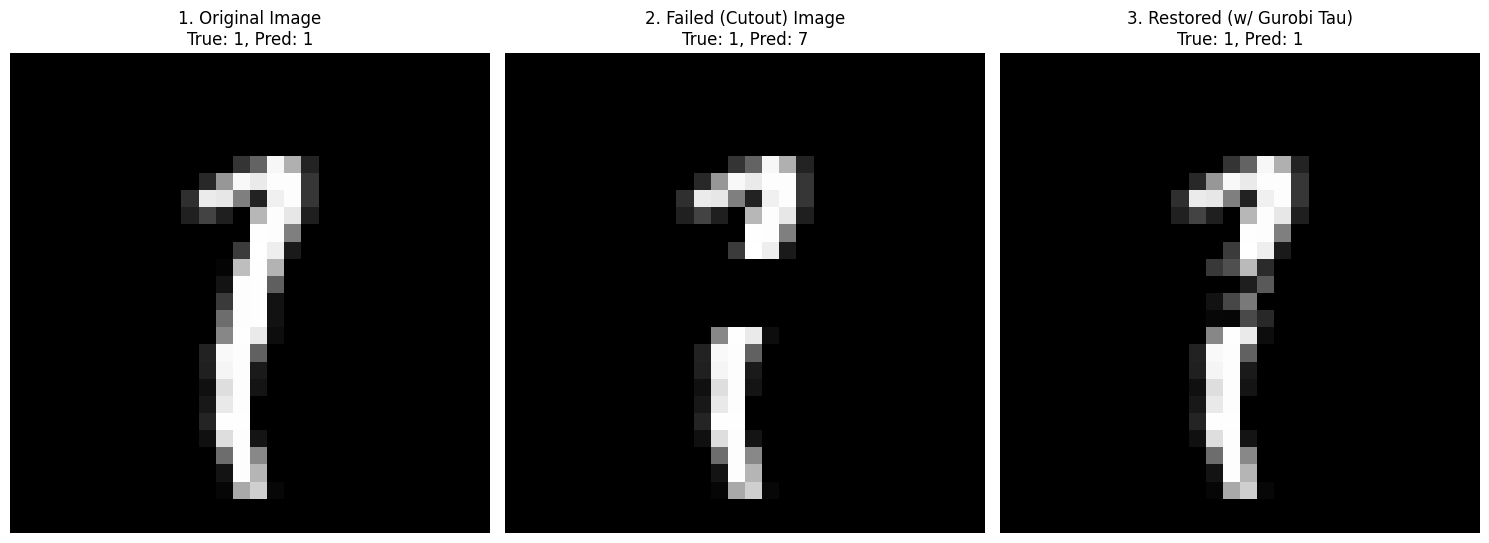


--- TEST 73/100: Image Index 718 ---
Running Gurobi to find corrective 'tau' patch for target 8...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1414
Always active (L/U)      : 7350
Ambiguous ReLUs          : 644
ReLU binary variables    : 644
Binaries eliminated      : 8764
Binary reduction        : 93.15%
Starting optimized Gurobi optimization...
Solve time: 1.7941 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 718 - True Label: 8
  Prediction (Original): 8 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 8 (Correct)
----------------------------------------


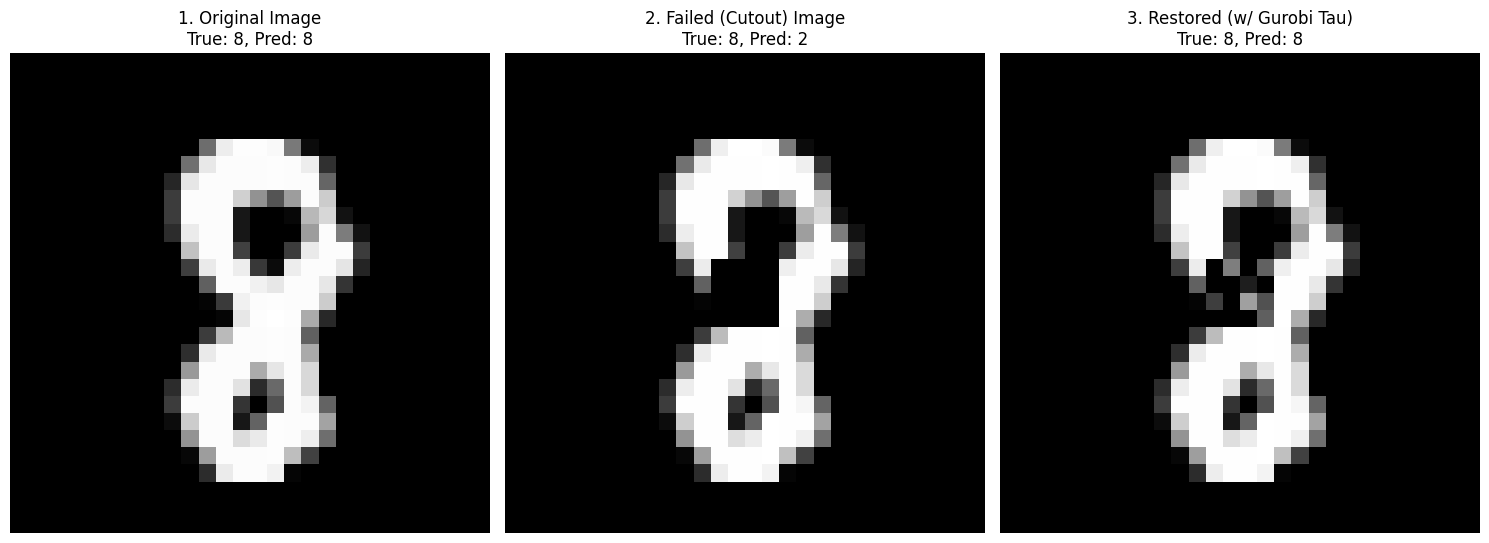


--- TEST 74/100: Image Index 73 ---
Running Gurobi to find corrective 'tau' patch for target 9...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1340
Always active (L/U)      : 7416
Ambiguous ReLUs          : 652
ReLU binary variables    : 652
Binaries eliminated      : 8756
Binary reduction        : 93.07%
Starting optimized Gurobi optimization...
Solve time: 4.9917 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 73 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


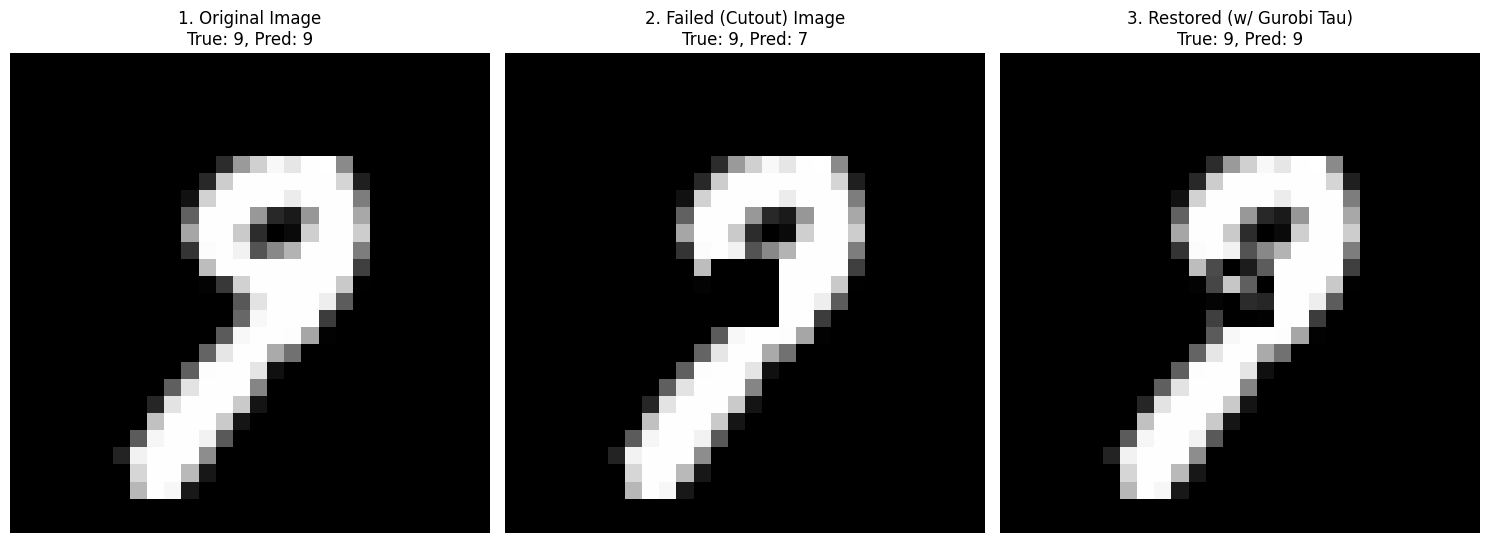


--- TEST 75/100: Image Index 759 ---
Running Gurobi to find corrective 'tau' patch for target 9...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1287
Always active (L/U)      : 7384
Ambiguous ReLUs          : 737
ReLU binary variables    : 737
Binaries eliminated      : 8671
Binary reduction        : 92.17%
Starting optimized Gurobi optimization...
Solve time: 2.2728 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 759 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


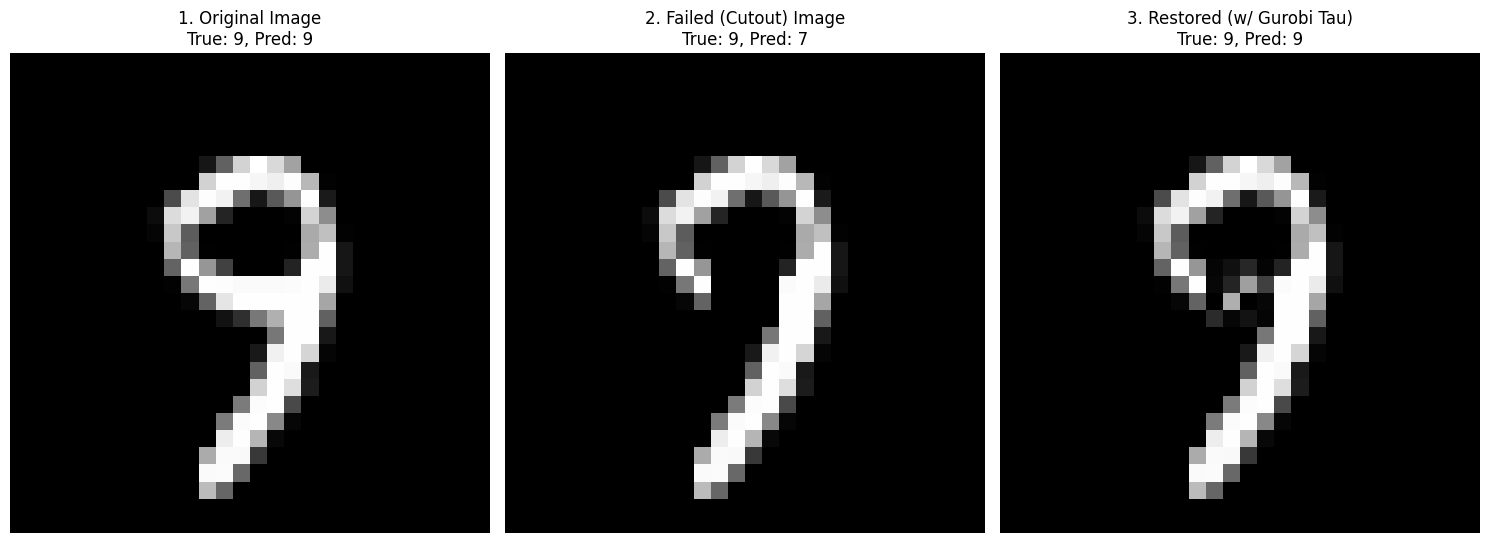


--- TEST 76/100: Image Index 767 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1126
Always active (L/U)      : 7395
Ambiguous ReLUs          : 887
ReLU binary variables    : 887
Binaries eliminated      : 8521
Binary reduction        : 90.57%
Starting optimized Gurobi optimization...
Solve time: 9.3891 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 767 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


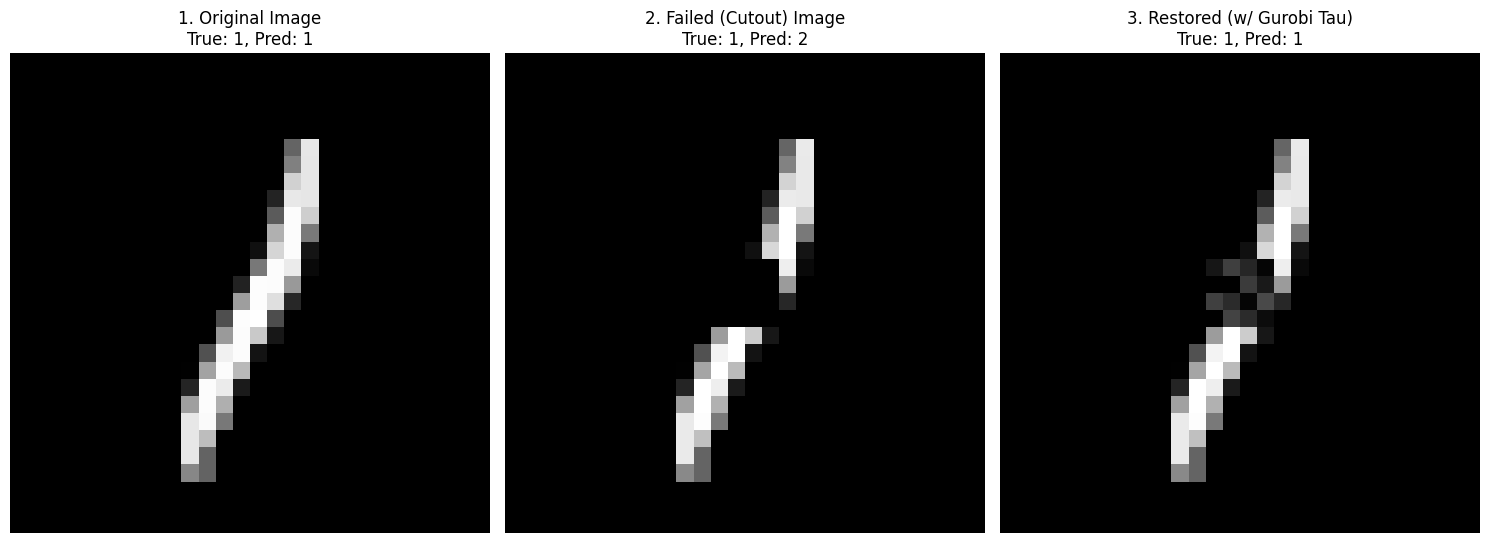


--- TEST 77/100: Image Index 768 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1185
Always active (L/U)      : 7390
Ambiguous ReLUs          : 833
ReLU binary variables    : 833
Binaries eliminated      : 8575
Binary reduction        : 91.15%
Starting optimized Gurobi optimization...
Solve time: 2.3641 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 768 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


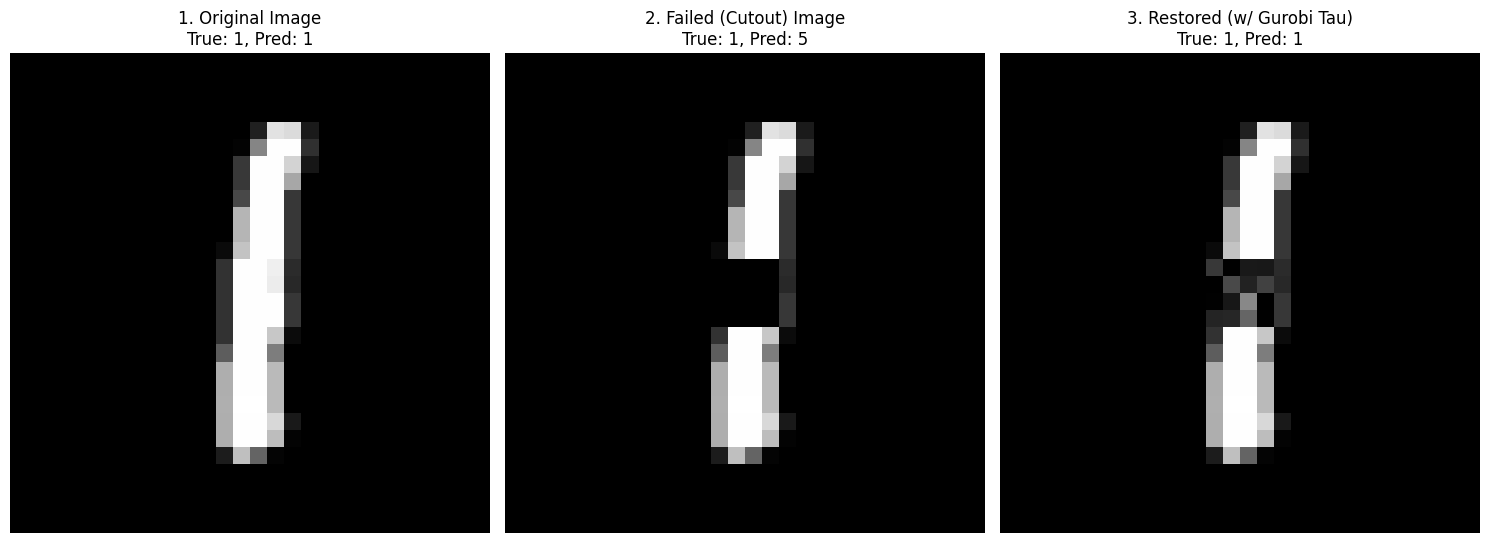


--- TEST 78/100: Image Index 777 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1252
Always active (L/U)      : 7437
Ambiguous ReLUs          : 719
ReLU binary variables    : 719
Binaries eliminated      : 8689
Binary reduction        : 92.36%
Starting optimized Gurobi optimization...
Solve time: 1.9011 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 777 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   3 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


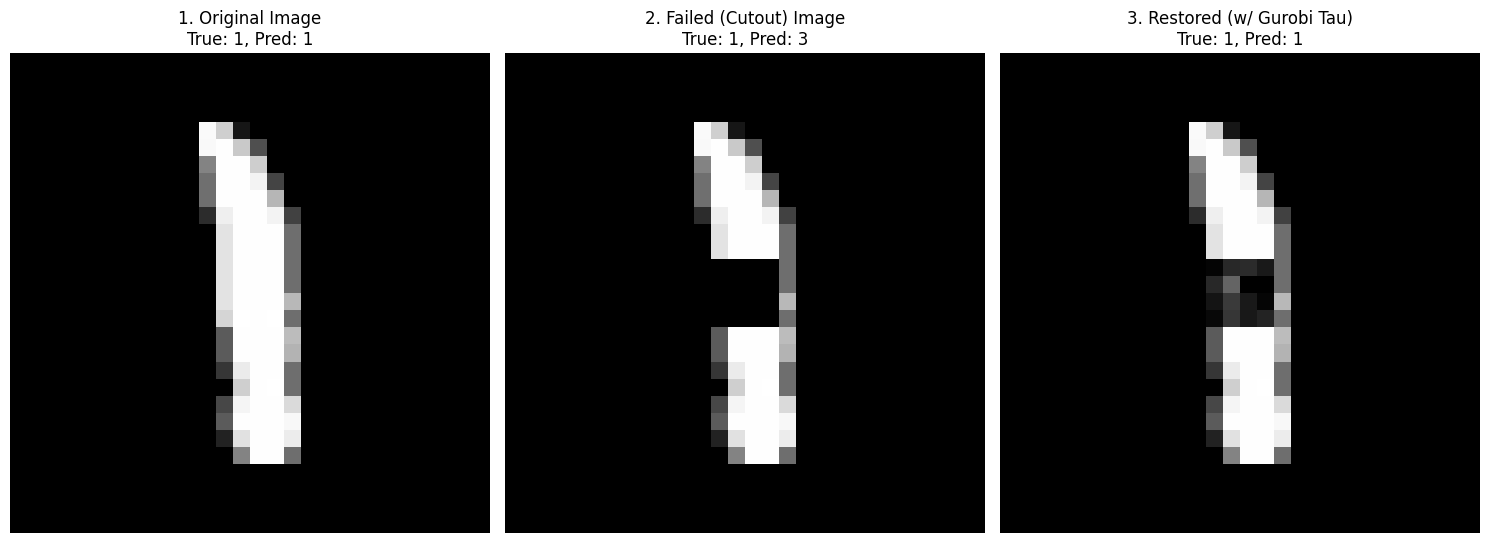


--- TEST 79/100: Image Index 790 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1209
Always active (L/U)      : 7386
Ambiguous ReLUs          : 813
ReLU binary variables    : 813
Binaries eliminated      : 8595
Binary reduction        : 91.36%
Starting optimized Gurobi optimization...
Solve time: 44.5748 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 790 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


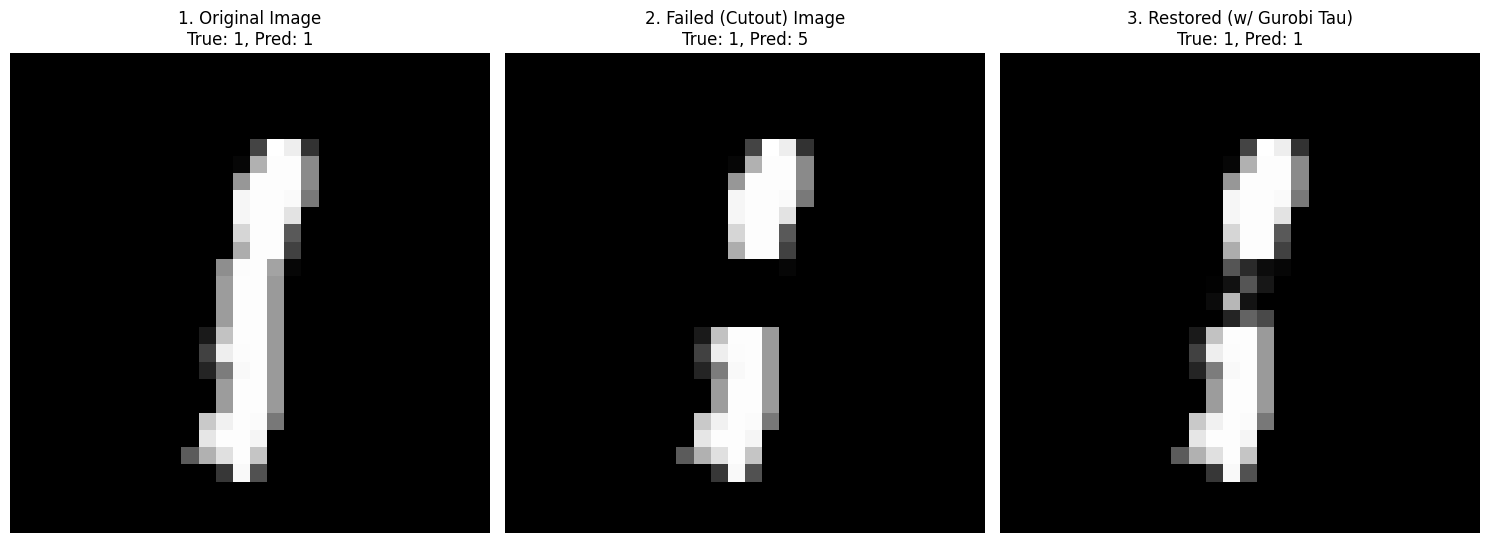


--- TEST 80/100: Image Index 800 ---
Running Gurobi to find corrective 'tau' patch for target 8...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1448
Always active (L/U)      : 7253
Ambiguous ReLUs          : 707
ReLU binary variables    : 707
Binaries eliminated      : 8701
Binary reduction        : 92.49%
Starting optimized Gurobi optimization...
Solve time: 16.3462 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 800 - True Label: 8
  Prediction (Original): 8 (Correct)
  Prediction (Failed):   0 (Incorrect)
  Prediction (Restored): 8 (Correct)
----------------------------------------


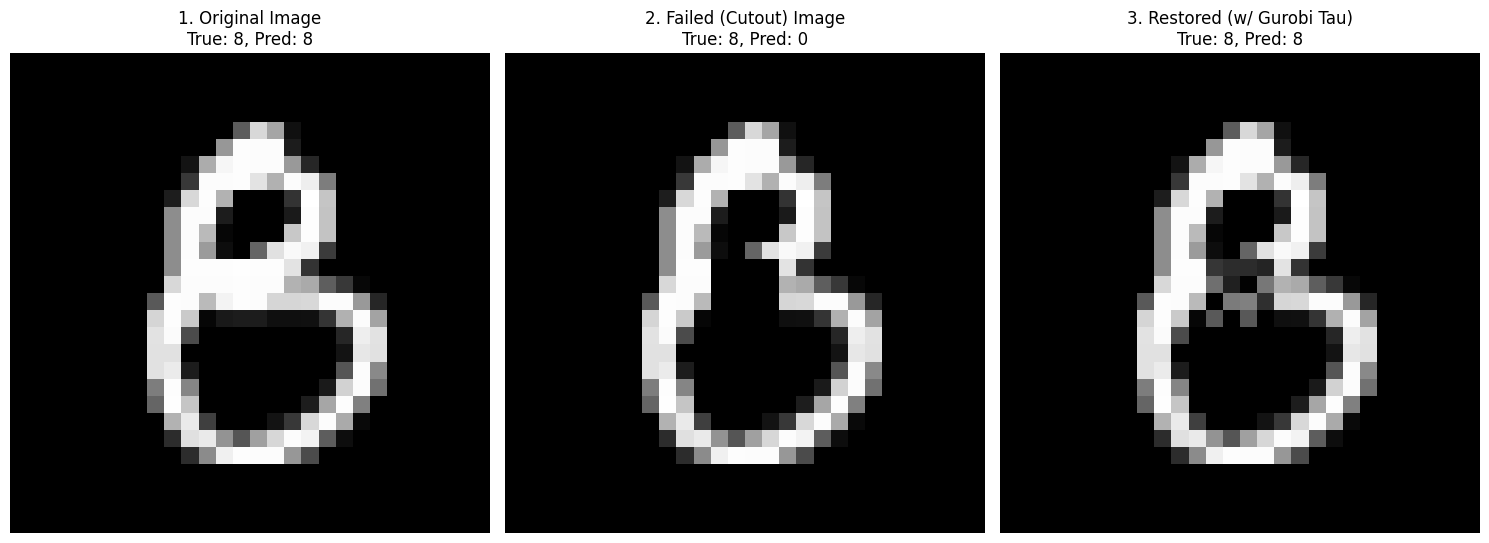


--- TEST 81/100: Image Index 818 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1254
Always active (L/U)      : 7359
Ambiguous ReLUs          : 795
ReLU binary variables    : 795
Binaries eliminated      : 8613
Binary reduction        : 91.55%
Starting optimized Gurobi optimization...
Solve time: 8.1520 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 818 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


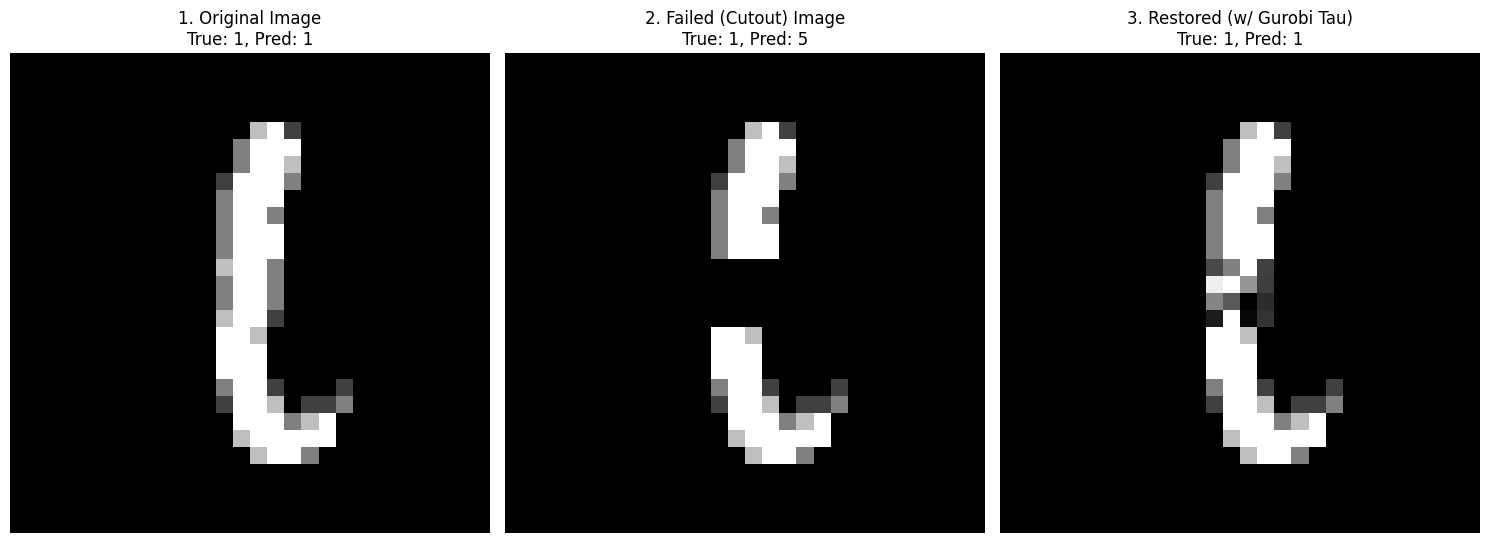


--- TEST 82/100: Image Index 826 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1168
Always active (L/U)      : 7377
Ambiguous ReLUs          : 863
ReLU binary variables    : 863
Binaries eliminated      : 8545
Binary reduction        : 90.83%
Starting optimized Gurobi optimization...
Solve time: 2.5384 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 826 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


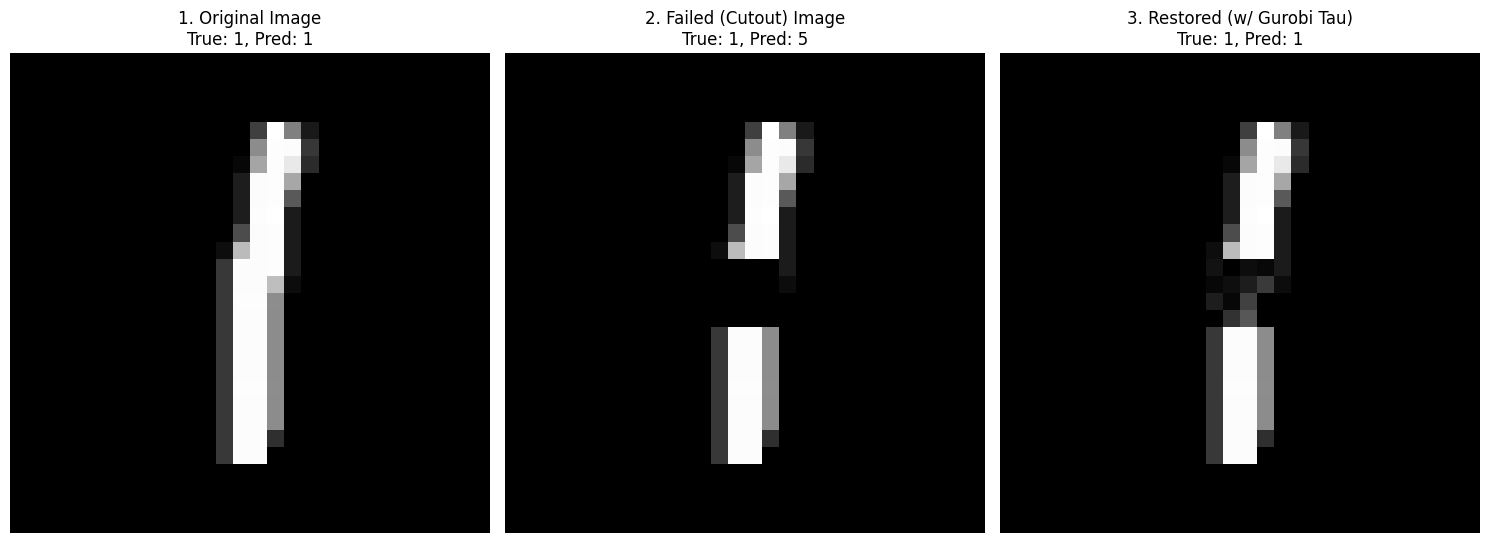


--- TEST 83/100: Image Index 831 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1166
Always active (L/U)      : 7420
Ambiguous ReLUs          : 822
ReLU binary variables    : 822
Binaries eliminated      : 8586
Binary reduction        : 91.26%
Starting optimized Gurobi optimization...
Solve time: 9.2664 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 831 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


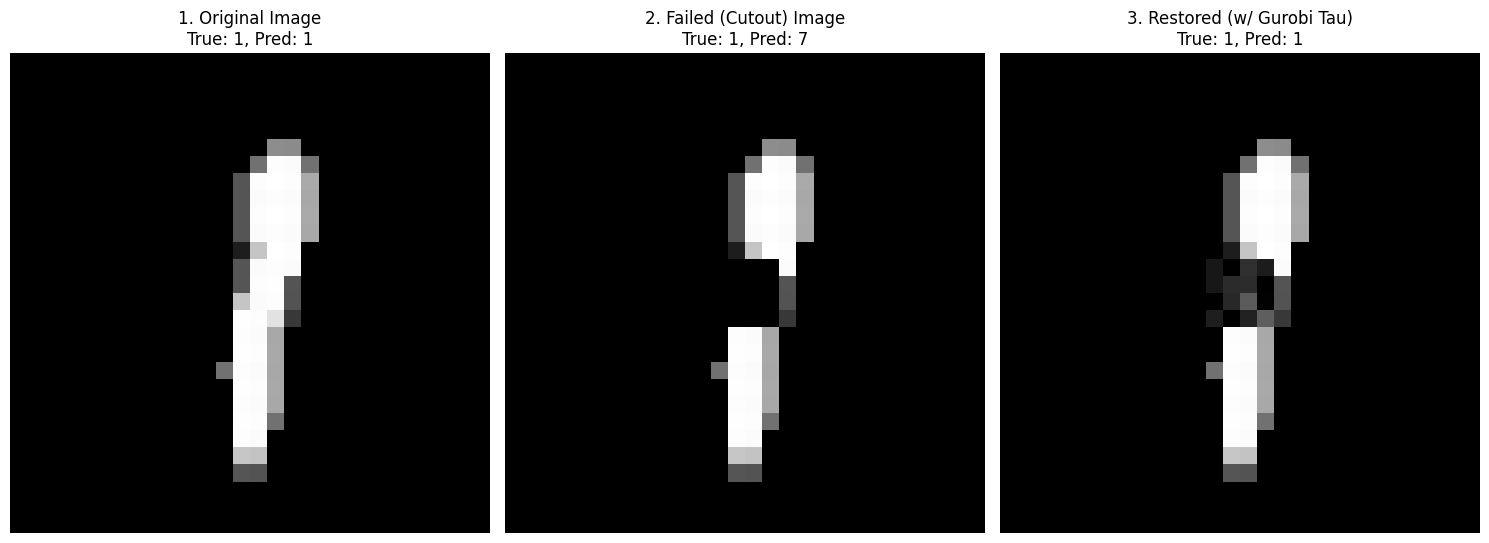


--- TEST 84/100: Image Index 833 ---
Running Gurobi to find corrective 'tau' patch for target 9...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1292
Always active (L/U)      : 7441
Ambiguous ReLUs          : 675
ReLU binary variables    : 675
Binaries eliminated      : 8733
Binary reduction        : 92.83%
Starting optimized Gurobi optimization...
Solve time: 8.2510 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 833 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


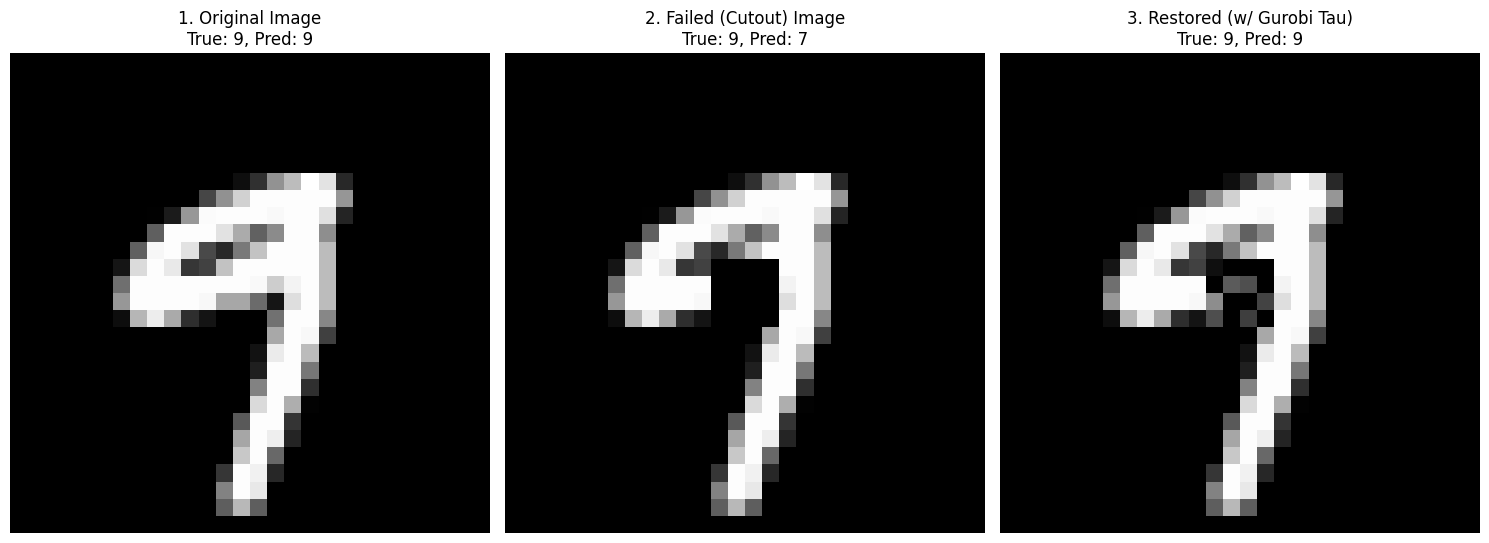


--- TEST 85/100: Image Index 836 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1156
Always active (L/U)      : 7378
Ambiguous ReLUs          : 874
ReLU binary variables    : 874
Binaries eliminated      : 8534
Binary reduction        : 90.71%
Starting optimized Gurobi optimization...
Solve time: 22.5588 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 836 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


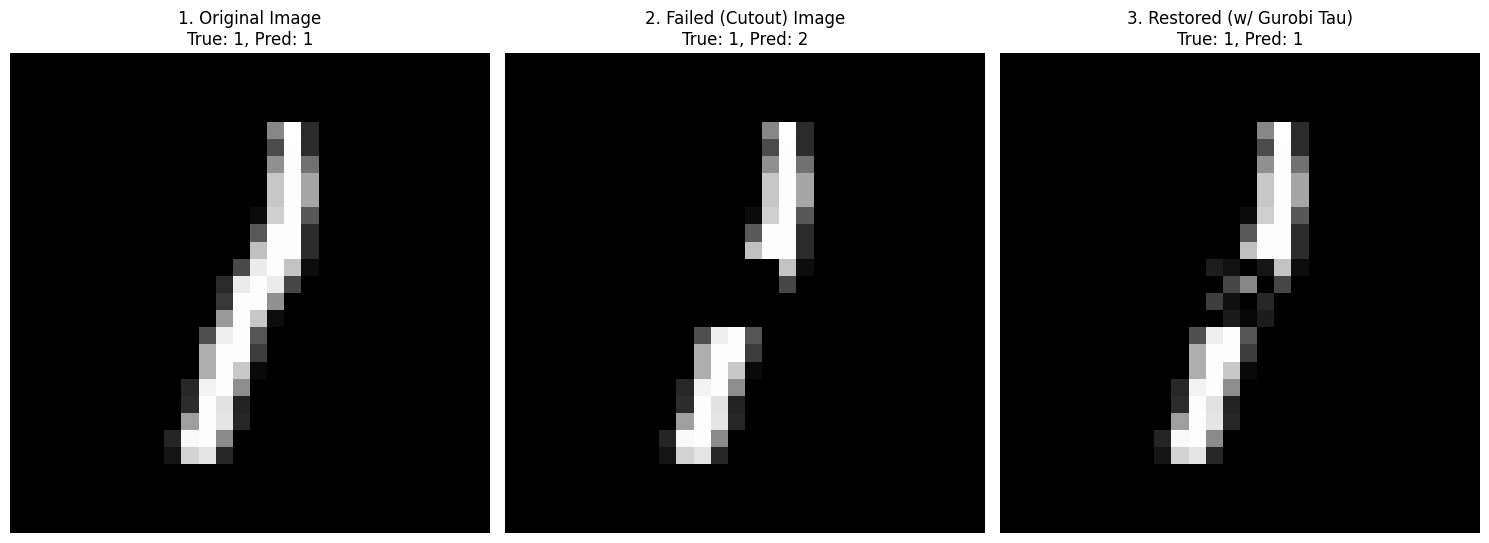


--- TEST 86/100: Image Index 840 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1225
Always active (L/U)      : 7427
Ambiguous ReLUs          : 756
ReLU binary variables    : 756
Binaries eliminated      : 8652
Binary reduction        : 91.96%
Starting optimized Gurobi optimization...
Solve time: 2.8657 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 840 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


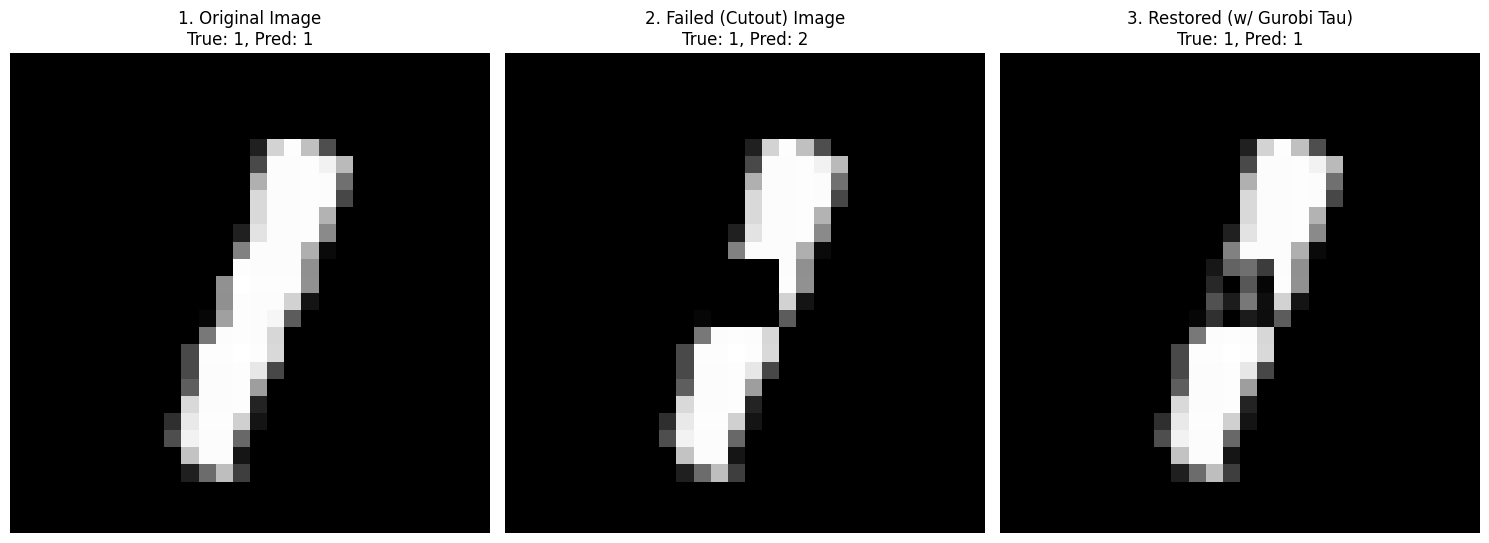


--- TEST 87/100: Image Index 848 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1165
Always active (L/U)      : 7371
Ambiguous ReLUs          : 872
ReLU binary variables    : 872
Binaries eliminated      : 8536
Binary reduction        : 90.73%
Starting optimized Gurobi optimization...
Solve time: 7.4458 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 848 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


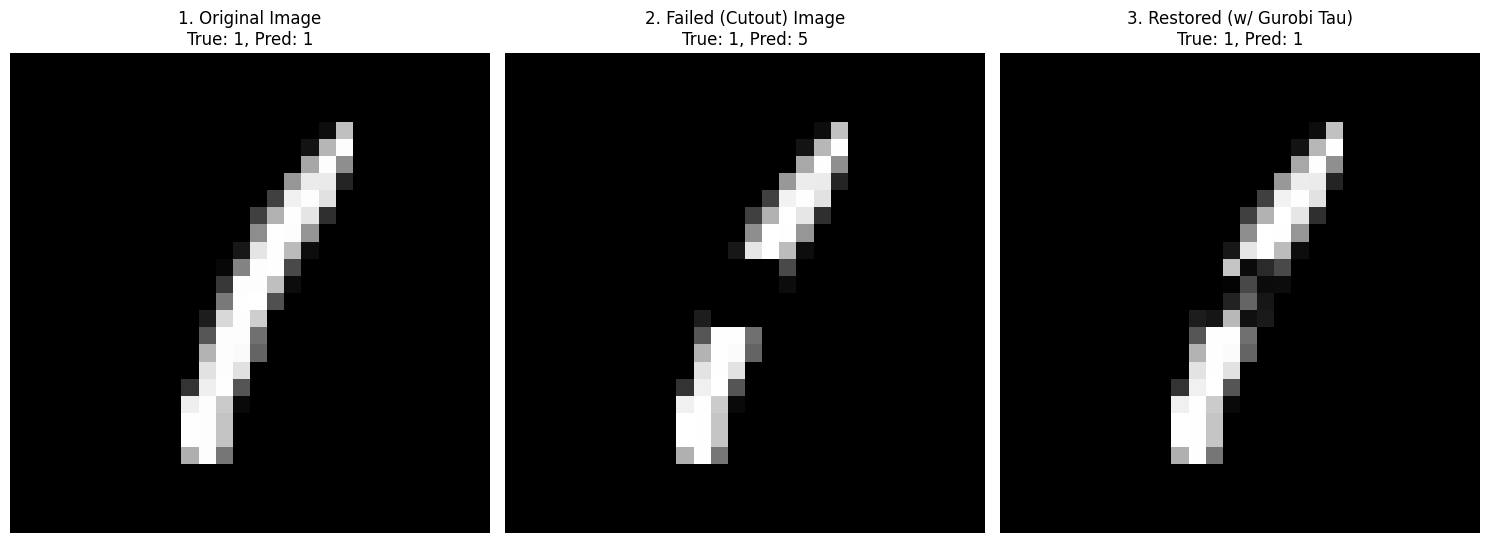


--- TEST 88/100: Image Index 850 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1196
Always active (L/U)      : 7414
Ambiguous ReLUs          : 798
ReLU binary variables    : 798
Binaries eliminated      : 8610
Binary reduction        : 91.52%
Starting optimized Gurobi optimization...
Solve time: 6.1143 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 850 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


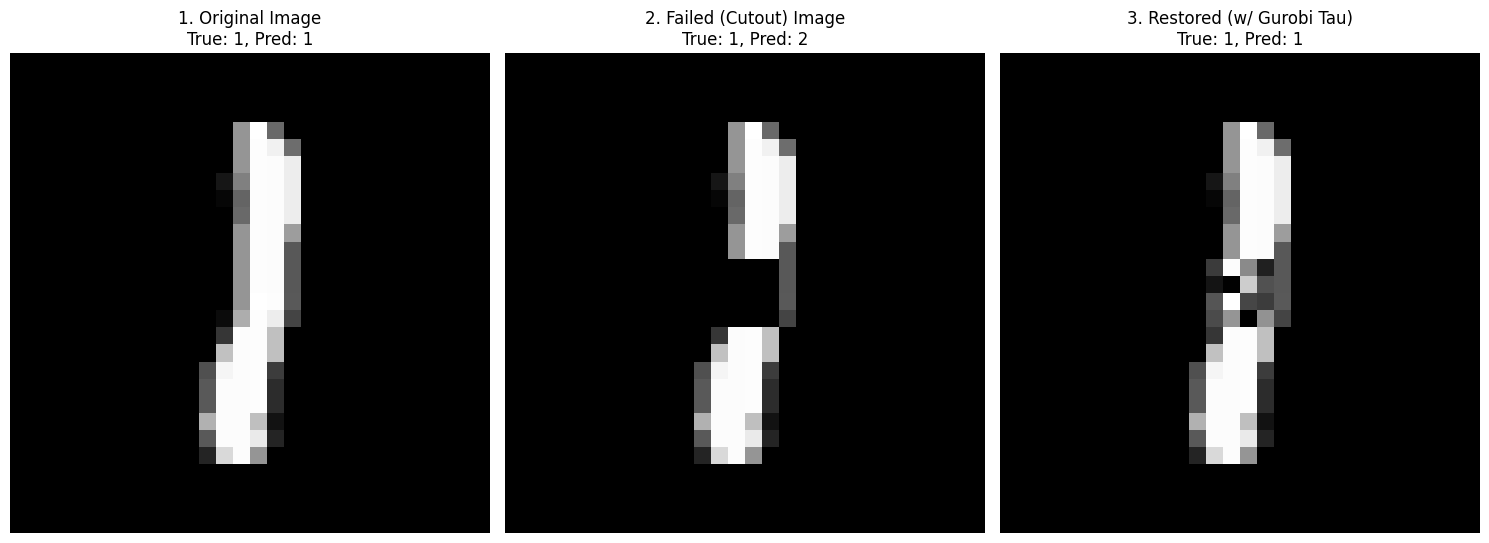


--- TEST 89/100: Image Index 89 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1199
Always active (L/U)      : 7397
Ambiguous ReLUs          : 812
ReLU binary variables    : 812
Binaries eliminated      : 8596
Binary reduction        : 91.37%
Starting optimized Gurobi optimization...
Solve time: 2.8215 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 89 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


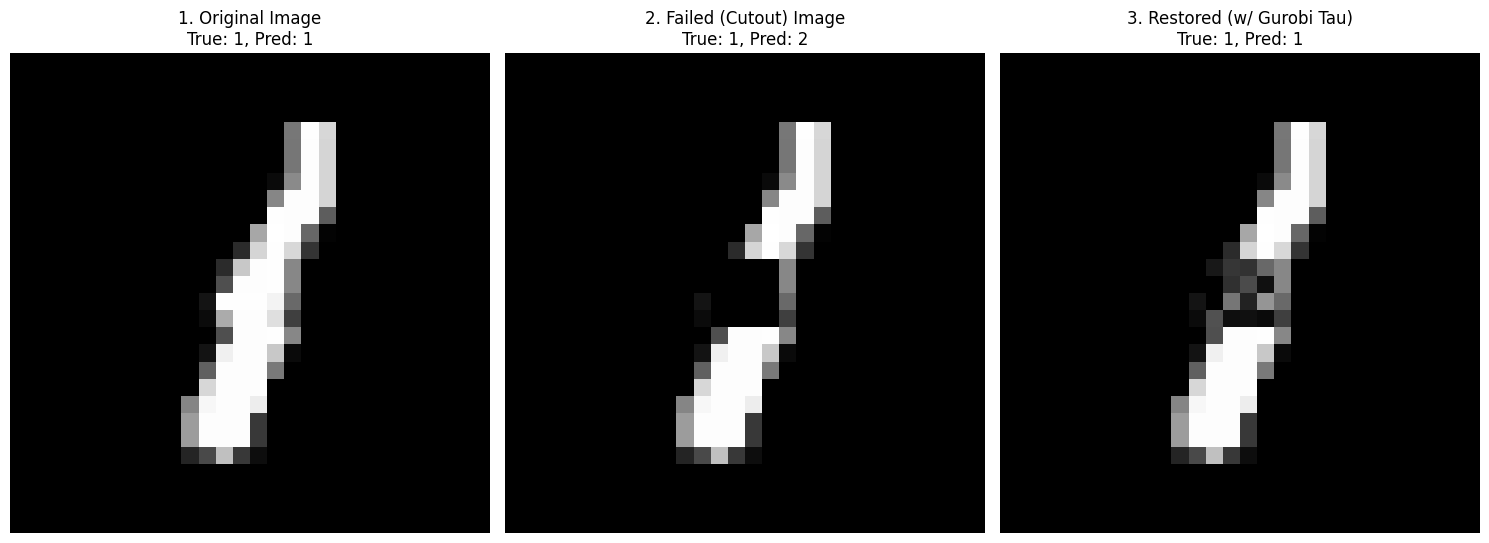


--- TEST 90/100: Image Index 907 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1152
Always active (L/U)      : 7366
Ambiguous ReLUs          : 890
ReLU binary variables    : 890
Binaries eliminated      : 8518
Binary reduction        : 90.54%
Starting optimized Gurobi optimization...
Solve time: 8.1293 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 907 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


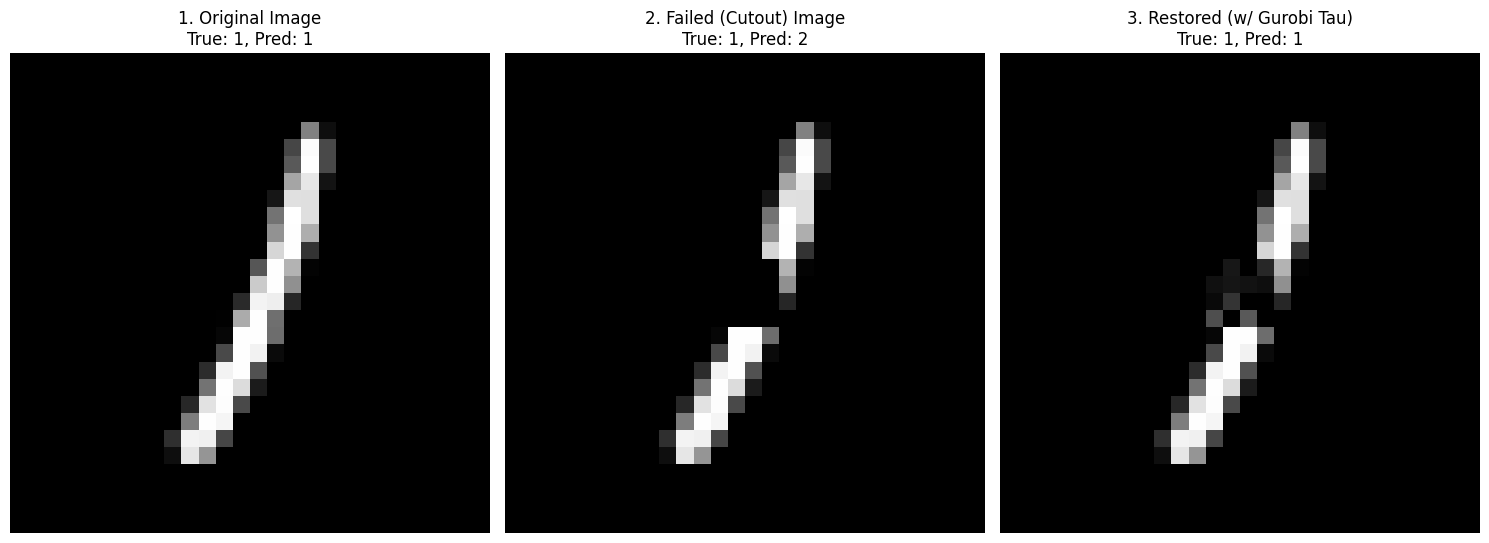


--- TEST 91/100: Image Index 938 ---
Running Gurobi to find corrective 'tau' patch for target 3...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1501
Always active (L/U)      : 7214
Ambiguous ReLUs          : 693
ReLU binary variables    : 693
Binaries eliminated      : 8715
Binary reduction        : 92.63%
Starting optimized Gurobi optimization...
Solve time: 4.7843 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 938 - True Label: 3
  Prediction (Original): 3 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 3 (Correct)
----------------------------------------


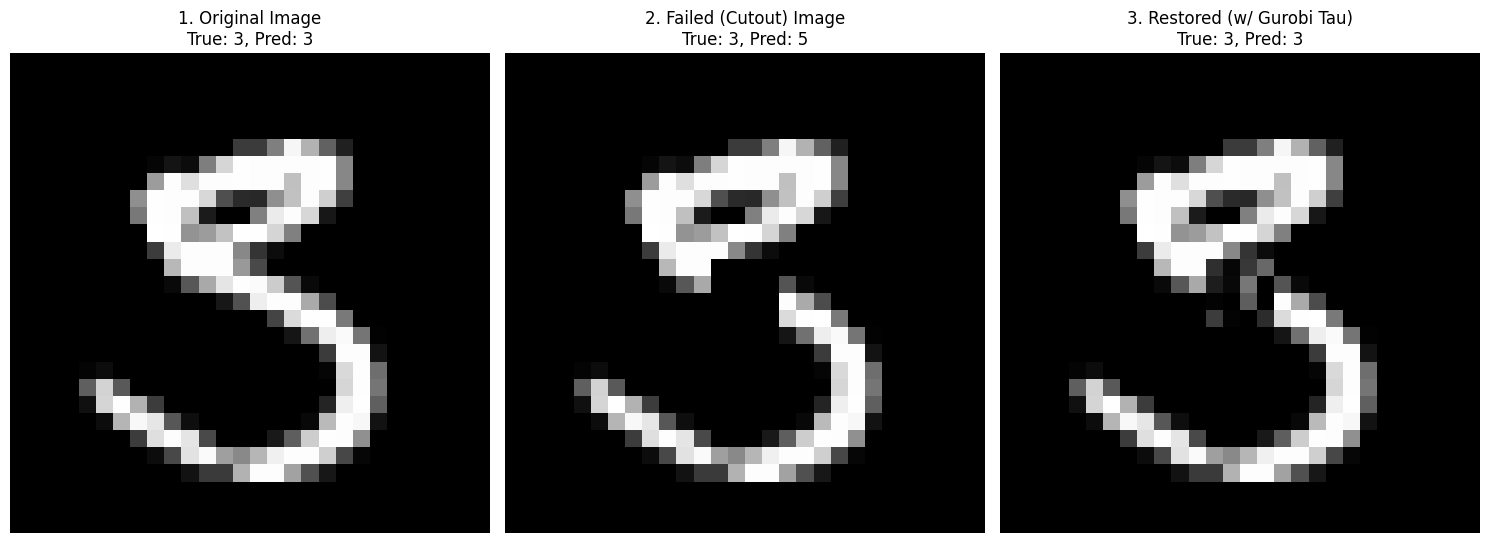


--- TEST 92/100: Image Index 94 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1309
Always active (L/U)      : 7432
Ambiguous ReLUs          : 667
ReLU binary variables    : 667
Binaries eliminated      : 8741
Binary reduction        : 92.91%
Starting optimized Gurobi optimization...
Solve time: 1.5012 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 94 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


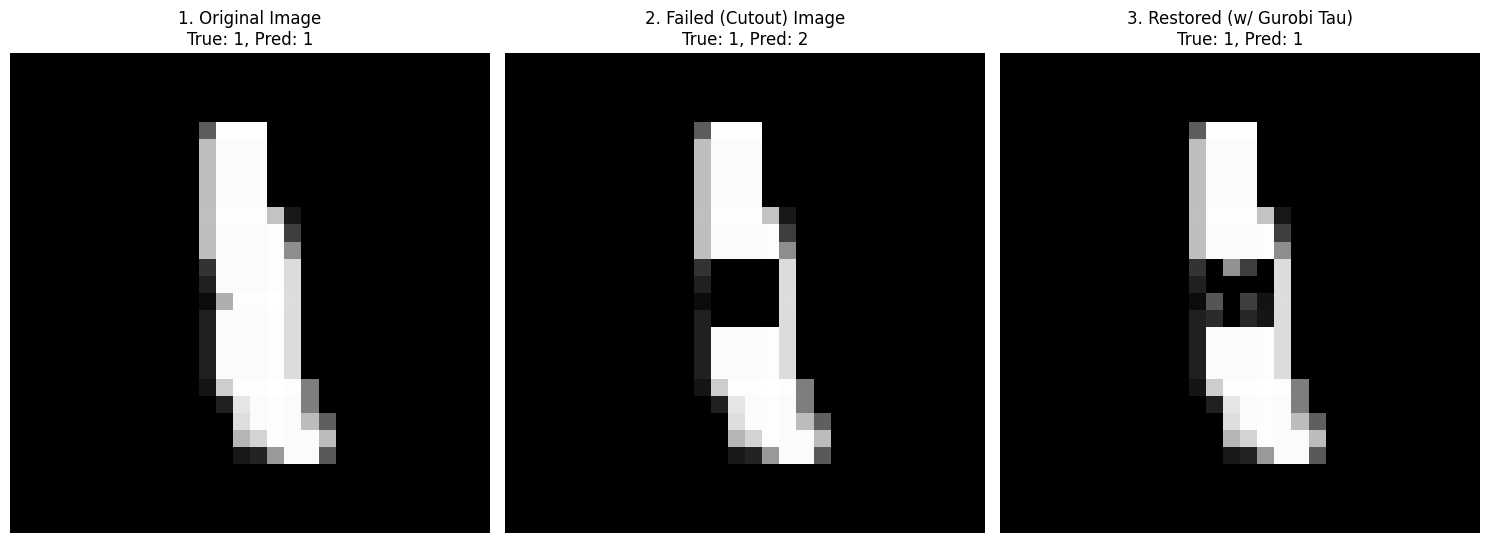


--- TEST 93/100: Image Index 954 ---
Running Gurobi to find corrective 'tau' patch for target 9...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1273
Always active (L/U)      : 7436
Ambiguous ReLUs          : 699
ReLU binary variables    : 699
Binaries eliminated      : 8709
Binary reduction        : 92.57%
Starting optimized Gurobi optimization...
Solve time: 27.5812 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 954 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


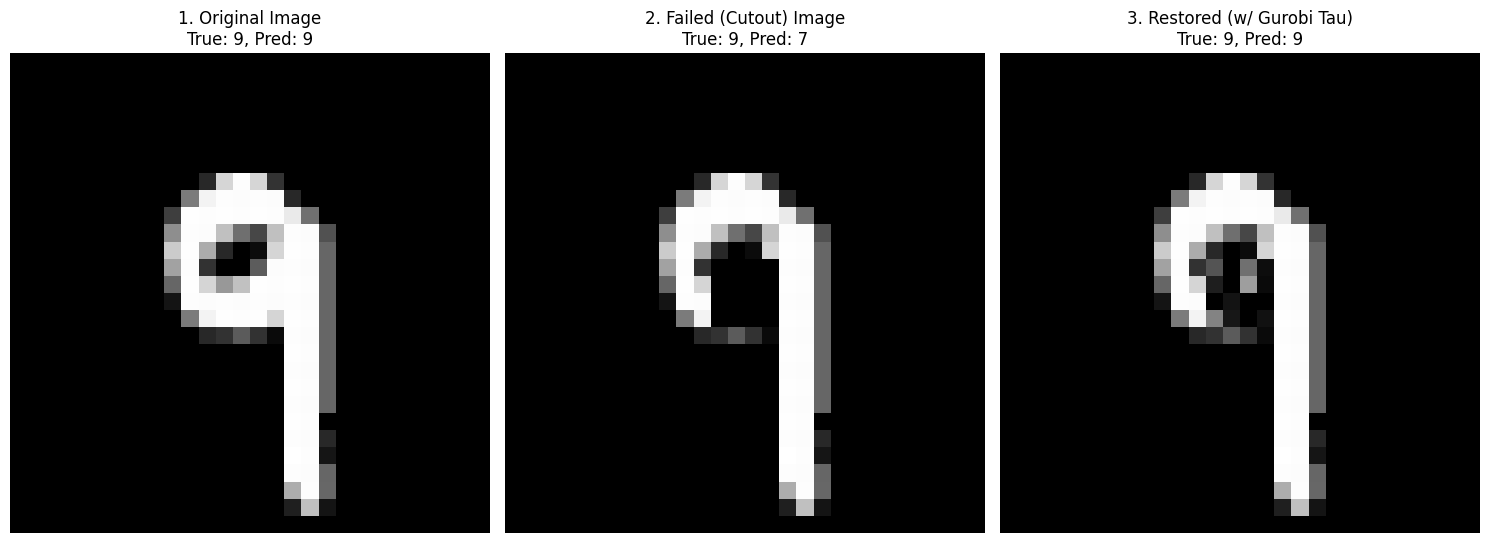


--- TEST 94/100: Image Index 956 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1342
Always active (L/U)      : 7318
Ambiguous ReLUs          : 748
ReLU binary variables    : 748
Binaries eliminated      : 8660
Binary reduction        : 92.05%
Starting optimized Gurobi optimization...
Solve time: 7.7338 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 956 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


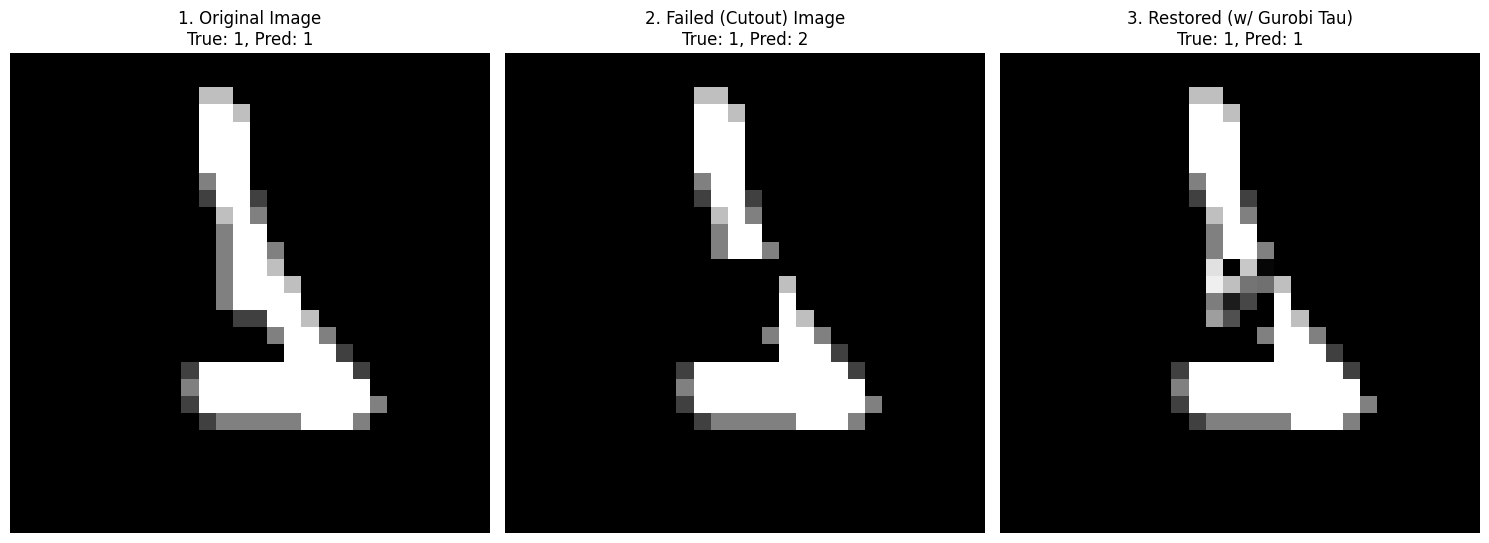


--- TEST 95/100: Image Index 958 ---
Running Gurobi to find corrective 'tau' patch for target 3...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1372
Always active (L/U)      : 7283
Ambiguous ReLUs          : 753
ReLU binary variables    : 753
Binaries eliminated      : 8655
Binary reduction        : 92.00%
Starting optimized Gurobi optimization...
Solve time: 53.3994 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 958 - True Label: 3
  Prediction (Original): 3 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 3 (Correct)
----------------------------------------


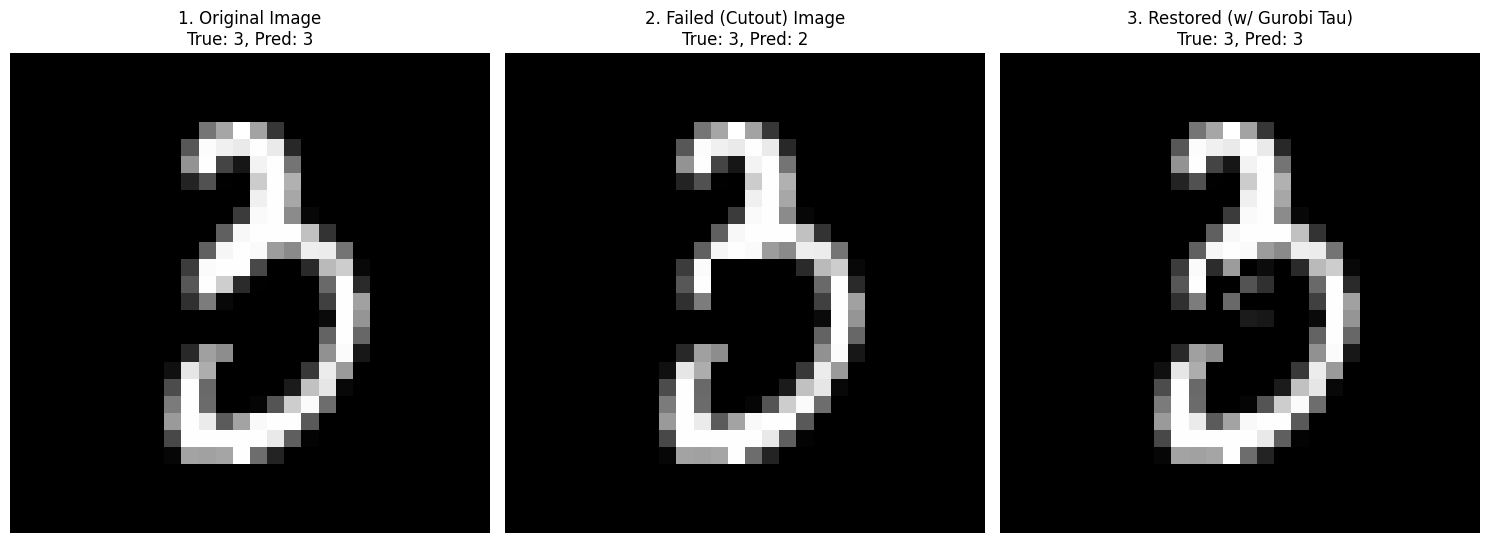


--- TEST 96/100: Image Index 964 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1140
Always active (L/U)      : 7338
Ambiguous ReLUs          : 930
ReLU binary variables    : 930
Binaries eliminated      : 8478
Binary reduction        : 90.11%
Starting optimized Gurobi optimization...
Solve time: 13.0516 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 964 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


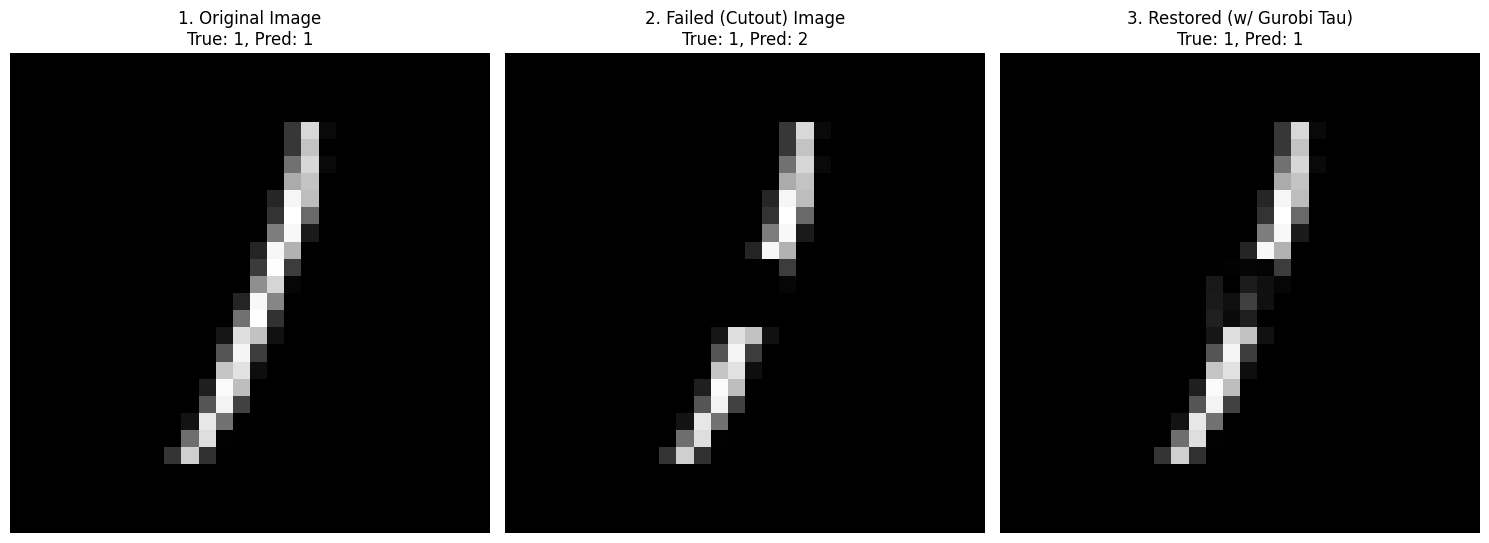


--- TEST 97/100: Image Index 966 ---
Running Gurobi to find corrective 'tau' patch for target 9...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1283
Always active (L/U)      : 7441
Ambiguous ReLUs          : 684
ReLU binary variables    : 684
Binaries eliminated      : 8724
Binary reduction        : 92.73%
Starting optimized Gurobi optimization...
Solve time: 6.7181 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 966 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


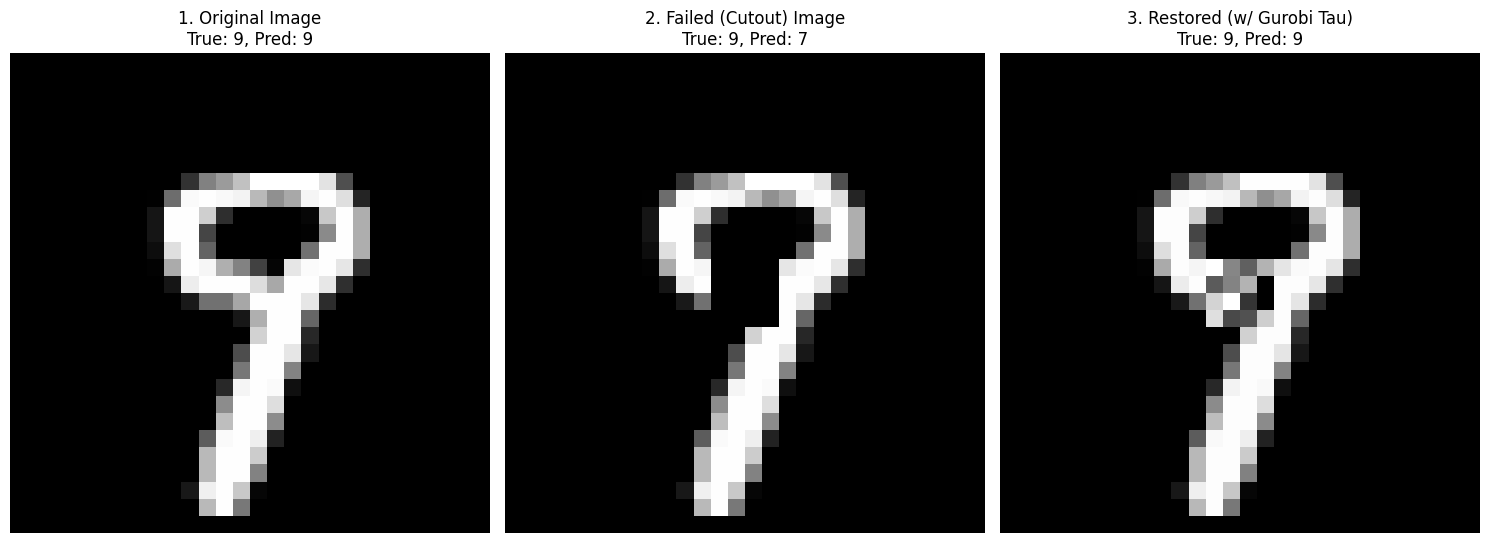


--- TEST 98/100: Image Index 977 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1261
Always active (L/U)      : 7405
Ambiguous ReLUs          : 742
ReLU binary variables    : 742
Binaries eliminated      : 8666
Binary reduction        : 92.11%
Starting optimized Gurobi optimization...
Solve time: 6.3131 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 977 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


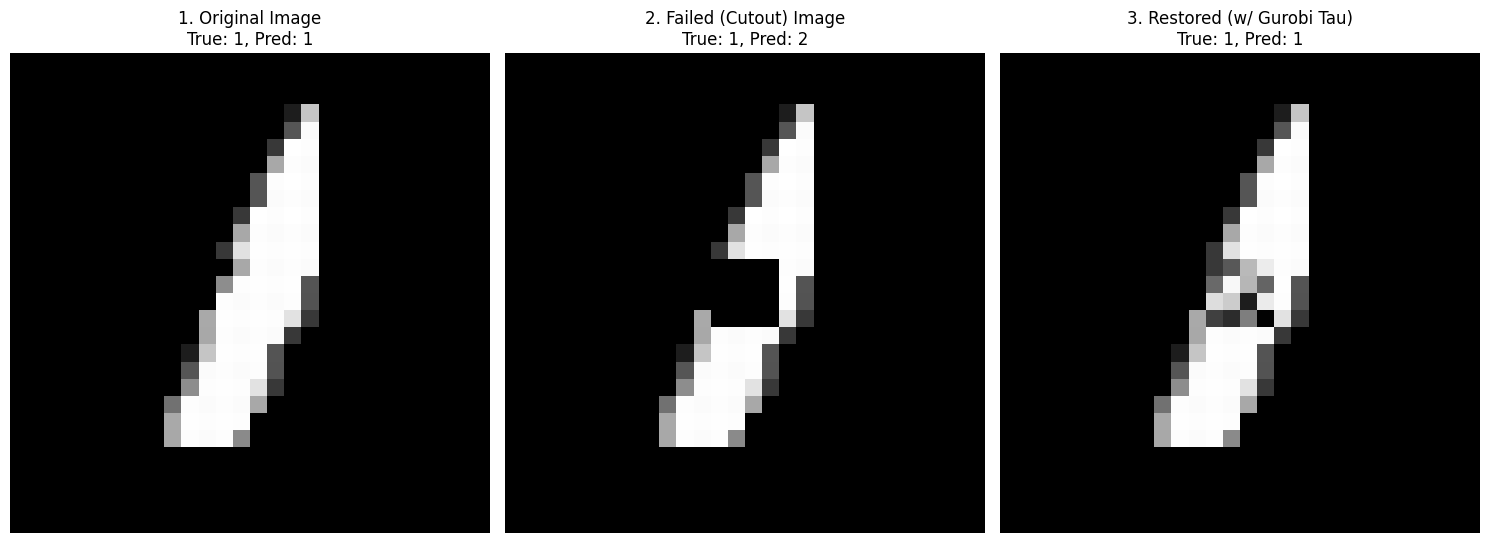


--- TEST 99/100: Image Index 979 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1251
Always active (L/U)      : 7369
Ambiguous ReLUs          : 788
ReLU binary variables    : 788
Binaries eliminated      : 8620
Binary reduction        : 91.62%
Starting optimized Gurobi optimization...
Solve time: 2.5680 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 979 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   3 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


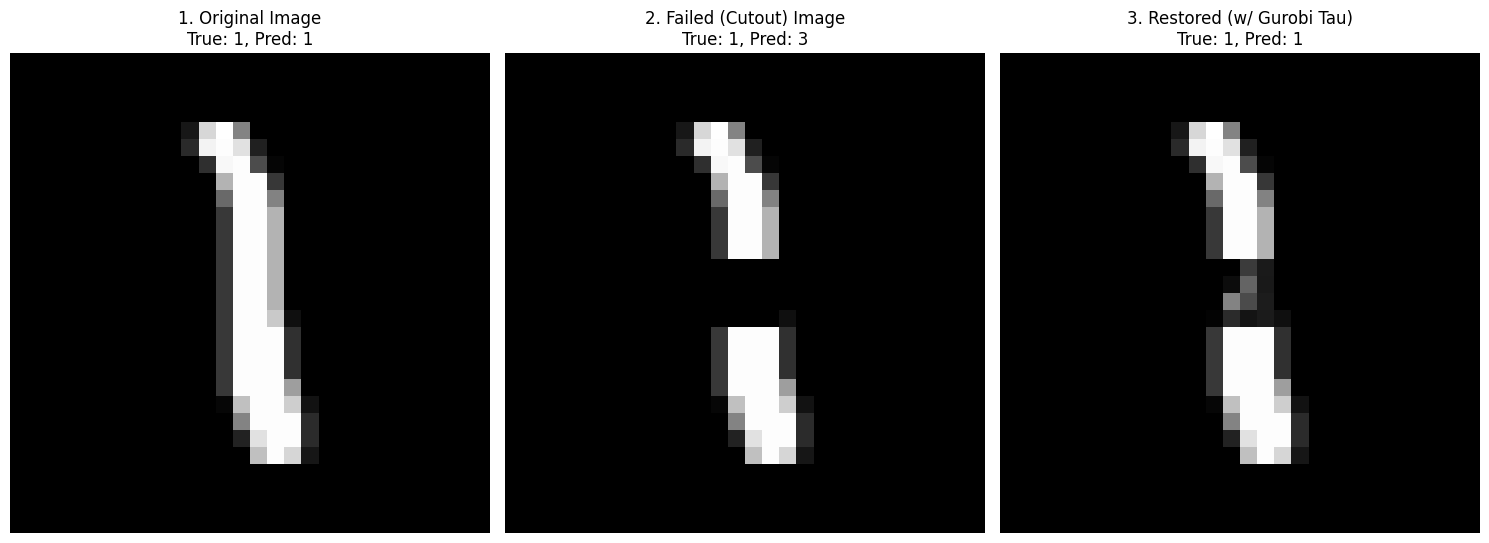


--- TEST 100/100: Image Index 994 ---
Running Gurobi to find corrective 'tau' patch for target 1...

BOUND-PROPAGATED ReLU SUMMARY
Total ReLU neurons       : 9408
Always inactive (L/U)    : 1299
Always active (L/U)      : 7336
Ambiguous ReLUs          : 773
ReLU binary variables    : 773
Binaries eliminated      : 8635
Binary reduction        : 91.78%
Starting optimized Gurobi optimization...
Solve time: 2.0756 s
Gurobi status: 2
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 994 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


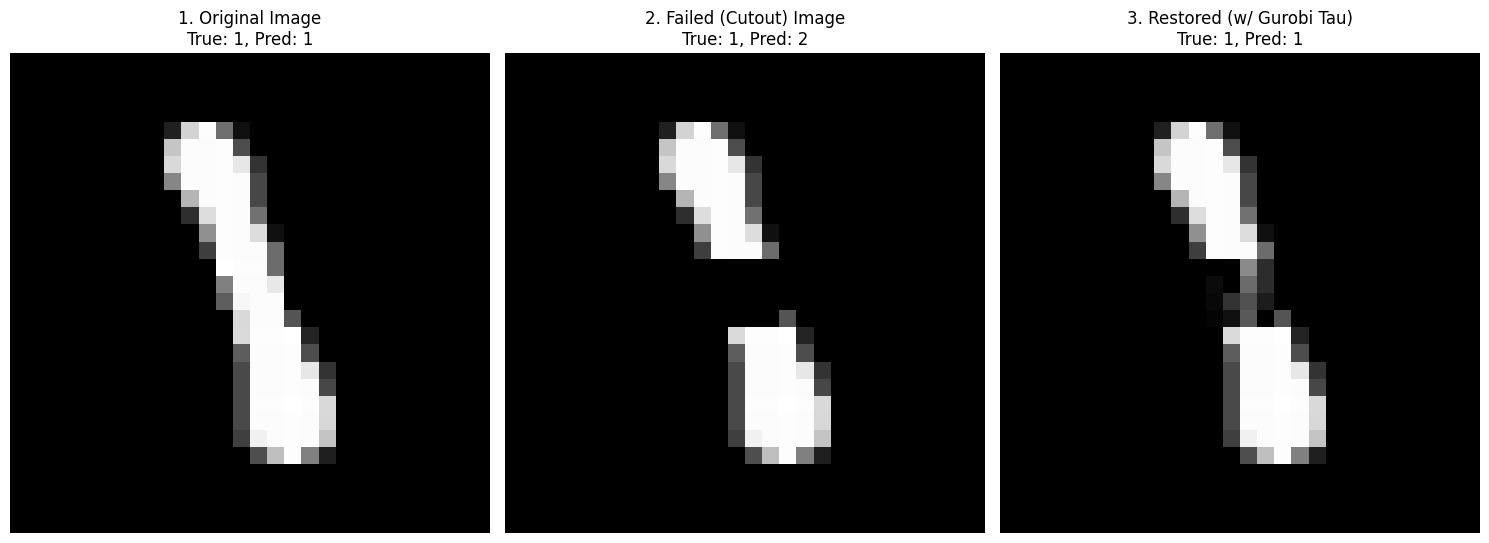

Total Images Processed: 100
  Gurobi Found a Fix (Success):   98
  Gurobi Failed (Infeasible/Timeout): 2
  Gurobi/Code Error:            0
---
Keras Confirmed Correct: 98
Restoration Accuracy: 98 / 100 = 98.00%


In [16]:
print("\n 9. Running Full Verification Test on Multiple Images for continuous TAU")

#1 Find all available failed images
data_folder = "./cnn_failures/"
failed_images_to_test = []

if not os.path.exists(data_folder) or not os.listdir(data_folder):
    print(f"Error: Folder '{data_folder}' is empty or does not exist.")
    print("Please run Block 10 (generate_cutout_images_cnn) first.")
else:
    for filename in os.listdir(data_folder):
        if filename.startswith("failed_image_") and filename.endswith(".npy"):
            try:
                image_index_str = filename.split('_')[-1].split('.')[0]
                image_index = int(image_index_str)

                label_path = os.path.join(data_folder, f"failed_label_{image_index}.npy")
                image_path = os.path.join(data_folder, filename)

                if os.path.exists(label_path):
                    true_label = np.load(label_path).item()
                    failed_images_to_test.append((image_index, image_path, true_label))
                else:
                    print(f"Warning: Found image {filename} but missing label file. Skipping.")

            except Exception as e:
                print(f"Could not parse index from {filename}: {e}")

# 2. Set processing limit
num_to_process = len(failed_images_to_test)

if num_to_process == 0:
    print("No failed image files found in 'cnn_failures/'.")
    print("Please run Block 10 to generate these files first.")
else:
    print(f"Found {len(failed_images_to_test)} failed images. Processing all of them...")

    cor = 0 # "Corrected" / "Fixed"
    incor = 0 # "Gurobi Failed"
    unclassified = 0 # "Infeasible" or "Timeout"
    cnt = 0

    restored_correctly_count = 0

    # 3. Loop through each failed image and run the test
    for i in range(num_to_process):

        image_index, failed_image_path, true_label = failed_images_to_test[i]
        cnt += 1

        print("\n" + "="*50)
        print(f"--- TEST {i+1}/{num_to_process}: Image Index {image_index} ---")
        print("="*50)

        # a. The original (non-cutout) image from the test set
        original_image = x_test[image_index]

        # b. The failed (cutout) image
        failed_image = np.load(failed_image_path)

        # 5. Run Gurobi to get the corrective 'tau' patch
        print(f"Running Gurobi to find corrective 'tau' patch for target {true_label}...")

        # This now calls the GENERALIZED function. this we have defined above
        (tau_values, gurobi_prediction) = model_encoding(failed_image, true_label, num_conv_layers=N_LAYERS,tauType=1)

        if tau_values is not None:
            print("Gurobi found a solution. Preparing comparison...")

            # 6. Create the Restored image
            grid_size = 4 # Updated
            x_centre, y_centre = 14, 14
            grid_bound = grid_size // 2
            start_x, start_y = x_centre - grid_bound, y_centre - grid_bound

            tau_patch = np.array(tau_values).reshape(grid_size, grid_size)
            restored_image = failed_image.copy()
            restored_image[start_x:start_x + grid_size, start_y:start_y + grid_size, 0] += tau_patch
            restored_image = np.clip(restored_image, 0, 1)

            # 7. Get Predictions for all 3 images i.e. original vs perturbed vs restored
            def get_pred(image):
                img_batch = np.expand_dims(image, axis=0)
                pred = model_cnn.predict(img_batch, verbose=0)
                return np.argmax(pred)

            pred_original = get_pred(original_image)
            pred_failed = get_pred(failed_image)
            pred_restored = get_pred(restored_image)

            if pred_restored == true_label:
                restored_correctly_count += 1

            # results
            print("\n" + "-"*40)
            print(f"Image {image_index} - True Label: {true_label}")
            print(f"  Prediction (Original): {pred_original} {'(Correct)' if pred_original == true_label else '(Incorrect)'}")
            print(f"  Prediction (Failed):   {pred_failed} {'(Correct)' if pred_failed == true_label else '(Incorrect)'}")
            print(f"  Prediction (Restored): {pred_restored} {'(Correct)' if pred_restored == true_label else '(Incorrect)'}")
            print("-"*40)

            plt.figure(figsize=(15, 6))
            plt.subplot(1, 3, 1)
            plt.imshow(original_image.squeeze(), cmap='gray')
            plt.title(f"1. Original Image\nTrue: {true_label}, Pred: {pred_original}")
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.imshow(failed_image.squeeze(), cmap='gray')
            plt.title(f"2. Failed (Cutout) Image\nTrue: {true_label}, Pred: {pred_failed}")
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.imshow(restored_image.squeeze(), cmap='gray')
            plt.title(f"3. Restored (w/ Gurobi Tau)\nTrue: {true_label}, Pred: {pred_restored}")
            plt.axis('off')

            plt.tight_layout()
            plt.show()

            cor += 1

        else:
            print(f"Gurobi could not find a corrective patch for image {image_index}.")
            unclassified += 1 # Gurobi was INFEASIBLE or TIMED OUT

    # print("\n" + "="*30)
    # print("FINAL RESULTS")
    # print("="*30)
    # print(f"Success (Fixed)={cor}, Failed (Gurobi error)={incor}, Unclassified (Not-Fixed)={unclassified}, Total={cnt}")
    # print(f"Total Processed Files: {cnt}")

    print(f"Total Images Processed: {cnt}")
    print(f"  Gurobi Found a Fix (Success):   {cor}")
    print(f"  Gurobi Failed (Infeasible/Timeout): {unclassified}")
    print(f"  Gurobi/Code Error:            {incor}")
    print(f"---")
    print(f"Keras Confirmed Correct: {restored_correctly_count}")

    if cnt > 0:
        accuracy = (restored_correctly_count / cnt) * 100
        print(f"Restoration Accuracy: {restored_correctly_count} / {cnt} = {accuracy:.2f}%")
    else:
        print("Restoration Accuracy: N/A (no images processed)")
